## Research Questions and Analytic Samples

### RQ1: Predicting Teachers’ AI Use

**Research question:**  
Which factors predict whether teachers used AI during the last 12 months?

**Outcome variable:** `TT4G36`

- `1` = Yes
- `2` = No
- `8` = Not administered
- `9` = Omitted or invalid

The RQ1 analytic sample includes teachers with a valid Yes or No response to `TT4G36`.

**RQ1 analytic sample:** **N = 89,833**

---

### RQ2: Predicting the Adoption of Student-Facing AI Use

**Research question:**  
Among teachers who used AI, which factors predict their AI use is student-facing?

#### Student-facing AI-use items

- `TT4G37A` — Assess or mark student work
- `TT4G37G` — Review data on student participation or performance
- `TT4G37H` — Help students practise new skills in real-life scenarios

#### Teacher-facing items retained as predictors/descriptive variables

- `TT4G37B` — Efficiently learn about and summarise a topic
- `TT4G37C` — Generate lesson plans or activities
- `TT4G37F` — Generate text for student feedback or parent/guardian communication

#### Sensitivity-analysis items

- `TT4G37D` — Support students with special education needs
- `TT4G37E` — Automatically adjust lesson-material difficulty according to students’ learning needs

#### Excluded item

- `TT4G37I` — Other

In [ ]:
#**Author:** Ruiping Huang

# ============================================================
# CELL 1 — Import packages and load TALIS 2024 data/codebook
# ============================================================

import os
import math
import json
import sys
from pathlib import Path
from typing import List, Dict, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# File paths
# ------------------------------------------------------------

# Portable: finds the repo by walking up from wherever Jupyter started,
# so the same cell works on any laptop with no editing.
def find_root(start=None, depth=6):
    p = start or Path.cwd()
    for _ in range(depth):
        if (p / "Data").exists() and (p / "EDA").exists():
            return p
        p = p.parent
    raise FileNotFoundError(
        f"repo root not found walking up from {Path.cwd()} — "
        "open the summer26-teacher-ai-readiness folder in VS Code/Jupyter, "
        "reopen this notebook, restart the kernel")

ROOT = find_root()

# raw TALIS teacher file, OECD CSV export (semicolon-separated; gitignored — see Data/README.md)
data_path = ROOT / "Data" / "CSV" / "ttgintt4.csv"

# shared codebook (tracked in git)
codebook_path = ROOT / "Data" / "talis2024_teacher_codebook.csv"

# All tables, figures, and exported files created in this notebook
# will be saved in this folder (gitignored — regenerated by Run All).
output_dir = ROOT / "EDA" / "output"

output_dir.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Confirm that required files exist
# ------------------------------------------------------------

if not data_path.exists():
    raise FileNotFoundError(
        f"Teacher data file not found:\n{data_path}"
    )

if not codebook_path.exists():
    raise FileNotFoundError(
        f"Codebook file not found:\n{codebook_path}"
    )

# ------------------------------------------------------------
# Load data
# ------------------------------------------------------------

full_df = pd.read_csv(
    data_path,
    sep=";",
    low_memory=False
)

codebook = pd.read_csv(codebook_path)

# ------------------------------------------------------------
# Basic checks
# ------------------------------------------------------------

print(
    f"Teacher data shape: "
    f"{full_df.shape[0]:,} rows × {full_df.shape[1]:,} columns"
)

print(
    f"Codebook shape: "
    f"{codebook.shape[0]:,} rows × {codebook.shape[1]:,} columns"
)

print(f"\nOutput folder:\n{output_dir}")

print("\nFirst 20 columns in teacher data:")
print(full_df.columns[:20].tolist())

print("\nCodebook columns:")
print(codebook.columns.tolist())

display(full_df.head())
display(codebook.head())

Teacher data shape: 278,383 rows × 630 columns
Codebook shape: 630 rows × 16 columns

Output folder:
c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output

First 20 columns in teacher data:
['CNTRY', 'IDCNTRY', 'IDCNTPOP', 'IDSCHOOL', 'IDTEACH', 'IDTQUEST', 'IDLANG_TQ', 'ITMODE_TQ', 'TT4G01', 'TT4G04', 'TT4G06A', 'TT4G06B', 'TT4G06C', 'TT4G06D', 'TT4G06E', 'TT4G06F', 'TT4G07A', 'TT4G07B', 'TT4G07C', 'TT4G07D']

Codebook columns:
['variable_name', 'column_number_ttgintt4', 'source_type', 'official_variable_label', 'label_group_1', 'label_group_2', 'label_group_3', 'label_group_4', 'teacher_questionnaire_question', 'item', 'valid_value_labels', 'special_missing_or_skip_codes', 'all_value_labels', 'available_idpop', 'available_files', 'recommended_cleaning_note']


,CNTRY,IDCNTRY,IDCNTPOP,IDSCHOOL,IDTEACH,IDTQUEST,IDLANG_TQ,ITMODE_TQ,TT4G01,TT4G04,...,TRWGT93,TRWGT94,TRWGT95,TRWGT96,TRWGT97,TRWGT98,TRWGT99,TRWGT100,VERSION,IEADATE
0,ARE,784,ARE1,1001,100101,2,53,1,1,3,...,2.491176,0.830392,2.491176,2.491176,0.830392,2.491176,0.830392,0.830392,3.2,2025-11-05
1,ARE,784,ARE1,1001,100102,3,53,1,1,9,...,9.964704,3.321568,9.964704,9.964704,3.321568,9.964704,3.321568,3.321568,3.2,2025-11-05
2,ARE,784,ARE1,1001,100103,1,1,1,1,3,...,9.964704,3.321568,9.964704,9.964704,3.321568,9.964704,3.321568,3.321568,3.2,2025-11-05
3,ARE,784,ARE1,1001,100104,2,1,1,1,1,...,9.964704,3.321568,9.964704,9.964704,3.321568,9.964704,3.321568,3.321568,3.2,2025-11-05
4,ARE,784,ARE1,1001,100105,3,1,1,1,2,...,9.964704,3.321568,9.964704,9.964704,3.321568,9.964704,3.321568,3.321568,3.2,2025-11-05


,variable_name,column_number_ttgintt4,source_type,official_variable_label,label_group_1,label_group_2,label_group_3,label_group_4,teacher_questionnaire_question,item,valid_value_labels,special_missing_or_skip_codes,all_value_labels,available_idpop,available_files,recommended_cleaning_note
0,CNTRY,1,identifier/design/admin,Country ID - Alpha Code,Country ID - Alpha Code,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"1,2,3","atgintt4, btgintt4, ctgintt4, ttgintt4",No special cleaning note beyond standard type ...
1,IDCNTRY,2,identifier/design/admin,Country ID - Numeric Code,Country ID - Numeric Code,NaN,NaN,NaN,NaN,NaN,8 = Albania | 31 = Azerbaijan | 36 = Australia...,999998 = Not administered | 999999 = Omitted o...,8 = Albania | 31 = Azerbaijan | 36 = Australia...,"1,2,3","atgintt4, btgintt4, ctgintt4, ttgintt4","For CSV analysis, recode special codes as miss..."
2,IDCNTPOP,3,identifier/design/admin,Country Alpha Code and ISCED Level,Country Alpha Code and ISCED Level,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"1,2,3","atgintt4, btgintt4, ctgintt4, ttgintt4",No special cleaning note beyond standard type ...
3,IDSCHOOL,4,identifier/design/admin,School ID,School ID,NaN,NaN,NaN,NaN,NaN,NaN,9998 = Not administered | 9999 = Omitted or in...,9998 = Not administered | 9999 = Omitted or in...,"1,2,3","atgintt4, btgintt4, ctgintt4, ttgintt4","For CSV analysis, recode special codes as miss..."
4,IDTEACH,5,identifier/design/admin,Teacher ID,Teacher ID,NaN,NaN,NaN,NaN,NaN,NaN,999998 = Not administered | 999999 = Omitted o...,999998 = Not administered | 999999 = Omitted o...,"1,2,3","atgintt4, btgintt4, ctgintt4, ttgintt4","For CSV analysis, recode special codes as miss..."


In [2]:
# ============================================================
# CELL 2 — Codebook helper for inspecting variable definitions
# ============================================================

def check_variable_codebook(
    var_name,
    data=full_df,
    codebook_df=codebook,
    show_distribution=True
):
    """
    Display the codebook information and observed distribution
    for one TALIS variable.

    Parameters
    ----------
    var_name : str
        TALIS variable name.
    data : pandas.DataFrame
        Dataset containing the variable.
    codebook_df : pandas.DataFrame
        TALIS codebook.
    show_distribution : bool
        Whether to display observed counts and percentages.
    """

    # --------------------------------------------------------
    # Check whether the variable exists in the codebook
    # --------------------------------------------------------

    if var_name not in codebook_df["variable_name"].values:
        print(f"{var_name} was not found in the codebook.")
        return None

    row = (
        codebook_df
        .loc[codebook_df["variable_name"] == var_name]
        .iloc[0]
    )

    def clean_text(value):
        """Replace missing codebook text with a readable label."""
        return "Not provided" if pd.isna(value) else value

    # --------------------------------------------------------
    # Display codebook information
    # --------------------------------------------------------

    print("=" * 90)
    print(f"Variable: {var_name}")
    print("=" * 90)

    print("\nOfficial variable label:")
    print(clean_text(row["official_variable_label"]))

    print("\nQuestion:")
    print(clean_text(row["teacher_questionnaire_question"]))

    print("\nItem:")
    print(clean_text(row["item"]))

    print("\nValid value labels:")
    print(clean_text(row["valid_value_labels"]))

    print("\nSpecial missing or skip codes:")
    print(clean_text(row["special_missing_or_skip_codes"]))

    print("\nRecommended cleaning note:")
    print(clean_text(row["recommended_cleaning_note"]))

    # --------------------------------------------------------
    # Display observed distribution
    # --------------------------------------------------------

    if show_distribution:

        if var_name not in data.columns:
            print(f"\n{var_name} was not found in the teacher dataset.")
            return row

        value_counts_df = (
            data[var_name]
            .value_counts(dropna=False)
            .sort_index()
            .rename_axis("value")
            .reset_index(name="count")
        )

        value_counts_df["percent"] = (
            value_counts_df["count"] / len(data) * 100
        ).round(2)

        print(
            f"\nObserved distribution in the current dataset "
            f"(N = {len(data):,}):"
        )

        display(value_counts_df)

    return row


# ------------------------------------------------------------
# Core variables for RQ1 and the revised RQ2 definition
# ------------------------------------------------------------

rq1_outcome_vars = [
    "TT4G36"
]

rq2_student_facing_vars = [
    "TT4G37A",  # Assess or mark student work
    "TT4G37G",  # Review student participation/performance data
    "TT4G37H"   # Help students practise skills in real-life scenarios
]

rq2_teacher_facing_vars = [
    "TT4G37B",  # Learn about and summarise a topic
    "TT4G37C",  # Generate lesson plans or activities
    "TT4G37F"   # Generate feedback or parent/guardian communications
]

rq2_sensitivity_vars = [
    "TT4G37D",  # Support students with special education needs
    "TT4G37E"   # Automatically adjust lesson-material difficulty
]

rq2_excluded_vars = [
    "TT4G37I"   # Other AI use
]

design_vars = [
    "IDCNTPOP"   # Country/region and ISCED level
]

core_vars_to_check = (
    rq1_outcome_vars
    + rq2_student_facing_vars
    + rq2_teacher_facing_vars
    + rq2_sensitivity_vars
    + rq2_excluded_vars
    + design_vars
)

# ------------------------------------------------------------
# Inspect the core outcome and design variables
# ------------------------------------------------------------

for var in core_vars_to_check:
    check_variable_codebook(var)

Variable: TT4G36

Official variable label:
Teaching in General/ Used artificial intelligence during the last 12 months

Question:
36.0

Item:
Not provided

Valid value labels:
1 = Yes | 2 = No

Special missing or skip codes:
8 = Not administered | 9 = Omitted or invalid

Recommended cleaning note:
For CSV analysis, recode special codes as missing/structural as appropriate: 8 = Not administered | 9 = Omitted or invalid

Observed distribution in the current dataset (N = 278,383):


,value,count,percent
0,1,36762,13.21
1,2,53071,19.06
2,8,185489,66.63
3,9,3061,1.10


Variable: TT4G37A

Official variable label:
Teaching in General/ Used artificial intelligence/ To assess or mark student work

Question:
37.0

Item:
A

Valid value labels:
1 = Yes | 2 = No

Special missing or skip codes:
6 = Logically not applicable | 8 = Not administered | 9 = Omitted or invalid

Recommended cleaning note:
For CSV analysis, recode special codes as missing/structural as appropriate: 6 = Logically not applicable | 8 = Not administered | 9 = Omitted or invalid

Observed distribution in the current dataset (N = 278,383):


,value,count,percent
0,1,13400,4.81
1,2,23134,8.31
2,6,53071,19.06
3,8,185489,66.63
4,9,3289,1.18


Variable: TT4G37G

Official variable label:
Teaching in General/ Used artificial intelligence/ To review data on student participation or performance

Question:
37.0

Item:
G

Valid value labels:
1 = Yes | 2 = No

Special missing or skip codes:
6 = Logically not applicable | 8 = Not administered | 9 = Omitted or invalid

Recommended cleaning note:
For CSV analysis, recode special codes as missing/structural as appropriate: 6 = Logically not applicable | 8 = Not administered | 9 = Omitted or invalid

Observed distribution in the current dataset (N = 278,383):


...

,value,count,percent
0,1,18073,6.49
1,2,18416,6.62
2,6,53071,19.06
3,8,185489,66.63
4,9,3334,1.20


Variable: TT4G37I

Official variable label:
Teaching in General/ Used artificial intelligence/ Other

Question:
37.0

Item:
I

Valid value labels:
1 = Yes | 2 = No

Special missing or skip codes:
6 = Logically not applicable | 8 = Not administered | 9 = Omitted or invalid

Recommended cleaning note:
For CSV analysis, recode special codes as missing/structural as appropriate: 6 = Logically not applicable | 8 = Not administered | 9 = Omitted or invalid

Observed distribution in the current dataset (N = 278,383):


,value,count,percent
0,1,16529,5.94
1,2,18138,6.52
2,6,53071,19.06
3,8,185489,66.63
4,9,5156,1.85


Variable: IDCNTPOP

Official variable label:
Country Alpha Code and ISCED Level

Question:
Not provided

Item:
Not provided

Valid value labels:
Not provided

Special missing or skip codes:
Not provided

Recommended cleaning note:
No special cleaning note beyond standard type checks.

Observed distribution in the current dataset (N = 278,383):


,value,count,percent
0,ALB2,4029,1.45
1,ARE1,4091,1.47
2,ARE2,4369,1.57
3,ARE3,4228,1.52
4,AUS1,3003,1.08
...,...,...,...
74,USA2,1988,0.71
75,UZB2,4431,1.59
76,VNM2,4348,1.56
77,XKX2,3281,1.18


In [3]:
# ============================================================
# CELL 3 — Create country/region names and school-level labels
# ============================================================

# Make a copy before adding derived variables
full_df = full_df.copy()

# ------------------------------------------------------------
# 3.1 Country/region name mapping
# ------------------------------------------------------------

country_code_map = {
    "ALB": "Albania",
    "ARE": "United Arab Emirates",
    "AUS": "Australia",
    "AUT": "Austria",
    "AZE": "Azerbaijan",
    "BEL": "Belgium",
    "BFL": "Flemish Community (Belgium)",
    "BFR": "French Community (Belgium)",
    "BGR": "Bulgaria",
    "BHR": "Bahrain",
    "BRA": "Brazil",
    "CAB": "Alberta (Canada)",
    "CHL": "Chile",
    "COL": "Colombia",
    "CRI": "Costa Rica",
    "CSH": "Shanghai (China)",
    "CYP": "Cyprus",
    "CZE": "Czechia",
    "DNK": "Denmark",
    "ESP": "Spain",
    "EST": "Estonia",
    "FIN": "Finland",
    "FRA": "France",
    "HRV": "Croatia",
    "HUN": "Hungary",
    "ISL": "Iceland",
    "ISR": "Israel",
    "ITA": "Italy",
    "JPN": "Japan",
    "KAZ": "Kazakhstan",
    "KOR": "Korea",
    "LTU": "Lithuania",
    "LVA": "Latvia",
    "MAR": "Morocco",
    "MKD": "North Macedonia",
    "MLT": "Malta",
    "MNE": "Montenegro",
    "NLD": "Netherlands",
    "NOR": "Norway",
    "NZL": "New Zealand",
    "POL": "Poland",
    "PRT": "Portugal",
    "ROU": "Romania",
    "SAU": "Saudi Arabia",
    "SGP": "Singapore",
    "SRB": "Serbia",
    "SVK": "Slovak Republic",
    "SVN": "Slovenia",
    "SWE": "Sweden",
    "TUR": "Türkiye",
    "USA": "United States",
    "UZB": "Uzbekistan",
    "VNM": "Viet Nam",
    "XKX": "Kosovo",
    "ZAF": "South Africa"
}

full_df["country_name"] = full_df["CNTRY"].map(country_code_map)

# Check whether any observed country/region code was not mapped
observed_country_codes = set(full_df["CNTRY"].dropna().unique())
mapped_country_codes = set(country_code_map.keys())

unmatched_country_codes = sorted(
    observed_country_codes - mapped_country_codes
)

unused_country_codes = sorted(
    mapped_country_codes - observed_country_codes
)

print(f"Observed country/region codes: {len(observed_country_codes):,}")
print(f"Mapped country/region names: {full_df['country_name'].nunique():,}")
print("Unmatched observed country codes:", unmatched_country_codes)
print("Mapped codes not observed in this dataset:", unused_country_codes)

if unmatched_country_codes:
    print(
        "\nWarning: Some observed CNTRY values do not have a country/region "
        "name. Update country_code_map before country-level analyses."
    )

# ------------------------------------------------------------
# 3.2 ISCED school-level labels
# ------------------------------------------------------------

# IDCNTPOP combines the country/region code and ISCED level.
# Its final digit indicates:
# 1 = Primary
# 2 = Lower secondary
# 3 = Upper secondary

full_df["isced_level"] = pd.to_numeric(
    full_df["IDCNTPOP"]
    .astype("string")
    .str.extract(r"([123])$", expand=False),
    errors="coerce"
).astype("Int64")

isced_label_map = {
    1: "Primary",
    2: "Lower secondary",
    3: "Upper secondary"
}

full_df["isced_label"] = full_df["isced_level"].map(
    isced_label_map
)

full_df["isced_label"] = pd.Categorical(
    full_df["isced_label"],
    categories=[
        "Primary",
        "Lower secondary",
        "Upper secondary"
    ],
    ordered=True
)

# ------------------------------------------------------------
# 3.3 Validate derived variables
# ------------------------------------------------------------

unmatched_isced_values = (
    full_df.loc[
        full_df["isced_label"].isna()
        & full_df["IDCNTPOP"].notna(),
        "IDCNTPOP"
    ]
    .drop_duplicates()
    .sort_values()
    .tolist()
)

print("\nUnmatched IDCNTPOP values:", unmatched_isced_values)

# ------------------------------------------------------------
# 3.4 Descriptive checks
# ------------------------------------------------------------

print(
    f"\nNumber of countries/regions: "
    f"{full_df['country_name'].nunique():,}"
)

print("\nSchool-level distribution in the full dataset:")

isced_full_summary = (
    full_df["isced_label"]
    .value_counts(sort=False, dropna=False)
    .rename_axis("school_level")
    .reset_index(name="n")
)

isced_full_summary["percent"] = (
    isced_full_summary["n"] / len(full_df) * 100
).round(2)

display(isced_full_summary)

print("\nCountry/region sample-size preview:")

country_full_summary = (
    full_df["country_name"]
    .value_counts(dropna=False)
    .rename_axis("country_name")
    .reset_index(name="n")
    .sort_values("country_name", na_position="last")
    .reset_index(drop=True)
)

display(country_full_summary.head(10))

Observed country/region codes: 55
Mapped country/region names: 55
Unmatched observed country codes: []
Mapped codes not observed in this dataset: []

Unmatched IDCNTPOP values: []

Number of countries/regions: 55

School-level distribution in the full dataset:


,school_level,n,percent
0,Primary,55637,19.99
1,Lower secondary,194521,69.88
2,Upper secondary,28225,10.14



Country/region sample-size preview:


,country_name,n
0,Albania,4029
1,Alberta (Canada),1823
2,Australia,6038
3,Austria,4335
4,Azerbaijan,4307
5,Bahrain,3104
6,Belgium,10088
7,Brazil,6003
8,Bulgaria,3629
9,Chile,2319


In [4]:
# ============================================================
# CELL 4 — Clean TT4G36 and define the initial analysis samples
# ============================================================

# TT4G36:
# During the last 12 months, have you used artificial intelligence
# in your teaching or to facilitate student learning?
#
# 1 = Yes
# 2 = No
# 8 = Not administered
# 9 = Omitted or invalid
#
# IDTQUEST:
# 1 = Form A
# 2 = Form B
# 3 = Form C

full_df = full_df.copy()

ai_col = "TT4G36"

if ai_col not in full_df.columns:
    raise ValueError(f"{ai_col} was not found in the dataset.")

# ------------------------------------------------------------
# 4.1 Create TT4G36 status indicators
# ------------------------------------------------------------

full_df["tt4g36_yes"] = full_df[ai_col].eq(1)
full_df["tt4g36_no"] = full_df[ai_col].eq(2)
full_df["tt4g36_valid"] = full_df[ai_col].isin([1, 2])
full_df["tt4g36_not_administered"] = full_df[ai_col].eq(8)
full_df["tt4g36_omitted_invalid"] = full_df[ai_col].eq(9)

# Binary RQ1 outcome:
# 1 = Used AI
# 0 = Did not use AI
# NaN = Not administered or omitted/invalid
full_df["ai_use_yes"] = np.select(
    [
        full_df[ai_col].eq(1),
        full_df[ai_col].eq(2)
    ],
    [
        1,
        0
    ],
    default=np.nan
)

# ------------------------------------------------------------
# 4.2 Check TT4G36 administration by questionnaire form
# ------------------------------------------------------------

form_label_map = {
    1: "Form A",
    2: "Form B",
    3: "Form C"
}

tt4g36_by_form = (
    full_df
    .groupby("IDTQUEST", dropna=False)
    .agg(
        total_n=(ai_col, "size"),
        yes_n=(ai_col, lambda x: x.eq(1).sum()),
        no_n=(ai_col, lambda x: x.eq(2).sum()),
        not_administered_n=(ai_col, lambda x: x.eq(8).sum()),
        omitted_invalid_n=(ai_col, lambda x: x.eq(9).sum())
    )
    .reset_index()
)

tt4g36_by_form["questionnaire_form"] = (
    tt4g36_by_form["IDTQUEST"]
    .map(form_label_map)
    .fillna("Unknown form")
)

tt4g36_by_form["valid_yes_no_n"] = (
    tt4g36_by_form["yes_n"]
    + tt4g36_by_form["no_n"]
)

tt4g36_by_form["valid_pct_within_form"] = (
    tt4g36_by_form["valid_yes_no_n"]
    / tt4g36_by_form["total_n"]
    * 100
).round(2)

tt4g36_by_form["not_administered_pct_within_form"] = (
    tt4g36_by_form["not_administered_n"]
    / tt4g36_by_form["total_n"]
    * 100
).round(2)

tt4g36_by_form["omitted_invalid_pct_within_form"] = (
    tt4g36_by_form["omitted_invalid_n"]
    / tt4g36_by_form["total_n"]
    * 100
).round(2)

tt4g36_by_form = tt4g36_by_form[
    [
        "questionnaire_form",
        "total_n",
        "yes_n",
        "no_n",
        "valid_yes_no_n",
        "valid_pct_within_form",
        "not_administered_n",
        "not_administered_pct_within_form",
        "omitted_invalid_n",
        "omitted_invalid_pct_within_form"
    ]
]

print("TT4G36 administration by questionnaire form:")
display(tt4g36_by_form)

# ------------------------------------------------------------
# 4.3 Define the full sample, RQ1 sample, and AI-user base sample
# ------------------------------------------------------------

# Full TALIS teacher dataset
full_sample_df = full_df.copy()

# RQ1 analytic sample:
# teachers with a valid Yes/No response to TT4G36
rq1_df = full_df.loc[
    full_df["tt4g36_valid"]
].copy()

# AI-user base sample:
# teachers who answered Yes to TT4G36
#
# This is not yet the final RQ2 analytic sample.
# The final RQ2 sample will additionally require valid purpose data
# on the six primary TT4G37 items.
ai_user_base_df = full_df.loc[
    full_df["tt4g36_yes"]
].copy()

# ------------------------------------------------------------
# 4.4 Summarize initial sample construction
# ------------------------------------------------------------

sample_summary = pd.DataFrame({
    "sample": [
        "Full teacher sample",
        "RQ1 analytic sample",
        "AI-user base sample"
    ],
    "definition": [
        "All TALIS 2024 teacher records",
        "Valid Yes/No response to TT4G36",
        "TT4G36 = Yes; before applying TT4G37 validity rules"
    ],
    "n": [
        len(full_sample_df),
        len(rq1_df),
        len(ai_user_base_df)
    ]
})

sample_summary["percent_of_full_sample"] = (
    sample_summary["n"]
    / len(full_sample_df)
    * 100
).round(2)

print("\nInitial sample construction:")
display(sample_summary)

# ------------------------------------------------------------
# 4.5 Full TT4G36 response distribution
# ------------------------------------------------------------

tt4g36_distribution = pd.DataFrame({
    "response_category": [
        "Yes",
        "No",
        "Not administered",
        "Omitted or invalid"
    ],
    "code": [1, 2, 8, 9],
    "count": [
        full_df["tt4g36_yes"].sum(),
        full_df["tt4g36_no"].sum(),
        full_df["tt4g36_not_administered"].sum(),
        full_df["tt4g36_omitted_invalid"].sum()
    ]
})

tt4g36_distribution["percent_of_full_sample"] = (
    tt4g36_distribution["count"]
    / len(full_df)
    * 100
).round(2)

print("\nFull TT4G36 response distribution:")
display(tt4g36_distribution)

# ------------------------------------------------------------
# 4.6 RQ1 outcome distribution
# ------------------------------------------------------------

rq1_outcome_summary = (
    rq1_df["ai_use_yes"]
    .value_counts()
    .rename(
        index={
            1.0: "Yes — used AI",
            0.0: "No — did not use AI"
        }
    )
    .rename_axis("TT4G36_response")
    .reset_index(name="count")
)

rq1_outcome_summary["percent_of_rq1_sample"] = (
    rq1_outcome_summary["count"]
    / len(rq1_df)
    * 100
).round(2)

print("\nRQ1 AI-use outcome distribution:")
display(rq1_outcome_summary)

# ------------------------------------------------------------
# 4.7 Print key numbers
# ------------------------------------------------------------

overall_ai_use_rate = (
    rq1_df["ai_use_yes"].mean() * 100
)

print(f"\nFull teacher sample N: {len(full_sample_df):,}")
print(f"RQ1 analytic sample N: {len(rq1_df):,}")
print(f"AI-user base sample N: {len(ai_user_base_df):,}")
print(
    "Overall AI-use rate among valid TT4G36 responses: "
    f"{overall_ai_use_rate:.2f}%"
)

# ------------------------------------------------------------
# 4.8 Save summary tables
# ------------------------------------------------------------

tt4g36_by_form.to_csv(
    output_dir / "tt4g36_by_questionnaire_form.csv",
    index=False
)

sample_summary.to_csv(
    output_dir / "initial_sample_summary.csv",
    index=False
)

tt4g36_distribution.to_csv(
    output_dir / "tt4g36_full_response_distribution.csv",
    index=False
)

rq1_outcome_summary.to_csv(
    output_dir / "rq1_ai_use_outcome_distribution.csv",
    index=False
)

print("\nSaved TT4G36 administration and initial sample tables.")

TT4G36 administration by questionnaire form:


,questionnaire_form,total_n,yes_n,no_n,valid_yes_no_n,valid_pct_within_form,not_administered_n,not_administered_pct_within_form,omitted_invalid_n,omitted_invalid_pct_within_form
0,Form A,92894,36762,53071,89833,96.7,0,0.0,3061,3.3
1,Form B,92761,0,0,0,0.0,92761,100.0,0,0.0
2,Form C,92728,0,0,0,0.0,92728,100.0,0,0.0



Initial sample construction:


,sample,definition,n,percent_of_full_sample
0,Full teacher sample,All TALIS 2024 teacher records,278383,100.00
1,RQ1 analytic sample,Valid Yes/No response to TT4G36,89833,32.27
2,AI-user base sample,TT4G36 = Yes; before applying TT4G37 validity ...,36762,13.21



Full TT4G36 response distribution:


,response_category,code,count,percent_of_full_sample
0,Yes,1,36762,13.21
1,No,2,53071,19.06
2,Not administered,8,185489,66.63
3,Omitted or invalid,9,3061,1.10



RQ1 AI-use outcome distribution:


,TT4G36_response,count,percent_of_rq1_sample
0,No — did not use AI,53071,59.08
1,Yes — used AI,36762,40.92



Full teacher sample N: 278,383
RQ1 analytic sample N: 89,833
AI-user base sample N: 36,762
Overall AI-use rate among valid TT4G36 responses: 40.92%

Saved TT4G36 administration and initial sample tables.


### Key findings from initial sample construction

`TT4G36` was included only in Questionnaire Form A. As a result, 66.63% of the full teacher dataset was coded as “Not administered,” while 89,833 teachers provided a valid Yes/No response for the RQ1 analysis.

Among teachers with a valid response, 36,762 reported using AI, corresponding to an AI-use rate of 40.92%. This group serves as the AI-user base sample; the final RQ2 sample will be defined later after applying validity requirements to the student-facing `TT4G37` items.

Number of countries/regions in the RQ1 analytic sample: 55
Overall AI-use rate among valid TT4G36 responses: 40.92%

Top 10 countries/regions by AI-use rate:


,country_name,valid_n,yes_count,no_count,ai_use_rate_pct
0,Singapore,1107,839,268,75.79
1,United Arab Emirates,4148,3139,1009,75.68
2,Viet Nam,1446,931,515,64.38
3,Uzbekistan,1476,914,562,61.92
4,Alberta (Canada),595,362,233,60.84
5,Azerbaijan,1392,841,551,60.42
6,New Zealand,868,510,358,58.76
7,Kazakhstan,2430,1425,1005,58.64
8,Australia,1761,1024,737,58.15
9,Chile,754,436,318,57.82



Bottom 10 countries/regions by AI-use rate:


,country_name,valid_n,yes_count,no_count,ai_use_rate_pct
45,Morocco,3514,928,2586,26.41
46,Finland,1408,371,1037,26.35
47,Italy,1255,322,933,25.66
48,Türkiye,4499,1152,3347,25.61
49,Iceland,431,100,331,23.20
50,French Community (Belgium),1719,385,1334,22.40
51,Hungary,1279,285,994,22.28
52,Bulgaria,1156,251,905,21.71
53,Japan,2250,385,1865,17.11
54,France,1551,227,1324,14.64



Questionnaire-form allocation by country/region:


...


Combined RQ1 country/region summary:


,CNTRY,country_name,full_n,Form A_pct,Form B_pct,Form C_pct,max_form_difference_pp,valid_n,valid_yes_no_pct,not_administered_pct,omitted_invalid_pct,yes_count,no_count,ai_use_rate_pct
0,SGP,Singapore,3355.0,33.35,33.32,33.32,0.03,1107,33.00,66.65,0.36,839,268,75.79
1,ARE,United Arab Emirates,12688.0,33.34,33.43,33.24,0.19,4148,32.69,66.66,0.65,3139,1009,75.68
2,VNM,Viet Nam,4348.0,33.30,33.26,33.44,0.18,1446,33.26,66.70,0.05,931,515,64.38
3,UZB,Uzbekistan,4431.0,33.31,33.36,33.33,0.05,1476,33.31,66.69,0.00,914,562,61.92
4,CAB,Alberta (Canada),1823.0,34.45,32.80,32.75,1.70,595,32.64,65.55,1.81,362,233,60.84
5,AZE,Azerbaijan,4307.0,33.32,33.43,33.25,0.18,1392,32.32,66.68,1.00,841,551,60.42
6,NZL,New Zealand,2733.0,33.08,32.78,34.14,1.36,868,31.76,66.92,1.32,510,358,58.76
7,KAZ,Kazakhstan,7360.0,33.36,33.42,33.22,0.20,2430,33.02,66.64,0.34,1425,1005,58.64
8,AUS,Australia,6038.0,32.96,33.36,33.69,0.73,1761,29.17,67.04,3.79,1024,737,58.15
9,CHL,Chile,2319.0,33.81,32.56,33.64,1.25,754,32.51,66.19,1.29,436,318,57.82



Country-level percentage ranges:


,measure,minimum_pct,mean_pct,maximum_pct
0,Form A,32.52,33.38,34.45
1,Form B,32.56,33.33,34.55
2,Form C,32.47,33.29,34.14
3,TT4G36 valid Yes/No,28.91,32.16,33.31
4,TT4G36 not administered,65.55,66.62,67.48
5,TT4G36 omitted or invalid,0.00,1.22,4.21



Largest difference among Forms A, B, and C within a country/region:
2.03 percentage points


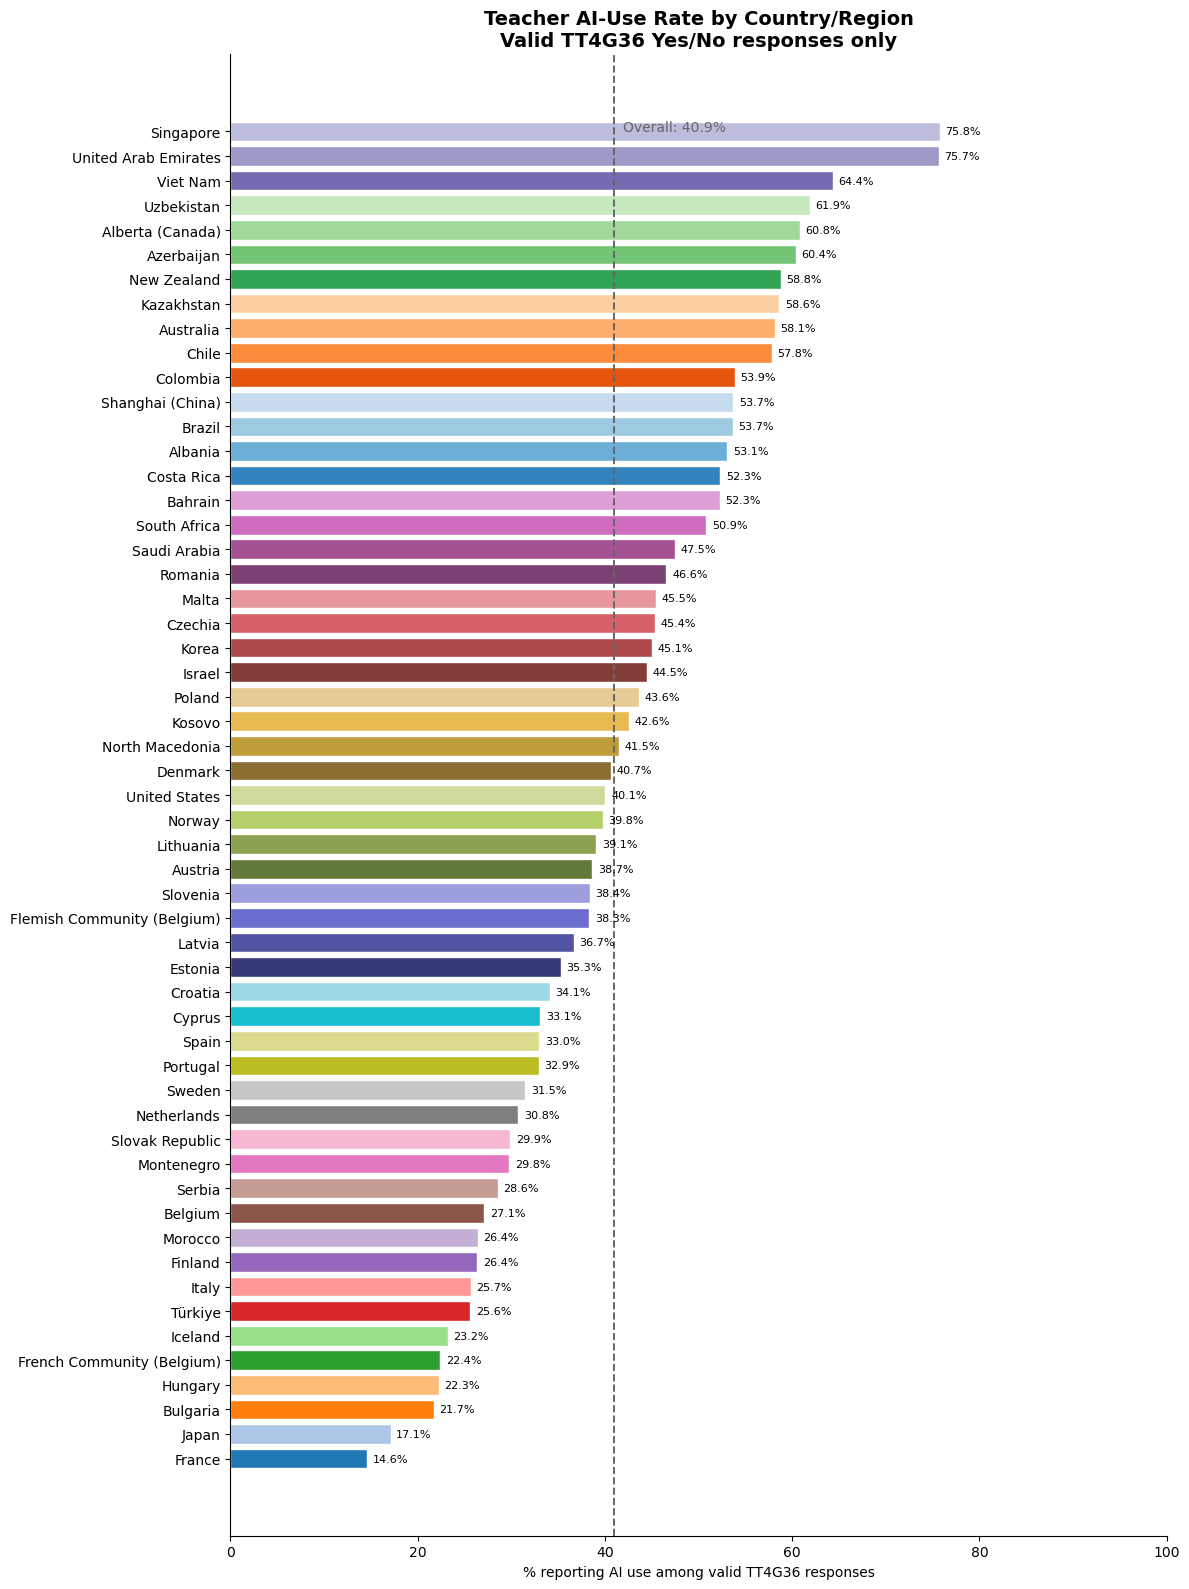

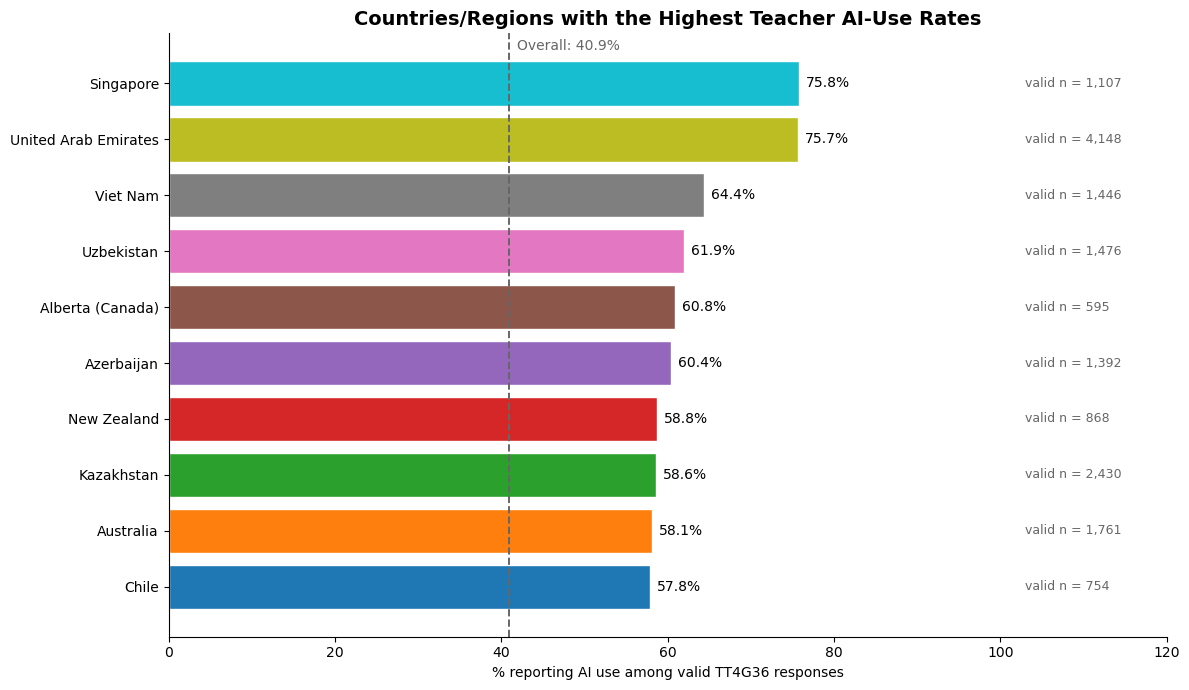

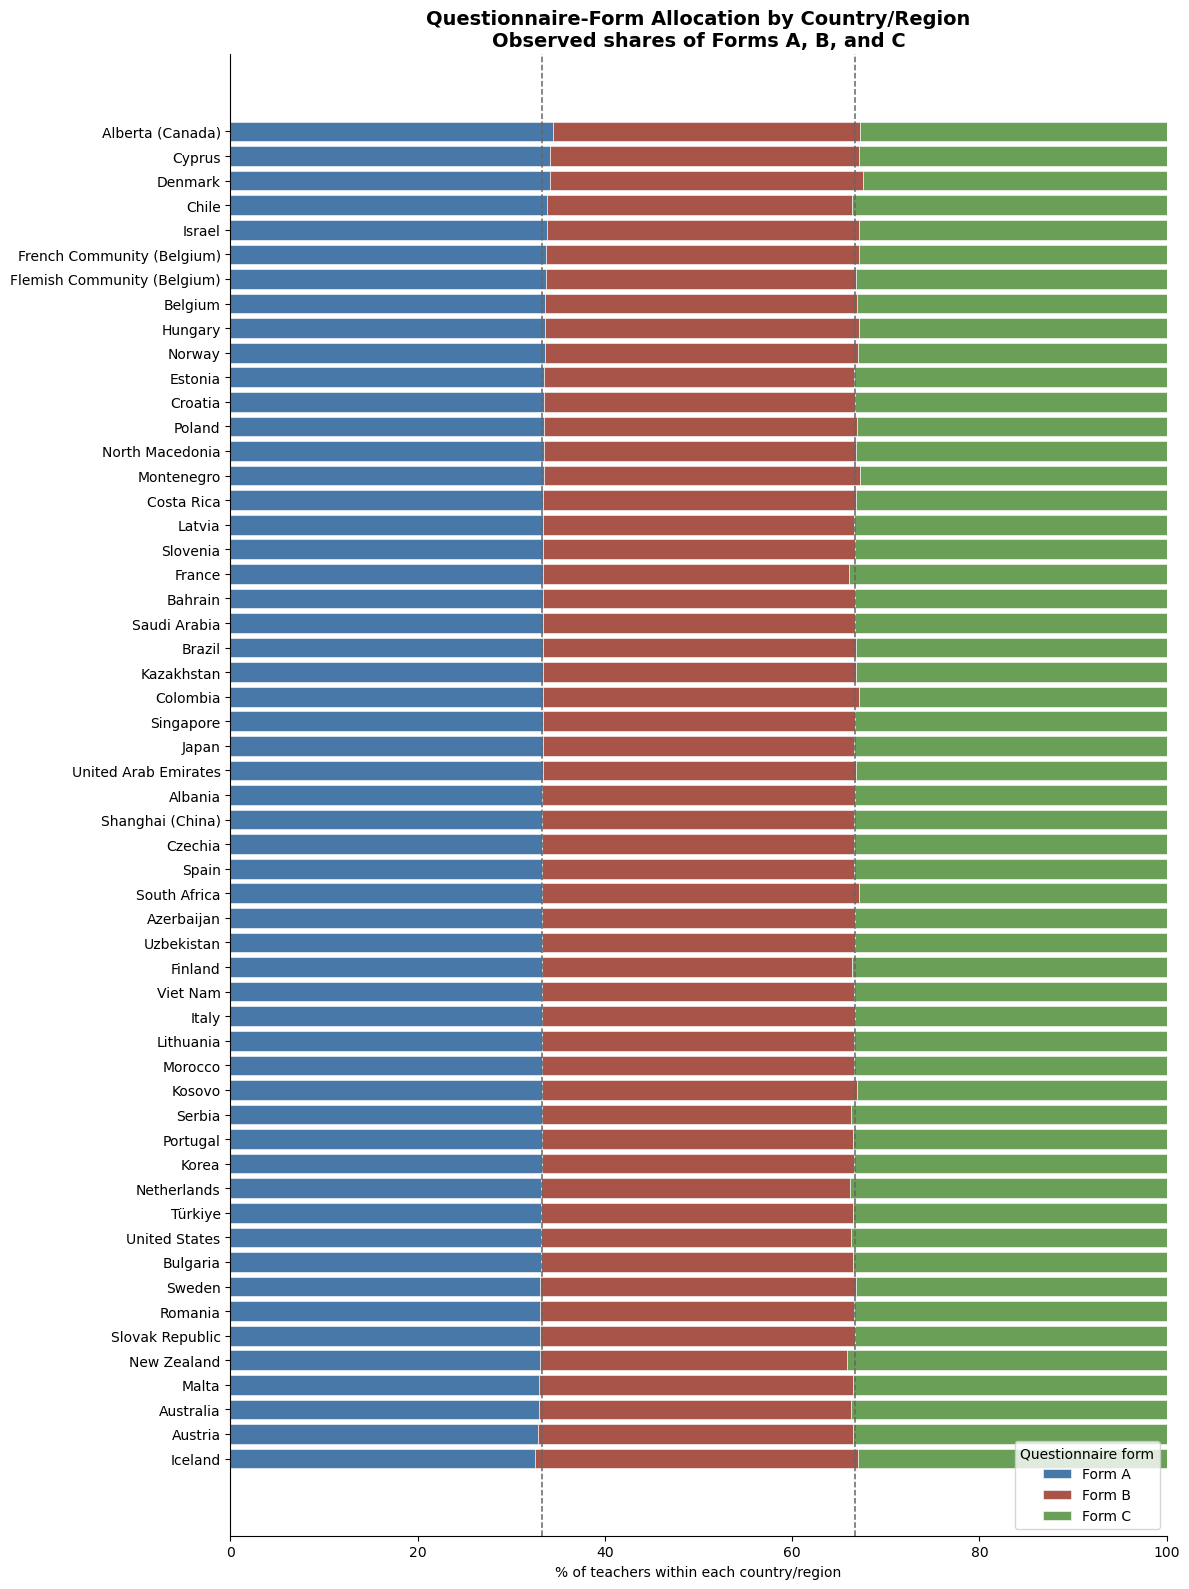

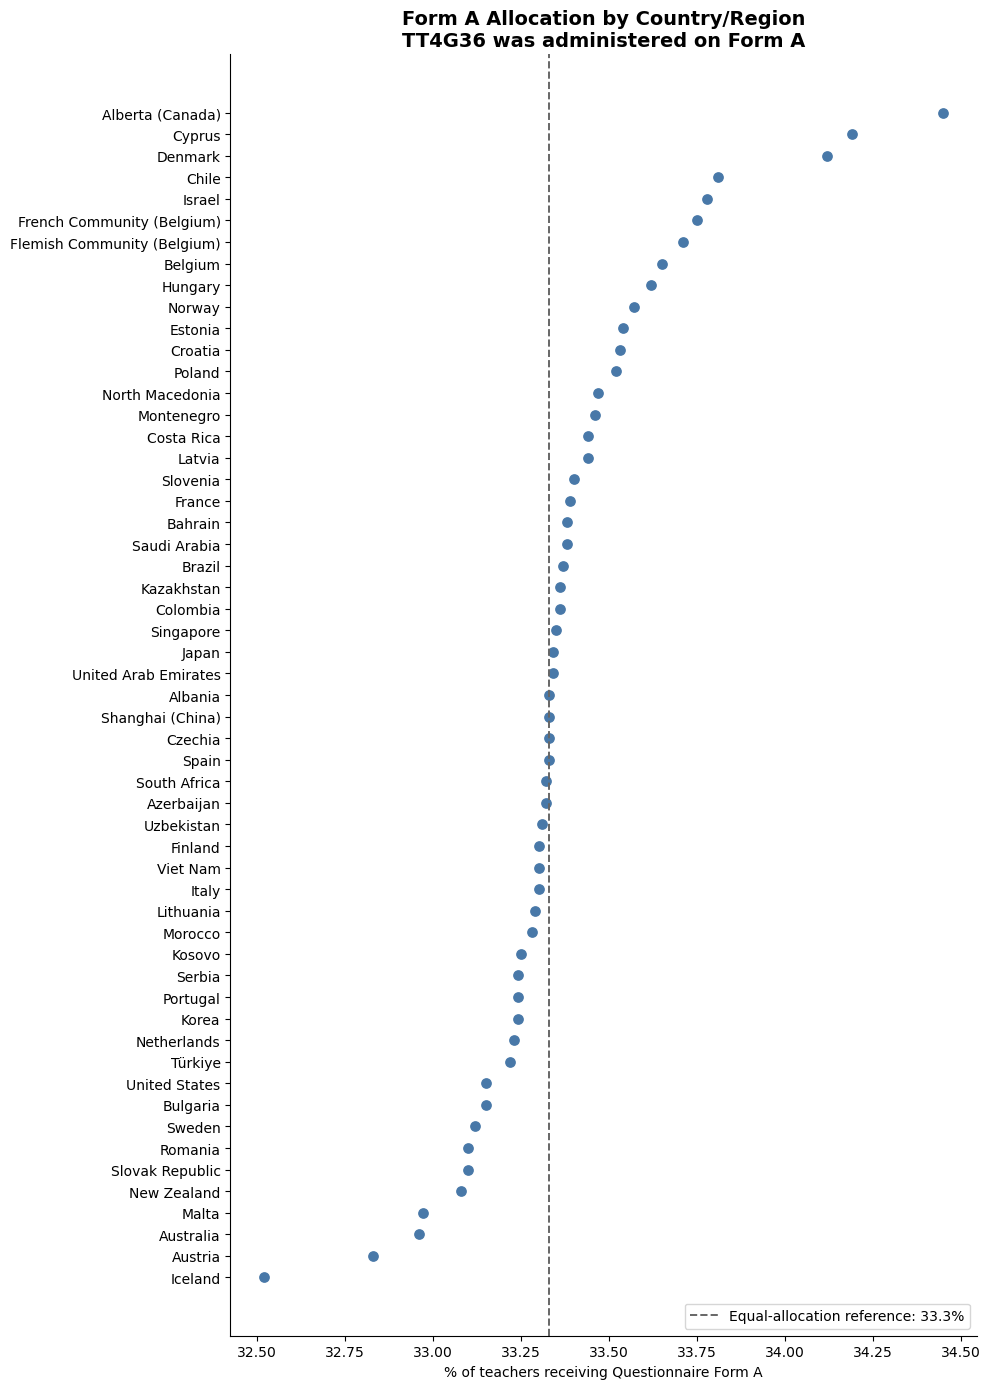

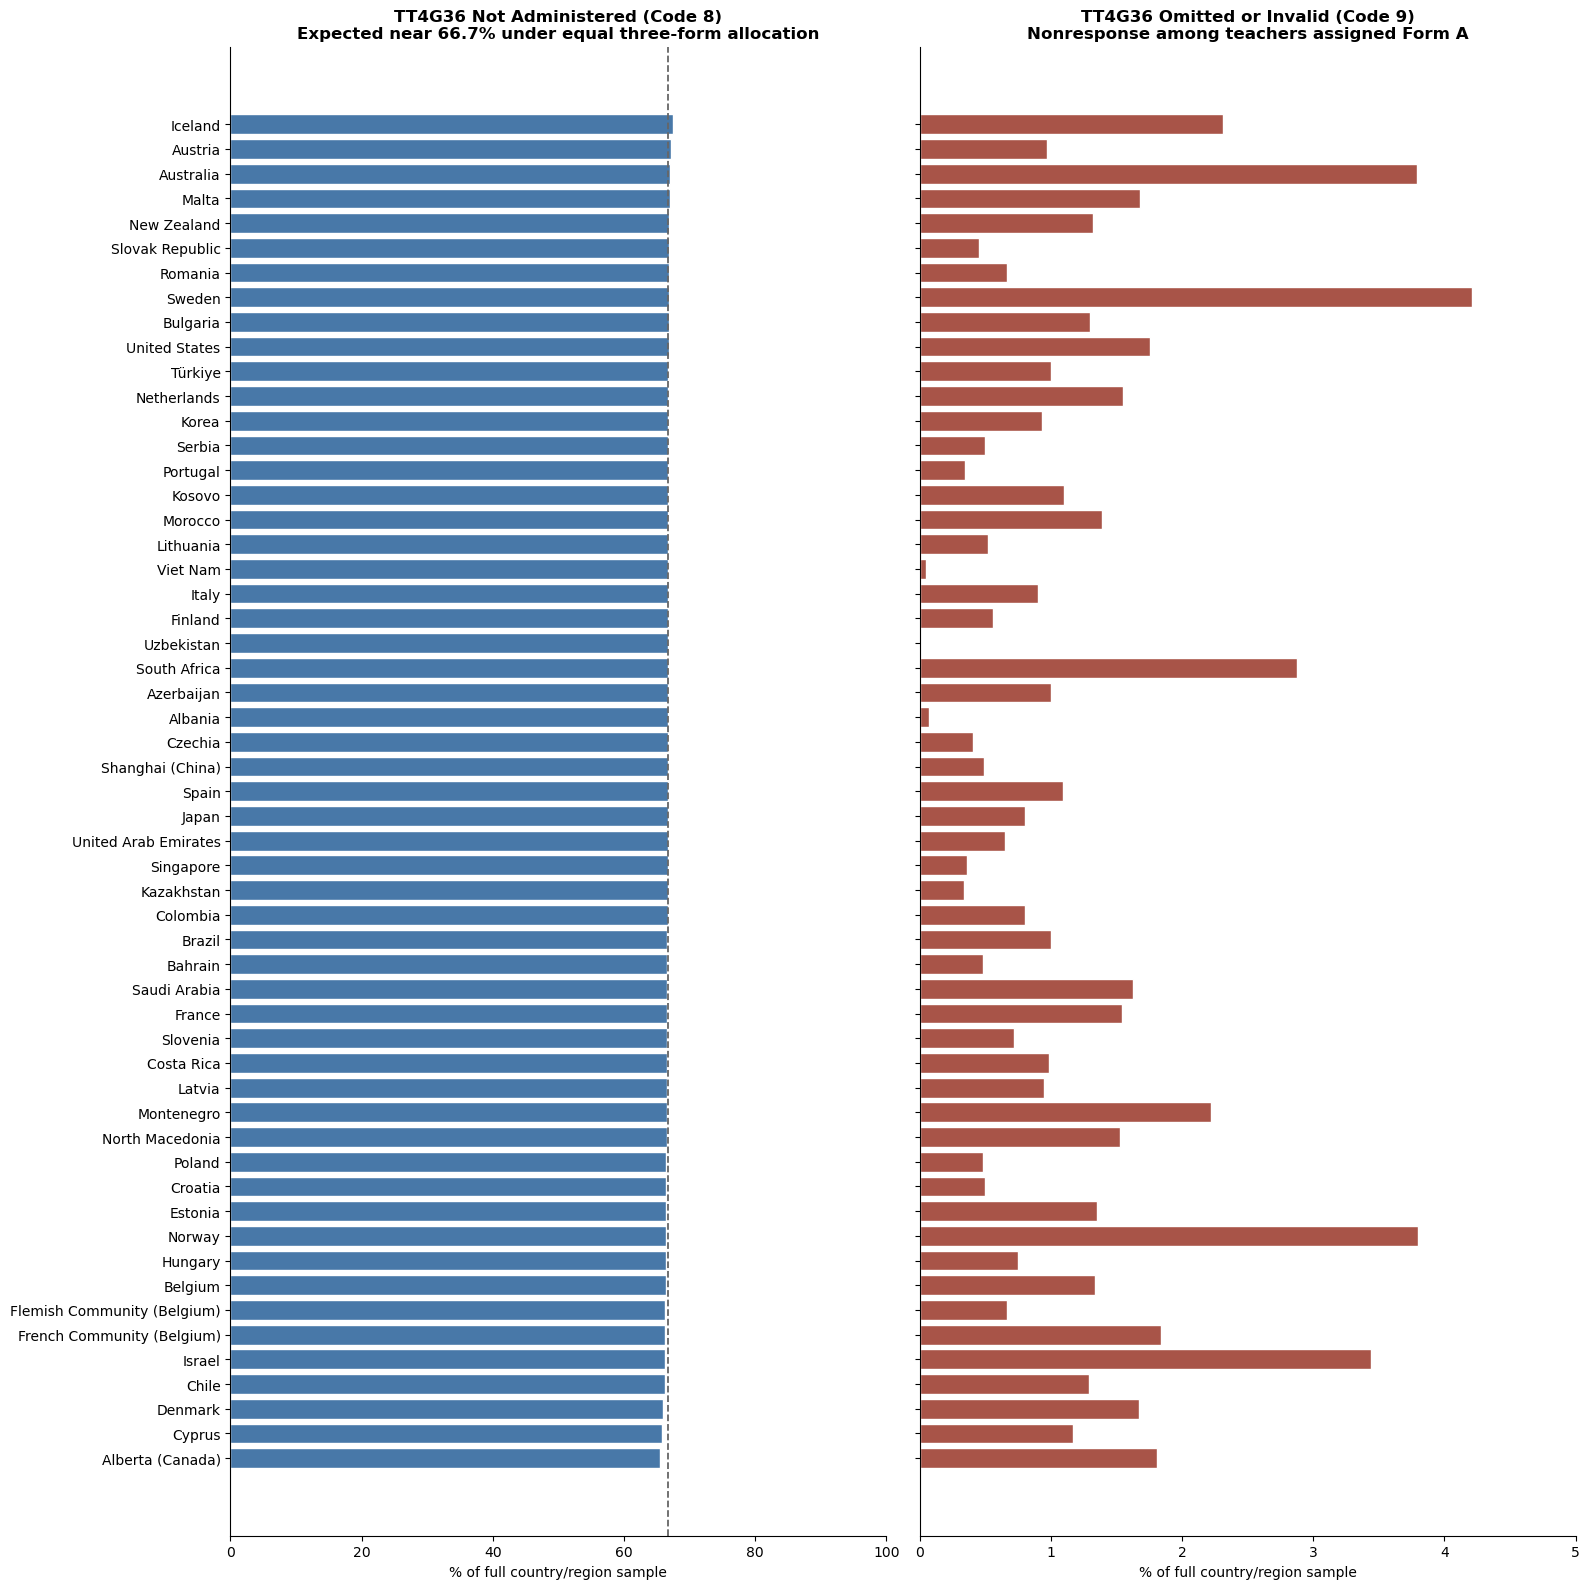


Saved country/region summary tables and figures.
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\rq1_all_country_region_ai_use_rate.png
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\rq1_top10_country_region_ai_use_rate.png
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\questionnaire_form_allocation_by_country_region.png
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\questionnaire_form_a_percentage_by_country_region.png
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\tt4g36_administration_status_by_country_region.png


In [5]:
# ============================================================
# CELL 5 — RQ1 EDA: AI use and questionnaire-form coverage
#          by country/region
# ============================================================

# TT4G36:
# 1 = Yes
# 2 = No
# 8 = Not administered
# 9 = Omitted or invalid
#
# TALIS 2024 used a rotated questionnaire design.
# TT4G36 appeared on Form A only in this dataset.
#
# This cell examines:
# 1. AI-use rates among valid TT4G36 Yes/No respondents
# 2. Questionnaire-form allocation within countries/regions
# 3. TT4G36 not-administered and omitted/invalid rates
#
# Denominators:
# - AI-use rate: RQ1 analytic sample with valid Yes/No responses
# - Form allocation and administration coverage: full teacher sample

# ------------------------------------------------------------
# 5.1 Country/region AI-use summary
# ------------------------------------------------------------

country_ai_summary = (
    rq1_df
    .groupby(
        ["CNTRY", "country_name"],
        observed=True
    )
    .agg(
        valid_n=("ai_use_yes", "size"),
        yes_count=("ai_use_yes", "sum"),
        ai_use_rate=("ai_use_yes", "mean")
    )
    .reset_index()
)

country_ai_summary["yes_count"] = (
    country_ai_summary["yes_count"]
    .round()
    .astype(int)
)

country_ai_summary["no_count"] = (
    country_ai_summary["valid_n"]
    - country_ai_summary["yes_count"]
).astype(int)

country_ai_summary["ai_use_rate_pct"] = (
    country_ai_summary["ai_use_rate"] * 100
).round(2)

country_ai_summary = (
    country_ai_summary
    .sort_values(
        "ai_use_rate_pct",
        ascending=False
    )
    .reset_index(drop=True)
)

overall_ai_use_rate = (
    rq1_df["ai_use_yes"].mean() * 100
)

print(
    "Number of countries/regions in the RQ1 analytic sample:",
    country_ai_summary["country_name"].nunique()
)

print(
    f"Overall AI-use rate among valid TT4G36 responses: "
    f"{overall_ai_use_rate:.2f}%"
)

print("\nTop 10 countries/regions by AI-use rate:")

display(
    country_ai_summary[
        [
            "country_name",
            "valid_n",
            "yes_count",
            "no_count",
            "ai_use_rate_pct"
        ]
    ].head(10)
)

print("\nBottom 10 countries/regions by AI-use rate:")

display(
    country_ai_summary[
        [
            "country_name",
            "valid_n",
            "yes_count",
            "no_count",
            "ai_use_rate_pct"
        ]
    ].tail(10)
)

# ------------------------------------------------------------
# 5.2 Questionnaire-form allocation by country/region
# ------------------------------------------------------------

form_label_map = {
    1: "Form A",
    2: "Form B",
    3: "Form C"
}

country_form_counts = (
    full_df
    .assign(
        questionnaire_form=full_df["IDTQUEST"].map(form_label_map)
    )
    .groupby(
        [
            "CNTRY",
            "country_name",
            "questionnaire_form"
        ],
        observed=True
    )
    .size()
    .rename("n")
    .reset_index()
)

country_form_summary = (
    country_form_counts
    .pivot_table(
        index=["CNTRY", "country_name"],
        columns="questionnaire_form",
        values="n",
        fill_value=0,
        observed=True
    )
    .reset_index()
)

for form_name in ["Form A", "Form B", "Form C"]:
    if form_name not in country_form_summary.columns:
        country_form_summary[form_name] = 0

country_form_summary["full_n"] = (
    country_form_summary["Form A"]
    + country_form_summary["Form B"]
    + country_form_summary["Form C"]
)

for form_name in ["Form A", "Form B", "Form C"]:
    country_form_summary[f"{form_name}_pct"] = (
        country_form_summary[form_name]
        / country_form_summary["full_n"]
        * 100
    ).round(2)

country_form_summary["max_form_difference_pp"] = (
    country_form_summary[
        ["Form A_pct", "Form B_pct", "Form C_pct"]
    ].max(axis=1)
    -
    country_form_summary[
        ["Form A_pct", "Form B_pct", "Form C_pct"]
    ].min(axis=1)
).round(2)

country_form_summary = (
    country_form_summary
    .sort_values(
        "Form A_pct",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\nQuestionnaire-form allocation by country/region:")

display(
    country_form_summary[
        [
            "country_name",
            "full_n",
            "Form A",
            "Form A_pct",
            "Form B",
            "Form B_pct",
            "Form C",
            "Form C_pct",
            "max_form_difference_pp"
        ]
    ]
)

# ------------------------------------------------------------
# 5.3 TT4G36 administration coverage by country/region
# ------------------------------------------------------------

country_administration_summary = (
    full_df
    .groupby(
        ["CNTRY", "country_name"],
        observed=True
    )
    .agg(
        full_n=("TT4G36", "size"),
        yes_n=("TT4G36", lambda x: x.eq(1).sum()),
        no_n=("TT4G36", lambda x: x.eq(2).sum()),
        not_administered_n=("TT4G36", lambda x: x.eq(8).sum()),
        omitted_invalid_n=("TT4G36", lambda x: x.eq(9).sum())
    )
    .reset_index()
)

country_administration_summary["valid_yes_no_n"] = (
    country_administration_summary["yes_n"]
    + country_administration_summary["no_n"]
)

country_administration_summary["valid_yes_no_pct"] = (
    country_administration_summary["valid_yes_no_n"]
    / country_administration_summary["full_n"]
    * 100
).round(2)

country_administration_summary["not_administered_pct"] = (
    country_administration_summary["not_administered_n"]
    / country_administration_summary["full_n"]
    * 100
).round(2)

country_administration_summary["omitted_invalid_pct"] = (
    country_administration_summary["omitted_invalid_n"]
    / country_administration_summary["full_n"]
    * 100
).round(2)

country_administration_summary = (
    country_administration_summary
    .sort_values(
        "not_administered_pct",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\nTT4G36 administration coverage by country/region:")

display(
    country_administration_summary[
        [
            "country_name",
            "full_n",
            "valid_yes_no_n",
            "valid_yes_no_pct",
            "not_administered_n",
            "not_administered_pct",
            "omitted_invalid_n",
            "omitted_invalid_pct"
        ]
    ]
)

# ------------------------------------------------------------
# 5.4 Combine AI use, form allocation, and coverage
# ------------------------------------------------------------

country_rq1_combined = (
    country_ai_summary
    .merge(
        country_form_summary,
        on=["CNTRY", "country_name"],
        how="left",
        suffixes=("", "_form")
    )
    .merge(
        country_administration_summary,
        on=["CNTRY", "country_name"],
        how="left",
        suffixes=("", "_administration")
    )
)

country_rq1_combined = country_rq1_combined[
    [
        "CNTRY",
        "country_name",
        "full_n",
        "Form A_pct",
        "Form B_pct",
        "Form C_pct",
        "max_form_difference_pp",
        "valid_n",
        "valid_yes_no_pct",
        "not_administered_pct",
        "omitted_invalid_pct",
        "yes_count",
        "no_count",
        "ai_use_rate_pct"
    ]
]

country_rq1_combined = (
    country_rq1_combined
    .sort_values(
        "ai_use_rate_pct",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\nCombined RQ1 country/region summary:")

display(country_rq1_combined.head(10))

# ------------------------------------------------------------
# 5.5 Summary of questionnaire-form balance
# ------------------------------------------------------------

form_balance_summary = pd.DataFrame({
    "measure": [
        "Form A",
        "Form B",
        "Form C",
        "TT4G36 valid Yes/No",
        "TT4G36 not administered",
        "TT4G36 omitted or invalid"
    ],
    "minimum_pct": [
        country_form_summary["Form A_pct"].min(),
        country_form_summary["Form B_pct"].min(),
        country_form_summary["Form C_pct"].min(),
        country_administration_summary["valid_yes_no_pct"].min(),
        country_administration_summary["not_administered_pct"].min(),
        country_administration_summary["omitted_invalid_pct"].min()
    ],
    "mean_pct": [
        country_form_summary["Form A_pct"].mean(),
        country_form_summary["Form B_pct"].mean(),
        country_form_summary["Form C_pct"].mean(),
        country_administration_summary["valid_yes_no_pct"].mean(),
        country_administration_summary["not_administered_pct"].mean(),
        country_administration_summary["omitted_invalid_pct"].mean()
    ],
    "maximum_pct": [
        country_form_summary["Form A_pct"].max(),
        country_form_summary["Form B_pct"].max(),
        country_form_summary["Form C_pct"].max(),
        country_administration_summary["valid_yes_no_pct"].max(),
        country_administration_summary["not_administered_pct"].max(),
        country_administration_summary["omitted_invalid_pct"].max()
    ]
})

form_balance_summary[
    ["minimum_pct", "mean_pct", "maximum_pct"]
] = form_balance_summary[
    ["minimum_pct", "mean_pct", "maximum_pct"]
].round(2)

print("\nCountry-level percentage ranges:")

display(form_balance_summary)

print(
    "\nLargest difference among Forms A, B, and C "
    "within a country/region:"
)

print(
    f"{country_form_summary['max_form_difference_pp'].max():.2f} "
    "percentage points"
)

# ------------------------------------------------------------
# 5.6 Color palettes for AI-use charts
# ------------------------------------------------------------

# Large palette for all 55 countries/regions
all_country_colors = (
    list(plt.cm.tab20.colors)
    + list(plt.cm.tab20b.colors)
    + list(plt.cm.tab20c.colors)
)

# Ten-color palette for the top-10 chart
top10_colors = list(plt.cm.tab10.colors)

# ------------------------------------------------------------
# 5.7 Plot AI-use rates for all countries/regions
# ------------------------------------------------------------

all_country_ai_plot = (
    country_ai_summary
    .sort_values(
        "ai_use_rate_pct",
        ascending=True
    )
    .copy()
)

fig, ax = plt.subplots(figsize=(12, 16))

bars = ax.barh(
    all_country_ai_plot["country_name"],
    all_country_ai_plot["ai_use_rate_pct"],
    color=[
        all_country_colors[i % len(all_country_colors)]
        for i in range(len(all_country_ai_plot))
    ],
    edgecolor="white"
)

ax.bar_label(
    bars,
    labels=[
        f"{value:.1f}%"
        for value in all_country_ai_plot["ai_use_rate_pct"]
    ],
    padding=4,
    fontsize=8
)

ax.axvline(
    overall_ai_use_rate,
    linestyle="--",
    linewidth=1.4,
    color="#666666"
)

ax.text(
    overall_ai_use_rate + 1,
    len(all_country_ai_plot) - 1,
    f"Overall: {overall_ai_use_rate:.1f}%",
    fontsize=10,
    color="#666666"
)

ax.set_xlim(0, 100)

ax.set_xlabel(
    "% reporting AI use among valid TT4G36 responses"
)

ax.set_ylabel("")

ax.set_title(
    "Teacher AI-Use Rate by Country/Region\n"
    "Valid TT4G36 Yes/No responses only",
    fontsize=14,
    weight="bold"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

all_country_ai_plot_path = (
    output_dir
    / "rq1_all_country_region_ai_use_rate.png"
)

plt.savefig(
    all_country_ai_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 5.8 Plot top 10 countries/regions by AI-use rate
# ------------------------------------------------------------

top10_country_ai_plot = (
    country_ai_summary
    .head(10)
    .sort_values(
        "ai_use_rate_pct",
        ascending=True
    )
    .copy()
)

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(
    top10_country_ai_plot["country_name"],
    top10_country_ai_plot["ai_use_rate_pct"],
    color=top10_colors[:len(top10_country_ai_plot)],
    edgecolor="white"
)

ax.bar_label(
    bars,
    labels=[
        f"{value:.1f}%"
        for value in top10_country_ai_plot["ai_use_rate_pct"]
    ],
    padding=5,
    fontsize=10
)

for i, (_, row) in enumerate(
    top10_country_ai_plot.iterrows()
):
    ax.text(
        103,
        i,
        f"valid n = {int(row['valid_n']):,}",
        va="center",
        fontsize=9,
        color="#666666"
    )

ax.axvline(
    overall_ai_use_rate,
    linestyle="--",
    linewidth=1.4,
    color="#666666"
)

ax.text(
    overall_ai_use_rate + 1,
    len(top10_country_ai_plot) - 0.4,
    f"Overall: {overall_ai_use_rate:.1f}%",
    fontsize=10,
    color="#666666"
)

ax.set_xlim(0, 120)

ax.set_xlabel(
    "% reporting AI use among valid TT4G36 responses"
)

ax.set_ylabel("")

ax.set_title(
    "Countries/Regions with the Highest Teacher AI-Use Rates",
    fontsize=14,
    weight="bold"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

top10_country_ai_plot_path = (
    output_dir
    / "rq1_top10_country_region_ai_use_rate.png"
)

plt.savefig(
    top10_country_ai_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 5.9 Plot questionnaire-form allocation
# ------------------------------------------------------------

form_plot_df = (
    country_form_summary
    .sort_values(
        "Form A_pct",
        ascending=True
    )
    .copy()
)

fig, ax = plt.subplots(figsize=(12, 16))

left_values = np.zeros(len(form_plot_df))

form_colors = {
    "Form A": "#4878a8",
    "Form B": "#a85448",
    "Form C": "#6a9f58"
}

for form_name in ["Form A", "Form B", "Form C"]:

    form_values = (
        form_plot_df[f"{form_name}_pct"]
        .to_numpy()
    )

    ax.barh(
        form_plot_df["country_name"],
        form_values,
        left=left_values,
        label=form_name,
        color=form_colors[form_name],
        edgecolor="white",
        linewidth=0.4
    )

    left_values = left_values + form_values

ax.axvline(
    33.33,
    linestyle="--",
    linewidth=1.1,
    color="#666666"
)

ax.axvline(
    66.67,
    linestyle="--",
    linewidth=1.1,
    color="#666666"
)

ax.set_xlim(0, 100)

ax.set_xlabel(
    "% of teachers within each country/region"
)

ax.set_ylabel("")

ax.set_title(
    "Questionnaire-Form Allocation by Country/Region\n"
    "Observed shares of Forms A, B, and C",
    fontsize=14,
    weight="bold"
)

ax.legend(
    title="Questionnaire form",
    loc="lower right"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

form_allocation_plot_path = (
    output_dir
    / "questionnaire_form_allocation_by_country_region.png"
)

plt.savefig(
    form_allocation_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 5.10 Plot Form A percentage using a compact dot plot
# ------------------------------------------------------------

form_a_plot_df = (
    country_form_summary
    .sort_values(
        "Form A_pct",
        ascending=True
    )
    .copy()
)

fig, ax = plt.subplots(figsize=(10, 14))

ax.scatter(
    form_a_plot_df["Form A_pct"],
    form_a_plot_df["country_name"],
    s=45,
    color="#4878a8"
)

ax.axvline(
    33.33,
    linestyle="--",
    linewidth=1.4,
    color="#666666",
    label="Equal-allocation reference: 33.3%"
)

ax.set_xlabel(
    "% of teachers receiving Questionnaire Form A"
)

ax.set_ylabel("")

ax.set_title(
    "Form A Allocation by Country/Region\n"
    "TT4G36 was administered on Form A",
    fontsize=14,
    weight="bold"
)

ax.legend(loc="lower right")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

form_a_plot_path = (
    output_dir
    / "questionnaire_form_a_percentage_by_country_region.png"
)

plt.savefig(
    form_a_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 5.11 Plot TT4G36 administration status
# ------------------------------------------------------------

coverage_plot_df = (
    country_administration_summary
    .sort_values(
        "not_administered_pct",
        ascending=True
    )
    .copy()
)

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(16, 16),
    sharey=True
)

axes[0].barh(
    coverage_plot_df["country_name"],
    coverage_plot_df["not_administered_pct"],
    color="#4878a8",
    edgecolor="white"
)

axes[0].axvline(
    66.67,
    linestyle="--",
    linewidth=1.3,
    color="#666666"
)

axes[0].set_xlim(0, 100)

axes[0].set_xlabel("% of full country/region sample")

axes[0].set_ylabel("")

axes[0].set_title(
    "TT4G36 Not Administered (Code 8)\n"
    "Expected near 66.7% under equal three-form allocation",
    fontsize=12,
    weight="bold"
)

axes[1].barh(
    coverage_plot_df["country_name"],
    coverage_plot_df["omitted_invalid_pct"],
    color="#a85448",
    edgecolor="white"
)

omitted_invalid_upper_limit = max(
    5,
    coverage_plot_df["omitted_invalid_pct"].max() * 1.15
)

axes[1].set_xlim(
    0,
    omitted_invalid_upper_limit
)

axes[1].set_xlabel("% of full country/region sample")

axes[1].set_ylabel("")

axes[1].set_title(
    "TT4G36 Omitted or Invalid (Code 9)\n"
    "Nonresponse among teachers assigned Form A",
    fontsize=12,
    weight="bold"
)

for axis in axes:
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)

plt.tight_layout()

coverage_plot_path = (
    output_dir
    / "tt4g36_administration_status_by_country_region.png"
)

plt.savefig(
    coverage_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 5.12 Save summary tables
# ------------------------------------------------------------

country_ai_summary.to_csv(
    output_dir
    / "rq1_ai_use_rate_by_country_region.csv",
    index=False
)

country_form_summary.to_csv(
    output_dir
    / "questionnaire_form_allocation_by_country_region.csv",
    index=False
)

country_administration_summary.to_csv(
    output_dir
    / "tt4g36_administration_by_country_region.csv",
    index=False
)

country_rq1_combined.to_csv(
    output_dir
    / "rq1_country_region_combined_summary.csv",
    index=False
)

form_balance_summary.to_csv(
    output_dir
    / "questionnaire_form_balance_summary.csv",
    index=False
)

print("\nSaved country/region summary tables and figures.")

print("Saved:", all_country_ai_plot_path)
print("Saved:", top10_country_ai_plot_path)
print("Saved:", form_allocation_plot_path)
print("Saved:", form_a_plot_path)
print("Saved:", coverage_plot_path)

### Key findings: AI use across countries and regions

Among 89,833 teachers with valid responses to `TT4G36`, 40.92% reported using AI during the previous 12 months. Reported AI-use rates varied substantially across countries and regions, ranging from 14.64% in France to 75.79% in Singapore. The highest AI-use rates were observed in Singapore (75.8%) and the United Arab Emirates (75.7%), followed by Viet Nam (64.4%), Uzbekistan (61.9%), and Alberta, Canada (60.8%). This cross-country variation suggests that country/region is an important contextual factor to consider in RQ1 when predicting whether teachers reported using AI.


### Questionnaire design and outcome coding

The original TALIS AI-use item, `TT4G36`, asked whether teachers had used artificial intelligence in their teaching or to facilitate student learning during the previous 12 months. Its original response codes were:

- `1 = Yes`
- `2 = No`
- `8 = Not administered`
- `9 = Omitted or invalid`

For the RQ1 analysis, the variable was recoded into a binary outcome:

- `1 = Used AI` (original response `1 = Yes`)
- `0 = Did not use AI` (original response `2 = No`)

Responses coded as `8 = Not administered` or `9 = Omitted or invalid` were set to missing and excluded from the RQ1 analytic sample. In particular, teachers who were not administered the item were not classified as teachers who did not use AI.


### Questionnaire-form balance

Questionnaire Forms A, B, and C were distributed in very similar proportions across countries and regions. Form A represented 32.52%–34.45% of teachers, and the largest difference among the three form shares within any country or region was only 2.03 percentage points.

Because the AI-use question (`TT4G36`) appeared on Form A, country-level not-administered rates were close to the expected two-thirds level, ranging from 65.55% to 67.48%. Omitted or invalid responses were much lower, averaging 1.22% across countries and regions. These results support the decision to treat planned non-administration separately from teachers’ actual Yes or No responses.

School-level composition by sample:


,school_level,n,sample,percent_within_sample
0,Primary,55637,Full teacher sample,19.99
1,Lower secondary,194521,Full teacher sample,69.88
2,Upper secondary,28225,Full teacher sample,10.14
3,Primary,17892,RQ1 analytic sample,19.92
4,Lower secondary,62763,RQ1 analytic sample,69.87
5,Upper secondary,9178,RQ1 analytic sample,10.22
6,Primary,6352,AI-user base sample,17.28
7,Lower secondary,26268,AI-user base sample,71.45
8,Upper secondary,4142,AI-user base sample,11.27



School-level composition by sample, percentages:


sample,school_level,Full teacher sample,RQ1 analytic sample,AI-user base sample
0,Primary,19.99,19.92,17.28
1,Lower secondary,69.88,69.87,71.45
2,Upper secondary,10.14,10.22,11.27


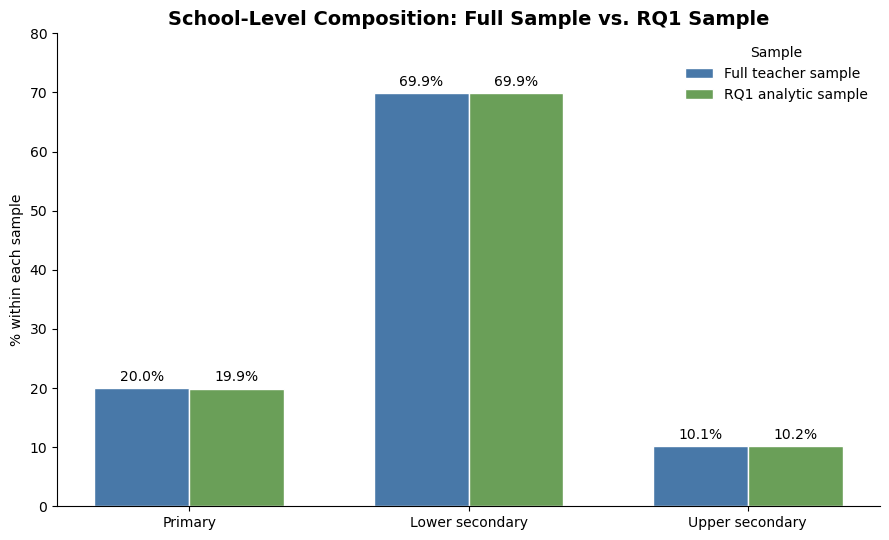

Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\school_level_composition_full_vs_rq1.png

AI-use rate by school level:


,isced_label,valid_n,yes_count,no_count,ai_use_rate_pct
0,Primary,17892,6352,11540,35.50
1,Lower secondary,62763,26268,36495,41.85
2,Upper secondary,9178,4142,5036,45.13


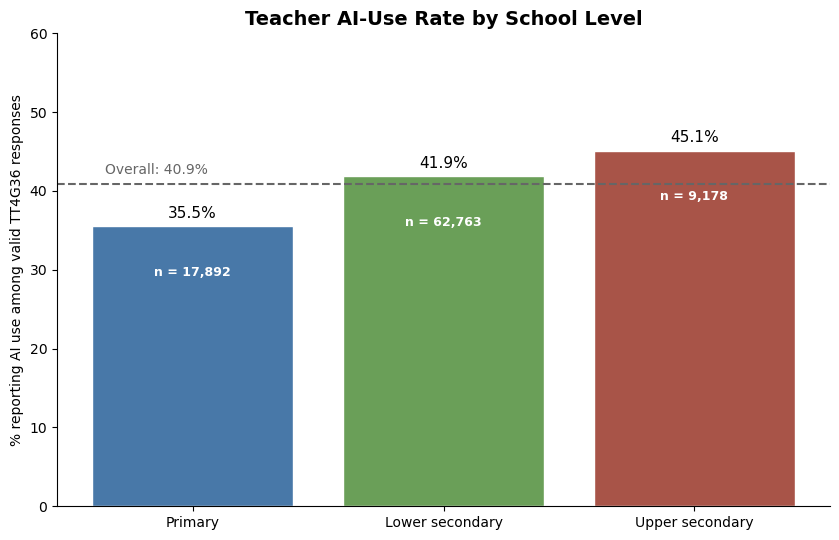


Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\school_level_composition_by_initial_sample_long.csv
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\school_level_composition_by_initial_sample_wide.csv
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\rq1_ai_use_rate_by_school_level.csv
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\school_level_composition_full_vs_rq1.png
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\rq1_ai_use_rate_by_school_level.png


In [6]:
# ============================================================
# CELL 6 — RQ1 EDA: AI-use rate by school level
# ============================================================

# IDCNTPOP:
# Country/region alpha code combined with ISCED level
#
# Derived school-level variable:
# 1 = Primary
# 2 = Lower secondary
# 3 = Upper secondary
#
# RQ1 binary outcome:
# ai_use_yes = 1 if the original TT4G36 response was 1 (Yes)
# ai_use_yes = 0 if the original TT4G36 response was 2 (No)
#
# RQ1 analytic sample:
# Teachers with valid Yes/No responses to TT4G36

school_level_order = [
    "Primary",
    "Lower secondary",
    "Upper secondary"
]

# ------------------------------------------------------------
# 6.1 Check school-level composition across initial samples
# ------------------------------------------------------------

def summarize_school_level(data, sample_name):
    """
    Summarize the distribution of ISCED school levels
    within a specified analytic sample.
    """

    summary = (
        data["isced_label"]
        .value_counts(
            sort=False,
            dropna=False
        )
        .rename_axis("school_level")
        .reset_index(name="n")
    )

    summary["sample"] = sample_name

    summary["percent_within_sample"] = (
        summary["n"]
        / len(data)
        * 100
    ).round(2)

    return summary


school_level_sample_summary = pd.concat(
    [
        summarize_school_level(
            full_sample_df,
            "Full teacher sample"
        ),
        summarize_school_level(
            rq1_df,
            "RQ1 analytic sample"
        ),
        summarize_school_level(
            ai_user_base_df,
            "AI-user base sample"
        )
    ],
    ignore_index=True
)

school_level_sample_summary["school_level"] = pd.Categorical(
    school_level_sample_summary["school_level"],
    categories=school_level_order,
    ordered=True
)

sample_order = [
    "Full teacher sample",
    "RQ1 analytic sample",
    "AI-user base sample"
]

school_level_sample_summary["sample"] = pd.Categorical(
    school_level_sample_summary["sample"],
    categories=sample_order,
    ordered=True
)

school_level_sample_summary = (
    school_level_sample_summary
    .sort_values(
        ["sample", "school_level"]
    )
    .reset_index(drop=True)
)

print("School-level composition by sample:")

display(school_level_sample_summary)

school_level_sample_wide = (
    school_level_sample_summary
    .pivot(
        index="school_level",
        columns="sample",
        values="percent_within_sample"
    )
    .reset_index()
)

print("\nSchool-level composition by sample, percentages:")

display(school_level_sample_wide)

# ------------------------------------------------------------
# 6.2 Plot school-level composition:
#     full teacher sample vs. RQ1 analytic sample
# ------------------------------------------------------------

composition_sample_order = [
    "Full teacher sample",
    "RQ1 analytic sample"
]

composition_plot_df = (
    school_level_sample_summary
    .loc[
        school_level_sample_summary["sample"].isin(
            composition_sample_order
        )
    ]
    .pivot(
        index="school_level",
        columns="sample",
        values="percent_within_sample"
    )
    .reindex(school_level_order)
)

composition_plot_df = composition_plot_df[
    composition_sample_order
]

x = np.arange(len(composition_plot_df.index))
bar_width = 0.34

sample_colors = {
    "Full teacher sample": "#4878a8",
    "RQ1 analytic sample": "#6a9f58"
}

fig, ax = plt.subplots(figsize=(9, 5.5))

for i, sample_name in enumerate(composition_sample_order):

    values = composition_plot_df[sample_name].to_numpy()

    bars = ax.bar(
        x + (i - 0.5) * bar_width,
        values,
        width=bar_width,
        label=sample_name,
        color=sample_colors[sample_name],
        edgecolor="white"
    )

    ax.bar_label(
        bars,
        labels=[f"{value:.1f}%" for value in values],
        padding=3,
        fontsize=10
    )

ax.set_xticks(x)
ax.set_xticklabels(
    composition_plot_df.index.astype(str)
)

ax.set_ylim(0, 80)
ax.set_ylabel("% within each sample")
ax.set_xlabel("")

ax.set_title(
    "School-Level Composition: Full Sample vs. RQ1 Sample",
    fontsize=14,
    weight="bold"
)

ax.legend(
    title="Sample",
    frameon=False
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

school_level_composition_plot_path = (
    output_dir
    / "school_level_composition_full_vs_rq1.png"
)

plt.savefig(
    school_level_composition_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", school_level_composition_plot_path)

# ------------------------------------------------------------
# 6.3 AI-use rate by school level
# ------------------------------------------------------------

school_level_ai_summary = (
    rq1_df
    .groupby(
        "isced_label",
        observed=True
    )
    .agg(
        valid_n=("ai_use_yes", "size"),
        yes_count=("ai_use_yes", "sum"),
        ai_use_rate=("ai_use_yes", "mean")
    )
    .reset_index()
)

school_level_ai_summary["yes_count"] = (
    school_level_ai_summary["yes_count"]
    .round()
    .astype(int)
)

school_level_ai_summary["no_count"] = (
    school_level_ai_summary["valid_n"]
    - school_level_ai_summary["yes_count"]
).astype(int)

school_level_ai_summary["ai_use_rate_pct"] = (
    school_level_ai_summary["ai_use_rate"]
    * 100
).round(2)

school_level_ai_summary["isced_label"] = pd.Categorical(
    school_level_ai_summary["isced_label"],
    categories=school_level_order,
    ordered=True
)

school_level_ai_summary = (
    school_level_ai_summary
    .sort_values("isced_label")
    .reset_index(drop=True)
)

print("\nAI-use rate by school level:")

display(
    school_level_ai_summary[
        [
            "isced_label",
            "valid_n",
            "yes_count",
            "no_count",
            "ai_use_rate_pct"
        ]
    ]
)

# ------------------------------------------------------------
# 6.4 Plot AI-use rate by school level
# ------------------------------------------------------------

overall_ai_use_rate = (
    rq1_df["ai_use_yes"].mean() * 100
)

school_level_colors = [
    "#4878a8",
    "#6a9f58",
    "#a85448"
]

fig, ax = plt.subplots(figsize=(8.5, 5.5))

bars = ax.bar(
    school_level_ai_summary["isced_label"].astype(str),
    school_level_ai_summary["ai_use_rate_pct"],
    color=school_level_colors,
    edgecolor="white"
)

ax.bar_label(
    bars,
    labels=[
        f"{value:.1f}%"
        for value in school_level_ai_summary["ai_use_rate_pct"]
    ],
    padding=4,
    fontsize=11
)

# Add valid sample size inside each bar
for i, (_, row) in enumerate(
    school_level_ai_summary.iterrows()
):
    ax.text(
        i,
        row["ai_use_rate_pct"] - 5,
        f"n = {int(row['valid_n']):,}",
        ha="center",
        va="top",
        fontsize=9,
        color="white",
        weight="bold"
    )

ax.axhline(
    overall_ai_use_rate,
    linestyle="--",
    linewidth=1.5,
    color="#666666"
)

ax.text(
    -0.35,
    overall_ai_use_rate + 0.8,
    f"Overall: {overall_ai_use_rate:.1f}%",
    fontsize=10,
    color="#666666",
    ha="left",
    va="bottom",
    bbox=dict(
        facecolor="white",
        edgecolor="none",
        alpha=0.9
    )
)

ax.set_ylim(0, 60)

ax.set_ylabel(
    "% reporting AI use among valid TT4G36 responses"
)

ax.set_xlabel("")

ax.set_title(
    "Teacher AI-Use Rate by School Level",
    fontsize=14,
    weight="bold"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

school_level_plot_path = (
    output_dir
    / "rq1_ai_use_rate_by_school_level.png"
)

plt.savefig(
    school_level_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 6.5 Save tables and figures
# ------------------------------------------------------------

school_level_sample_summary.to_csv(
    output_dir
    / "school_level_composition_by_initial_sample_long.csv",
    index=False
)

school_level_sample_wide.to_csv(
    output_dir
    / "school_level_composition_by_initial_sample_wide.csv",
    index=False
)

school_level_ai_summary.to_csv(
    output_dir
    / "rq1_ai_use_rate_by_school_level.csv",
    index=False
)

print(
    "\nSaved:",
    output_dir
    / "school_level_composition_by_initial_sample_long.csv"
)

print(
    "Saved:",
    output_dir
    / "school_level_composition_by_initial_sample_wide.csv"
)

print(
    "Saved:",
    output_dir
    / "rq1_ai_use_rate_by_school_level.csv"
)

print("Saved:", school_level_composition_plot_path)
print("Saved:", school_level_plot_path)

### Key findings: AI use by school level

1. **The RQ1 analytic sample closely matched the full teacher sample in school-level composition.** 
Restricting the analysis to teachers with valid responses to `TT4G36` did not meaningfully change the proportions of primary, lower-secondary, and upper-secondary teachers.

2. **AI use increased across school levels.** 
Among teachers with valid Yes/No responses to `TT4G36`—whether they had used artificial intelligence in their teaching or to facilitate student learning during the previous 12 months—35.50% of primary teachers, 41.85% of lower-secondary teachers, and 45.13% of upper-secondary teachers reported using AI.

This pattern suggests that school level may be an important contextual predictor of teachers’ AI use in RQ1.

RQ1 valid sample: 89,833
AI non-user sample: 53,071
Percent of valid TT4G36 respondents who did not use AI: 59.08%

Codebook check for TT4G38A-F:


,variable_name,official_variable_label,item,valid_value_labels,special_missing_or_skip_codes,recommended_cleaning_note
0,TT4G38A,Teaching in General/ Reasons for not using art...,A,1 = Yes | 2 = No,6 = Logically not applicable | 8 = Not adminis...,"For CSV analysis, recode special codes as miss..."
1,TT4G38B,Teaching in General/ Reasons for not using art...,B,1 = Yes | 2 = No,6 = Logically not applicable | 8 = Not adminis...,"For CSV analysis, recode special codes as miss..."
2,TT4G38C,Teaching in General/ Reasons for not using art...,C,1 = Yes | 2 = No,6 = Logically not applicable | 8 = Not adminis...,"For CSV analysis, recode special codes as miss..."
3,TT4G38D,Teaching in General/ Reasons for not using art...,D,1 = Yes | 2 = No,6 = Logically not applicable | 8 = Not adminis...,"For CSV analysis, recode special codes as miss..."
4,TT4G38E,Teaching in General/ Reasons for not using art...,E,1 = Yes | 2 = No,6 = Logically not applicable | 8 = Not adminis...,"For CSV analysis, recode special codes as miss..."
5,TT4G38F,Teaching in General/ Reasons for not using art...,F,1 = Yes | 2 = No,6 = Logically not applicable | 8 = Not adminis...,"For CSV analysis, recode special codes as miss..."



Special-code check for TT4G38A-F among teachers who did not use AI:


,variable,code_6_logically_not_applicable,code_8_not_administered,code_9_omitted_invalid
0,TT4G38A,0,0,627
1,TT4G38B,0,0,532
2,TT4G38C,0,0,767
3,TT4G38D,0,0,1234
4,TT4G38E,0,0,782
5,TT4G38F,0,0,6551



Reasons for not using AI among teachers who reported no AI use:


,variable,barrier,non_user_sample_n,valid_yes_no_n,valid_response_pct,yes_count,no_count,yes_pct_among_valid,code_6_logically_not_applicable,code_8_not_administered,code_9_omitted_invalid
0,TT4G38A,School lacks the digital infrastructure to use AI,53071,52444,98.82,23126,29318,44.10,0,0,627
1,TT4G38B,Lack the knowledge and skills to teach using AI,53071,52539,99.00,37375,15164,71.14,0,0,532
2,TT4G38C,Do not believe AI should be used in teaching,53071,52304,98.55,24574,27730,46.98,0,0,767
3,TT4G38D,School does not allow AI use in teaching,53071,51837,97.67,6627,45210,12.78,0,0,1234
4,TT4G38E,Feel overwhelmed by integrating new technologies,53071,52289,98.53,18151,34138,34.71,0,0,782
5,TT4G38F,Other,53071,46520,87.66,12158,34362,26.13,0,0,6551


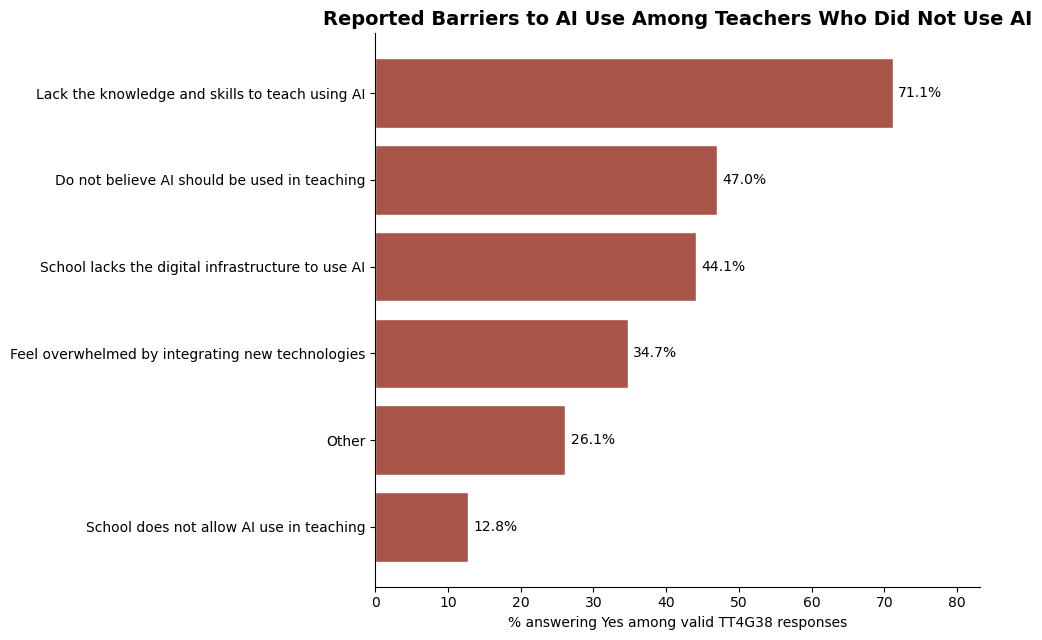


Lack of AI knowledge and skills among non-users by country/region:


,country_name,non_user_n,valid_yes_no_n,yes_count,yes_pct_among_valid
0,Azerbaijan,551,542,170,31.37
1,Kosovo,606,592,258,43.58
2,Uzbekistan,562,562,260,46.26
3,United Arab Emirates,1009,1003,483,48.16
4,North Macedonia,746,731,370,50.62
5,Albania,629,628,323,51.43
6,Kazakhstan,1005,999,531,53.15
7,South Africa,494,489,261,53.37
8,Bulgaria,905,855,468,54.74
9,Romania,671,668,386,57.78


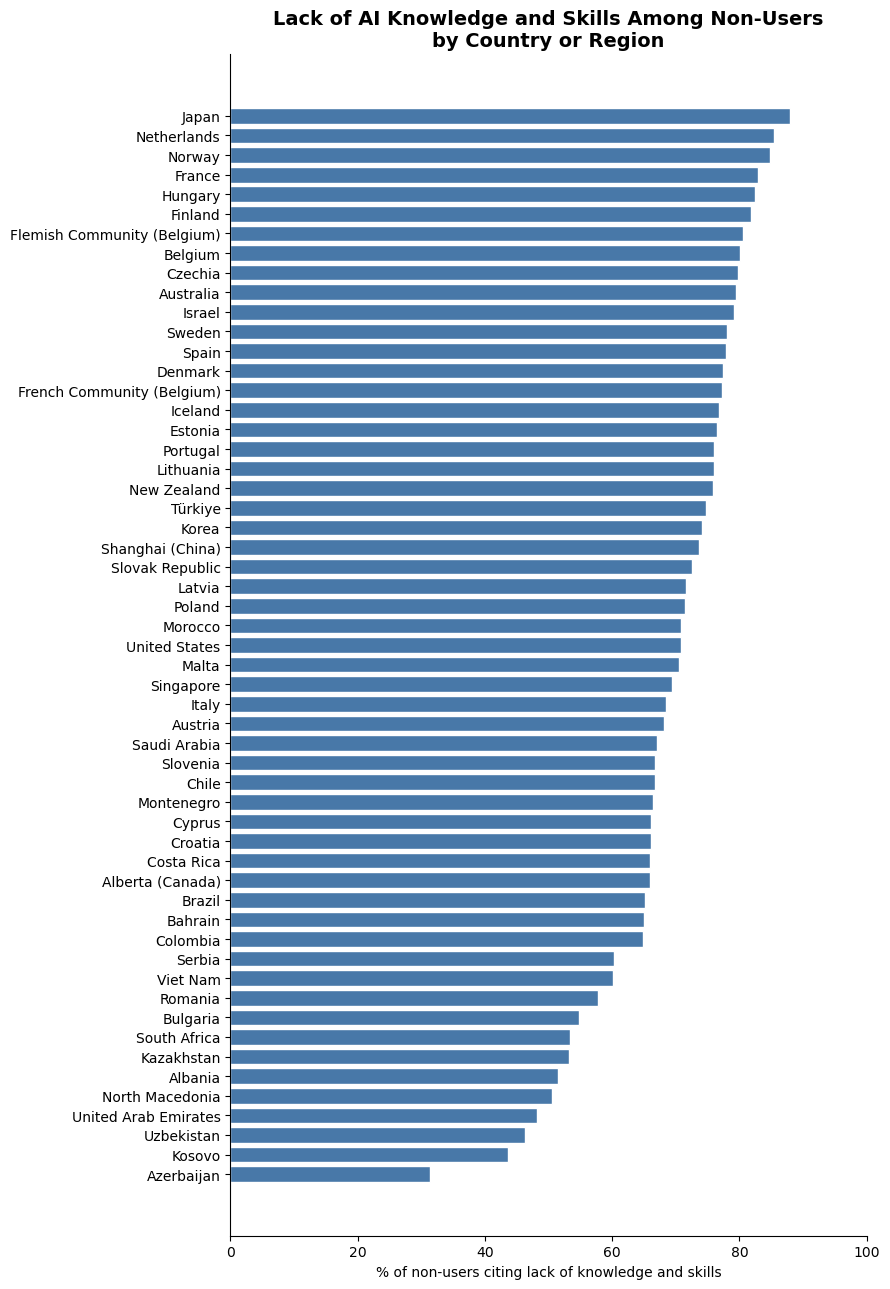


Overlap between lack of knowledge/skills and opposition to using AI:


,Did not oppose AI use,Opposed AI use
Did not cite lack of knowledge/skills,16.36,12.57
Cited lack of knowledge/skills,36.70,34.37



Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\rq1_tt4g38_codebook_check.csv
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\rq1_tt4g38_special_code_check.csv
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\rq1_barriers_to_ai_use_among_non_users.csv
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\rq1_lack_ai_knowledge_skills_by_country.csv
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\rq1_barrier_overlap_knowledge_vs_opposition.csv
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\rq1_barriers_to_ai_use_among_non_users.png
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\rq1_lack_ai_knowledge_skills_by_country.png


In [7]:
# ============================================================
# CELL 7 — RQ1 DESCRIPTIVE EDA:
# Barriers to AI use among teachers who did not use AI
# ============================================================

# TT4G38 asks teachers who answered No to TT4G36 whether
# specific reasons explain why they did not use AI in teaching
# or to facilitate student learning.
#
# This section is descriptive only.
#
# TT4G38 must NOT be used as an RQ1 predictor because it is
# administered only to teachers who did not use AI. Including it
# as a predictor would reveal the outcome and create target leakage.
#
# Original TT4G38 coding:
# 1 = Yes
# 2 = No
# 6 = Logically not applicable
# 8 = Not administered
# 9 = Omitted or invalid

# ------------------------------------------------------------
# 7.0 Define the non-user sample
# ------------------------------------------------------------

# rq1_df contains teachers with valid Yes/No responses to TT4G36.
# ai_use_yes = 0 corresponds to original TT4G36 code 2 = No.

non_user_df = (
    rq1_df
    .loc[rq1_df["ai_use_yes"] == 0]
    .copy()
)

print("RQ1 valid sample:", f"{len(rq1_df):,}")
print("AI non-user sample:", f"{len(non_user_df):,}")

print(
    "Percent of valid TT4G36 respondents who did not use AI:",
    f"{len(non_user_df) / len(rq1_df) * 100:.2f}%"
)

# ------------------------------------------------------------
# 7.1 Define TT4G38 barrier items
# ------------------------------------------------------------

barrier_items = {
    "TT4G38A": (
        "School lacks the digital infrastructure "
        "to use AI"
    ),
    "TT4G38B": (
        "Lack the knowledge and skills "
        "to teach using AI"
    ),
    "TT4G38C": (
        "Do not believe AI should be used "
        "in teaching"
    ),
    "TT4G38D": (
        "School does not allow AI use "
        "in teaching"
    ),
    "TT4G38E": (
        "Feel overwhelmed by integrating "
        "new technologies"
    ),
    "TT4G38F": "Other"
}

barrier_cols = list(barrier_items.keys())

# ------------------------------------------------------------
# 7.2 Compact codebook check for TT4G38A-F
# ------------------------------------------------------------

tt4g38_codebook_check = codebook.loc[
    codebook["variable_name"].isin(barrier_cols),
    [
        "variable_name",
        "official_variable_label",
        "item",
        "valid_value_labels",
        "special_missing_or_skip_codes",
        "recommended_cleaning_note"
    ]
].copy()

tt4g38_codebook_check["variable_name"] = pd.Categorical(
    tt4g38_codebook_check["variable_name"],
    categories=barrier_cols,
    ordered=True
)

tt4g38_codebook_check = (
    tt4g38_codebook_check
    .sort_values("variable_name")
    .reset_index(drop=True)
)

print("\nCodebook check for TT4G38A-F:")

display(tt4g38_codebook_check)

# ------------------------------------------------------------
# 7.3 Special-code check in the non-user sample
# ------------------------------------------------------------

barrier_special_code_rows = []

for col in barrier_cols:

    barrier_special_code_rows.append(
        {
            "variable": col,
            "code_6_logically_not_applicable": int(
                (non_user_df[col] == 6).sum()
            ),
            "code_8_not_administered": int(
                (non_user_df[col] == 8).sum()
            ),
            "code_9_omitted_invalid": int(
                (non_user_df[col] == 9).sum()
            )
        }
    )

barrier_special_code_check = pd.DataFrame(
    barrier_special_code_rows
)

print(
    "\nSpecial-code check for TT4G38A-F "
    "among teachers who did not use AI:"
)

display(barrier_special_code_check)

# ------------------------------------------------------------
# 7.4 Summarize barriers among teachers who did not use AI
# ------------------------------------------------------------

barrier_summary_rows = []

for col, label in barrier_items.items():

    valid_mask = non_user_df[col].isin([1, 2])

    valid_n = int(valid_mask.sum())
    yes_n = int((non_user_df[col] == 1).sum())
    no_n = int((non_user_df[col] == 2).sum())

    barrier_summary_rows.append(
        {
            "variable": col,
            "barrier": label,
            "non_user_sample_n": len(non_user_df),
            "valid_yes_no_n": valid_n,
            "valid_response_pct": round(
                valid_n / len(non_user_df) * 100,
                2
            ),
            "yes_count": yes_n,
            "no_count": no_n,
            "yes_pct_among_valid": round(
                yes_n / valid_n * 100,
                2
            ) if valid_n > 0 else np.nan,
            "code_6_logically_not_applicable": int(
                (non_user_df[col] == 6).sum()
            ),
            "code_8_not_administered": int(
                (non_user_df[col] == 8).sum()
            ),
            "code_9_omitted_invalid": int(
                (non_user_df[col] == 9).sum()
            )
        }
    )

barrier_summary = pd.DataFrame(
    barrier_summary_rows
)

barrier_summary["variable"] = pd.Categorical(
    barrier_summary["variable"],
    categories=barrier_cols,
    ordered=True
)

barrier_summary = (
    barrier_summary
    .sort_values("variable")
    .reset_index(drop=True)
)

print(
    "\nReasons for not using AI among teachers "
    "who reported no AI use:"
)

display(barrier_summary)

# ------------------------------------------------------------
# 7.5 Visualize reported barriers
# ------------------------------------------------------------

barrier_plot_df = (
    barrier_summary
    .sort_values(
        "yes_pct_among_valid",
        ascending=True
    )
    .copy()
)

fig, ax = plt.subplots(figsize=(10, 6.5))

bars = ax.barh(
    barrier_plot_df["barrier"],
    barrier_plot_df["yes_pct_among_valid"],
    color="#a85448",
    edgecolor="white"
)

ax.bar_label(
    bars,
    labels=[
        f"{value:.1f}%"
        for value in barrier_plot_df[
            "yes_pct_among_valid"
        ]
    ],
    padding=4,
    fontsize=10
)

ax.set_xlim(
    0,
    min(
        100,
        barrier_plot_df[
            "yes_pct_among_valid"
        ].max() + 12
    )
)

ax.set_xlabel(
    "% answering Yes among valid TT4G38 responses"
)

ax.set_ylabel("")

ax.set_title(
    "Reported Barriers to AI Use Among Teachers Who Did Not Use AI",
    fontsize=14,
    weight="bold"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

barrier_plot_path = (
    output_dir
    / "rq1_barriers_to_ai_use_among_non_users.png"
)

plt.savefig(
    barrier_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 7.6 Lack of AI knowledge and skills by country/region
# ------------------------------------------------------------

skills_barrier_col = "TT4G38B"

country_skills_barrier_summary = (
    non_user_df
    .groupby(
        "country_name",
        observed=True
    )
    .agg(
        non_user_n=(
            skills_barrier_col,
            "size"
        ),
        valid_yes_no_n=(
            skills_barrier_col,
            lambda x: x.isin([1, 2]).sum()
        ),
        yes_count=(
            skills_barrier_col,
            lambda x: (x == 1).sum()
        )
    )
    .reset_index()
)

country_skills_barrier_summary[
    "yes_pct_among_valid"
] = (
    country_skills_barrier_summary["yes_count"]
    / country_skills_barrier_summary["valid_yes_no_n"]
    * 100
).round(2)

country_skills_barrier_summary = (
    country_skills_barrier_summary
    .sort_values(
        "yes_pct_among_valid",
        ascending=True
    )
    .reset_index(drop=True)
)

print(
    "\nLack of AI knowledge and skills among non-users "
    "by country/region:"
)

display(country_skills_barrier_summary)

# Plot all participating countries/regions

fig, ax = plt.subplots(figsize=(9, 13))

bars = ax.barh(
    country_skills_barrier_summary["country_name"],
    country_skills_barrier_summary[
        "yes_pct_among_valid"
    ],
    color="#4878a8",
    edgecolor="white"
)

ax.set_xlim(0, 100)

ax.set_xlabel(
    "% of non-users citing lack of knowledge and skills"
)

ax.set_ylabel("")

ax.set_title(
    "Lack of AI Knowledge and Skills Among Non-Users\n"
    "by Country or Region",
    fontsize=14,
    weight="bold"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

country_skills_barrier_plot_path = (
    output_dir
    / "rq1_lack_ai_knowledge_skills_by_country.png"
)

plt.savefig(
    country_skills_barrier_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 7.7 Examine overlap between selected barriers
# ------------------------------------------------------------

# Examine whether lack of knowledge/skills and opposition
# to using AI in teaching were reported together.
#
# These are descriptive Boolean indicators only.
# No model outcome coding is created here.

barrier_overlap_df = non_user_df[
    [
        "TT4G38B",
        "TT4G38C"
    ]
].copy()

barrier_overlap_df["lack_knowledge_skills"] = np.where(
    barrier_overlap_df["TT4G38B"].isin([1, 2]),
    barrier_overlap_df["TT4G38B"] == 1,
    np.nan
)

barrier_overlap_df["does_not_support_ai_use"] = np.where(
    barrier_overlap_df["TT4G38C"].isin([1, 2]),
    barrier_overlap_df["TT4G38C"] == 1,
    np.nan
)

barrier_overlap_complete = (
    barrier_overlap_df[
        [
            "lack_knowledge_skills",
            "does_not_support_ai_use"
        ]
    ]
    .dropna()
    .astype(bool)
)

barrier_overlap_table = pd.crosstab(
    barrier_overlap_complete[
        "lack_knowledge_skills"
    ],
    barrier_overlap_complete[
        "does_not_support_ai_use"
    ],
    normalize="all"
).mul(100).round(2)

barrier_overlap_table.index = [
    "Did not cite lack of knowledge/skills",
    "Cited lack of knowledge/skills"
]

barrier_overlap_table.columns = [
    "Did not oppose AI use",
    "Opposed AI use"
]

print(
    "\nOverlap between lack of knowledge/skills "
    "and opposition to using AI:"
)

display(barrier_overlap_table)

# ------------------------------------------------------------
# 7.8 Save tables and figures
# ------------------------------------------------------------

tt4g38_codebook_check.to_csv(
    output_dir
    / "rq1_tt4g38_codebook_check.csv",
    index=False
)

barrier_special_code_check.to_csv(
    output_dir
    / "rq1_tt4g38_special_code_check.csv",
    index=False
)

barrier_summary.to_csv(
    output_dir
    / "rq1_barriers_to_ai_use_among_non_users.csv",
    index=False
)

country_skills_barrier_summary.to_csv(
    output_dir
    / "rq1_lack_ai_knowledge_skills_by_country.csv",
    index=False
)

barrier_overlap_table.to_csv(
    output_dir
    / "rq1_barrier_overlap_knowledge_vs_opposition.csv"
)

print(
    "\nSaved:",
    output_dir
    / "rq1_tt4g38_codebook_check.csv"
)

print(
    "Saved:",
    output_dir
    / "rq1_tt4g38_special_code_check.csv"
)

print(
    "Saved:",
    output_dir
    / "rq1_barriers_to_ai_use_among_non_users.csv"
)

print(
    "Saved:",
    output_dir
    / "rq1_lack_ai_knowledge_skills_by_country.csv"
)

print(
    "Saved:",
    output_dir
    / "rq1_barrier_overlap_knowledge_vs_opposition.csv"
)

print("Saved:", barrier_plot_path)
print("Saved:", country_skills_barrier_plot_path)

### Key findings: Barriers to AI use among non-users

Among teachers who did not use AI, the most commonly reported barrier was a lack of knowledge and skills to teach using AI (71.1%). Other frequently reported barriers included not believing AI should be used in teaching (47.0%) and insufficient school digital infrastructure (44.1%).

Feeling overwhelmed by integrating new technologies was reported by 34.7% of non-users, while school-level restrictions were much less common (12.8%). These barriers are descriptive only and should not be used as predictors of AI use because `TT4G38` was administered only to teachers who reported not using AI.

### RQ2: Predicting the Adoption of Student-Facing AI Use

**Research question:**  
Among teachers who used AI, which factors predict their AI use is student-facing?

#### Student-facing items

- `TT4G37A` — Assess or mark student work
- `TT4G37G` — Review data on student participation or performance
- `TT4G37H` — Help students practise new skills in real-life scenarios

Teachers were classified as having adopted student-facing AI use if they answered “Yes” to at least one of these three items.

#### Teacher-facing items 

- `TT4G37B` — Efficiently learn about and summarise a topic
- `TT4G37C` — Generate lesson plans or activities
- `TT4G37F` — Generate text for student feedback or parent/guardian communication

#### Sensitivity-analysis items

- `TT4G37D` — Support students with special education needs
- `TT4G37E` — Automatically adjust lesson-material difficulty according to students’ learning needs

#### Excluded item

- `TT4G37I` — Other


The final RQ2 analytic sample includes AI users with valid Yes/No responses to all three student-facing items.

Codebook check for TT4G37A-I:


,variable_name,official_variable_label,item,valid_value_labels,special_missing_or_skip_codes,recommended_cleaning_note
0,TT4G37A,Teaching in General/ Used artificial intellige...,A,1 = Yes | 2 = No,6 = Logically not applicable | 8 = Not adminis...,"For CSV analysis, recode special codes as miss..."
1,TT4G37B,Teaching in General/ Used artificial intellige...,B,1 = Yes | 2 = No,6 = Logically not applicable | 8 = Not adminis...,"For CSV analysis, recode special codes as miss..."
2,TT4G37C,Teaching in General/ Used artificial intellige...,C,1 = Yes | 2 = No,6 = Logically not applicable | 8 = Not adminis...,"For CSV analysis, recode special codes as miss..."
3,TT4G37D,Teaching in General/ Used artificial intellige...,D,1 = Yes | 2 = No,6 = Logically not applicable | 8 = Not adminis...,"For CSV analysis, recode special codes as miss..."
4,TT4G37E,Teaching in General/ Used artificial intellige...,E,1 = Yes | 2 = No,6 = Logically not applicable | 8 = Not adminis...,"For CSV analysis, recode special codes as miss..."
5,TT4G37F,Teaching in General/ Used artificial intellige...,F,1 = Yes | 2 = No,6 = Logically not applicable | 8 = Not adminis...,"For CSV analysis, recode special codes as miss..."
6,TT4G37G,Teaching in General/ Used artificial intellige...,G,1 = Yes | 2 = No,6 = Logically not applicable | 8 = Not adminis...,"For CSV analysis, recode special codes as miss..."
7,TT4G37H,Teaching in General/ Used artificial intellige...,H,1 = Yes | 2 = No,6 = Logically not applicable | 8 = Not adminis...,"For CSV analysis, recode special codes as miss..."
8,TT4G37I,Teaching in General/ Used artificial intellige...,I,1 = Yes | 2 = No,6 = Logically not applicable | 8 = Not adminis...,"For CSV analysis, recode special codes as miss..."



Special-code check for TT4G37A-I in the AI-user base sample:


,variable,code_6_logically_not_applicable,code_8_not_administered,code_9_omitted_invalid
0,TT4G37A,0,0,263
1,TT4G37B,0,0,237
2,TT4G37C,0,0,250
3,TT4G37D,0,0,326
4,TT4G37E,0,0,304
5,TT4G37F,0,0,286
6,TT4G37G,0,0,373
7,TT4G37H,0,0,284
8,TT4G37I,0,0,2120



AI-use purposes among teachers who reported using AI:


,variable,item_group,item,ai_user_base_n,valid_yes_no_n,valid_response_pct,yes_count,no_count,yes_pct_among_valid,code_6_logically_not_applicable,code_8_not_administered,code_9_omitted_invalid
0,TT4G37A,Student-facing outcome item,Assess or mark student work,36762,36499,99.28,13393,23106,36.69,0,0,263
1,TT4G37G,Student-facing outcome item,Review student participation or performance data,36762,36389,98.99,14201,22188,39.03,0,0,373
2,TT4G37H,Student-facing outcome item,Help students practise new skills in real-life...,36762,36478,99.23,20122,16356,55.16,0,0,284
3,TT4G37B,Teacher-facing descriptive item,Efficiently learn about and summarise a topic,36762,36525,99.36,26691,9834,73.08,0,0,237
4,TT4G37C,Teacher-facing descriptive item,Generate lesson plans or activities,36762,36512,99.32,26154,10358,71.63,0,0,250
5,TT4G37F,Teacher-facing descriptive item,Generate student feedback or parent communication,36762,36476,99.22,16438,20038,45.07,0,0,286
6,TT4G37D,Sensitivity-analysis item,Support students with special education needs,36762,36436,99.11,15630,20806,42.90,0,0,326
7,TT4G37E,Sensitivity-analysis item,Automatically adjust lesson-material difficulty,36762,36458,99.17,18066,18392,49.55,0,0,304


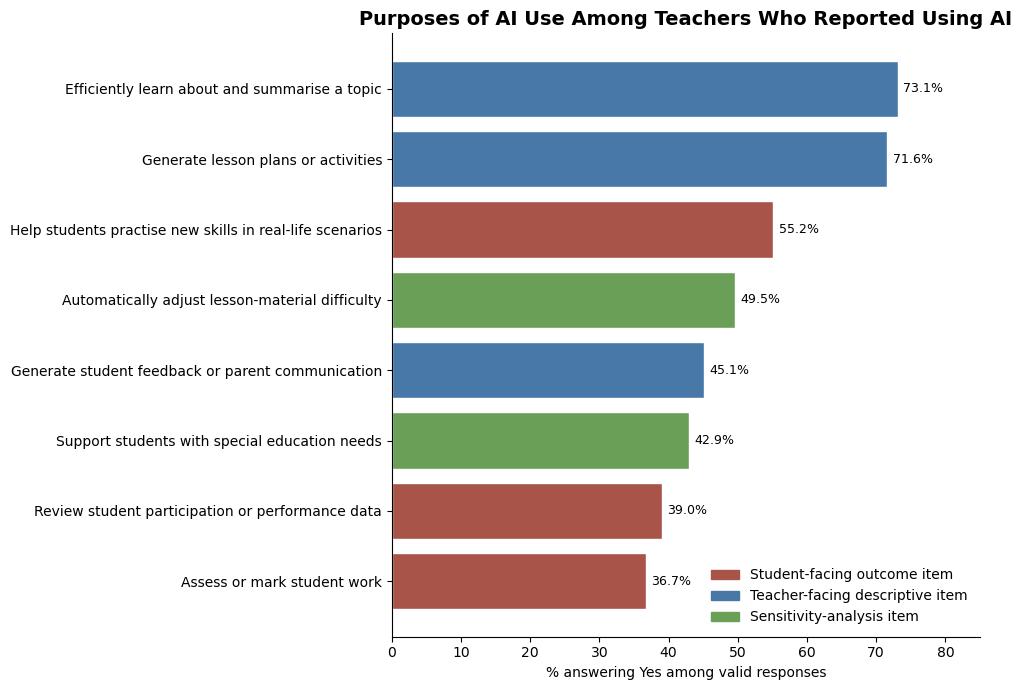


Number of valid required RQ2 items among AI users:


,number_of_valid_required_rq2_items,n,percent_of_ai_user_base
0,0,55,0.15
1,1,46,0.13
2,2,17,0.05
3,3,27,0.07
4,4,75,0.20
5,5,834,2.27
6,6,35708,97.13



Validity of each required RQ2 item:


,variable,valid_yes_no_n,invalid_or_missing_n,valid_response_pct
0,TT4G37A,36499,263,99.28
1,TT4G37G,36389,373,98.99
2,TT4G37H,36478,284,99.23
3,TT4G37B,36525,237,99.36
4,TT4G37C,36512,250,99.32
5,TT4G37F,36476,286,99.22



RQ2 sample construction:
AI-user base sample: 36,762
Final RQ2 analytic sample: 35,708
Excluded because at least one of the six required RQ2 items was not valid Yes/No: 1,054
RQ2 sample retention rate: 97.13%

RQ2 student-facing AI adoption summary:


,student_facing_adoption,n,percent_of_rq2_sample
0,Adopted at least one student-facing use,24919,69.79
1,Did not adopt any student-facing use,10789,30.21


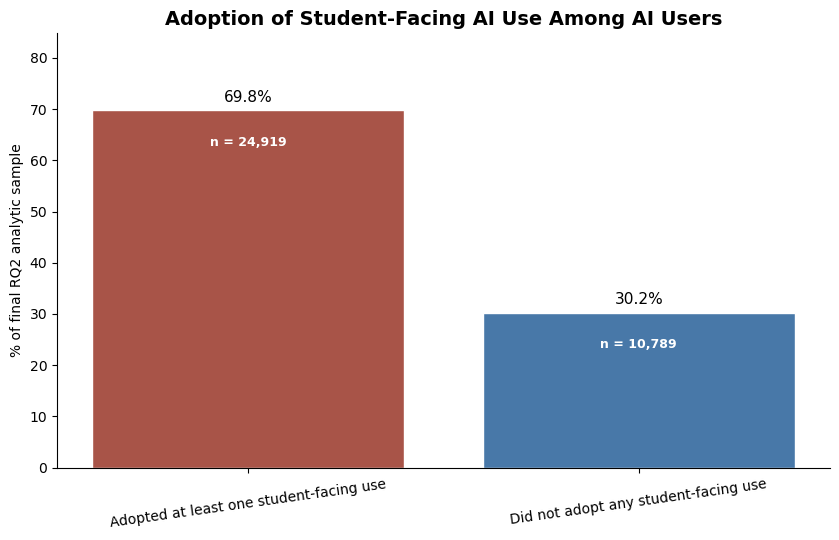


Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\rq2_tt4g37_codebook_check.csv
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\rq2_tt4g37_special_code_check.csv
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\rq2_tt4g37_item_summary.csv
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\rq2_student_facing_item_validity_summary.csv
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\rq2_student_facing_adoption_summary.csv
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\rq2_ai_use_purposes_among_ai_users.png
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\rq2_student_facing_ai_adoption.png


In [8]:
# ============================================================
# CELL 8 — RQ2 EDA: Adoption of student-facing AI use
# ============================================================

# RQ2:
# Among teachers who used AI, which factors predict whether they
# adopted at least one student-facing use of AI?
#
# Starting sample:
# AI-user base sample = teachers who answered Yes to TT4G36
#
# Primary student-facing items:
# TT4G37A = Assess or mark student work
# TT4G37G = Review data on student participation or performance
# TT4G37H = Help students practise new skills in real-life scenarios
#
# Final RQ2 analytic sample:
# AI users with valid Yes/No responses to all three primary
# student-facing items.
#
# TT4G37 original coding:
# 1 = Yes
# 2 = No
# 6 = Logically not applicable
# 8 = Not administered
# 9 = Omitted or invalid

rq2_base_df = ai_user_base_df.copy()

# ------------------------------------------------------------
# 8.0 Define TT4G37 item groups
# ------------------------------------------------------------

student_facing_cols = {
    "TT4G37A": "Assess or mark student work",
    "TT4G37G": "Review student participation or performance data",
    "TT4G37H": "Help students practise new skills in real-life scenarios"
}

teacher_facing_cols = {
    "TT4G37B": "Efficiently learn about and summarise a topic",
    "TT4G37C": "Generate lesson plans or activities",
    "TT4G37F": "Generate student feedback or parent communication"
}

sensitivity_cols = {
    "TT4G37D": "Support students with special education needs",
    "TT4G37E": "Automatically adjust lesson-material difficulty"
}

excluded_cols = {
    "TT4G37I": "Other"
}

tt4g37_cols_all = [
    "TT4G37A",
    "TT4G37B",
    "TT4G37C",
    "TT4G37D",
    "TT4G37E",
    "TT4G37F",
    "TT4G37G",
    "TT4G37H",
    "TT4G37I"
]

tt4g37_primary_cols = list(student_facing_cols.keys())

# ------------------------------------------------------------
# 8.1 Compact codebook check for TT4G37A-I
# ------------------------------------------------------------

tt4g37_codebook_check = codebook.loc[
    codebook["variable_name"].isin(tt4g37_cols_all),
    [
        "variable_name",
        "official_variable_label",
        "item",
        "valid_value_labels",
        "special_missing_or_skip_codes",
        "recommended_cleaning_note"
    ]
].copy()

tt4g37_codebook_check["variable_name"] = pd.Categorical(
    tt4g37_codebook_check["variable_name"],
    categories=tt4g37_cols_all,
    ordered=True
)

tt4g37_codebook_check = (
    tt4g37_codebook_check
    .sort_values("variable_name")
    .reset_index(drop=True)
)

print("Codebook check for TT4G37A-I:")

display(tt4g37_codebook_check)

# ------------------------------------------------------------
# 8.2 Check special codes in the AI-user base sample
# ------------------------------------------------------------

special_code_rows = []

for col in tt4g37_cols_all:

    special_code_rows.append(
        {
            "variable": col,
            "code_6_logically_not_applicable": int(
                (rq2_base_df[col] == 6).sum()
            ),
            "code_8_not_administered": int(
                (rq2_base_df[col] == 8).sum()
            ),
            "code_9_omitted_invalid": int(
                (rq2_base_df[col] == 9).sum()
            )
        }
    )

rq2_special_code_check = pd.DataFrame(special_code_rows)

print(
    "\nSpecial-code check for TT4G37A-I "
    "in the AI-user base sample:"
)

display(rq2_special_code_check)

# ------------------------------------------------------------
# 8.3 Summarize individual TT4G37A-H purposes
# ------------------------------------------------------------

item_group_lookup = {}

for col in student_facing_cols:
    item_group_lookup[col] = "Student-facing outcome item"

for col in teacher_facing_cols:
    item_group_lookup[col] = "Teacher-facing descriptive item"

for col in sensitivity_cols:
    item_group_lookup[col] = "Sensitivity-analysis item"

item_label_lookup = {
    **student_facing_cols,
    **teacher_facing_cols,
    **sensitivity_cols
}

item_summary_order = [
    "TT4G37A",
    "TT4G37G",
    "TT4G37H",
    "TT4G37B",
    "TT4G37C",
    "TT4G37F",
    "TT4G37D",
    "TT4G37E"
]

item_rows = []

for col in item_summary_order:

    valid_mask = rq2_base_df[col].isin([1, 2])

    valid_n = int(valid_mask.sum())
    yes_n = int((rq2_base_df[col] == 1).sum())
    no_n = int((rq2_base_df[col] == 2).sum())

    item_rows.append(
        {
            "variable": col,
            "item_group": item_group_lookup[col],
            "item": item_label_lookup[col],
            "ai_user_base_n": len(rq2_base_df),
            "valid_yes_no_n": valid_n,
            "valid_response_pct": round(
                valid_n / len(rq2_base_df) * 100,
                2
            ),
            "yes_count": yes_n,
            "no_count": no_n,
            "yes_pct_among_valid": round(
                yes_n / valid_n * 100,
                2
            ) if valid_n > 0 else np.nan,
            "code_6_logically_not_applicable": int(
                (rq2_base_df[col] == 6).sum()
            ),
            "code_8_not_administered": int(
                (rq2_base_df[col] == 8).sum()
            ),
            "code_9_omitted_invalid": int(
                (rq2_base_df[col] == 9).sum()
            )
        }
    )

rq2_item_summary = pd.DataFrame(item_rows)

rq2_item_summary["variable"] = pd.Categorical(
    rq2_item_summary["variable"],
    categories=item_summary_order,
    ordered=True
)

rq2_item_summary = (
    rq2_item_summary
    .sort_values("variable")
    .reset_index(drop=True)
)

print("\nAI-use purposes among teachers who reported using AI:")

display(rq2_item_summary)

# ------------------------------------------------------------
# 8.4 Visualize individual AI-use purposes
# ------------------------------------------------------------

purpose_plot_df = (
    rq2_item_summary
    .sort_values(
        "yes_pct_among_valid",
        ascending=True
    )
    .copy()
)

purpose_colors = purpose_plot_df["item_group"].map(
    {
        "Student-facing outcome item": "#a85448",
        "Teacher-facing descriptive item": "#4878a8",
        "Sensitivity-analysis item": "#6a9f58"
    }
)

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(
    purpose_plot_df["item"],
    purpose_plot_df["yes_pct_among_valid"],
    color=purpose_colors,
    edgecolor="white"
)

ax.bar_label(
    bars,
    labels=[
        f"{value:.1f}%"
        for value in purpose_plot_df["yes_pct_among_valid"]
    ],
    padding=4,
    fontsize=9
)

ax.set_xlim(0, 85)

ax.set_xlabel(
    "% answering Yes among valid responses"
)

ax.set_ylabel("")

ax.set_title(
    "Purposes of AI Use Among Teachers Who Reported Using AI",
    fontsize=14,
    weight="bold"
)

legend_handles = [
    plt.Rectangle(
        (0, 0),
        1,
        1,
        color="#a85448",
        label="Student-facing outcome item"
    ),
    plt.Rectangle(
        (0, 0),
        1,
        1,
        color="#4878a8",
        label="Teacher-facing descriptive item"
    ),
    plt.Rectangle(
        (0, 0),
        1,
        1,
        color="#6a9f58",
        label="Sensitivity-analysis item"
    )
]

ax.legend(
    handles=legend_handles,
    loc="lower right",
    frameon=False
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

rq2_item_plot_path = (
    output_dir
    / "rq2_ai_use_purposes_among_ai_users.png"
)

plt.savefig(
    rq2_item_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 8.5 Check validity of the six primary RQ2 items
# ------------------------------------------------------------

# The final RQ2 analytic sample requires valid Yes/No responses
# to all six primary items:
#
# Student-facing outcome items:
# TT4G37A, TT4G37G, TT4G37H
#
# Teacher-facing descriptive/model items:
# TT4G37B, TT4G37C, TT4G37F
#
# Sensitivity-analysis items TT4G37D and TT4G37E are not used
# to determine inclusion in the primary RQ2 analytic sample.

rq2_required_cols = [
    "TT4G37A",
    "TT4G37G",
    "TT4G37H",
    "TT4G37B",
    "TT4G37C",
    "TT4G37F"
]

for col in rq2_required_cols:
    rq2_base_df[col + "_valid"] = (
        rq2_base_df[col].isin([1, 2])
    )

rq2_base_df["rq2_required_valid_count"] = (
    rq2_base_df[
        [col + "_valid" for col in rq2_required_cols]
    ]
    .sum(axis=1)
)

rq2_validity_summary = (
    rq2_base_df["rq2_required_valid_count"]
    .value_counts()
    .sort_index()
    .rename_axis("number_of_valid_required_rq2_items")
    .reset_index(name="n")
)

rq2_validity_summary["percent_of_ai_user_base"] = (
    rq2_validity_summary["n"]
    / len(rq2_base_df)
    * 100
).round(2)

print(
    "\nNumber of valid required RQ2 items among AI users:"
)

display(rq2_validity_summary)

# Show validity for each required item separately

rq2_required_item_validity = pd.DataFrame(
    {
        "variable": rq2_required_cols,
        "valid_yes_no_n": [
            int(rq2_base_df[col].isin([1, 2]).sum())
            for col in rq2_required_cols
        ],
        "invalid_or_missing_n": [
            int((~rq2_base_df[col].isin([1, 2])).sum())
            for col in rq2_required_cols
        ]
    }
)

rq2_required_item_validity["valid_response_pct"] = (
    rq2_required_item_validity["valid_yes_no_n"]
    / len(rq2_base_df)
    * 100
).round(2)

print("\nValidity of each required RQ2 item:")

display(rq2_required_item_validity)

# ------------------------------------------------------------
# 8.6 Construct the final RQ2 analytic sample
# ------------------------------------------------------------

rq2_complete_mask = (
    rq2_base_df["rq2_required_valid_count"]
    == len(rq2_required_cols)
)

rq2_df = (
    rq2_base_df
    .loc[rq2_complete_mask]
    .copy()
)

# The student-facing adoption outcome is still based only on:
# TT4G37A, TT4G37G, and TT4G37H.
#
# TT4G37B, TT4G37C, and TT4G37F are required for inclusion
# because they are retained for the primary RQ2 analysis.
#
# No numeric 1/0 or 1/2 outcome coding is assigned here.

rq2_df["student_facing_adoption"] = np.where(
    rq2_df[
        [
            "TT4G37A",
            "TT4G37G",
            "TT4G37H"
        ]
    ]
    .eq(1)
    .any(axis=1),
    "Adopted at least one student-facing use",
    "Did not adopt any student-facing use"
)

print("\nRQ2 sample construction:")

print(
    f"AI-user base sample: "
    f"{len(rq2_base_df):,}"
)

print(
    f"Final RQ2 analytic sample: "
    f"{len(rq2_df):,}"
)

print(
    f"Excluded because at least one of the six required "
    f"RQ2 items was not valid Yes/No: "
    f"{len(rq2_base_df) - len(rq2_df):,}"
)

print(
    f"RQ2 sample retention rate: "
    f"{len(rq2_df) / len(rq2_base_df) * 100:.2f}%"
)

# ------------------------------------------------------------
# 8.7 Summarize student-facing AI adoption
# ------------------------------------------------------------

adoption_order = [
    "Adopted at least one student-facing use",
    "Did not adopt any student-facing use"
]

rq2_adoption_summary = (
    rq2_df["student_facing_adoption"]
    .value_counts()
    .reindex(adoption_order)
    .rename_axis("student_facing_adoption")
    .reset_index(name="n")
)

rq2_adoption_summary["percent_of_rq2_sample"] = (
    rq2_adoption_summary["n"]
    / len(rq2_df)
    * 100
).round(2)

print("\nRQ2 student-facing AI adoption summary:")

display(rq2_adoption_summary)

# ------------------------------------------------------------
# 8.8 Visualize student-facing AI adoption
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8.5, 5.5))

bars = ax.bar(
    rq2_adoption_summary["student_facing_adoption"],
    rq2_adoption_summary["percent_of_rq2_sample"],
    color=[
        "#a85448",
        "#4878a8"
    ],
    edgecolor="white"
)

ax.bar_label(
    bars,
    labels=[
        f"{value:.1f}%"
        for value in rq2_adoption_summary[
            "percent_of_rq2_sample"
        ]
    ],
    padding=4,
    fontsize=11
)

for i, (_, row) in enumerate(
    rq2_adoption_summary.iterrows()
):

    ax.text(
        i,
        row["percent_of_rq2_sample"] - 5,
        f"n = {int(row['n']):,}",
        ha="center",
        va="top",
        fontsize=9,
        color="white",
        weight="bold"
    )

ax.set_ylim(
    0,
    min(
        100,
        rq2_adoption_summary[
            "percent_of_rq2_sample"
        ].max() + 15
    )
)

ax.set_ylabel("% of final RQ2 analytic sample")
ax.set_xlabel("")

ax.set_title(
    "Adoption of Student-Facing AI Use Among AI Users",
    fontsize=14,
    weight="bold"
)

ax.tick_params(
    axis="x",
    rotation=8
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

rq2_adoption_plot_path = (
    output_dir
    / "rq2_student_facing_ai_adoption.png"
)

plt.savefig(
    rq2_adoption_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 8.9 Save tables and figures
# ------------------------------------------------------------

tt4g37_codebook_check.to_csv(
    output_dir
    / "rq2_tt4g37_codebook_check.csv",
    index=False
)

rq2_special_code_check.to_csv(
    output_dir
    / "rq2_tt4g37_special_code_check.csv",
    index=False
)

rq2_item_summary.to_csv(
    output_dir
    / "rq2_tt4g37_item_summary.csv",
    index=False
)

rq2_validity_summary.to_csv(
    output_dir
    / "rq2_student_facing_item_validity_summary.csv",
    index=False
)

rq2_adoption_summary.to_csv(
    output_dir
    / "rq2_student_facing_adoption_summary.csv",
    index=False
)

print(
    "\nSaved:",
    output_dir
    / "rq2_tt4g37_codebook_check.csv"
)

print(
    "Saved:",
    output_dir
    / "rq2_tt4g37_special_code_check.csv"
)

print(
    "Saved:",
    output_dir
    / "rq2_tt4g37_item_summary.csv"
)

print(
    "Saved:",
    output_dir
    / "rq2_student_facing_item_validity_summary.csv"
)

print(
    "Saved:",
    output_dir
    / "rq2_student_facing_adoption_summary.csv"
)

print("Saved:", rq2_item_plot_path)
print("Saved:", rq2_adoption_plot_path)

### Key findings: Adoption of student-facing AI use

1. **The final RQ2 analytic sample retained most AI users.** 
Of the 36,762 teachers who reported using AI, 35,708 had valid Yes/No responses to all six required RQ2 items (`TT4G37A`, `TT4G37G`, `TT4G37H`, `TT4G37B`, `TT4G37C`, and `TT4G37F`), resulting in a retention rate of 97.13%.

2. **Most AI users adopted at least one student-facing use.** 
Among the final RQ2 analytic sample, 69.79% adopted at least one student-facing AI use, while 30.21% did not report any of the three student-facing uses.

3. **Helping students practise new skills was the most common student-facing purpose.** 
Among valid responses, 55.16% used AI to help students practise new skills in real-life scenarios, compared with 39.03% who used AI to review student participation or performance data and 36.69% who used AI to assess or mark student work.

4. **Teacher-facing purposes were the most frequently reported uses overall.** 
Learning about or summarising a topic (73.08%) and generating lesson plans or activities (71.63%) were more common than the student-facing purposes.

`TT4G37D` and `TT4G37E` were retained only for sensitivity analysis and were not used to define the primary RQ2 analytic sample.

Final RQ2 analytic sample: 35,708
Countries/regions represented: 55
Missing country/region labels: 0

Codebook check for the six primary RQ2 items:


,variable_name,official_variable_label,item,valid_value_labels,special_missing_or_skip_codes,recommended_cleaning_note
0,TT4G37A,Teaching in General/ Used artificial intellige...,A,1 = Yes | 2 = No,6 = Logically not applicable | 8 = Not adminis...,"For CSV analysis, recode special codes as miss..."
1,TT4G37G,Teaching in General/ Used artificial intellige...,G,1 = Yes | 2 = No,6 = Logically not applicable | 8 = Not adminis...,"For CSV analysis, recode special codes as miss..."
2,TT4G37H,Teaching in General/ Used artificial intellige...,H,1 = Yes | 2 = No,6 = Logically not applicable | 8 = Not adminis...,"For CSV analysis, recode special codes as miss..."
3,TT4G37B,Teaching in General/ Used artificial intellige...,B,1 = Yes | 2 = No,6 = Logically not applicable | 8 = Not adminis...,"For CSV analysis, recode special codes as miss..."
4,TT4G37C,Teaching in General/ Used artificial intellige...,C,1 = Yes | 2 = No,6 = Logically not applicable | 8 = Not adminis...,"For CSV analysis, recode special codes as miss..."
5,TT4G37F,Teaching in General/ Used artificial intellige...,F,1 = Yes | 2 = No,6 = Logically not applicable | 8 = Not adminis...,"For CSV analysis, recode special codes as miss..."



RQ2 student-facing adoption and AI-use purposes by country/region:


,country_name,rq2_sample_n,TT4G37A_valid_n,TT4G37A_yes_n,TT4G37A_yes_pct,TT4G37G_valid_n,TT4G37G_yes_n,TT4G37G_yes_pct,TT4G37H_valid_n,TT4G37H_yes_n,...,TT4G37B_yes_n,TT4G37B_yes_pct,TT4G37C_valid_n,TT4G37C_yes_n,TT4G37C_yes_pct,TT4G37F_valid_n,TT4G37F_yes_n,TT4G37F_yes_pct,student_facing_adopted_n,student_facing_adoption_pct
0,Uzbekistan,910,910,766,84.18,910,790,86.81,910,786,...,846,92.97,910,831,91.32,910,603,66.26,884,97.14
1,Azerbaijan,816,816,658,80.64,816,562,68.87,816,628,...,744,91.18,816,672,82.35,816,460,56.37,777,95.22
2,Albania,711,711,291,40.93,711,487,68.50,711,626,...,576,81.01,711,590,82.98,711,445,62.59,668,93.95
3,Viet Nam,929,929,601,64.69,929,768,82.67,929,773,...,848,91.28,929,879,94.62,929,737,79.33,872,93.86
4,North Macedonia,497,497,259,52.11,497,316,63.58,497,379,...,402,80.89,497,411,82.70,497,297,59.76,445,89.54
5,Kazakhstan,1408,1408,897,63.71,1408,871,61.86,1408,1031,...,1190,84.52,1408,1126,79.97,1408,819,58.17,1247,88.57
6,Kosovo,425,425,195,45.88,425,215,50.59,425,319,...,368,86.59,425,350,82.35,425,227,53.41,366,86.12
7,Serbia,359,359,139,38.72,359,201,55.99,359,239,...,294,81.89,359,214,59.61,359,178,49.58,303,84.40
8,Saudi Arabia,1548,1548,818,52.84,1548,885,57.17,1548,1067,...,1272,82.17,1548,1222,78.94,1548,908,58.66,1302,84.11
9,Romania,571,571,286,50.09,571,308,53.94,571,388,...,518,90.72,571,422,73.91,571,312,54.64,480,84.06


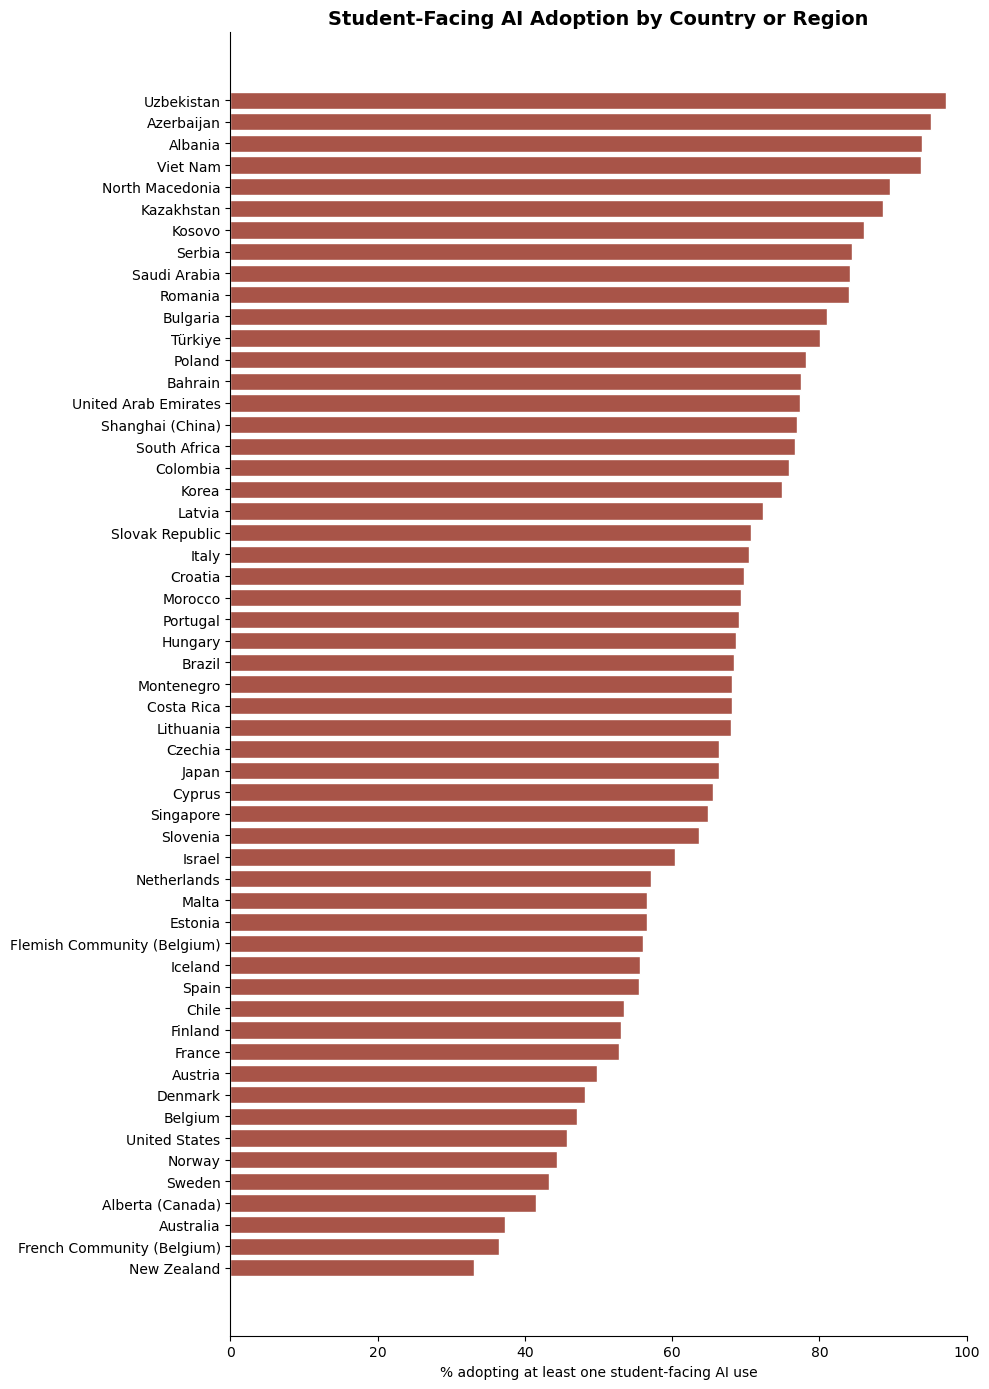

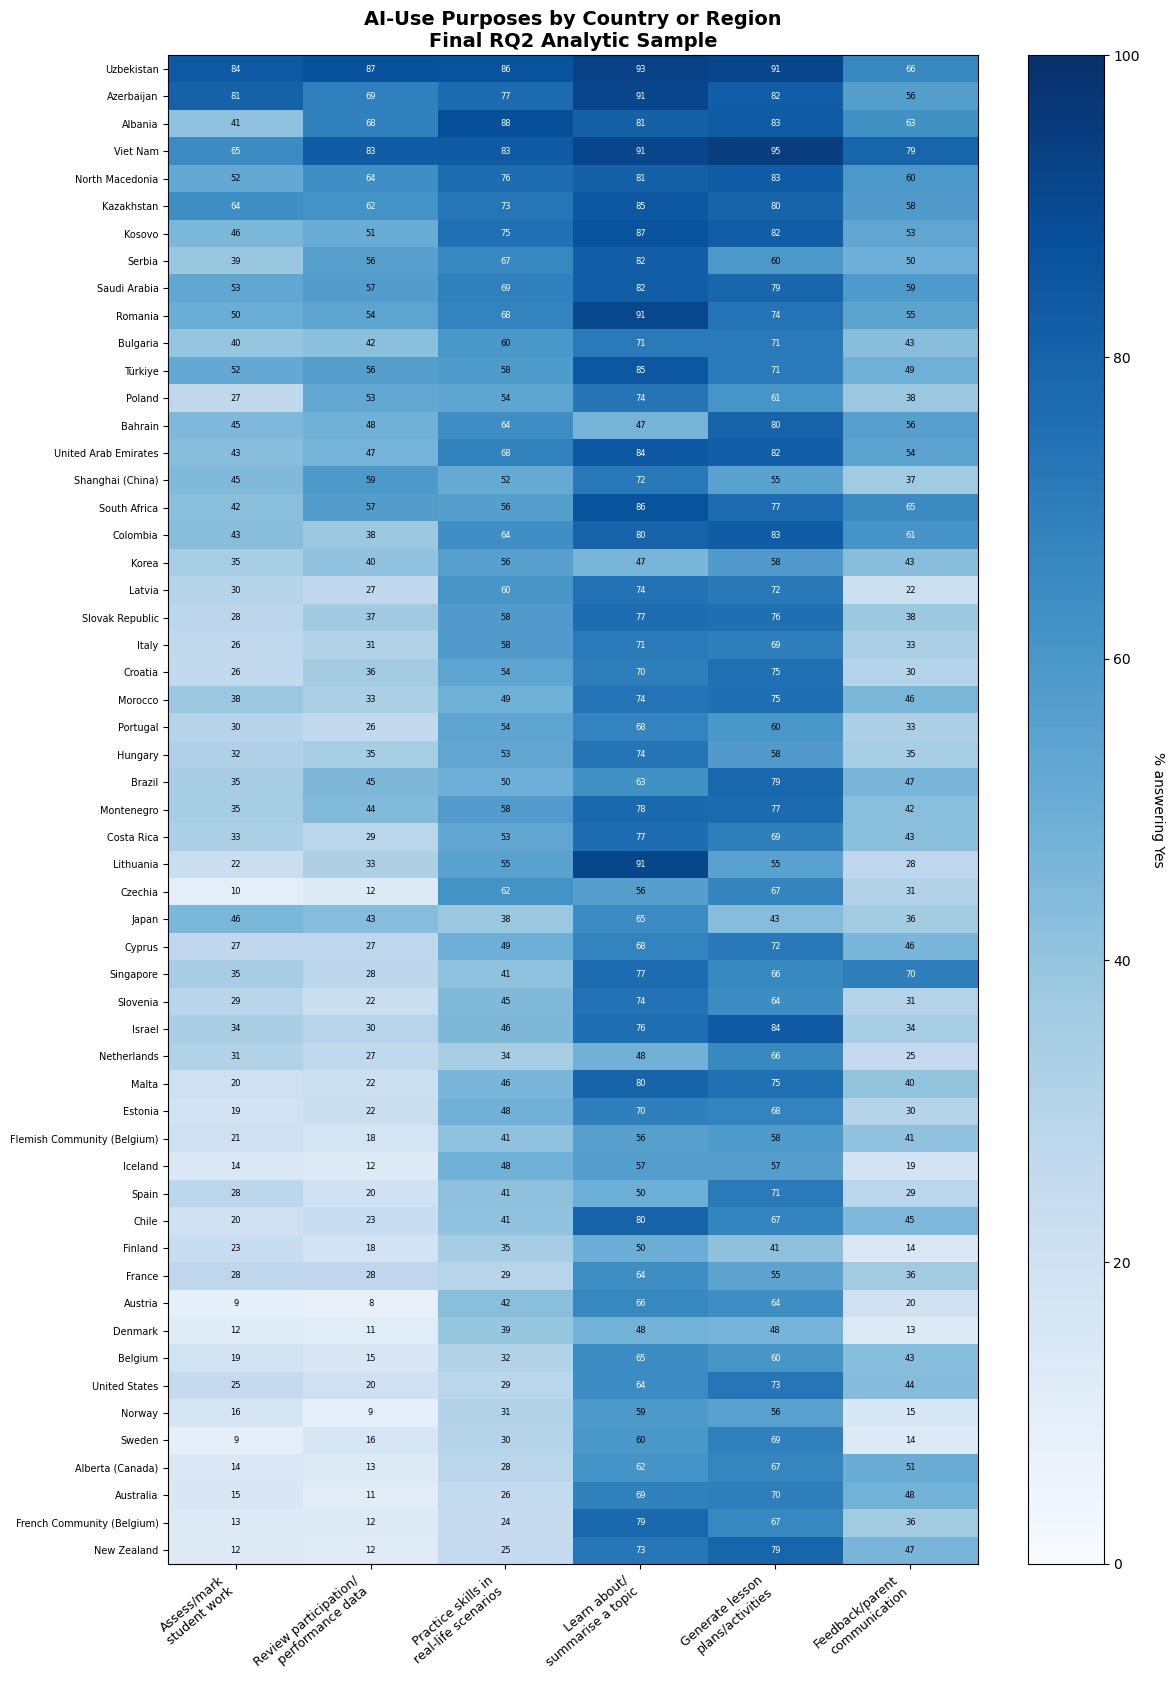

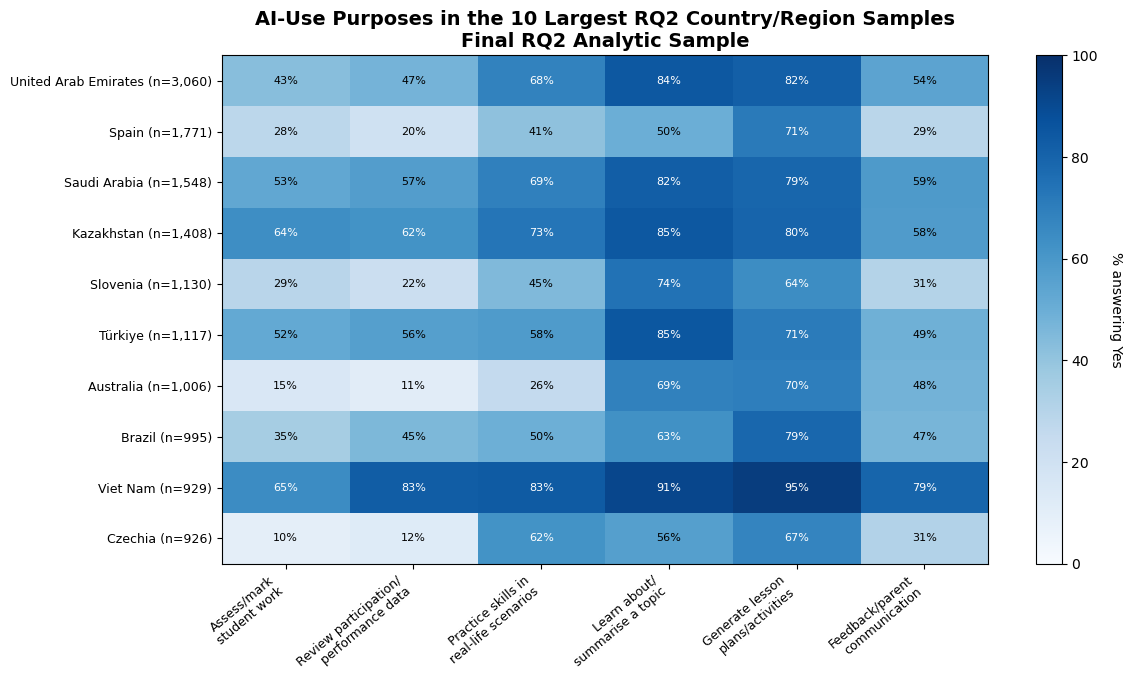

Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\rq2_top10_country_by_sample_size_ai_use_purposes_heatmap.png


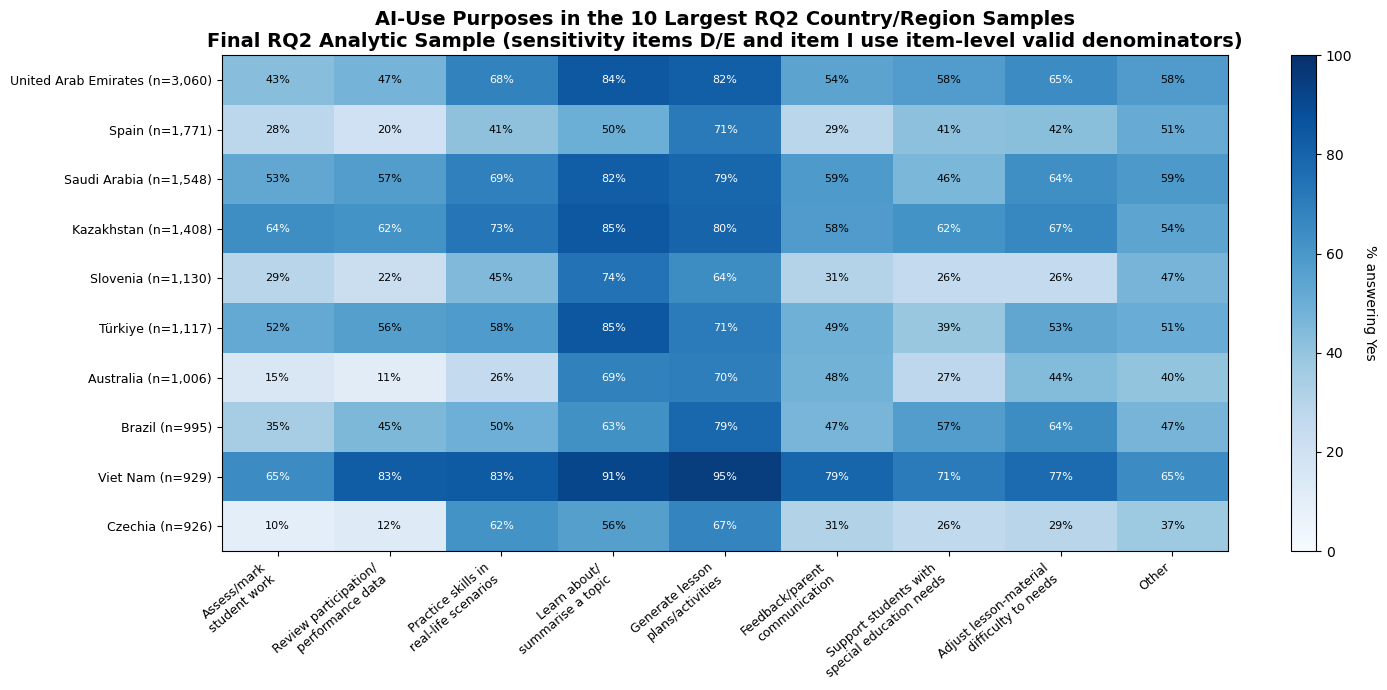

Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\rq2_top10_country_by_sample_size_ai_use_purposes_heatmap_9items.png

Top and bottom countries/regions by student-facing adoption rate:


,adoption_group,country_name,rq2_sample_n,student_facing_adopted_n,student_facing_adoption_pct
0,Highest 10,Uzbekistan,910,884,97.14
1,Highest 10,Azerbaijan,816,777,95.22
2,Highest 10,Albania,711,668,93.95
3,Highest 10,Viet Nam,929,872,93.86
4,Highest 10,North Macedonia,497,445,89.54
5,Highest 10,Kazakhstan,1408,1247,88.57
6,Highest 10,Kosovo,425,366,86.12
7,Highest 10,Serbia,359,303,84.40
8,Highest 10,Saudi Arabia,1548,1302,84.11
9,Highest 10,Romania,571,480,84.06


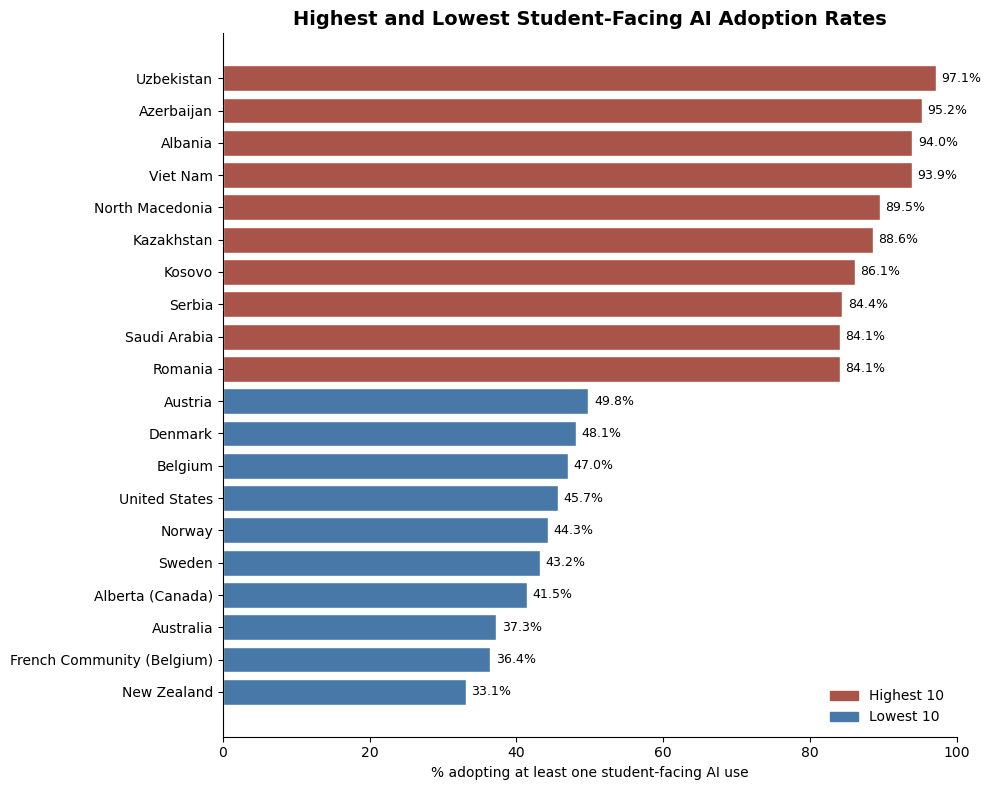


Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\rq2_primary_items_country_codebook_check.csv
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\rq2_student_facing_adoption_and_purposes_by_country.csv
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\rq2_primary_ai_use_purpose_matrix_by_country.csv
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\rq2_top_bottom_student_facing_adoption_by_country.csv
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\rq2_student_facing_adoption_by_country.png
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\rq2_primary_ai_use_purposes_by_country_heatmap.png
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\rq2_top_bottom_student_facing_adoption_by_country.png


In [9]:
# ============================================================
# CELL 9 — RQ2 EDA:
# Student-facing AI adoption and AI-use purposes by country/region
# ============================================================

# RQ2:
# Among teachers who used AI, which factors predict whether they
# adopted at least one student-facing use of AI?
#
# Sample:
# Final RQ2 analytic sample = AI users with valid Yes/No responses
# to all six required primary RQ2 items:
#
# Student-facing outcome items:
# TT4G37A = Assess or mark student work
# TT4G37G = Review student participation or performance data
# TT4G37H = Help students practise new skills in real-life scenarios
#
# Teacher-facing descriptive items:
# TT4G37B = Efficiently learn about and summarise a topic
# TT4G37C = Generate lesson plans or activities
# TT4G37F = Generate student feedback or parent communication
#
# Sensitivity-analysis items TT4G37D and TT4G37E are not included
# in the primary country/region visualization.
#
# Original TT4G37 coding:
# 1 = Yes
# 2 = No
# 6 = Logically not applicable
# 8 = Not administered
# 9 = Omitted or invalid

# ------------------------------------------------------------
# 9.0 Define the six primary RQ2 items
# ------------------------------------------------------------

rq2_student_facing_country_cols = {
    "TT4G37A": "Assess/mark\nstudent work",
    "TT4G37G": "Review participation/\nperformance data",
    "TT4G37H": "Practice skills in\nreal-life scenarios"
}

rq2_teacher_facing_country_cols = {
    "TT4G37B": "Learn about/\nsummarise a topic",
    "TT4G37C": "Generate lesson\nplans/activities",
    "TT4G37F": "Feedback/parent\ncommunication"
}

rq2_country_item_labels = {
    **rq2_student_facing_country_cols,
    **rq2_teacher_facing_country_cols
}

rq2_country_item_order = [
    "TT4G37A",
    "TT4G37G",
    "TT4G37H",
    "TT4G37B",
    "TT4G37C",
    "TT4G37F"
]

# ------------------------------------------------------------
# 9.1 Confirm the country/region RQ2 sample
# ------------------------------------------------------------

print("Final RQ2 analytic sample:", f"{len(rq2_df):,}")

print(
    "Countries/regions represented:",
    rq2_df["country_name"].nunique()
)

print(
    "Missing country/region labels:",
    rq2_df["country_name"].isna().sum()
)

# ------------------------------------------------------------
# 9.2 Compact codebook check for the six primary items
# ------------------------------------------------------------

rq2_country_codebook_check = codebook.loc[
    codebook["variable_name"].isin(
        rq2_country_item_order
    ),
    [
        "variable_name",
        "official_variable_label",
        "item",
        "valid_value_labels",
        "special_missing_or_skip_codes",
        "recommended_cleaning_note"
    ]
].copy()

rq2_country_codebook_check["variable_name"] = pd.Categorical(
    rq2_country_codebook_check["variable_name"],
    categories=rq2_country_item_order,
    ordered=True
)

rq2_country_codebook_check = (
    rq2_country_codebook_check
    .sort_values("variable_name")
    .reset_index(drop=True)
)

print("\nCodebook check for the six primary RQ2 items:")

display(rq2_country_codebook_check)

# ------------------------------------------------------------
# 9.3 Create country/region-level summary
# ------------------------------------------------------------

country_item_rows = []

for country_name, country_df in rq2_df.groupby(
    "country_name",
    observed=True
):

    row = {
        "country_name": country_name,
        "rq2_sample_n": len(country_df)
    }

    # Because rq2_df requires valid Yes/No responses for all six
    # items, each denominator should equal the country RQ2 sample.
    for col in rq2_country_item_order:

        valid_n = int(
            country_df[col].isin([1, 2]).sum()
        )

        yes_n = int(
            (country_df[col] == 1).sum()
        )

        row[col + "_valid_n"] = valid_n
        row[col + "_yes_n"] = yes_n

        row[col + "_yes_pct"] = (
            round(
                yes_n / valid_n * 100,
                2
            )
            if valid_n > 0
            else np.nan
        )

    adopted_n = int(
        (
            country_df["student_facing_adoption"]
            == "Adopted at least one student-facing use"
        ).sum()
    )

    row["student_facing_adopted_n"] = adopted_n

    row["student_facing_adoption_pct"] = round(
        adopted_n / len(country_df) * 100,
        2
    )

    country_item_rows.append(row)

rq2_country_summary = pd.DataFrame(
    country_item_rows
)

rq2_country_summary = (
    rq2_country_summary
    .sort_values(
        "student_facing_adoption_pct",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    "\nRQ2 student-facing adoption and AI-use purposes "
    "by country/region:"
)

display(rq2_country_summary)

# ------------------------------------------------------------
# 9.4 Visualize student-facing adoption by country/region
# ------------------------------------------------------------

country_adoption_plot_df = (
    rq2_country_summary
    .sort_values(
        "student_facing_adoption_pct",
        ascending=True
    )
    .copy()
)

fig, ax = plt.subplots(figsize=(10, 14))

bars = ax.barh(
    country_adoption_plot_df["country_name"],
    country_adoption_plot_df[
        "student_facing_adoption_pct"
    ],
    color="#a85448",
    edgecolor="white"
)

ax.set_xlim(0, 100)

ax.set_xlabel(
    "% adopting at least one student-facing AI use"
)

ax.set_ylabel("")

ax.set_title(
    "Student-Facing AI Adoption by Country or Region",
    fontsize=14,
    weight="bold"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

rq2_country_adoption_plot_path = (
    output_dir
    / "rq2_student_facing_adoption_by_country.png"
)

plt.savefig(
    rq2_country_adoption_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 9.5 Prepare country-by-purpose percentage matrix
# ------------------------------------------------------------

yes_pct_cols = [
    col + "_yes_pct"
    for col in rq2_country_item_order
]

country_purpose_matrix = (
    rq2_country_summary
    .set_index("country_name")[yes_pct_cols]
    .copy()
)

country_purpose_matrix.columns = [
    rq2_country_item_labels[col]
    for col in rq2_country_item_order
]

# Keep countries ordered by student-facing adoption rate

country_order_by_adoption = (
    rq2_country_summary
    .sort_values(
        "student_facing_adoption_pct",
        ascending=False
    )["country_name"]
    .tolist()
)

country_purpose_matrix = (
    country_purpose_matrix
    .reindex(country_order_by_adoption)
)

# ------------------------------------------------------------
# 9.6 Heatmap of the six primary AI-use purposes
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 17))

im = ax.imshow(
    country_purpose_matrix.values,
    aspect="auto",
    cmap="Blues",
    vmin=0,
    vmax=100
)

ax.set_xticks(
    np.arange(
        len(country_purpose_matrix.columns)
    )
)

ax.set_xticklabels(
    country_purpose_matrix.columns,
    rotation=40,
    ha="right",
    fontsize=9
)

ax.set_yticks(
    np.arange(
        len(country_purpose_matrix.index)
    )
)

ax.set_yticklabels(
    country_purpose_matrix.index,
    fontsize=7
)

for i in range(
    country_purpose_matrix.shape[0]
):

    for j in range(
        country_purpose_matrix.shape[1]
    ):

        value = (
            country_purpose_matrix.iloc[i, j]
        )

        if pd.notna(value):

            text_color = (
                "white"
                if value >= 60
                else "black"
            )

            ax.text(
                j,
                i,
                f"{value:.0f}",
                ha="center",
                va="center",
                fontsize=6,
                color=text_color
            )

cbar = plt.colorbar(
    im,
    ax=ax
)

cbar.set_label(
    "% answering Yes",
    rotation=270,
    labelpad=18
)

ax.set_title(
    "AI-Use Purposes by Country or Region\n"
    "Final RQ2 Analytic Sample",
    fontsize=14,
    weight="bold"
)

ax.set_xlabel("")
ax.set_ylabel("")

plt.tight_layout()

rq2_country_purpose_heatmap_path = (
    output_dir
    / "rq2_primary_ai_use_purposes_by_country_heatmap.png"
)

plt.savefig(
    rq2_country_purpose_heatmap_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 9.7 Heatmap: Top 10 countries/regions by RQ2 sample size
# ------------------------------------------------------------

top10_country_purpose = (
    rq2_country_summary
    .sort_values(
        "rq2_sample_n",
        ascending=False
    )
    .head(10)
    .copy()
)

top10_purpose_matrix = (
    top10_country_purpose
    .set_index("country_name")[yes_pct_cols]
    .copy()
)

top10_purpose_matrix.columns = [
    rq2_country_item_labels[col]
    for col in rq2_country_item_order
]

# Add each country's final RQ2 sample size to the row label
top10_country_labels = [
    f"{row['country_name']} (n={int(row['rq2_sample_n']):,})"
    for _, row in top10_country_purpose.iterrows()
]

fig, ax = plt.subplots(figsize=(12, 7))

im = ax.imshow(
    top10_purpose_matrix.values,
    aspect="auto",
    cmap="Blues",
    vmin=0,
    vmax=100
)

ax.set_xticks(
    np.arange(
        len(top10_purpose_matrix.columns)
    )
)

ax.set_xticklabels(
    top10_purpose_matrix.columns,
    rotation=40,
    ha="right",
    fontsize=9
)

ax.set_yticks(
    np.arange(
        len(top10_purpose_matrix.index)
    )
)

ax.set_yticklabels(
    top10_country_labels,
    fontsize=9
)

# Add percentage labels inside each cell
for i in range(
    top10_purpose_matrix.shape[0]
):

    for j in range(
        top10_purpose_matrix.shape[1]
    ):

        value = top10_purpose_matrix.iloc[i, j]

        if pd.notna(value):

            text_color = (
                "white"
                if value >= 60
                else "black"
            )

            ax.text(
                j,
                i,
                f"{value:.0f}%",
                ha="center",
                va="center",
                fontsize=8,
                color=text_color
            )

cbar = plt.colorbar(
    im,
    ax=ax
)

cbar.set_label(
    "% answering Yes",
    rotation=270,
    labelpad=18
)

ax.set_title(
    "AI-Use Purposes in the 10 Largest RQ2 Country/Region Samples\n"
    "Final RQ2 Analytic Sample",
    fontsize=14,
    weight="bold"
)

ax.set_xlabel("")
ax.set_ylabel("")

plt.tight_layout()

rq2_top10_country_purpose_heatmap_path = (
    output_dir
    / "rq2_top10_country_by_sample_size_ai_use_purposes_heatmap.png"
)

plt.savefig(
    rq2_top10_country_purpose_heatmap_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    rq2_top10_country_purpose_heatmap_path
)



# ------------------------------------------------------------
# 9.7b (ADDITIONAL CELL — does not modify anything upstream)
# Heatmap: Top 10 countries/regions by RQ2 sample size,
# six primary items + TT4G37D, TT4G37E, TT4G37I
# Requires: rq2_df, rq2_country_summary, codebook,
#           rq2_country_item_order, rq2_country_item_labels
# Read-only: no rows are dropped, no existing variables changed.
# ------------------------------------------------------------
 
# Extra items (not part of the primary six).
# NOTE: there is no TT4G37J in TALIS 2024 — items run A–I.
rq2_extra_items = ["TT4G37D", "TT4G37E", "TT4G37I"]
 
# Pull short labels for the extra items straight from the codebook
rq2_extra_item_labels = {}
 
for col in rq2_extra_items:
 
    official_label = codebook.loc[
        codebook["variable_name"] == col,
        "official_variable_label"
    ].iloc[0]
 
    # Keep only the part after the last "/" and wrap it a bit
    short = official_label.split("/")[-1].strip()
    short = short.replace("To ", "", 1)
 
    rq2_extra_item_labels[col] = short
 
# Manual line-breaks so the x-axis stays readable.
# Wording matches the notebook's item documentation:
#   TT4G37D — Support students with special education needs
#   TT4G37E — Automatically adjust lesson-material difficulty
#             according to students' learning needs
#   TT4G37I — Other
rq2_extra_item_labels = {
    "TT4G37D": "Support students with\nspecial education needs",
    "TT4G37E": "Adjust lesson-material\ndifficulty to needs",
    "TT4G37I": "Other"
}
 
# Full 9-item order and labels for THIS heatmap only
rq2_top10_item_order = rq2_country_item_order + rq2_extra_items
 
rq2_top10_item_labels = {
    **rq2_country_item_labels,
    **rq2_extra_item_labels
}
 
# ------------------------------------------------------------
# Select the top 10 countries by RQ2 sample size (unchanged)
# ------------------------------------------------------------
 
top10_country_purpose_ext = (
    rq2_country_summary
    .sort_values(
        "rq2_sample_n",
        ascending=False
    )
    .head(10)
    .copy()
)
 
top10_countries_ext = top10_country_purpose_ext["country_name"].tolist()
 
# ------------------------------------------------------------
# Compute yes-% for the extra items.
# IMPORTANT: rq2_df only required valid Yes/No on the six primary
# items, so D, E, and I use their own valid-response denominators.
# ------------------------------------------------------------
 
for col in rq2_extra_items:
 
    extra_pct = {}
 
    for country_name, country_df in rq2_df[
        rq2_df["country_name"].isin(top10_countries_ext)
    ].groupby("country_name", observed=True):
 
        valid_n = int(country_df[col].isin([1, 2]).sum())
        yes_n = int((country_df[col] == 1).sum())
 
        extra_pct[country_name] = (
            round(yes_n / valid_n * 100, 2)
            if valid_n > 0
            else np.nan
        )
 
    top10_country_purpose_ext[col + "_yes_pct"] = (
        top10_country_purpose_ext["country_name"].map(extra_pct)
    )
 
# ------------------------------------------------------------
# Build the 9-column matrix
# ------------------------------------------------------------
 
top10_yes_pct_cols_ext = [
    col + "_yes_pct"
    for col in rq2_top10_item_order
]
 
top10_purpose_matrix_ext = (
    top10_country_purpose_ext
    .set_index("country_name")[top10_yes_pct_cols_ext]
    .copy()
)
 
top10_purpose_matrix_ext.columns = [
    rq2_top10_item_labels[col]
    for col in rq2_top10_item_order
]
 
# Add each country's final RQ2 sample size to the row label
top10_country_labels_ext = [
    f"{row['country_name']} (n={int(row['rq2_sample_n']):,})"
    for _, row in top10_country_purpose_ext.iterrows()
]
 
# ------------------------------------------------------------
# Plot (widened for 9 columns)
# ------------------------------------------------------------
 
fig, ax = plt.subplots(figsize=(15, 7))
 
im = ax.imshow(
    top10_purpose_matrix_ext.values,
    aspect="auto",
    cmap="Blues",
    vmin=0,
    vmax=100
)
 
ax.set_xticks(
    np.arange(len(top10_purpose_matrix_ext.columns))
)
 
ax.set_xticklabels(
    top10_purpose_matrix_ext.columns,
    rotation=40,
    ha="right",
    fontsize=9
)
 
ax.set_yticks(
    np.arange(len(top10_purpose_matrix_ext.index))
)
 
ax.set_yticklabels(
    top10_country_labels_ext,
    fontsize=9
)
 
# Percentage labels inside each cell
for i in range(top10_purpose_matrix_ext.shape[0]):
 
    for j in range(top10_purpose_matrix_ext.shape[1]):
 
        value = top10_purpose_matrix_ext.iloc[i, j]
 
        if pd.notna(value):
 
            text_color = (
                "white"
                if value >= 60
                else "black"
            )
 
            ax.text(
                j,
                i,
                f"{value:.0f}%",
                ha="center",
                va="center",
                fontsize=8,
                color=text_color
            )
 
cbar = plt.colorbar(im, ax=ax)
 
cbar.set_label(
    "% answering Yes",
    rotation=270,
    labelpad=18
)
 
ax.set_title(
    "AI-Use Purposes in the 10 Largest RQ2 Country/Region Samples\n"
    "Final RQ2 Analytic Sample "
    "(sensitivity items D/E and item I use item-level valid denominators)",
    fontsize=14,
    weight="bold"
)
 
ax.set_xlabel("")
ax.set_ylabel("")
 
plt.tight_layout()
 
rq2_top10_heatmap_9items_path = (
    output_dir
    / "rq2_top10_country_by_sample_size_ai_use_purposes_heatmap_9items.png"
)
 
plt.savefig(
    rq2_top10_heatmap_9items_path,
    dpi=300,
    bbox_inches="tight"
)
 
plt.show()
 
print(
    "Saved:",
    rq2_top10_heatmap_9items_path
)


# ------------------------------------------------------------
# 9.8 Top and bottom countries/regions by adoption rate
# ------------------------------------------------------------

top10_adoption = (
    rq2_country_summary
    .nlargest(
        10,
        "student_facing_adoption_pct"
    )
    .copy()
)

bottom10_adoption = (
    rq2_country_summary
    .nsmallest(
        10,
        "student_facing_adoption_pct"
    )
    .copy()
)

top_bottom_adoption = pd.concat(
    [
        top10_adoption.assign(
            adoption_group="Highest 10"
        ),
        bottom10_adoption.assign(
            adoption_group="Lowest 10"
        )
    ],
    ignore_index=True
)

print(
    "\nTop and bottom countries/regions by "
    "student-facing adoption rate:"
)

display(
    top_bottom_adoption[
        [
            "adoption_group",
            "country_name",
            "rq2_sample_n",
            "student_facing_adopted_n",
            "student_facing_adoption_pct"
        ]
    ]
)

# ------------------------------------------------------------
# 9.9 Visualize top and bottom adoption rates
# ------------------------------------------------------------

top_bottom_plot_df = (
    top_bottom_adoption
    .sort_values(
        "student_facing_adoption_pct",
        ascending=True
    )
    .copy()
)

top_bottom_colors = (
    top_bottom_plot_df["adoption_group"]
    .map(
        {
            "Highest 10": "#a85448",
            "Lowest 10": "#4878a8"
        }
    )
)

fig, ax = plt.subplots(figsize=(10, 8))

bars = ax.barh(
    top_bottom_plot_df["country_name"],
    top_bottom_plot_df[
        "student_facing_adoption_pct"
    ],
    color=top_bottom_colors,
    edgecolor="white"
)

ax.bar_label(
    bars,
    labels=[
        f"{value:.1f}%"
        for value in top_bottom_plot_df[
            "student_facing_adoption_pct"
        ]
    ],
    padding=4,
    fontsize=9
)

ax.set_xlim(0, 100)

ax.set_xlabel(
    "% adopting at least one student-facing AI use"
)

ax.set_ylabel("")

ax.set_title(
    "Highest and Lowest Student-Facing AI Adoption Rates",
    fontsize=14,
    weight="bold"
)

legend_handles = [
    plt.Rectangle(
        (0, 0),
        1,
        1,
        color="#a85448",
        label="Highest 10"
    ),
    plt.Rectangle(
        (0, 0),
        1,
        1,
        color="#4878a8",
        label="Lowest 10"
    )
]

ax.legend(
    handles=legend_handles,
    frameon=False,
    loc="lower right"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

rq2_top_bottom_country_plot_path = (
    output_dir
    / "rq2_top_bottom_student_facing_adoption_by_country.png"
)

plt.savefig(
    rq2_top_bottom_country_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 9.10 Save tables and figures
# ------------------------------------------------------------

rq2_country_codebook_check.to_csv(
    output_dir
    / "rq2_primary_items_country_codebook_check.csv",
    index=False
)

rq2_country_summary.to_csv(
    output_dir
    / "rq2_student_facing_adoption_and_purposes_by_country.csv",
    index=False
)

country_purpose_matrix.to_csv(
    output_dir
    / "rq2_primary_ai_use_purpose_matrix_by_country.csv"
)

top_bottom_adoption.to_csv(
    output_dir
    / "rq2_top_bottom_student_facing_adoption_by_country.csv",
    index=False
)

print(
    "\nSaved:",
    output_dir
    / "rq2_primary_items_country_codebook_check.csv"
)

print(
    "Saved:",
    output_dir
    / "rq2_student_facing_adoption_and_purposes_by_country.csv"
)

print(
    "Saved:",
    output_dir
    / "rq2_primary_ai_use_purpose_matrix_by_country.csv"
)

print(
    "Saved:",
    output_dir
    / "rq2_top_bottom_student_facing_adoption_by_country.csv"
)

print("Saved:", rq2_country_adoption_plot_path)
print("Saved:", rq2_country_purpose_heatmap_path)
print("Saved:", rq2_top_bottom_country_plot_path)

### Key findings: Country and regional variation in student-facing AI use

1. **AI-use purposes varied substantially across countries and regions.** 
In the 10 largest RQ2 country/region samples, teacher-facing purposes such as learning about or summarising a topic and generating lesson plans were generally common, but student-facing purposes showed greater variation.

2. **Student-facing adoption rates differed widely across countries and regions.** 
The highest rates were observed in Uzbekistan (97.1%), Azerbaijan (95.2%), Albania (94.0%), and Viet Nam (93.9%). The lowest rates were observed in New Zealand (33.1%), the French Community of Belgium (36.4%), Australia (37.3%), and Alberta, Canada (41.5%).

3. **High overall AI use did not always imply high student-facing adoption.** 
For example, some countries with sizable AI-user samples showed relatively low use of AI for assessing student work or reviewing student performance data, even when lesson-planning or topic-summary uses were common.

These country and regional comparisons are descriptive and unweighted. They indicate meaningful contextual variation that should be considered in the later RQ2 modeling.

Final RQ2 analytic sample: 35,708
Missing school-level labels: 0

Final RQ2 sample by school level:


,school_level,rq2_sample_n,percent_of_rq2_sample
0,Primary,6134,17.18
1,Lower secondary,25561,71.58
2,Upper secondary,4013,11.24



RQ2 student-facing adoption and AI-use purposes by school level:


,school_level,rq2_sample_n,TT4G37A_valid_n,TT4G37A_yes_n,TT4G37A_no_n,TT4G37A_yes_pct,TT4G37G_valid_n,TT4G37G_yes_n,TT4G37G_no_n,TT4G37G_yes_pct,...,TT4G37C_yes_n,TT4G37C_no_n,TT4G37C_yes_pct,TT4G37F_valid_n,TT4G37F_yes_n,TT4G37F_no_n,TT4G37F_yes_pct,student_facing_adopted_n,student_facing_not_adopted_n,student_facing_adoption_pct
0,Primary,6134,6134,2204,3930,35.93,6134,2208,3926,36.00,...,4396,1738,71.67,6134,3047,3087,49.67,3961,2173,64.57
1,Lower secondary,25561,25561,9521,16040,37.25,25561,10209,15352,39.94,...,18445,7116,72.16,25561,11514,14047,45.05,18089,7472,70.77
2,Upper secondary,4013,4013,1367,2646,34.06,4013,1496,2517,37.28,...,2768,1245,68.98,4013,1543,2470,38.45,2869,1144,71.49


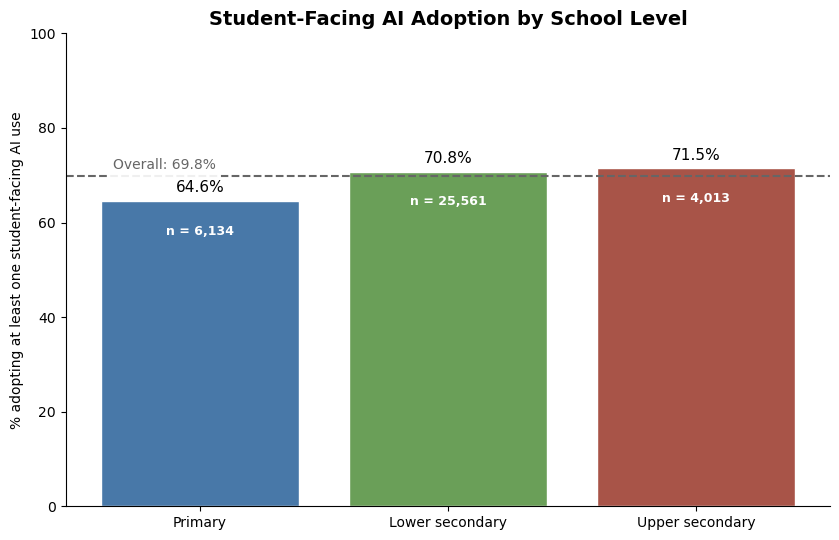

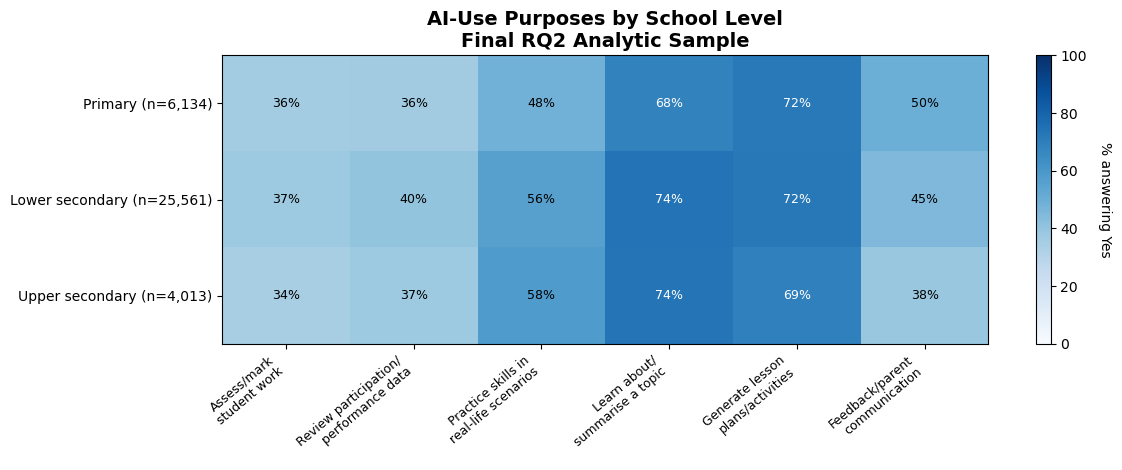


Long-format AI-use purpose summary by school level:


,school_level,variable,item,yes_count,valid_yes_no_n,yes_pct_among_valid
0,Primary,TT4G37A,Assess/mark student work,2204,6134,35.93
1,Primary,TT4G37G,Review participation/ performance data,2208,6134,36.00
2,Primary,TT4G37H,Practice skills in real-life scenarios,2956,6134,48.19
3,Primary,TT4G37B,Learn about/ summarise a topic,4181,6134,68.16
4,Primary,TT4G37C,Generate lesson plans/activities,4396,6134,71.67
5,Primary,TT4G37F,Feedback/parent communication,3047,6134,49.67
6,Lower secondary,TT4G37A,Assess/mark student work,9521,25561,37.25
7,Lower secondary,TT4G37G,Review participation/ performance data,10209,25561,39.94
8,Lower secondary,TT4G37H,Practice skills in real-life scenarios,14368,25561,56.21
9,Lower secondary,TT4G37B,Learn about/ summarise a topic,18957,25561,74.16



Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\rq2_sample_composition_by_school_level.csv
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\rq2_student_facing_adoption_and_purposes_by_school_level.csv
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\rq2_primary_ai_use_purpose_matrix_by_school_level.csv
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\rq2_primary_ai_use_purposes_by_school_level_long.csv
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\rq2_student_facing_adoption_by_school_level.png
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\rq2_primary_ai_use_purposes_by_school_level_heatmap.png


In [10]:
# ============================================================
# CELL 10 — RQ2 EDA:
# Student-facing AI adoption and AI-use purposes by school level
# ============================================================

# RQ2:
# Among teachers who used AI, which factors predict whether they
# adopted at least one student-facing use of AI?
#
# Sample:
# Final RQ2 analytic sample = AI users with valid Yes/No responses
# to all six required primary RQ2 items:
#
# Student-facing outcome items:
# TT4G37A = Assess or mark student work
# TT4G37G = Review student participation or performance data
# TT4G37H = Help students practise new skills in real-life scenarios
#
# Teacher-facing descriptive items:
# TT4G37B = Efficiently learn about and summarise a topic
# TT4G37C = Generate lesson plans or activities
# TT4G37F = Generate student feedback or parent communication
#
# Sensitivity-analysis items TT4G37D and TT4G37E are not included
# in the primary school-level comparison.
#
# No new numeric outcome coding is introduced in this cell.

# ------------------------------------------------------------
# 10.0 Define the six primary RQ2 items
# ------------------------------------------------------------

rq2_school_item_order = [
    "TT4G37A",
    "TT4G37G",
    "TT4G37H",
    "TT4G37B",
    "TT4G37C",
    "TT4G37F"
]

rq2_school_item_labels = {
    "TT4G37A": "Assess/mark\nstudent work",
    "TT4G37G": "Review participation/\nperformance data",
    "TT4G37H": "Practice skills in\nreal-life scenarios",
    "TT4G37B": "Learn about/\nsummarise a topic",
    "TT4G37C": "Generate lesson\nplans/activities",
    "TT4G37F": "Feedback/parent\ncommunication"
}

school_level_order = [
    "Primary",
    "Lower secondary",
    "Upper secondary"
]

# ------------------------------------------------------------
# 10.1 Confirm the school-level RQ2 sample
# ------------------------------------------------------------

print("Final RQ2 analytic sample:", f"{len(rq2_df):,}")

print(
    "Missing school-level labels:",
    rq2_df["isced_label"].isna().sum()
)

rq2_school_sample_summary = (
    rq2_df["isced_label"]
    .value_counts(sort=False)
    .reindex(school_level_order)
    .rename_axis("school_level")
    .reset_index(name="rq2_sample_n")
)

rq2_school_sample_summary["percent_of_rq2_sample"] = (
    rq2_school_sample_summary["rq2_sample_n"]
    / len(rq2_df)
    * 100
).round(2)

print("\nFinal RQ2 sample by school level:")

display(rq2_school_sample_summary)

# ------------------------------------------------------------
# 10.2 Create school-level summary for purposes and adoption
# ------------------------------------------------------------

school_item_rows = []

for school_level, school_df in rq2_df.groupby(
    "isced_label",
    observed=True
):

    row = {
        "school_level": school_level,
        "rq2_sample_n": len(school_df)
    }

    for col in rq2_school_item_order:

        valid_n = int(
            school_df[col].isin([1, 2]).sum()
        )

        yes_n = int(
            (school_df[col] == 1).sum()
        )

        no_n = int(
            (school_df[col] == 2).sum()
        )

        row[col + "_valid_n"] = valid_n
        row[col + "_yes_n"] = yes_n
        row[col + "_no_n"] = no_n

        row[col + "_yes_pct"] = (
            round(
                yes_n / valid_n * 100,
                2
            )
            if valid_n > 0
            else np.nan
        )

    adopted_n = int(
        (
            school_df["student_facing_adoption"]
            == "Adopted at least one student-facing use"
        ).sum()
    )

    row["student_facing_adopted_n"] = adopted_n

    row["student_facing_not_adopted_n"] = (
        len(school_df) - adopted_n
    )

    row["student_facing_adoption_pct"] = round(
        adopted_n / len(school_df) * 100,
        2
    )

    school_item_rows.append(row)

rq2_school_summary = pd.DataFrame(
    school_item_rows
)

rq2_school_summary["school_level"] = pd.Categorical(
    rq2_school_summary["school_level"],
    categories=school_level_order,
    ordered=True
)

rq2_school_summary = (
    rq2_school_summary
    .sort_values("school_level")
    .reset_index(drop=True)
)

print(
    "\nRQ2 student-facing adoption and AI-use purposes "
    "by school level:"
)

display(rq2_school_summary)

# ------------------------------------------------------------
# 10.3 Visualize student-facing adoption by school level
# ------------------------------------------------------------

school_adoption_colors = [
    "#4878a8",
    "#6a9f58",
    "#a85448"
]

fig, ax = plt.subplots(figsize=(8.5, 5.5))

bars = ax.bar(
    rq2_school_summary["school_level"].astype(str),
    rq2_school_summary[
        "student_facing_adoption_pct"
    ],
    color=school_adoption_colors,
    edgecolor="white"
)

ax.bar_label(
    bars,
    labels=[
        f"{value:.1f}%"
        for value in rq2_school_summary[
            "student_facing_adoption_pct"
        ]
    ],
    padding=4,
    fontsize=11
)

for i, (_, row) in enumerate(
    rq2_school_summary.iterrows()
):

    ax.text(
        i,
        row["student_facing_adoption_pct"] - 5,
        f"n = {int(row['rq2_sample_n']):,}",
        ha="center",
        va="top",
        fontsize=9,
        color="white",
        weight="bold"
    )

overall_rq2_adoption_rate = (
    (
        rq2_df["student_facing_adoption"]
        == "Adopted at least one student-facing use"
    )
    .mean()
    * 100
)

ax.axhline(
    overall_rq2_adoption_rate,
    linestyle="--",
    linewidth=1.5,
    color="#666666"
)

ax.text(
    -0.35,
    overall_rq2_adoption_rate + 0.8,
    f"Overall: {overall_rq2_adoption_rate:.1f}%",
    fontsize=10,
    color="#666666",
    ha="left",
    va="bottom",
    bbox=dict(
        facecolor="white",
        edgecolor="none",
        alpha=0.9
    )
)

ax.set_ylim(0, 100)

ax.set_ylabel(
    "% adopting at least one student-facing AI use"
)

ax.set_xlabel("")

ax.set_title(
    "Student-Facing AI Adoption by School Level",
    fontsize=14,
    weight="bold"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

rq2_school_adoption_plot_path = (
    output_dir
    / "rq2_student_facing_adoption_by_school_level.png"
)

plt.savefig(
    rq2_school_adoption_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 10.4 Prepare school-level purpose matrix
# ------------------------------------------------------------

school_yes_pct_cols = [
    col + "_yes_pct"
    for col in rq2_school_item_order
]

school_purpose_matrix = (
    rq2_school_summary
    .set_index("school_level")[school_yes_pct_cols]
    .copy()
)

school_purpose_matrix.columns = [
    rq2_school_item_labels[col]
    for col in rq2_school_item_order
]

school_purpose_matrix = (
    school_purpose_matrix
    .reindex(school_level_order)
)

# ------------------------------------------------------------
# 10.5 Heatmap:
#      school level by six primary AI-use purposes
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 4.8))

im = ax.imshow(
    school_purpose_matrix.values,
    aspect="auto",
    cmap="Blues",
    vmin=0,
    vmax=100
)

ax.set_xticks(
    np.arange(
        len(school_purpose_matrix.columns)
    )
)

ax.set_xticklabels(
    school_purpose_matrix.columns,
    rotation=40,
    ha="right",
    fontsize=9
)

school_y_labels = [
    (
        f"{row['school_level']} "
        f"(n={int(row['rq2_sample_n']):,})"
    )
    for _, row in rq2_school_summary.iterrows()
]

ax.set_yticks(
    np.arange(
        len(school_purpose_matrix.index)
    )
)

ax.set_yticklabels(
    school_y_labels,
    fontsize=10
)

for i in range(
    school_purpose_matrix.shape[0]
):

    for j in range(
        school_purpose_matrix.shape[1]
    ):

        value = school_purpose_matrix.iloc[i, j]

        if pd.notna(value):

            text_color = (
                "white"
                if value >= 60
                else "black"
            )

            ax.text(
                j,
                i,
                f"{value:.0f}%",
                ha="center",
                va="center",
                fontsize=9,
                color=text_color
            )

cbar = plt.colorbar(
    im,
    ax=ax
)

cbar.set_label(
    "% answering Yes",
    rotation=270,
    labelpad=18
)

ax.set_title(
    "AI-Use Purposes by School Level\n"
    "Final RQ2 Analytic Sample",
    fontsize=14,
    weight="bold"
)

ax.set_xlabel("")
ax.set_ylabel("")

plt.tight_layout()

rq2_school_purpose_heatmap_path = (
    output_dir
    / "rq2_primary_ai_use_purposes_by_school_level_heatmap.png"
)

plt.savefig(
    rq2_school_purpose_heatmap_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 10.6 Create a long-format summary for easier comparison
# ------------------------------------------------------------

rq2_school_purpose_long_rows = []

for _, row in rq2_school_summary.iterrows():

    for col in rq2_school_item_order:

        rq2_school_purpose_long_rows.append(
            {
                "school_level": row["school_level"],
                "variable": col,
                "item": (
                    rq2_school_item_labels[col]
                    .replace("\n", " ")
                ),
                "yes_count": row[col + "_yes_n"],
                "valid_yes_no_n": row[col + "_valid_n"],
                "yes_pct_among_valid": row[
                    col + "_yes_pct"
                ]
            }
        )

rq2_school_purpose_long = pd.DataFrame(
    rq2_school_purpose_long_rows
)

rq2_school_purpose_long["school_level"] = pd.Categorical(
    rq2_school_purpose_long["school_level"],
    categories=school_level_order,
    ordered=True
)

rq2_school_purpose_long["variable"] = pd.Categorical(
    rq2_school_purpose_long["variable"],
    categories=rq2_school_item_order,
    ordered=True
)

rq2_school_purpose_long = (
    rq2_school_purpose_long
    .sort_values(
        [
            "school_level",
            "variable"
        ]
    )
    .reset_index(drop=True)
)

print(
    "\nLong-format AI-use purpose summary "
    "by school level:"
)

display(rq2_school_purpose_long)

# ------------------------------------------------------------
# 10.7 Save outputs
# ------------------------------------------------------------

rq2_school_sample_summary.to_csv(
    output_dir
    / "rq2_sample_composition_by_school_level.csv",
    index=False
)

rq2_school_summary.to_csv(
    output_dir
    / "rq2_student_facing_adoption_and_purposes_by_school_level.csv",
    index=False
)

school_purpose_matrix.to_csv(
    output_dir
    / "rq2_primary_ai_use_purpose_matrix_by_school_level.csv"
)

rq2_school_purpose_long.to_csv(
    output_dir
    / "rq2_primary_ai_use_purposes_by_school_level_long.csv",
    index=False
)

print(
    "\nSaved:",
    output_dir
    / "rq2_sample_composition_by_school_level.csv"
)

print(
    "Saved:",
    output_dir
    / "rq2_student_facing_adoption_and_purposes_by_school_level.csv"
)

print(
    "Saved:",
    output_dir
    / "rq2_primary_ai_use_purpose_matrix_by_school_level.csv"
)

print(
    "Saved:",
    output_dir
    / "rq2_primary_ai_use_purposes_by_school_level_long.csv"
)

print("Saved:", rq2_school_adoption_plot_path)
print("Saved:", rq2_school_purpose_heatmap_path)

### RQ2 school-level heatmap: AI-use purposes

This heatmap shows how AI-using teachers at different school levels reported specific AI-use purposes. Across primary, lower-secondary, and upper-secondary teachers, the most common uses were learning about or summarising a topic and generating lesson plans or activities. These teacher-facing uses were consistently more common than assessment-oriented uses such as assessing or marking student work and reviewing participation or performance data.

Some student-facing uses varied by school level. Helping students practise new skills in real-life scenarios was more common among lower-secondary and upper-secondary teachers than among primary teachers, while generating feedback or parent communication was slightly more common among primary teachers. Overall, AI-use purposes were broadly similar across school levels, although some student-facing uses differed by school context.

### Key findings: Student-facing AI use by school level

1. **Student-facing AI adoption increased across school levels.** 
Among the final RQ2 analytic sample, 64.6% of primary teachers adopted at least one student-facing AI use, compared with 70.8% of lower-secondary teachers and 71.5% of upper-secondary teachers.

2. **The largest school-level difference appeared in helping students practise skills in real-life scenarios.** 
This use increased from 48% among primary teachers to 56% among lower-secondary teachers and 58% among upper-secondary teachers.

3. **Teacher-facing uses were common across all school levels.** 
Around 68%–74% of teachers used AI to learn about or summarise a topic, and around 69%–72% used it to generate lesson plans or activities.

4. **Some purposes showed little variation by school level.** 
Assessing or marking student work remained relatively similar across primary, lower-secondary, and upper-secondary teachers, at approximately 34%–37%.

These results suggest that school level may be associated with how teachers use AI, particularly for student practice and other student-facing purposes.

In [11]:
# ============================================================
# CELL 11 — Broad valid-response screening before predictor selection
# ============================================================

# Purpose:
# Screen a broad set of possible predictor variables for:
#
# 1. Adequate valid-response coverage
# 2. At least two observed valid values
# 3. Sufficient variation
#
# Screening is conducted separately for:
#
# RQ1:
# Teachers with valid Yes/No responses to TT4G36
# N = 89,833
#
# RQ2:
# Final RQ2 analytic sample with valid Yes/No responses to all six
# required TT4G37 items:
# A, G, H, B, C, and F
# N = 35,708
#
# Screening threshold:
# At least 90% valid responses in the relevant analytic sample.
#
# Important:
# Passing this screen does not automatically make a variable a final
# predictor. Theoretical relevance, overlap, leakage, and redundancy
# will be checked in later cells.

import re

# ------------------------------------------------------------
# 11.0 Confirm analytic samples
# ------------------------------------------------------------

rq1_screening_df = rq1_df.copy()
rq2_screening_df = rq2_df.copy()

sample_check = pd.DataFrame(
    {
        "sample": [
            "RQ1 valid TT4G36 Yes/No sample",
            "RQ2 final analytic sample"
        ],
        "n": [
            len(rq1_screening_df),
            len(rq2_screening_df)
        ]
    }
)

print("Analytic samples used for predictor screening:")

display(sample_check)

# Optional consistency checks

assert len(rq1_screening_df) == len(rq1_df)

assert len(rq2_screening_df) == len(rq2_df)

print(
    "RQ1 screening sample:",
    f"{len(rq1_screening_df):,}"
)

print(
    "RQ2 screening sample:",
    f"{len(rq2_screening_df):,}"
)

# ------------------------------------------------------------
# 11.1 Helper functions
# ------------------------------------------------------------

def extract_special_codes(special_code_text):
    """
    Extract numeric special missing/skip codes from codebook text.

    Example:
    '8 = Not administered | 9 = Omitted or invalid'
    becomes:
    [8, 9]
    """

    if pd.isna(special_code_text):
        return []

    text = str(special_code_text)

    codes = re.findall(
        r"(-?\d+\.?\d*)\s*=",
        text
    )

    cleaned_codes = []

    for code in codes:

        try:

            if "." in code:
                cleaned_codes.append(float(code))

            else:
                cleaned_codes.append(int(code))

        except (TypeError, ValueError):
            continue

    return cleaned_codes


def clean_valid_values(
    data,
    var_name,
    special_codes
):
    """
    Convert a variable to numeric when possible and replace
    codebook-defined special missing/skip codes with NaN.
    """

    x = pd.to_numeric(
        data[var_name],
        errors="coerce"
    )

    if len(special_codes) > 0:

        x = x.mask(
            x.isin(special_codes),
            np.nan
        )

    return x


def screen_one_variable(
    var_name,
    data,
    sample_name
):
    """
    Calculate valid-response coverage and variation for one
    variable within one analytic sample.
    """

    cb_matches = codebook.loc[
        codebook["variable_name"] == var_name
    ]

    if cb_matches.empty:

        raise ValueError(
            f"{var_name} was not found in the codebook."
        )

    cb_row = cb_matches.iloc[0]

    special_codes = extract_special_codes(
        cb_row["special_missing_or_skip_codes"]
    )

    x_clean = clean_valid_values(
        data=data,
        var_name=var_name,
        special_codes=special_codes
    )

    total_n = len(x_clean)

    valid_n = int(
        x_clean.notna().sum()
    )

    valid_pct = (
        valid_n / total_n * 100
        if total_n > 0
        else np.nan
    )

    unique_valid_values = int(
        x_clean.dropna().nunique()
    )

    if valid_n > 0:

        top_category_pct = (
            x_clean
            .value_counts(dropna=True)
            .max()
            / valid_n
            * 100
        )

    else:

        top_category_pct = np.nan

    return {
        f"{sample_name}_n": total_n,
        f"{sample_name}_valid_n": valid_n,
        f"{sample_name}_valid_pct": round(
            valid_pct,
            2
        ),
        f"{sample_name}_unique_valid_values": (
            unique_valid_values
        ),
        f"{sample_name}_top_category_pct": (
            round(top_category_pct, 2)
            if pd.notna(top_category_pct)
            else np.nan
        )
    }

# ------------------------------------------------------------
# 11.2 Define variables that must be excluded
# ------------------------------------------------------------

# Primary outcomes and outcome-construction items

outcome_vars = [
    "TT4G36",
    "TT4G37A",
    "TT4G37B",
    "TT4G37C",
    "TT4G37D",
    "TT4G37E",
    "TT4G37F",
    "TT4G37G",
    "TT4G37H",
    "TT4G37I"
]

# TT4G38A-F are asked only of teachers who answered No to TT4G36.
# They are descriptive barriers and must not be treated as predictors
# of whether teachers used AI.

outcome_conditional_vars = [
    "TT4G38A",
    "TT4G38B",
    "TT4G38C",
    "TT4G38D",
    "TT4G38E",
    "TT4G38F"
]

explicitly_excluded_vars = set(
    outcome_vars
    + outcome_conditional_vars
)

# Exclude technical, identification, design, and weighting variables.

exclude_name_patterns = [
    r"^ID",          # ID variables
    r"^CNTRY$",      # country alpha code
    r"^IDCNTRY$",    # country numeric code
    r"^IDCNTPOP$",   # country + ISCED population code
    r"QUEST",        # questionnaire form
    r"LANG",         # questionnaire language
    r"MODE",         # administration mode
    r"WGT",          # weights
    r"WEIGHT",       # weights
    r"REPWGT",       # replicate weights
    r"^TRWGT",       # teacher weights
    r"^SRWGT"        # school weights
]

exclude_regex = "|".join(
    exclude_name_patterns
)

# ------------------------------------------------------------
# 11.3 Define the broad possible predictor universe
# ------------------------------------------------------------

all_codebook_vars = (
    codebook["variable_name"]
    .dropna()
    .astype(str)
    .tolist()
)

broad_possible_predictors = []

for var in all_codebook_vars:

    if var not in full_df.columns:
        continue

    if var in explicitly_excluded_vars:
        continue

    if re.search(
        exclude_regex,
        var,
        flags=re.IGNORECASE
    ):
        continue

    broad_possible_predictors.append(var)

broad_possible_predictors = sorted(
    set(broad_possible_predictors)
)

print(
    "\nNumber of broad possible predictor variables:",
    len(broad_possible_predictors)
)


# ------------------------------------------------------------
# 11.4 Screen all broad possible predictors
# ------------------------------------------------------------

screen_rows = []

for var in broad_possible_predictors:

    cb_matches = codebook.loc[
        codebook["variable_name"] == var
    ]

    if cb_matches.empty:
        continue

    cb_row = cb_matches.iloc[0]

    rq1_screen = screen_one_variable(
        var_name=var,
        data=rq1_screening_df,
        sample_name="rq1"
    )

    rq2_screen = screen_one_variable(
        var_name=var,
        data=rq2_screening_df,
        sample_name="rq2"
    )

    row = {
        "variable_name": var,
        "official_variable_label": cb_row.get(
            "official_variable_label",
            np.nan
        ),
        "label_group_1": cb_row.get(
            "label_group_1",
            np.nan
        ),
        "label_group_2": cb_row.get(
            "label_group_2",
            np.nan
        ),
        "label_group_3": cb_row.get(
            "label_group_3",
            np.nan
        ),
        "valid_value_labels": cb_row.get(
            "valid_value_labels",
            np.nan
        ),
        "special_missing_or_skip_codes": cb_row.get(
            "special_missing_or_skip_codes",
            np.nan
        ),
        "recommended_cleaning_note": cb_row.get(
            "recommended_cleaning_note",
            np.nan
        )
    }

    row.update(rq1_screen)
    row.update(rq2_screen)

    screen_rows.append(row)

broad_valid_response_screening = pd.DataFrame(
    screen_rows
)

# ------------------------------------------------------------
# 11.5 Apply the 90% valid-response screening rules
# ------------------------------------------------------------

valid_response_threshold = 90.0
maximum_top_category_pct = 95.0

# A variable passes when:
#
# 1. At least 90% of the relevant sample has a valid response
# 2. At least two valid values are observed
# 3. No single value represents more than 95% of valid responses
#
# These are EDA screening rules, not final modeling rules.

broad_valid_response_screening[
    "passed_rq1_valid_screening"
] = (
    (
        broad_valid_response_screening[
            "rq1_valid_pct"
        ]
        >= valid_response_threshold
    )
    & (
        broad_valid_response_screening[
            "rq1_unique_valid_values"
        ]
        >= 2
    )
    & (
        broad_valid_response_screening[
            "rq1_top_category_pct"
        ]
        <= maximum_top_category_pct
    )
)

broad_valid_response_screening[
    "passed_rq2_valid_screening"
] = (
    (
        broad_valid_response_screening[
            "rq2_valid_pct"
        ]
        >= valid_response_threshold
    )
    & (
        broad_valid_response_screening[
            "rq2_unique_valid_values"
        ]
        >= 2
    )
    & (
        broad_valid_response_screening[
            "rq2_top_category_pct"
        ]
        <= maximum_top_category_pct
    )
)

broad_valid_response_screening[
    "passed_both_valid_screenings"
] = (
    broad_valid_response_screening[
        "passed_rq1_valid_screening"
    ]
    & broad_valid_response_screening[
        "passed_rq2_valid_screening"
    ]
)

broad_valid_response_screening[
    "passed_any_valid_screening"
] = (
    broad_valid_response_screening[
        "passed_rq1_valid_screening"
    ]
    | broad_valid_response_screening[
        "passed_rq2_valid_screening"
    ]
)

broad_valid_response_screening = (
    broad_valid_response_screening
    .sort_values(
        [
            "passed_both_valid_screenings",
            "passed_any_valid_screening",
            "rq1_valid_pct",
            "rq2_valid_pct"
        ],
        ascending=[
            False,
            False,
            False,
            False
        ]
    )
    .reset_index(drop=True)
)

print(
    "\nBroad valid-response screening results:"
)

display(broad_valid_response_screening)

# ------------------------------------------------------------
# 11.6 Create separate passed-variable tables for RQ1 and RQ2
# ------------------------------------------------------------

passed_rq1_valid_screening = (
    broad_valid_response_screening
    .loc[
        broad_valid_response_screening[
            "passed_rq1_valid_screening"
        ]
    ]
    .copy()
    .reset_index(drop=True)
)

passed_rq2_valid_screening = (
    broad_valid_response_screening
    .loc[
        broad_valid_response_screening[
            "passed_rq2_valid_screening"
        ]
    ]
    .copy()
    .reset_index(drop=True)
)

passed_both_valid_screening = (
    broad_valid_response_screening
    .loc[
        broad_valid_response_screening[
            "passed_both_valid_screenings"
        ]
    ]
    .copy()
    .reset_index(drop=True)
)

passed_any_valid_screening = (
    broad_valid_response_screening
    .loc[
        broad_valid_response_screening[
            "passed_any_valid_screening"
        ]
    ]
    .copy()
    .reset_index(drop=True)
)

screening_count_summary = pd.DataFrame(
    {
        "screening_result": [
            "Passed RQ1 screening",
            "Passed RQ2 screening",
            "Passed both RQ1 and RQ2",
            "Passed at least one screening"
        ],
        "number_of_variables": [
            len(passed_rq1_valid_screening),
            len(passed_rq2_valid_screening),
            len(passed_both_valid_screening),
            len(passed_any_valid_screening)
        ]
    }
)

print(
    "\nNumber of variables passing each screening rule:"
)

display(screening_count_summary)

print("\nVariables passing RQ1 screening:")

display(passed_rq1_valid_screening)

print("\nVariables passing RQ2 screening:")

display(passed_rq2_valid_screening)

# ------------------------------------------------------------
# 11.7 Classify variables after screening
# ------------------------------------------------------------

def classify_variable_type(var_name):
    """
    Classify variables as derived/scale, raw questionnaire item,
    or other after valid-response screening.
    """

    cb_matches = codebook.loc[
        codebook["variable_name"] == var_name
    ]

    if cb_matches.empty:
        return "other"

    cb_row = cb_matches.iloc[0]

    source_type = str(
        cb_row.get("source_type", "")
    )

    official_label = str(
        cb_row.get(
            "official_variable_label",
            ""
        )
    )

    # TALIS derived variables often begin with T4 but not TT4.

    if (
        var_name.startswith("T4")
        and not var_name.startswith("TT4")
    ):
        return "derived_or_scale"

    if re.search(
        r"derived|scale|index",
        source_type,
        flags=re.IGNORECASE
    ):
        return "derived_or_scale"

    if re.search(
        r"scale|index",
        official_label,
        flags=re.IGNORECASE
    ):
        return "derived_or_scale"

    if var_name.startswith("TT4"):
        return "raw_questionnaire_item"

    return "other"


for screening_df in [
    passed_rq1_valid_screening,
    passed_rq2_valid_screening,
    passed_both_valid_screening,
    passed_any_valid_screening
]:

    screening_df[
        "variable_type_after_screening"
    ] = (
        screening_df[
            "variable_name"
        ]
        .apply(classify_variable_type)
    )

passed_variable_type_summary = (
    passed_any_valid_screening[
        "variable_type_after_screening"
    ]
    .value_counts()
    .rename_axis(
        "variable_type_after_screening"
    )
    .reset_index(name="number_of_variables")
)

print(
    "\nVariables passing at least one screen, by type:"
)

display(passed_variable_type_summary)

# ------------------------------------------------------------
# 11.8 Save outputs
# ------------------------------------------------------------

broad_valid_response_screening.to_csv(
    output_dir
    / "broad_valid_response_screening_all_possible_predictors.csv",
    index=False
)

passed_rq1_valid_screening.to_csv(
    output_dir
    / "passed_rq1_valid_response_screening_predictors.csv",
    index=False
)

passed_rq2_valid_screening.to_csv(
    output_dir
    / "passed_rq2_valid_response_screening_predictors.csv",
    index=False
)

passed_both_valid_screening.to_csv(
    output_dir
    / "passed_both_rq1_rq2_valid_response_screening_predictors.csv",
    index=False
)

passed_any_valid_screening.to_csv(
    output_dir
    / "passed_any_valid_response_screening_predictors.csv",
    index=False
)

screening_count_summary.to_csv(
    output_dir
    / "valid_response_screening_count_summary.csv",
    index=False
)


print(
    "\nSaved:",
    output_dir
    / "broad_valid_response_screening_all_possible_predictors.csv"
)

print(
    "Saved:",
    output_dir
    / "passed_rq1_valid_response_screening_predictors.csv"
)

print(
    "Saved:",
    output_dir
    / "passed_rq2_valid_response_screening_predictors.csv"
)

print(
    "Saved:",
    output_dir
    / "passed_both_rq1_rq2_valid_response_screening_predictors.csv"
)

print(
    "Saved:",
    output_dir
    / "passed_any_valid_response_screening_predictors.csv"
)

print(
    "Saved:",
    output_dir
    / "valid_response_screening_count_summary.csv"
)


Analytic samples used for predictor screening:


,sample,n
0,RQ1 valid TT4G36 Yes/No sample,89833
1,RQ2 final analytic sample,35708


RQ1 screening sample: 89,833
RQ2 screening sample: 35,708

Number of broad possible predictor variables: 502

Broad valid-response screening results:


,variable_name,official_variable_label,label_group_1,label_group_2,label_group_3,valid_value_labels,special_missing_or_skip_codes,recommended_cleaning_note,rq1_n,rq1_valid_n,...,rq1_top_category_pct,rq2_n,rq2_valid_n,rq2_valid_pct,rq2_unique_valid_values,rq2_top_category_pct,passed_rq1_valid_screening,passed_rq2_valid_screening,passed_both_valid_screenings,passed_any_valid_screening
0,ADJRT24,Data adjudication rating,Data adjudication rating,NaN,NaN,0 = Insufficient | 1 = Poor | 2 = Fair | 3 = Good,8 = Not administered | 9 = Omitted or invalid,"For CSV analysis, recode special codes as miss...",89833,89833,...,82.06,35708,35708,100.00,4,81.08,True,True,True,True
1,T4SEENG,Self-efficacy in student engagement,Self-efficacy in student engagement,NaN,NaN,NaN,9998 = Not administered | 9999 = Omitted or in...,"For CSV analysis, recode special codes as miss...",89833,89648,...,20.81,35708,35683,99.93,283,25.70,True,True,True,True
2,T4SECLS,Self-efficacy in classroom management,Self-efficacy in classroom management,NaN,NaN,NaN,9998 = Not administered | 9999 = Omitted or in...,"For CSV analysis, recode special codes as miss...",89833,89619,...,26.65,35708,35685,99.94,294,30.29,True,True,True,True
3,T4SEINS,Self-efficacy in instruction,Self-efficacy in instruction,NaN,NaN,NaN,9998 = Not administered | 9999 = Omitted or in...,"For CSV analysis, recode special codes as miss...",89833,89610,...,23.46,35708,35684,99.93,284,29.25,True,True,True,True
4,TT4G08,Background/ Teaching as the first choice as a ...,Background,Teaching as the first choice as a career,NaN,1 = Yes | 2 = No,8 = Not administered | 9 = Omitted or invalid,"For CSV analysis, recode special codes as miss...",89833,89607,...,73.80,35708,35627,99.77,2,74.11,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
497,TT4G62D,Teaching in the <Target Class>/ Students' rela...,Teaching in the <Target Class>,Students' relationship skills,Other,1 = Would not do | 2 = Probably would not do |...,8 = Not administered | 9 = Omitted or invalid,"For CSV analysis, recode special codes as miss...",89833,0,...,NaN,35708,0,0.00,0,NaN,False,False,False,False
498,TT4G63A,Teaching in the <Target Class>/ Students' soci...,Teaching in the <Target Class>,Students' social awareness,Identify a role that she can focus on when wor...,1 = Would not do | 2 = Probably would not do |...,8 = Not administered | 9 = Omitted or invalid,"For CSV analysis, recode special codes as miss...",89833,0,...,NaN,35708,0,0.00,0,NaN,False,False,False,False
499,TT4G63B,Teaching in the <Target Class>/ Students' soci...,Teaching in the <Target Class>,Students' social awareness,Start the class by clarifying expectations and...,1 = Would not do | 2 = Probably would not do |...,8 = Not administered | 9 = Omitted or invalid,"For CSV analysis, recode special codes as miss...",89833,0,...,NaN,35708,0,0.00,0,NaN,False,False,False,False
500,TT4G63C,Teaching in the <Target Class>/ Students' soci...,Teaching in the <Target Class>,Students' social awareness,Encourage her by commenting on her ability,1 = Would not do | 2 = Probably would not do |...,8 = Not administered | 9 = Omitted or invalid,"For CSV analysis, recode special codes as miss...",89833,0,...,NaN,35708,0,0.00,0,NaN,False,False,False,False



Number of variables passing each screening rule:


...


Variables passing RQ2 screening:


,variable_name,official_variable_label,label_group_1,label_group_2,label_group_3,valid_value_labels,special_missing_or_skip_codes,recommended_cleaning_note,rq1_n,rq1_valid_n,...,rq1_top_category_pct,rq2_n,rq2_valid_n,rq2_valid_pct,rq2_unique_valid_values,rq2_top_category_pct,passed_rq1_valid_screening,passed_rq2_valid_screening,passed_both_valid_screenings,passed_any_valid_screening
0,ADJRT24,Data adjudication rating,Data adjudication rating,NaN,NaN,0 = Insufficient | 1 = Poor | 2 = Fair | 3 = Good,8 = Not administered | 9 = Omitted or invalid,"For CSV analysis, recode special codes as miss...",89833,89833,...,82.06,35708,35708,100.00,4,81.08,True,True,True,True
1,T4SEENG,Self-efficacy in student engagement,Self-efficacy in student engagement,NaN,NaN,NaN,9998 = Not administered | 9999 = Omitted or in...,"For CSV analysis, recode special codes as miss...",89833,89648,...,20.81,35708,35683,99.93,283,25.70,True,True,True,True
2,T4SECLS,Self-efficacy in classroom management,Self-efficacy in classroom management,NaN,NaN,NaN,9998 = Not administered | 9999 = Omitted or in...,"For CSV analysis, recode special codes as miss...",89833,89619,...,26.65,35708,35685,99.94,294,30.29,True,True,True,True
3,T4SEINS,Self-efficacy in instruction,Self-efficacy in instruction,NaN,NaN,NaN,9998 = Not administered | 9999 = Omitted or in...,"For CSV analysis, recode special codes as miss...",89833,89610,...,23.46,35708,35684,99.93,284,29.25,True,True,True,True
4,TT4G08,Background/ Teaching as the first choice as a ...,Background,Teaching as the first choice as a career,NaN,1 = Yes | 2 = No,8 = Not administered | 9 = Omitted or invalid,"For CSV analysis, recode special codes as miss...",89833,89607,...,73.80,35708,35627,99.77,2,74.11,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,TT4G20J,Professional Learning/ Participation in PL act...,Professional Learning,Participation in PL activities,Other,"1 = Yes, in person | 2 = Yes, virtual or onlin...",8 = Not administered | 9 = Omitted or invalid,"For CSV analysis, recode special codes as miss...",89833,83489,...,66.07,35708,33581,94.04,4,59.83,True,True,True,True
266,TT4G69F,School Climate/ Impact of feedback/ Methods fo...,School Climate,Impact of feedback,Methods for teaching in a multicultural or mul...,1 = Yes | 2 = No,6 = Logically not applicable | 8 = Not adminis...,"For CSV analysis, recode special codes as miss...",89833,83476,...,53.73,35708,33909,94.96,2,53.33,True,True,True,True
267,T4TYEXPO,Teacher's years of work experience in other no...,Teacher's years of work experience in other no...,NaN,NaN,1 = Less than or equal to 5 years | 2 = 6-10 y...,8 = Not administered | 9 = Omitted or invalid,"For CSV analysis, recode special codes as miss...",89833,82543,...,83.88,35708,32715,91.62,4,83.52,True,True,True,True
268,T4TYEXPE,Teacher's years of work experience in other ed...,Teacher's years of work experience in other ed...,NaN,NaN,1 = Less than or equal to 5 years | 2 = 6-10 y...,8 = Not administered | 9 = Omitted or invalid,"For CSV analysis, recode special codes as miss...",89833,81546,...,91.66,35708,32422,90.80,4,90.77,True,True,True,True



Variables passing at least one screen, by type:


,variable_type_after_screening,number_of_variables
0,raw_questionnaire_item,235
1,derived_or_scale,34
2,other,1



Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\broad_valid_response_screening_all_possible_predictors.csv
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\passed_rq1_valid_response_screening_predictors.csv
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\passed_rq2_valid_response_screening_predictors.csv
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\passed_both_rq1_rq2_valid_response_screening_predictors.csv
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\passed_any_valid_response_screening_predictors.csv
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\valid_response_screening_count_summary.csv


### Predictor-selection workflow

We did not begin by subjectively choosing predictors. We first screened a broad set of variables to determine which ones had adequate valid-response coverage and sufficient variation in both analytic samples.

**502 broad possible predictor variables**  

↓ Valid-response and variation screening  

**269 variables passed screening in both RQ1 and RQ2**  *(see Cell 11)*

↓ Theory and research question based review of these usable variables  

**Meaningful candidate predictors selected for RQ1 and RQ2**  *(see Cell 12)*

↓ Overlap and redundancy checks  

**Primary predictors and sensitivity-analysis predictors**  *(see Cell 13)*

This process separates data usability from substantive predictor selection. Passing the screening means that a variable was usable in both analytic samples, but it does not automatically qualify as a meaningful predictor.

### Broad valid-response screening result

The broad screening began with **502 possible predictor variables** after excluding identification variables, weights, questionnaire-form variables, country identifiers, outcome variables, and outcome-conditional barrier items.

Of these variables, **269 passed the valid-response and variation criteria in both the RQ1 and RQ2 analytic samples**. Passing the screening means that a variable had sufficient usable responses, at least two observed values, and no single category accounting for more than 95% of valid responses.

However, passing this screening does not mean that a variable is theoretically meaningful for the research questions. Some administrative or substantively unrelated variables may still meet the data-quality criteria but should not be used as predictors.

Therefore, the next step selects meaningful candidate predictors only from these 269 usable variables, based on their relevance to the research questions, codebook definitions, and conceptual overlap.

In [12]:
# ============================================================
# CELL 12 — Select meaningful candidate predictors
# from variables that passed screening in both RQ1 and RQ2
# ============================================================

# Purpose:
# Select substantively meaningful candidate predictors only from
# variables that passed the valid-response and variation screening
# in both analytic samples.
#
# Workflow:
# 1. Begin with the 269 variables that passed screening in both RQ1 and RQ2.
# 2. Identify variables relevant to the research questions.
# 3. Organize them into conceptually meaningful predictor groups.
# 4. Audit whether each proposed variable belongs to the common usable pool.
# 5. Retain only variables that are both usable and substantively relevant.
#
# Important:
# Passing Cell 11 means a variable is usable, not necessarily meaningful.
# Cell 12 applies substantive and research-question-based selection.
#
# This cell does not yet resolve overlap or redundancy.
# Those checks will be completed in Cell 13.

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 12.0 Check required objects from previous cells
# ------------------------------------------------------------

required_objects = [
    "passed_both_valid_screening",
    "broad_valid_response_screening",
    "codebook",
    "full_df",
    "output_dir"
]

for obj in required_objects:

    if obj not in globals():

        raise NameError(
            f"Required object `{obj}` is missing. "
            "Please run Cell 11 first."
        )

# Common usable predictor pool:
# variables that passed screening in both RQ1 and RQ2

common_usable_predictors = (
    passed_both_valid_screening
    .copy()
    .reset_index(drop=True)
)

common_usable_var_set = set(
    common_usable_predictors["variable_name"]
)

print(
    "Number of variables that passed screening "
    "in both RQ1 and RQ2:",
    len(common_usable_var_set)
)

display(
    common_usable_predictors[
        [
            "variable_name",
            "official_variable_label",
            "label_group_1",
            "label_group_2",
            "label_group_3",
            "variable_type_after_screening",
            "rq1_valid_pct",
            "rq2_valid_pct"
        ]
    ].head(30)
)

# ------------------------------------------------------------
# 12.1 Define substantive selection rules
# ------------------------------------------------------------

selection_rules = pd.DataFrame(
    [
        {
            "predictor_group": "teacher_background",
            "selection_rule": (
                "Select demographic, education, experience, "
                "employment, and career-background variables "
                "that may be associated with teachers' AI use."
            )
        },
        {
            "predictor_group": "teacher_self_efficacy",
            "selection_rule": (
                "Prefer TALIS-derived self-efficacy scales over "
                "multiple overlapping raw items when a suitable "
                "derived scale is available."
            )
        },
        {
            "predictor_group": "collaboration_school_context",
            "selection_rule": (
                "Select variables measuring professional collaboration, "
                "teacher-student relations, teacher leadership, and "
                "participation in school decision-making."
            )
        },
        {
            "predictor_group": "job_stress_satisfaction",
            "selection_rule": (
                "Select variables measuring job satisfaction, workload "
                "stress, change fatigue, and enjoyment of teaching."
            )
        },
        {
            "predictor_group": "ai_beliefs",
            "selection_rule": (
                "Select AI-specific belief items measuring perceived "
                "benefits and risks of AI in education."
            )
        },
        {
            "predictor_group": "ai_digital_preparation_pl",
            "selection_rule": (
                "Select variables measuring preparation for digital "
                "teaching, digital or AI professional learning, and "
                "confidence supporting learning with digital tools."
            )
        }
    ]
)

print("\nCandidate-predictor selection rules:")

display(selection_rules)

# ------------------------------------------------------------
# 12.2 Define theory- and RQ-relevant variables to audit
# ------------------------------------------------------------

# These variables are proposed based on conceptual relevance.
# They are not automatically retained.
#
# Each variable must also:
# 1. exist in the data and codebook; and
# 2. belong to the 269-variable common usable pool.

theory_relevant_variables_to_audit = {

    # --------------------------------------------------------
    # Teacher background and professional context
    # --------------------------------------------------------

    "teacher_background": [
        "TT4G01",      # Gender
        "T4TAGEGR",    # Teacher age group
        "T4THEDAT",    # Highest level of formal education
        "T4TYEXPTT",   # Total years of teaching experience
        "T4TYEXPTS",   # Years of experience at current school
        "T4TEMPWH",    # Full-time/part-time employment status
        "T4TNSCH",     # Number of schools where teacher works
        "TT4G08",      # Teaching as first career choice
        "TT4G09"       # Employment status or contract type
    ],

    # --------------------------------------------------------
    # Teacher self-efficacy
    # --------------------------------------------------------

    "teacher_self_efficacy": [
        "T4SELF",      # Overall teacher self-efficacy, if available
        "T4SEENG",     # Self-efficacy in student engagement
        "T4SEINS",     # Self-efficacy in instruction
        "T4SECLS"      # Self-efficacy in classroom management
    ],

    # --------------------------------------------------------
    # Collaboration and school context
    # --------------------------------------------------------

    "collaboration_school_context": [
        "T4EXINF",     # Exchange of information and ideas
        "T4COLES",     # Professional collaboration in lessons
        "T4STUD",      # Teacher-student relations
        "T4TLEAD",     # Teacher leadership
        "T4OPPART"     # Opportunities to participate in decisions
    ],

    # --------------------------------------------------------
    # Job stress, satisfaction, and change context
    # --------------------------------------------------------

    "job_stress_satisfaction": [
        "T4JOBSAT",    # Overall job satisfaction
        "T4WLOADT",    # Workload stress
        "T4CHFAT",     # Change fatigue
        "T4JOYTCH"     # Joy of teaching
    ],

    # --------------------------------------------------------
    # AI beliefs
    # --------------------------------------------------------

    "ai_beliefs": [
        "TT4G35A",     # Helps teachers write/improve lesson plans
        "TT4G35B",     # Enables adaptation of learning material
        "TT4G35C",     # Supports students individually
        "TT4G35D",     # Supports students with special education needs
        "TT4G35E",     # Automates administrative tasks
        "TT4G35F",     # Enables misrepresentation of others' work
        "TT4G35G",     # Produces inappropriate/incorrect recommendations
        "TT4G35H",     # Amplifies biases
        "TT4G35I",     # Jeopardises privacy or security
        "TT4G35J"      # Suggests unsuitable pedagogical approaches
    ],

    # --------------------------------------------------------
    # AI/digital preparation and professional learning
    # --------------------------------------------------------

    "ai_digital_preparation_pl": [
        "TT4G07F",     # Preparation: digital resources/tools
        "TT4G21E",     # PL: pedagogical skills for digital tools
        "TT4G21F",     # PL: technical skills for digital tools
        "TT4G21G",     # PL: using AI for teaching and learning
        "TT4G24G",     # PL need: skills for using AI
        "TT4G27M"      # Confidence supporting learning with digital tools
    ]
}

# ------------------------------------------------------------
# 12.3 Create the proposed-variable audit table
# ------------------------------------------------------------

audit_rows = []

for group_name, variable_list in (
    theory_relevant_variables_to_audit.items()
):

    for variable_name in variable_list:

        exists_in_data = (
            variable_name in full_df.columns
        )

        exists_in_codebook = (
            variable_name
            in set(codebook["variable_name"].astype(str))
        )

        appears_in_screening = (
            variable_name
            in set(
                broad_valid_response_screening[
                    "variable_name"
                ]
            )
        )

        passed_both = (
            variable_name
            in common_usable_var_set
        )

        audit_rows.append(
            {
                "predictor_group": group_name,
                "variable_name": variable_name,
                "exists_in_data": exists_in_data,
                "exists_in_codebook": exists_in_codebook,
                "appears_in_screening": appears_in_screening,
                "passed_screening_in_both": passed_both
            }
        )

candidate_selection_audit = pd.DataFrame(
    audit_rows
)

# ------------------------------------------------------------
# 12.4 Merge screening and codebook information
# ------------------------------------------------------------

screening_columns = [
    "variable_name",
    "official_variable_label",
    "label_group_1",
    "label_group_2",
    "label_group_3",
    "valid_value_labels",
    "special_missing_or_skip_codes",
    "recommended_cleaning_note",
    "rq1_valid_pct",
    "rq2_valid_pct",
    "rq1_unique_valid_values",
    "rq2_unique_valid_values",
    "rq1_top_category_pct",
    "rq2_top_category_pct",
    "passed_rq1_valid_screening",
    "passed_rq2_valid_screening",
    "passed_both_valid_screenings"
]

candidate_selection_audit = (
    candidate_selection_audit
    .merge(
        broad_valid_response_screening[
            screening_columns
        ],
        on="variable_name",
        how="left"
    )
)

common_type_lookup = (
    common_usable_predictors[
        [
            "variable_name",
            "variable_type_after_screening"
        ]
    ]
    .drop_duplicates()
)

candidate_selection_audit = (
    candidate_selection_audit
    .merge(
        common_type_lookup,
        on="variable_name",
        how="left"
    )
)

candidate_selection_audit = (
    candidate_selection_audit
    .merge(
        selection_rules,
        on="predictor_group",
        how="left"
    )
)

# ------------------------------------------------------------
# 12.5 Assign transparent selection decisions
# ------------------------------------------------------------

def assign_selection_decision(row):
    """
    Assign a clear reason for retaining or excluding each
    proposed theory-relevant variable.
    """

    if not row["exists_in_data"]:

        return "Excluded: variable not found in teacher dataset"

    if not row["exists_in_codebook"]:

        return "Excluded: variable not found in codebook"

    if not row["appears_in_screening"]:

        return "Excluded: variable was not part of screening universe"

    if not row["passed_screening_in_both"]:

        return (
            "Excluded: did not pass valid-response and variation "
            "screening in both RQ1 and RQ2"
        )

    return (
        "Selected: passed screening in both samples and "
        "matched a theory/RQ-relevant group"
    )


candidate_selection_audit["selection_decision"] = (
    candidate_selection_audit
    .apply(
        assign_selection_decision,
        axis=1
    )
)

candidate_selection_audit["selected_as_candidate"] = (
    candidate_selection_audit[
        "passed_screening_in_both"
    ]
    & candidate_selection_audit[
        "exists_in_data"
    ]
    & candidate_selection_audit[
        "exists_in_codebook"
    ]
)

print("\nCandidate-predictor selection audit:")

display(candidate_selection_audit)

# ------------------------------------------------------------
# 12.6 Create the meaningful candidate-predictor table
# ------------------------------------------------------------

candidate_predictors_after_valid_screening = (
    candidate_selection_audit
    .loc[
        candidate_selection_audit[
            "selected_as_candidate"
        ]
    ]
    .copy()
    .reset_index(drop=True)
)

candidate_predictors_after_valid_screening = (
    candidate_predictors_after_valid_screening
    .sort_values(
        [
            "predictor_group",
            "variable_name"
        ]
    )
    .reset_index(drop=True)
)

excluded_theory_relevant_variables = (
    candidate_selection_audit
    .loc[
        ~candidate_selection_audit[
            "selected_as_candidate"
        ]
    ]
    .copy()
    .reset_index(drop=True)
)

print(
    "\nMeaningful candidate predictors selected "
    "from the 269-variable common usable pool:"
)

print(
    "Number selected:",
    candidate_predictors_after_valid_screening[
        "variable_name"
    ].nunique()
)

display(
    candidate_predictors_after_valid_screening[
        [
            "predictor_group",
            "variable_name",
            "variable_type_after_screening",
            "official_variable_label",
            "label_group_1",
            "label_group_2",
            "label_group_3",
            "rq1_valid_pct",
            "rq2_valid_pct",
            "selection_decision"
        ]
    ]
)

print(
    "\nTheory-relevant variables not retained:"
)

display(
    excluded_theory_relevant_variables[
        [
            "predictor_group",
            "variable_name",
            "official_variable_label",
            "exists_in_data",
            "exists_in_codebook",
            "rq1_valid_pct",
            "rq2_valid_pct",
            "passed_rq1_valid_screening",
            "passed_rq2_valid_screening",
            "selection_decision"
        ]
    ]
)

# ------------------------------------------------------------
# 12.7 Summarize selected candidates by conceptual group
# ------------------------------------------------------------

candidate_group_summary = (
    candidate_predictors_after_valid_screening
    .groupby(
        "predictor_group",
        dropna=False
    )
    .agg(
        n_predictors=(
            "variable_name",
            "nunique"
        ),
        variables=(
            "variable_name",
            lambda x: ", ".join(x)
        )
    )
    .reset_index()
)

print(
    "\nSelected candidate predictors by conceptual group:"
)

display(candidate_group_summary)

candidate_type_summary = (
    candidate_predictors_after_valid_screening
    .groupby(
        [
            "predictor_group",
            "variable_type_after_screening"
        ],
        dropna=False
    )
    .size()
    .reset_index(name="n")
    .sort_values(
        [
            "predictor_group",
            "variable_type_after_screening"
        ]
    )
)

print(
    "\nSelected candidates by group and variable type:"
)

display(candidate_type_summary)

# ------------------------------------------------------------
# 12.8 Identify usable variables not selected conceptually
# ------------------------------------------------------------

selected_var_set = set(
    candidate_predictors_after_valid_screening[
        "variable_name"
    ]
)

passed_both_but_not_selected = (
    common_usable_predictors
    .loc[
        ~common_usable_predictors[
            "variable_name"
        ].isin(selected_var_set)
    ]
    .copy()
    .reset_index(drop=True)
)

print(
    "\nVariables that passed screening in both samples "
    "but were not selected for the meaningful candidate pool:"
)

print(
    "Number not selected:",
    len(passed_both_but_not_selected)
)

passed_not_selected_summary = (
    passed_both_but_not_selected
    .groupby(
        [
            "variable_type_after_screening",
            "label_group_1"
        ],
        dropna=False
    )
    .size()
    .reset_index(name="n")
    .sort_values(
        [
            "variable_type_after_screening",
            "n"
        ],
        ascending=[
            True,
            False
        ]
    )
)

display(passed_not_selected_summary)

display(
    passed_both_but_not_selected[
        [
            "variable_name",
            "official_variable_label",
            "label_group_1",
            "label_group_2",
            "label_group_3",
            "variable_type_after_screening",
            "rq1_valid_pct",
            "rq2_valid_pct"
        ]
    ].head(50)
)

# ------------------------------------------------------------
# 12.9 Create a concise final candidate list
# ------------------------------------------------------------

final_candidate_predictor_list = (
    candidate_predictors_after_valid_screening[
        [
            "predictor_group",
            "variable_name",
            "official_variable_label",
            "variable_type_after_screening",
            "rq1_valid_pct",
            "rq2_valid_pct"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        [
            "predictor_group",
            "variable_name"
        ]
    )
    .reset_index(drop=True)
)

print("\nConcise candidate-predictor list:")

display(final_candidate_predictor_list)

# ------------------------------------------------------------
# 12.10 Save outputs
# ------------------------------------------------------------

selection_rules.to_csv(
    output_dir
    / "candidate_predictor_selection_rules.csv",
    index=False
)

candidate_selection_audit.to_csv(
    output_dir
    / "candidate_selection_audit_from_common_usable_pool.csv",
    index=False
)

candidate_predictors_after_valid_screening.to_csv(
    output_dir
    / "meaningful_candidate_predictors_after_screening.csv",
    index=False
)

excluded_theory_relevant_variables.to_csv(
    output_dir
    / "theory_relevant_variables_not_retained.csv",
    index=False
)

candidate_group_summary.to_csv(
    output_dir
    / "candidate_predictor_group_summary.csv",
    index=False
)

candidate_type_summary.to_csv(
    output_dir
    / "candidate_predictor_type_summary.csv",
    index=False
)

passed_both_but_not_selected.to_csv(
    output_dir
    / "passed_both_screenings_but_not_selected.csv",
    index=False
)

passed_not_selected_summary.to_csv(
    output_dir
    / "passed_both_not_selected_summary.csv",
    index=False
)

final_candidate_predictor_list.to_csv(
    output_dir
    / "final_candidate_predictor_list_before_overlap_check.csv",
    index=False
)

print(
    "\nSaved:",
    output_dir
    / "candidate_predictor_selection_rules.csv"
)

print(
    "Saved:",
    output_dir
    / "candidate_selection_audit_from_common_usable_pool.csv"
)

print(
    "Saved:",
    output_dir
    / "meaningful_candidate_predictors_after_screening.csv"
)

print(
    "Saved:",
    output_dir
    / "theory_relevant_variables_not_retained.csv"
)

print(
    "Saved:",
    output_dir
    / "candidate_predictor_group_summary.csv"
)

print(
    "Saved:",
    output_dir
    / "candidate_predictor_type_summary.csv"
)

print(
    "Saved:",
    output_dir
    / "passed_both_screenings_but_not_selected.csv"
)

print(
    "Saved:",
    output_dir
    / "passed_both_not_selected_summary.csv"
)

print(
    "Saved:",
    output_dir
    / "final_candidate_predictor_list_before_overlap_check.csv"
)

Number of variables that passed screening in both RQ1 and RQ2: 269


,variable_name,official_variable_label,label_group_1,label_group_2,label_group_3,variable_type_after_screening,rq1_valid_pct,rq2_valid_pct
0,ADJRT24,Data adjudication rating,Data adjudication rating,NaN,NaN,other,100.00,100.00
1,T4SEENG,Self-efficacy in student engagement,Self-efficacy in student engagement,NaN,NaN,derived_or_scale,99.79,99.93
2,T4SECLS,Self-efficacy in classroom management,Self-efficacy in classroom management,NaN,NaN,derived_or_scale,99.76,99.94
3,T4SEINS,Self-efficacy in instruction,Self-efficacy in instruction,NaN,NaN,derived_or_scale,99.75,99.93
4,TT4G08,Background/ Teaching as the first choice as a ...,Background,Teaching as the first choice as a career,NaN,raw_questionnaire_item,99.75,99.77
5,T4SELF,"Self-efficacy, overall","Self-efficacy, overall",NaN,NaN,derived_or_scale,99.71,99.90
6,T4COLES,Professional collaboration in lessons among te...,Professional collaboration in lessons among te...,NaN,NaN,derived_or_scale,99.70,99.91
7,T4EXINF,Exchange of information and ideas among teachers,Exchange of information and ideas among teachers,NaN,NaN,derived_or_scale,99.66,99.87
8,TT4G27A,Teaching in General/ Self-efficacy in teaching...,Teaching in General,Self-efficacy in teaching,Get students to believe they can do well in sc...,raw_questionnaire_item,99.61,99.80
9,TT4G27B,Teaching in General/ Self-efficacy in teaching...,Teaching in General,Self-efficacy in teaching,Help students value learning,raw_questionnaire_item,99.52,99.74



Candidate-predictor selection rules:


,predictor_group,selection_rule
0,teacher_background,"Select demographic, education, experience, emp..."
1,teacher_self_efficacy,Prefer TALIS-derived self-efficacy scales over...
2,collaboration_school_context,Select variables measuring professional collab...
3,job_stress_satisfaction,"Select variables measuring job satisfaction, w..."
4,ai_beliefs,Select AI-specific belief items measuring perc...
5,ai_digital_preparation_pl,Select variables measuring preparation for dig...



Candidate-predictor selection audit:


...

,variable_type_after_screening,label_group_1,n
0,derived_or_scale,Barriers to professional development: lack of ...,1
1,derived_or_scale,Fulfilment of lesson aims (complexity of teach...,1
2,derived_or_scale,Instructional leadership,1
3,derived_or_scale,Job satisfaction with profession,1
4,derived_or_scale,Job satisfaction with work environment,1
5,derived_or_scale,Perceptions of value and policy influence,1
6,derived_or_scale,Personal utility motivations to teach,1
7,derived_or_scale,Relational leadership,1
8,derived_or_scale,School climate regarding bullying,1
9,derived_or_scale,Social utility motivations to teach,1


,variable_name,official_variable_label,label_group_1,label_group_2,label_group_3,variable_type_after_screening,rq1_valid_pct,rq2_valid_pct
0,ADJRT24,Data adjudication rating,Data adjudication rating,NaN,NaN,other,100.00,100.00
1,TT4G27A,Teaching in General/ Self-efficacy in teaching...,Teaching in General,Self-efficacy in teaching,Get students to believe they can do well in sc...,raw_questionnaire_item,99.61,99.80
2,TT4G27B,Teaching in General/ Self-efficacy in teaching...,Teaching in General,Self-efficacy in teaching,Help students value learning,raw_questionnaire_item,99.52,99.74
3,TT4G27E,Teaching in General/ Self-efficacy in teaching...,Teaching in General,Self-efficacy in teaching,Motivate students who show low interest in sch...,raw_questionnaire_item,99.44,99.72
4,TT4G27F,Teaching in General/ Self-efficacy in teaching...,Teaching in General,Self-efficacy in teaching,Make my expectations about student behaviour c...,raw_questionnaire_item,99.41,99.71
5,TT4G27H,Teaching in General/ Self-efficacy in teaching...,Teaching in General,Self-efficacy in teaching,Get students to follow classroom rules,raw_questionnaire_item,99.41,99.67
6,TT4G27D,Teaching in General/ Self-efficacy in teaching...,Teaching in General,Self-efficacy in teaching,Control disruptive behaviour in the classroom,raw_questionnaire_item,99.41,99.62
7,TT4G27I,Teaching in General/ Self-efficacy in teaching...,Teaching in General,Self-efficacy in teaching,Calm a student who is disruptive or noisy,raw_questionnaire_item,99.39,99.66
8,TT4G27K,Teaching in General/ Self-efficacy in teaching...,Teaching in General,Self-efficacy in teaching,Provide an altern. explanation for example whe...,raw_questionnaire_item,99.38,99.63
9,TT4G27G,Teaching in General/ Self-efficacy in teaching...,Teaching in General,Self-efficacy in teaching,Help students think critically,raw_questionnaire_item,99.37,99.67



Concise candidate-predictor list:


,predictor_group,variable_name,official_variable_label,variable_type_after_screening,rq1_valid_pct,rq2_valid_pct
0,ai_beliefs,TT4G35A,Teaching in General/ Beliefs about artificial ...,raw_questionnaire_item,99.44,99.76
1,ai_beliefs,TT4G35B,Teaching in General/ Beliefs about artificial ...,raw_questionnaire_item,99.28,99.67
2,ai_beliefs,TT4G35C,Teaching in General/ Beliefs about artificial ...,raw_questionnaire_item,99.18,99.65
3,ai_beliefs,TT4G35D,Teaching in General/ Beliefs about artificial ...,raw_questionnaire_item,99.20,99.69
4,ai_beliefs,TT4G35E,Teaching in General/ Beliefs about artificial ...,raw_questionnaire_item,99.09,99.61
5,ai_beliefs,TT4G35F,Teaching in General/ Beliefs about artificial ...,raw_questionnaire_item,99.08,99.57
6,ai_beliefs,TT4G35G,Teaching in General/ Beliefs about artificial ...,raw_questionnaire_item,99.15,99.65
7,ai_beliefs,TT4G35H,Teaching in General/ Beliefs about artificial ...,raw_questionnaire_item,99.03,99.59
8,ai_beliefs,TT4G35I,Teaching in General/ Beliefs about artificial ...,raw_questionnaire_item,99.14,99.63
9,ai_beliefs,TT4G35J,Teaching in General/ Beliefs about artificial ...,raw_questionnaire_item,98.93,99.50



Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\candidate_predictor_selection_rules.csv
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\candidate_selection_audit_from_common_usable_pool.csv
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\meaningful_candidate_predictors_after_screening.csv
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\theory_relevant_variables_not_retained.csv
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\candidate_predictor_group_summary.csv
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\candidate_predictor_type_summary.csv
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\passed_both_screenings_but_not_selected.csv
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\passed_both_not_selected_summary.csv
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\outp


### Predictor selection workflow

The predictor-selection process followed five steps.

**Step 1: Define the RQ1 and RQ2 analytic samples.**  
For RQ1, the analytic sample included 89,833 teachers with valid Yes/No responses to `TT4G36`, which asked whether they had used AI in teaching or to facilitate student learning during the previous 12 months.

For RQ2, the analytic sample included 35,708 AI-using teachers with valid Yes/No responses to all six required AI-use-purpose items: `TT4G37A`, `TT4G37G`, `TT4G37H`, `TT4G37B`, `TT4G37C`, and `TT4G37F`.

**Step 2: Screen all possible predictor variables.**  
The broad screening began with 502 possible predictor variables in the TALIS teacher dataset. Identification variables, weights, replicate weights, country identifiers, questionnaire-form variables, language or administration-mode variables, outcome variables, and the outcome-conditional `TT4G38` barrier items were excluded before screening.

**Step 3: Retain variables with adequate valid responses and variation.**  
A variable passed screening if it met all of the following criteria:

- at least 90% valid responses;
- at least two observed valid values;
- no single response category accounted for more than 95% of valid responses.

A total of **269 variables passed these criteria in both the RQ1 and RQ2 analytic samples**.

**Step 4: Select meaningful candidate predictors from the usable variables.**  
Candidate predictors were selected only from the 269 variables that passed screening in both samples. Selection was based on relevance to the research questions, codebook definitions, theoretical meaning, and interpretability.

The selected variables included:

- **derived or scale variables**, which summarize broader TALIS constructs;
- **meaningful individual questionnaire items**, particularly variables directly related to AI beliefs, digital teaching, professional learning, and teacher background.

**Step 5: Refine the candidate set based on overlap and interpretability.**  
The candidate list was developed using the following rules:

- **Rule 1:** Retain variables directly relevant to RQ1 or RQ2.
- **Rule 2:** Prefer derived or scale variables when they summarize a meaningful construct.
- **Rule 3:** Retain AI-specific individual items because no usable derived AI-belief scale was available.
- **Rule 4:** Exclude theoretically relevant variables that did not pass screening.
- **Rule 5:** Retain potentially overlapping variables at the candidate stage, then evaluate them as primary or sensitivity predictors in the next step.

#### Final candidate predictor groups

The final candidate list contained **36 variables across six conceptual groups**.

**1. Teacher background — 8 variables**  
`T4TAGEGR`, `T4THEDAT`, `T4TYEXPTT`, `T4TYEXPTS`, `T4TEMPWH`, `T4TNSCH`, `TT4G08`, `TT4G09`

**2. Teacher self-efficacy — 4 variables**  
`T4SELF`, `T4SEENG`, `T4SEINS`, `T4SECLS`

**3. Collaboration and school context — 5 variables**  
`T4EXINF`, `T4COLES`, `T4STUD`, `T4TLEAD`, `T4OPPART`

**4. Job stress and satisfaction — 4 variables**  
`T4JOBSAT`, `T4WLOADT`, `T4CHFAT`, `T4JOYTCH`

**5. AI beliefs — 10 variables**  
`TT4G35A`, `TT4G35B`, `TT4G35C`, `TT4G35D`, `TT4G35E`, `TT4G35F`, `TT4G35G`, `TT4G35H`, `TT4G35I`, `TT4G35J`

**6. AI/digital preparation and professional learning — 5 variables**  
`TT4G07F`, `TT4G21E`, `TT4G21F`, `TT4G21G`, `TT4G27M`

In total, **36 candidate predictors were selected**. Two theory-relevant variables were evaluated but excluded because they did not pass screening: `TT4G01` (gender) and `TT4G24G` (professional learning need for AI skills).

### Overlap refinement before outcome correlation

After candidate predictor selection, some variables may still overlap conceptually. For example, `T4SELF` is an overall teacher self-efficacy scale, while `T4SEENG`, `T4SEINS`, and `T4SECLS` are self-efficacy subscales. Similarly, total teaching experience and experience at the current school are related but not identical.

Before running outcome correlations, this step checks predictor-predictor correlations within conceptually related groups. The goal is not to delete variables permanently, but to separate predictors into a primary list for the main EDA and a sensitivity list for later checks.

The main decision rules are:

- keep more specific subscales when they are more interpretable than an overall scale;
- keep the broader background variable when two background variables strongly overlap;
- keep AI-specific items at the candidate stage because no usable AI-belief derived scale was available;
- move redundant variables to a sensitivity list rather than removing them from the project.

In [13]:
# ============================================================
# CELL 13 — Examine predictor overlap and define
# primary and sensitivity predictor sets
# ============================================================

# Purpose:
# Examine conceptual and statistical overlap among the 36 candidate
# predictors selected in Cell 12.
#
# This cell:
# 1. Cleans candidate predictors using codebook special codes.
# 2. Checks correlations within conceptually related predictor groups.
# 3. Flags highly correlated predictor pairs.
# 4. Applies transparent theory- and evidence-based refinement rules.
# 5. Creates primary and sensitivity predictor sets.
#
# Important:
# This step comes before predictor-outcome association analyses.
#
# Correlation method:
# Spearman correlations are used because the candidate pool contains
# continuous scales, ordinal variables, and binary questionnaire items.
#
# For TT4G35A–J:
# Response 5 ("I don't know") is retained in descriptive analyses but
# treated as missing for ordinal correlation calculations because it
# is not an ordered agreement category.

import re
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 13.0 Check required objects
# ------------------------------------------------------------

required_objects = [
    "candidate_predictors_after_valid_screening",
    "rq1_df",
    "codebook",
    "output_dir"
]

for obj in required_objects:
    if obj not in globals():
        raise NameError(
            f"Required object `{obj}` is missing. "
            "Please run Cells 11 and 12 first."
        )

candidate_vars = (
    candidate_predictors_after_valid_screening[
        "variable_name"
    ]
    .drop_duplicates()
    .tolist()
)

candidate_var_set = set(candidate_vars)

print("Number of candidate predictors from Cell 12:")
print(len(candidate_vars))

print("\nCandidate predictors:")
print(candidate_vars)

# Confirm expected candidate count
if len(candidate_vars) != 36:
    print(
        "\nWarning: Cell 12 produced",
        len(candidate_vars),
        "candidate predictors rather than the expected 36."
    )

# ------------------------------------------------------------
# 13.1 Helper functions
# ------------------------------------------------------------

def extract_special_codes(special_code_text):
    """
    Extract numeric special missing or skip codes from codebook text.

    Example:
    '6 = Logically not applicable | 8 = Not administered |
     9 = Omitted or invalid'
    returns [6, 8, 9].
    """

    if pd.isna(special_code_text):
        return []

    text = str(special_code_text)

    codes = re.findall(
        r"(-?\d+(?:\.\d+)?)\s*=",
        text
    )

    cleaned_codes = []

    for code in codes:
        try:
            value = float(code)

            if value.is_integer():
                value = int(value)

            cleaned_codes.append(value)

        except (TypeError, ValueError):
            continue

    return cleaned_codes


def clean_predictor_series(
    data,
    var_name,
    codebook_df=codebook
):
    """
    Clean one predictor for overlap analysis.

    Steps:
    1. Convert values to numeric.
    2. Recode codebook-defined special missing/skip codes to NaN.
    3. For TT4G35A-J, recode 5 ('I don't know') to NaN because
       it is not part of the ordered disagreement-agreement scale.
    """

    if var_name not in data.columns:
        raise KeyError(
            f"{var_name} is not present in the analytic dataset."
        )

    cb_match = codebook_df.loc[
        codebook_df["variable_name"] == var_name
    ]

    if cb_match.empty:
        raise KeyError(
            f"{var_name} is not present in the codebook."
        )

    cb_row = cb_match.iloc[0]

    special_codes = extract_special_codes(
        cb_row["special_missing_or_skip_codes"]
    )

    x = pd.to_numeric(
        data[var_name],
        errors="coerce"
    )

    if special_codes:
        x = x.mask(
            x.isin(special_codes),
            np.nan
        )

    # AI-belief items:
    # 1 Strongly disagree
    # 2 Disagree
    # 3 Agree
    # 4 Strongly agree
    # 5 I don't know
    #
    # "I don't know" is not an ordered agreement response.
    if re.fullmatch(r"TT4G35[A-J]", var_name):
        x = x.mask(x == 5, np.nan)

    return x


# ------------------------------------------------------------
# 13.2 Define conceptual overlap groups
# ------------------------------------------------------------

overlap_groups = {

    # Overall teacher self-efficacy and its three subscales
    "teacher_self_efficacy": [
        "T4SELF",
        "T4SEENG",
        "T4SEINS",
        "T4SECLS"
    ],

    # Career-stage indicators
    "teacher_age_and_experience": [
        "T4TAGEGR",
        "T4TYEXPTT",
        "T4TYEXPTS"
    ],

    # Work-related attitudes and pressure
    "job_stress_and_satisfaction": [
        "T4JOBSAT",
        "T4WLOADT",
        "T4CHFAT",
        "T4JOYTCH"
    ],

    # Collaboration and broader school context
    "collaboration_and_school_context": [
        "T4EXINF",
        "T4COLES",
        "T4STUD",
        "T4TLEAD",
        "T4OPPART"
    ],

    # Perceived benefits of AI
    "ai_benefit_beliefs": [
        "TT4G35A",
        "TT4G35B",
        "TT4G35C",
        "TT4G35D",
        "TT4G35E"
    ],

    # Perceived risks or concerns about AI
    "ai_risk_beliefs": [
        "TT4G35F",
        "TT4G35G",
        "TT4G35H",
        "TT4G35I",
        "TT4G35J"
    ],

    # Digital and AI professional-learning content
    "digital_ai_professional_learning": [
        "TT4G21E",
        "TT4G21F",
        "TT4G21G"
    ]
}

# Keep only variables included in the Cell 12 candidate list
overlap_groups_checked = {
    group_name: [
        var
        for var in variable_list
        if var in candidate_var_set
    ]
    for group_name, variable_list
    in overlap_groups.items()
}

print("\nConceptual overlap groups:")

for group_name, variable_list in (
    overlap_groups_checked.items()
):
    print(
        f"{group_name}: {variable_list}"
    )

# ------------------------------------------------------------
# 13.3 Create cleaned predictor data
# ------------------------------------------------------------

overlap_clean_df = pd.DataFrame(
    index=rq1_df.index
)

for var in candidate_vars:
    overlap_clean_df[var] = (
        clean_predictor_series(
            rq1_df,
            var
        )
    )

print("\nCleaned predictor-data shape:")
print(overlap_clean_df.shape)

# Show valid observations after cleaning
overlap_valid_counts = pd.DataFrame(
    {
        "variable_name": candidate_vars,
        "valid_n_for_overlap": [
            overlap_clean_df[var].notna().sum()
            for var in candidate_vars
        ]
    }
)

overlap_valid_counts[
    "valid_pct_for_overlap"
] = (
    overlap_valid_counts[
        "valid_n_for_overlap"
    ]
    / len(overlap_clean_df)
    * 100
).round(2)

print("\nValid observations used in overlap analysis:")

display(overlap_valid_counts)

# ------------------------------------------------------------
# 13.4 Calculate within-group Spearman correlations
# ------------------------------------------------------------

overlap_corr_tables = []

for group_name, variable_list in (
    overlap_groups_checked.items()
):

    if len(variable_list) < 2:
        continue

    corr_matrix = (
        overlap_clean_df[
            variable_list
        ]
        .corr(
            method="spearman",
            min_periods=100
        )
    )

    print("=" * 100)
    print(
        f"Spearman correlation matrix: {group_name}"
    )

    display(corr_matrix.round(3))

    corr_long = (
        corr_matrix
        .reset_index()
        .melt(
            id_vars="index",
            var_name="variable_2",
            value_name="correlation"
        )
        .rename(
            columns={
                "index": "variable_1"
            }
        )
    )

    # Remove self-correlations
    corr_long = corr_long.loc[
        corr_long["variable_1"]
        != corr_long["variable_2"]
    ].copy()

    # Create one key for each unordered pair
    corr_long["pair_key"] = (
        corr_long
        .apply(
            lambda row: " | ".join(
                sorted(
                    [
                        row["variable_1"],
                        row["variable_2"]
                    ]
                )
            ),
            axis=1
        )
    )

    # Retain each pair only once
    corr_long = (
        corr_long
        .drop_duplicates(
            subset="pair_key"
        )
        .copy()
    )

    corr_long["overlap_group"] = (
        group_name
    )

    corr_long["abs_correlation"] = (
        corr_long[
            "correlation"
        ]
        .abs()
    )

    overlap_corr_tables.append(
        corr_long
    )

if overlap_corr_tables:

    overlap_predictor_correlations = (
        pd.concat(
            overlap_corr_tables,
            ignore_index=True
        )
        .sort_values(
            "abs_correlation",
            ascending=False
        )
        .reset_index(drop=True)
    )

else:

    overlap_predictor_correlations = (
        pd.DataFrame(
            columns=[
                "variable_1",
                "variable_2",
                "correlation",
                "pair_key",
                "overlap_group",
                "abs_correlation"
            ]
        )
    )

print("\nLong-format within-group correlations:")

display(overlap_predictor_correlations)

# ------------------------------------------------------------
# 13.5 Flag moderate and high overlap
# ------------------------------------------------------------

moderate_overlap_threshold = 0.50
high_overlap_threshold = 0.70

overlap_predictor_correlations[
    "overlap_level"
] = np.select(
    [
        overlap_predictor_correlations[
            "abs_correlation"
        ] >= high_overlap_threshold,

        overlap_predictor_correlations[
            "abs_correlation"
        ] >= moderate_overlap_threshold
    ],
    [
        "High overlap: |rho| >= 0.70",
        "Moderate overlap: 0.50 <= |rho| < 0.70"
    ],
    default="Lower overlap: |rho| < 0.50"
)

high_overlap_pairs = (
    overlap_predictor_correlations
    .loc[
        overlap_predictor_correlations[
            "abs_correlation"
        ] >= high_overlap_threshold
    ]
    .copy()
)

moderate_or_high_overlap_pairs = (
    overlap_predictor_correlations
    .loc[
        overlap_predictor_correlations[
            "abs_correlation"
        ] >= moderate_overlap_threshold
    ]
    .copy()
)

print(
    f"\nHighly overlapping pairs, "
    f"|Spearman rho| >= {high_overlap_threshold}:"
)

display(high_overlap_pairs)

print(
    f"\nModerate or highly overlapping pairs, "
    f"|Spearman rho| >= {moderate_overlap_threshold}:"
)

display(moderate_or_high_overlap_pairs)

# ------------------------------------------------------------
# 13.6 Define transparent refinement rules
# ------------------------------------------------------------

refinement_rules = pd.DataFrame(
    [
        {
            "refinement_rule": "Overall versus subscale",
            "decision_rule": (
                "When an overall scale overlaps conceptually with "
                "more interpretable subscales, retain the subscales "
                "as primary predictors and retain the overall scale "
                "for sensitivity analysis."
            )
        },
        {
            "refinement_rule": "Closely related background indicators",
            "decision_rule": (
                "When two background indicators represent a similar "
                "career-stage construct, retain the broader indicator "
                "as primary and retain the narrower indicator for "
                "sensitivity analysis."
            )
        },
        {
            "refinement_rule": "Distinct constructs",
            "decision_rule": (
                "Do not remove variables solely because they are "
                "moderately correlated when they represent distinct "
                "theoretical constructs."
            )
        },
        {
            "refinement_rule": "AI-specific items",
            "decision_rule": (
                "Retain the AI-belief items at the candidate stage "
                "because they represent distinct perceived benefits "
                "and risks. Possible scale construction can be "
                "evaluated separately."
            )
        },
        {
            "refinement_rule": "Professional-learning items",
            "decision_rule": (
                "Retain digital-pedagogical, digital-technical, and "
                "AI-focused professional-learning items because their "
                "content differs substantively, even when responses "
                "are correlated."
            )
        }
    ]
)

print("\nOverlap-refinement rules:")

display(refinement_rules)

# ------------------------------------------------------------
# 13.7 Apply primary/sensitivity decisions
# ------------------------------------------------------------

# Decision 1:
# T4SELF is the overall self-efficacy scale.
# T4SEENG, T4SEINS, and T4SECLS are more interpretable
# domain-specific subscales.
#
# Therefore, use the subscales in the main predictor set and
# retain T4SELF for sensitivity analysis.

# Decision 2:
# T4TYEXPTT represents total teaching experience.
# T4TYEXPTS represents experience at the current school.
#
# Total teaching experience is the broader career-experience
# indicator. Experience at the current school is retained for
# sensitivity analysis.
#
# This decision remains transparent even if the observed
# correlation is below 0.70 because the two variables have
# substantial conceptual overlap.

sensitivity_decisions = {
    "T4SELF": (
        "Sensitivity predictor: overall self-efficacy overlaps "
        "conceptually with the three domain-specific self-efficacy "
        "subscales, which are retained as primary predictors."
    ),
    "T4TYEXPTS": (
        "Sensitivity predictor: years at the current school is a "
        "narrower experience indicator than total teaching "
        "experience, which is retained as the primary measure."
    )
}

primary_predictor_vars = [
    var
    for var in candidate_vars
    if var not in sensitivity_decisions
]

sensitivity_predictor_vars = [
    var
    for var in candidate_vars
    if var in sensitivity_decisions
]

final_primary_predictors = (
    candidate_predictors_after_valid_screening
    .loc[
        candidate_predictors_after_valid_screening[
            "variable_name"
        ].isin(primary_predictor_vars)
    ]
    .copy()
    .reset_index(drop=True)
)

final_sensitivity_predictors = (
    candidate_predictors_after_valid_screening
    .loc[
        candidate_predictors_after_valid_screening[
            "variable_name"
        ].isin(sensitivity_predictor_vars)
    ]
    .copy()
    .reset_index(drop=True)
)

final_primary_predictors[
    "overlap_refinement_decision"
] = (
    "Primary predictor for main EDA and "
    "predictor-outcome analyses"
)

final_sensitivity_predictors[
    "overlap_refinement_decision"
] = (
    final_sensitivity_predictors[
        "variable_name"
    ]
    .map(sensitivity_decisions)
)

print("\nPrimary predictors:")

print(
    "Number of primary predictors:",
    final_primary_predictors[
        "variable_name"
    ].nunique()
)

display(
    final_primary_predictors[
        [
            "predictor_group",
            "variable_name",
            "variable_type_after_screening",
            "official_variable_label",
            "rq1_valid_pct",
            "rq2_valid_pct",
            "overlap_refinement_decision"
        ]
    ]
)

print("\nSensitivity predictors:")

print(
    "Number of sensitivity predictors:",
    final_sensitivity_predictors[
        "variable_name"
    ].nunique()
)

display(
    final_sensitivity_predictors[
        [
            "predictor_group",
            "variable_name",
            "variable_type_after_screening",
            "official_variable_label",
            "rq1_valid_pct",
            "rq2_valid_pct",
            "overlap_refinement_decision"
        ]
    ]
)

# Confirm all 36 candidates were assigned exactly once
assigned_vars = set(
    final_primary_predictors[
        "variable_name"
    ]
).union(
    set(
        final_sensitivity_predictors[
            "variable_name"
        ]
    )
)

unassigned_vars = (
    candidate_var_set
    - assigned_vars
)

duplicated_assignments = set(
    final_primary_predictors[
        "variable_name"
    ]
).intersection(
    set(
        final_sensitivity_predictors[
            "variable_name"
        ]
    )
)

print("\nAssignment check:")
print("Unassigned variables:", unassigned_vars)
print("Variables assigned to both sets:", duplicated_assignments)

if unassigned_vars:
    raise ValueError(
        "Some candidate predictors were not assigned."
    )

if duplicated_assignments:
    raise ValueError(
        "Some predictors were assigned to both primary "
        "and sensitivity sets."
    )

# ------------------------------------------------------------
# 13.8 Create refinement decision table
# ------------------------------------------------------------

overlap_refinement_decisions = (
    candidate_predictors_after_valid_screening[
        [
            "predictor_group",
            "variable_name",
            "official_variable_label",
            "variable_type_after_screening"
        ]
    ]
    .copy()
)

overlap_refinement_decisions[
    "predictor_set"
] = np.where(
    overlap_refinement_decisions[
        "variable_name"
    ].isin(sensitivity_predictor_vars),
    "Sensitivity",
    "Primary"
)

overlap_refinement_decisions[
    "refinement_reason"
] = (
    overlap_refinement_decisions[
        "variable_name"
    ]
    .map(sensitivity_decisions)
    .fillna(
        "Retained as a primary predictor because it represents "
        "a substantively meaningful construct and was not removed "
        "by the overlap-refinement rules."
    )
)

print("\nComplete overlap-refinement decision table:")

display(overlap_refinement_decisions)

# ------------------------------------------------------------
# 13.9 Summarize predictors by group
# ------------------------------------------------------------

primary_group_summary = (
    final_primary_predictors
    .groupby(
        "predictor_group",
        dropna=False
    )
    .agg(
        n_primary_predictors=(
            "variable_name",
            "nunique"
        ),
        variables=(
            "variable_name",
            lambda x: ", ".join(x)
        )
    )
    .reset_index()
)

sensitivity_group_summary = (
    final_sensitivity_predictors
    .groupby(
        "predictor_group",
        dropna=False
    )
    .agg(
        n_sensitivity_predictors=(
            "variable_name",
            "nunique"
        ),
        variables=(
            "variable_name",
            lambda x: ", ".join(x)
        )
    )
    .reset_index()
)

print("\nPrimary predictors by conceptual group:")

display(primary_group_summary)

print("\nSensitivity predictors by conceptual group:")

display(sensitivity_group_summary)

# ------------------------------------------------------------
# 13.10 Save outputs
# ------------------------------------------------------------

overlap_valid_counts.to_csv(
    output_dir
    / "overlap_analysis_valid_counts.csv",
    index=False
)

overlap_predictor_correlations.to_csv(
    output_dir
    / "overlap_predictor_spearman_correlations.csv",
    index=False
)

high_overlap_pairs.to_csv(
    output_dir
    / "high_overlap_predictor_pairs.csv",
    index=False
)

moderate_or_high_overlap_pairs.to_csv(
    output_dir
    / "moderate_or_high_overlap_predictor_pairs.csv",
    index=False
)

refinement_rules.to_csv(
    output_dir
    / "overlap_refinement_rules.csv",
    index=False
)

overlap_refinement_decisions.to_csv(
    output_dir
    / "overlap_refinement_decisions.csv",
    index=False
)

final_primary_predictors.to_csv(
    output_dir
    / "final_primary_predictors_overlap_refined.csv",
    index=False
)

final_sensitivity_predictors.to_csv(
    output_dir
    / "final_sensitivity_predictors_overlap_refined.csv",
    index=False
)

primary_group_summary.to_csv(
    output_dir
    / "primary_predictor_group_summary.csv",
    index=False
)

sensitivity_group_summary.to_csv(
    output_dir
    / "sensitivity_predictor_group_summary.csv",
    index=False
)

print(
    "\nSaved:",
    output_dir
    / "overlap_analysis_valid_counts.csv"
)

print(
    "Saved:",
    output_dir
    / "overlap_predictor_spearman_correlations.csv"
)

print(
    "Saved:",
    output_dir
    / "high_overlap_predictor_pairs.csv"
)

print(
    "Saved:",
    output_dir
    / "moderate_or_high_overlap_predictor_pairs.csv"
)

print(
    "Saved:",
    output_dir
    / "overlap_refinement_rules.csv"
)

print(
    "Saved:",
    output_dir
    / "overlap_refinement_decisions.csv"
)

print(
    "Saved:",
    output_dir
    / "final_primary_predictors_overlap_refined.csv"
)

print(
    "Saved:",
    output_dir
    / "final_sensitivity_predictors_overlap_refined.csv"
)

print(
    "Saved:",
    output_dir
    / "primary_predictor_group_summary.csv"
)

print(
    "Saved:",
    output_dir
    / "sensitivity_predictor_group_summary.csv"
)

Number of candidate predictors from Cell 12:
36

Candidate predictors:
['TT4G35A', 'TT4G35B', 'TT4G35C', 'TT4G35D', 'TT4G35E', 'TT4G35F', 'TT4G35G', 'TT4G35H', 'TT4G35I', 'TT4G35J', 'TT4G07F', 'TT4G21E', 'TT4G21F', 'TT4G21G', 'TT4G27M', 'T4COLES', 'T4EXINF', 'T4OPPART', 'T4STUD', 'T4TLEAD', 'T4CHFAT', 'T4JOBSAT', 'T4JOYTCH', 'T4WLOADT', 'T4TAGEGR', 'T4TEMPWH', 'T4THEDAT', 'T4TNSCH', 'T4TYEXPTS', 'T4TYEXPTT', 'TT4G08', 'TT4G09', 'T4SECLS', 'T4SEENG', 'T4SEINS', 'T4SELF']

Conceptual overlap groups:
teacher_self_efficacy: ['T4SELF', 'T4SEENG', 'T4SEINS', 'T4SECLS']
teacher_age_and_experience: ['T4TAGEGR', 'T4TYEXPTT', 'T4TYEXPTS']
job_stress_and_satisfaction: ['T4JOBSAT', 'T4WLOADT', 'T4CHFAT', 'T4JOYTCH']
collaboration_and_school_context: ['T4EXINF', 'T4COLES', 'T4STUD', 'T4TLEAD', 'T4OPPART']
ai_benefit_beliefs: ['TT4G35A', 'TT4G35B', 'TT4G35C', 'TT4G35D', 'TT4G35E']
ai_risk_beliefs: ['TT4G35F', 'TT4G35G', 'TT4G35H', 'TT4G35I', 'TT4G35J']
digital_ai_professional_learning: ['TT4G21E', '

,variable_name,valid_n_for_overlap,valid_pct_for_overlap
0,TT4G35A,72315,80.50
1,TT4G35B,70368,78.33
2,TT4G35C,68199,75.92
3,TT4G35D,67789,75.46
4,TT4G35E,66578,74.11
5,TT4G35F,73761,82.11
6,TT4G35G,69385,77.24
7,TT4G35H,58804,65.46
8,TT4G35I,60758,67.63
9,TT4G35J,55036,61.26


Spearman correlation matrix: teacher_self_efficacy


,T4SELF,T4SEENG,T4SEINS,T4SECLS
T4SELF,1.000,0.874,0.851,0.855
T4SEENG,0.874,1.000,0.641,0.645
T4SEINS,0.851,0.641,1.000,0.599
T4SECLS,0.855,0.645,0.599,1.000


Spearman correlation matrix: teacher_age_and_experience


...


Primary predictors by conceptual group:


,predictor_group,n_primary_predictors,variables
0,ai_beliefs,10,"TT4G35A, TT4G35B, TT4G35C, TT4G35D, TT4G35E, T..."
1,ai_digital_preparation_pl,5,"TT4G07F, TT4G21E, TT4G21F, TT4G21G, TT4G27M"
2,collaboration_school_context,5,"T4COLES, T4EXINF, T4OPPART, T4STUD, T4TLEAD"
3,job_stress_satisfaction,4,"T4CHFAT, T4JOBSAT, T4JOYTCH, T4WLOADT"
4,teacher_background,7,"T4TAGEGR, T4TEMPWH, T4THEDAT, T4TNSCH, T4TYEXP..."
5,teacher_self_efficacy,3,"T4SECLS, T4SEENG, T4SEINS"



Sensitivity predictors by conceptual group:


,predictor_group,n_sensitivity_predictors,variables
0,teacher_background,1,T4TYEXPTS
1,teacher_self_efficacy,1,T4SELF



Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\overlap_analysis_valid_counts.csv
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\overlap_predictor_spearman_correlations.csv
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\high_overlap_predictor_pairs.csv
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\moderate_or_high_overlap_predictor_pairs.csv
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\overlap_refinement_rules.csv
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\overlap_refinement_decisions.csv
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\final_primary_predictors_overlap_refined.csv
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\final_sensitivity_predictors_overlap_refined.csv
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\primary_predictor_group_summar

### Overlap refinement result

After selecting 36 candidate predictors, an overlap-refinement step was conducted before examining predictor–outcome associations. This step assessed whether some predictors represented highly similar constructs.

Spearman correlations were calculated within conceptually related predictor groups. Predictor pairs with an absolute correlation of at least .70 were flagged as having high overlap.

The purpose of this step was not to remove every correlated variable. Instead, it was used to distinguish between:

- **primary predictors**, which will be used in the main EDA and predictor–outcome analyses;
- **sensitivity predictors**, which will be used in later robustness checks.

### What is a sensitivity check?

A sensitivity check examines whether the main findings remain similar when a reasonable alternative analytic decision is used.

For example, the main analysis uses the three domain-specific teacher self-efficacy scales. The overall self-efficacy scale is retained as a sensitivity predictor so that later analyses can examine whether using the overall scale produces similar conclusions.

Sensitivity predictors were therefore not removed from the project. They were retained for alternative analyses.

#### Overlap groups examined

| Construct | Variables examined |
|---|---|
| Teacher self-efficacy | `T4SELF`, `T4SEENG`, `T4SEINS`, `T4SECLS` |
| Teacher age and experience | `T4TAGEGR`, `T4TYEXPTT`, `T4TYEXPTS` |
| Job stress and satisfaction | `T4JOBSAT`, `T4WLOADT`, `T4CHFAT`, `T4JOYTCH` |
| Collaboration and school context | `T4EXINF`, `T4COLES`, `T4STUD`, `T4TLEAD`, `T4OPPART` |
| AI benefit beliefs | `TT4G35A`, `TT4G35B`, `TT4G35C`, `TT4G35D`, `TT4G35E` |
| AI risk beliefs | `TT4G35F`, `TT4G35G`, `TT4G35H`, `TT4G35I`, `TT4G35J` |
| Digital and AI professional learning | `TT4G21E`, `TT4G21F`, `TT4G21G` |

#### High-overlap findings

Six predictor pairs met the high-overlap threshold of \(|\rho| \geq .70\).

| Predictor pair | Spearman \(\rho\) | Decision |
|---|---:|---|
| `T4SELF` and `T4SEENG` | .874 | Move `T4SELF` to sensitivity |
| `T4SELF` and `T4SECLS` | .855 | Move `T4SELF` to sensitivity |
| `T4SELF` and `T4SEINS` | .851 | Move `T4SELF` to sensitivity |
| `TT4G35A` and `TT4G35B` | .754 | Retain both |
| `T4TAGEGR` and `T4TYEXPTT` | .753 | Retain both |
| `TT4G35B` and `TT4G35C` | .737 | Retain both |

The strongest overlap occurred between the overall teacher self-efficacy scale, `T4SELF`, and the three domain-specific self-efficacy scales. Because the subscales provide more specific and interpretable information, they were retained as primary predictors, while `T4SELF` was moved to the sensitivity set.

Teacher age and total teaching experience were also highly correlated. However, both were retained because they represent related but distinct constructs: age reflects teachers’ life stage, whereas total experience reflects their professional career history.

Some AI benefit-belief items were highly correlated, but they were retained because each item represents a distinct perceived benefit of AI in education and no usable derived AI-belief scale was available.

#### Additional conceptual refinement

`T4TYEXPTS`, years of experience at the current school, was moved to the sensitivity set. It was moderately correlated with total teaching experience, \(\rho = .615\), and represents a narrower form of experience.

For the main analysis, `T4TYEXPTT` was retained because total teaching experience provides a broader measure of teachers’ professional experience.

#### Final predictor sets

After overlap refinement:

| Predictor set | Number of variables | Variables |
|---|---:|---|
| Primary predictors | 34 | All candidate predictors except `T4SELF` and `T4TYEXPTS` |
| Sensitivity predictors | 2 | `T4SELF`, `T4TYEXPTS` |

All 36 candidate predictors were assigned to exactly one set. No variables were left unassigned or included in both sets.

#### Primary predictors by conceptual group

| Predictor group | Number of primary predictors |
|---|---:|
| Teacher background | 7 |
| Teacher self-efficacy | 3 |
| Collaboration and school context | 5 |
| Job stress and satisfaction | 4 |
| AI beliefs | 10 |
| AI/digital preparation and professional learning | 5 |
| **Total** | **34** |

#### Sensitivity predictors

- `T4SELF`: overall teacher self-efficacy;
- `T4TYEXPTS`: years of teaching experience at the current school.

#### Coding note

For the AI-belief items `TT4G35A–J`, responses were coded as:

- 1 = Strongly disagree
- 2 = Disagree
- 3 = Agree
- 4 = Strongly agree
- 5 = I don’t know

For the overlap correlations, response 5, “I don’t know,” was treated as missing because it is not part of the ordered disagreement–agreement scale.

For `TT4G21E–G`, responses were coded as:

- 1 = Yes
- 2 = No

### Variable Meaning Reference

#### Teacher background

| Variable | Type | Meaning |
|---|---|---|
| `T4TAGEGR` | Derived variable | Teacher age group |
| `T4THEDAT` | Derived variable | Teacher’s highest level of formal education |
| `T4TYEXPTT` | Derived variable | Teacher’s total years of work experience, grouped |
| `T4TYEXPTS` | Derived variable | Teacher’s years of work experience at the current school, grouped; sensitivity predictor |
| `T4TEMPWH` | Derived variable | Teacher’s employment status in terms of working hours |
| `T4TNSCH` | Derived variable | Number of schools at which the teacher works |
| `TT4G08` | Questionnaire item | Whether teaching was the teacher’s first career choice |
| `TT4G09` | Questionnaire item | Employment status in terms of tenure or contract type at the current school |

#### Teacher self-efficacy

| Variable | Type | Meaning |
|---|---|---|
| `T4SELF` | Derived scale | Overall teacher self-efficacy; sensitivity predictor |
| `T4SEENG` | Derived scale | Self-efficacy in student engagement |
| `T4SEINS` | Derived scale | Self-efficacy in instruction |
| `T4SECLS` | Derived scale | Self-efficacy in classroom management |

#### Collaboration and school context

| Variable | Type | Meaning |
|---|---|---|
| `T4EXINF` | Derived scale | Exchange of information and ideas among teachers |
| `T4COLES` | Derived scale | Professional collaboration in lessons among teachers |
| `T4STUD` | Derived scale | Teacher–student relations |
| `T4TLEAD` | Derived scale | Teacher leadership |
| `T4OPPART` | Derived scale | Opportunities to participate in school decisions |

#### Job stress and satisfaction

| Variable | Type | Meaning |
|---|---|---|
| `T4JOBSAT` | Derived scale | Overall job satisfaction |
| `T4WLOADT` | Derived scale | Workload stress |
| `T4CHFAT` | Derived scale | Change fatigue |
| `T4JOYTCH` | Derived scale | Joy of teaching |

#### AI benefit beliefs

| Variable | Question | Type | Meaning |
|---|---|---|---|
| `TT4G35A` | Q35A | Questionnaire item | AI helps teachers write or improve lesson plans |
| `TT4G35B` | Q35B | Questionnaire item | AI enables teachers to adapt learning material |
| `TT4G35C` | Q35C | Questionnaire item | AI assists teachers in supporting students individually |
| `TT4G35D` | Q35D | Questionnaire item | AI supports students with special education needs |
| `TT4G35E` | Q35E | Questionnaire item | AI helps teachers automate administrative tasks |

#### AI risk beliefs

| Variable | Question | Type | Meaning |
|---|---|---|---|
| `TT4G35F` | Q35F | Questionnaire item | AI enables students to misrepresent others’ work |
| `TT4G35G` | Q35G | Questionnaire item | AI makes inappropriate or incorrect recommendations |
| `TT4G35H` | Q35H | Questionnaire item | AI amplifies biases |
| `TT4G35I` | Q35I | Questionnaire item | AI jeopardises the privacy and security of student data |
| `TT4G35J` | Q35J | Questionnaire item | AI suggests unsuitable pedagogical approaches |

#### AI/digital preparation and professional learning

| Variable | Question | Type | Meaning |
|---|---|---|---|
| `TT4G07F` | Q7F | Questionnaire item | Preparation for teaching with digital resources and tools |
| `TT4G21E` | Q21E | Questionnaire item | Participation in professional learning on pedagogical skills for incorporating digital resources and tools |
| `TT4G21F` | Q21F | Questionnaire item | Participation in professional learning on technical skills for using digital resources and tools |
| `TT4G21G` | Q21G | Questionnaire item | Participation in professional learning on using artificial intelligence for teaching and learning |
| `TT4G27M` | Q27M | Questionnaire item | Self-efficacy in supporting student learning through digital resources and tools |

#### Coding note

For `TT4G35A–J`, the original response categories were:

- 1 = Strongly disagree
- 2 = Disagree
- 3 = Agree
- 4 = Strongly agree
- 5 = I don’t know

For the overlap-correlation analysis, “I don’t know” was treated as missing because it is not part of the ordered disagreement–agreement scale.

In [14]:
# ============================================================
# CELL 14 — Create and evaluate exploratory AI-belief composites
# ============================================================

# Purpose:
# Create two project-developed exploratory AI-belief composites:
#
# 1. ai_benefit_beliefs_mean
#    Higher values indicate stronger agreement with perceived
#    benefits of AI in education.
#
# 2. ai_risk_concern_beliefs_mean
#    Higher values indicate stronger agreement with perceived
#    risks or concerns about AI in education.
#
# Important:
# - These are exploratory project-created composites.
# - They are not official OECD/TALIS derived scales.
# - Risk items are not reverse-coded.
# - Code 5 ("I don't know") is treated as missing.
# - At least 3 of 5 valid item responses are required.
# - This cell evaluates the composites but does not yet replace
#   the 10 individual AI-belief items in the primary predictor list.

import re
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 14.0 Check required objects
# ------------------------------------------------------------

required_objects = [
    "final_primary_predictors",
    "rq1_df",
    "rq2_df",
    "codebook",
    "output_dir"
]

for obj in required_objects:
    if obj not in globals():
        raise NameError(
            f"Required object `{obj}` is missing. "
            "Please run the previous cells first."
        )

# ------------------------------------------------------------
# 14.1 Define AI-belief item groups
# ------------------------------------------------------------

ai_benefit_items = [
    "TT4G35A",  # Helps teachers write or improve lesson plans
    "TT4G35B",  # Enables teachers to adapt learning material
    "TT4G35C",  # Assists teachers in supporting students individually
    "TT4G35D",  # Supports students with special education needs
    "TT4G35E"   # Helps teachers automate administrative tasks
]

ai_risk_items = [
    "TT4G35F",  # Enables students to misrepresent others' work
    "TT4G35G",  # Makes inappropriate or incorrect recommendations
    "TT4G35H",  # Amplifies biases
    "TT4G35I",  # Jeopardises privacy/security
    "TT4G35J"   # Suggests unsuitable pedagogical approaches
]

ai_belief_items = (
    ai_benefit_items
    + ai_risk_items
)

# Confirm that all 10 items remain in the primary candidate set
primary_var_set = set(
    final_primary_predictors["variable_name"]
)

missing_primary_ai_items = [
    var
    for var in ai_belief_items
    if var not in primary_var_set
]

if missing_primary_ai_items:
    print(
        "Warning: These AI-belief items are not in the "
        "primary predictor list:",
        missing_primary_ai_items
    )

# ------------------------------------------------------------
# 14.2 Display codebook information
# ------------------------------------------------------------

pd.set_option(
    "display.max_colwidth",
    None
)

ai_belief_codebook_check = (
    codebook.loc[
        codebook["variable_name"].isin(
            ai_belief_items
        ),
        [
            "variable_name",
            "label_group_3",
            "valid_value_labels",
            "special_missing_or_skip_codes"
        ]
    ]
    .copy()
)

# Preserve questionnaire order
ai_item_order = {
    var: position
    for position, var
    in enumerate(ai_belief_items)
}

ai_belief_codebook_check[
    "item_order"
] = (
    ai_belief_codebook_check[
        "variable_name"
    ]
    .map(ai_item_order)
)

ai_belief_codebook_check = (
    ai_belief_codebook_check
    .sort_values("item_order")
    .drop(columns="item_order")
    .reset_index(drop=True)
)

print("AI-belief item codebook information:")

display(ai_belief_codebook_check)

# ------------------------------------------------------------
# 14.3 Helper functions
# ------------------------------------------------------------

def extract_special_codes(special_code_text):
    """
    Extract numeric special missing or skip codes from
    the codebook text.
    """

    if pd.isna(special_code_text):
        return []

    codes = re.findall(
        r"(-?\d+(?:\.\d+)?)\s*=",
        str(special_code_text)
    )

    cleaned_codes = []

    for code in codes:
        try:
            value = float(code)

            if value.is_integer():
                value = int(value)

            cleaned_codes.append(value)

        except (TypeError, ValueError):
            continue

    return cleaned_codes


def parse_value_labels(label_text):
    """
    Parse codebook value labels into a dictionary.

    Example:
    '1 = Strongly disagree | 2 = Disagree'
    becomes:
    {1: 'Strongly disagree', 2: 'Disagree'}
    """

    if pd.isna(label_text):
        return {}

    label_dict = {}

    for part in str(label_text).split("|"):

        match = re.match(
            r"\s*(-?\d+)\s*=\s*(.*)",
            part.strip()
        )

        if match:
            code = int(match.group(1))
            label = match.group(2).strip()
            label_dict[code] = label

    return label_dict


def normalize_text(text):
    """
    Standardize apostrophes and capitalization.
    """

    return (
        str(text)
        .lower()
        .replace("’", "'")
        .replace("‘", "'")
        .replace("`", "'")
        .replace("´", "'")
        .strip()
    )


def detect_non_substantive_codes(
    var_name,
    codebook_df=codebook
):
    """
    Detect valid-response options that are not part of the
    ordered agreement scale, such as 'I don't know'.
    """

    cb_match = codebook_df.loc[
        codebook_df["variable_name"] == var_name
    ]

    if cb_match.empty:
        raise KeyError(
            f"{var_name} was not found in the codebook."
        )

    label_dict = parse_value_labels(
        cb_match.iloc[0]["valid_value_labels"]
    )

    non_substantive_codes = []

    for code, label in label_dict.items():

        label_normalized = normalize_text(label)

        if any(
            phrase in label_normalized
            for phrase in [
                "don't know",
                "do not know",
                "dont know",
                "cannot answer",
                "not enough information"
            ]
        ):
            non_substantive_codes.append(code)

    return non_substantive_codes


def clean_ai_belief_item(
    data,
    var_name,
    codebook_df=codebook
):
    """
    Clean one AI-belief item.

    - Convert to numeric.
    - Recode codebook-defined special codes as missing.
    - Recode non-substantive responses such as
      'I don't know' as missing.
    - Do not reverse-code.
    """

    if var_name not in data.columns:
        raise KeyError(
            f"{var_name} is missing from the dataset."
        )

    cb_match = codebook_df.loc[
        codebook_df["variable_name"] == var_name
    ]

    if cb_match.empty:
        raise KeyError(
            f"{var_name} is missing from the codebook."
        )

    cb_row = cb_match.iloc[0]

    special_codes = extract_special_codes(
        cb_row["special_missing_or_skip_codes"]
    )

    non_substantive_codes = (
        detect_non_substantive_codes(
            var_name,
            codebook_df
        )
    )

    x = pd.to_numeric(
        data[var_name],
        errors="coerce"
    )

    if special_codes:
        x = x.mask(
            x.isin(special_codes),
            np.nan
        )

    if non_substantive_codes:
        x = x.mask(
            x.isin(non_substantive_codes),
            np.nan
        )

    return x


def cronbach_alpha_complete_cases(df_items):
    """
    Calculate Cronbach's alpha using respondents with complete
    data on all items in the proposed composite.

    This is an exploratory reliability estimate.
    """

    complete_df = df_items.dropna()

    n_items = complete_df.shape[1]
    complete_case_n = complete_df.shape[0]

    if n_items < 2 or complete_case_n < 2:
        return np.nan, complete_case_n

    item_variances = complete_df.var(
        axis=0,
        ddof=1
    )

    total_score = complete_df.sum(
        axis=1
    )

    total_variance = total_score.var(
        ddof=1
    )

    if total_variance == 0:
        return np.nan, complete_case_n

    alpha = (
        n_items
        / (n_items - 1)
        * (
            1
            - item_variances.sum()
            / total_variance
        )
    )

    return alpha, complete_case_n


def corrected_item_total_correlations(df_items):
    """
    Calculate corrected item-total correlations using
    pairwise complete observations.
    """

    results = []

    for item in df_items.columns:

        other_items = [
            other
            for other in df_items.columns
            if other != item
        ]

        other_item_mean = (
            df_items[other_items]
            .mean(
                axis=1,
                skipna=True
            )
        )

        valid_mask = (
            df_items[item].notna()
            & other_item_mean.notna()
        )

        correlation = (
            df_items.loc[
                valid_mask,
                item
            ]
            .corr(
                other_item_mean.loc[
                    valid_mask
                ],
                method="spearman"
            )
        )

        results.append(
            {
                "item": item,
                "valid_pair_n": int(
                    valid_mask.sum()
                ),
                "corrected_item_total_spearman": (
                    correlation
                )
            }
        )

    return pd.DataFrame(results)

# ------------------------------------------------------------
# 14.4 Confirm detected non-substantive codes
# ------------------------------------------------------------

scale_check_rows = []

for var in ai_belief_items:

    cb_row = codebook.loc[
        codebook["variable_name"] == var
    ].iloc[0]

    scale_check_rows.append(
        {
            "variable_name": var,
            "item_meaning": cb_row[
                "label_group_3"
            ],
            "valid_value_labels": cb_row[
                "valid_value_labels"
            ],
            "special_codes_recoded_to_missing": (
                extract_special_codes(
                    cb_row[
                        "special_missing_or_skip_codes"
                    ]
                )
            ),
            "non_substantive_codes_recoded_to_missing": (
                detect_non_substantive_codes(var)
            )
        }
    )

ai_belief_scale_check = pd.DataFrame(
    scale_check_rows
)

print(
    "AI-belief cleaning and scoring check:"
)

display(ai_belief_scale_check)

# ------------------------------------------------------------
# 14.5 Create composites
# ------------------------------------------------------------

def create_ai_belief_composites(
    data,
    sample_name,
    min_valid_items=3
):
    """
    Create cleaned AI-belief items and two exploratory
    mean composites.

    Scoring:
    - Benefit composite: TT4G35A-E
    - Risk/concern composite: TT4G35F-J
    - Original 1-4 agreement direction is retained.
    - Code 5 ('I don't know') is treated as missing.
    - At least 3 of 5 valid items are required.
    """

    cleaned_items = pd.DataFrame(
        index=data.index
    )

    for var in ai_belief_items:
        cleaned_items[var] = (
            clean_ai_belief_item(
                data,
                var
            )
        )

    benefit_valid_count_name = (
        "ai_benefit_beliefs_valid_n"
    )

    risk_valid_count_name = (
        "ai_risk_concern_beliefs_valid_n"
    )

    cleaned_items[
        benefit_valid_count_name
    ] = (
        cleaned_items[
            ai_benefit_items
        ]
        .notna()
        .sum(axis=1)
    )

    cleaned_items[
        risk_valid_count_name
    ] = (
        cleaned_items[
            ai_risk_items
        ]
        .notna()
        .sum(axis=1)
    )

    cleaned_items[
        "ai_benefit_beliefs_mean"
    ] = (
        cleaned_items[
            ai_benefit_items
        ]
        .mean(
            axis=1,
            skipna=True
        )
    )

    cleaned_items[
        "ai_risk_concern_beliefs_mean"
    ] = (
        cleaned_items[
            ai_risk_items
        ]
        .mean(
            axis=1,
            skipna=True
        )
    )

    cleaned_items.loc[
        cleaned_items[
            benefit_valid_count_name
        ] < min_valid_items,
        "ai_benefit_beliefs_mean"
    ] = np.nan

    cleaned_items.loc[
        cleaned_items[
            risk_valid_count_name
        ] < min_valid_items,
        "ai_risk_concern_beliefs_mean"
    ] = np.nan

    benefit_alpha, benefit_complete_n = (
        cronbach_alpha_complete_cases(
            cleaned_items[
                ai_benefit_items
            ]
        )
    )

    risk_alpha, risk_complete_n = (
        cronbach_alpha_complete_cases(
            cleaned_items[
                ai_risk_items
            ]
        )
    )

    reliability_summary = pd.DataFrame(
        [
            {
                "sample": sample_name,
                "composite": (
                    "ai_benefit_beliefs_mean"
                ),
                "interpretation": (
                    "Higher = stronger agreement with "
                    "AI benefit statements"
                ),
                "items": ", ".join(
                    ai_benefit_items
                ),
                "n_items": len(
                    ai_benefit_items
                ),
                "min_valid_items_required": (
                    min_valid_items
                ),
                "cronbach_alpha_complete_cases": (
                    benefit_alpha
                ),
                "alpha_complete_case_n": (
                    benefit_complete_n
                ),
                "composite_valid_n": int(
                    cleaned_items[
                        "ai_benefit_beliefs_mean"
                    ]
                    .notna()
                    .sum()
                ),
                "composite_valid_pct": round(
                    cleaned_items[
                        "ai_benefit_beliefs_mean"
                    ]
                    .notna()
                    .mean()
                    * 100,
                    2
                )
            },
            {
                "sample": sample_name,
                "composite": (
                    "ai_risk_concern_beliefs_mean"
                ),
                "interpretation": (
                    "Higher = stronger agreement with "
                    "AI risk or concern statements"
                ),
                "items": ", ".join(
                    ai_risk_items
                ),
                "n_items": len(
                    ai_risk_items
                ),
                "min_valid_items_required": (
                    min_valid_items
                ),
                "cronbach_alpha_complete_cases": (
                    risk_alpha
                ),
                "alpha_complete_case_n": (
                    risk_complete_n
                ),
                "composite_valid_n": int(
                    cleaned_items[
                        "ai_risk_concern_beliefs_mean"
                    ]
                    .notna()
                    .sum()
                ),
                "composite_valid_pct": round(
                    cleaned_items[
                        "ai_risk_concern_beliefs_mean"
                    ]
                    .notna()
                    .mean()
                    * 100,
                    2
                )
            }
        ]
    )

    benefit_item_total = (
        corrected_item_total_correlations(
            cleaned_items[
                ai_benefit_items
            ]
        )
    )

    benefit_item_total[
        "sample"
    ] = sample_name

    benefit_item_total[
        "proposed_composite"
    ] = "ai_benefit_beliefs_mean"

    risk_item_total = (
        corrected_item_total_correlations(
            cleaned_items[
                ai_risk_items
            ]
        )
    )

    risk_item_total[
        "sample"
    ] = sample_name

    risk_item_total[
        "proposed_composite"
    ] = (
        "ai_risk_concern_beliefs_mean"
    )

    item_total_summary = pd.concat(
        [
            benefit_item_total,
            risk_item_total
        ],
        ignore_index=True
    )

    return (
        cleaned_items,
        reliability_summary,
        item_total_summary
    )

# Create composites in both analytic samples

(
    rq1_ai_belief_composites,
    rq1_ai_belief_reliability,
    rq1_ai_belief_item_total
) = create_ai_belief_composites(
    rq1_df,
    "RQ1"
)

(
    rq2_ai_belief_composites,
    rq2_ai_belief_reliability,
    rq2_ai_belief_item_total
) = create_ai_belief_composites(
    rq2_df,
    "RQ2"
)

ai_belief_reliability_summary = (
    pd.concat(
        [
            rq1_ai_belief_reliability,
            rq2_ai_belief_reliability
        ],
        ignore_index=True
    )
)

ai_belief_item_total_summary = (
    pd.concat(
        [
            rq1_ai_belief_item_total,
            rq2_ai_belief_item_total
        ],
        ignore_index=True
    )
)

print(
    "\nExploratory AI-belief composite reliability:"
)

display(
    ai_belief_reliability_summary
)

print(
    "\nCorrected item-total Spearman correlations:"
)

display(
    ai_belief_item_total_summary
)

# ------------------------------------------------------------
# 14.6 Composite descriptive statistics
# ------------------------------------------------------------

descriptive_rows = []

for sample_name, composite_df in [
    (
        "RQ1",
        rq1_ai_belief_composites
    ),
    (
        "RQ2",
        rq2_ai_belief_composites
    )
]:

    for composite_name in [
        "ai_benefit_beliefs_mean",
        "ai_risk_concern_beliefs_mean"
    ]:

        x = composite_df[
            composite_name
        ]

        if (
            composite_name
            == "ai_benefit_beliefs_mean"
        ):
            interpretation = (
                "Higher = stronger agreement with "
                "AI benefit statements"
            )
        else:
            interpretation = (
                "Higher = stronger agreement with "
                "AI risk or concern statements"
            )

        descriptive_rows.append(
            {
                "sample": sample_name,
                "composite": composite_name,
                "interpretation": interpretation,
                "valid_n": int(
                    x.notna().sum()
                ),
                "valid_pct": round(
                    x.notna().mean()
                    * 100,
                    2
                ),
                "mean": round(
                    x.mean(),
                    3
                ),
                "sd": round(
                    x.std(),
                    3
                ),
                "min": round(
                    x.min(),
                    3
                ),
                "median": round(
                    x.median(),
                    3
                ),
                "max": round(
                    x.max(),
                    3
                )
            }
        )

ai_belief_composite_descriptives = (
    pd.DataFrame(
        descriptive_rows
    )
)

print(
    "\nAI-belief composite descriptive statistics:"
)

display(
    ai_belief_composite_descriptives
)

# ------------------------------------------------------------
# 14.7 Examine relationship between the two composites
# ------------------------------------------------------------

composite_correlation_rows = []

for sample_name, composite_df in [
    (
        "RQ1",
        rq1_ai_belief_composites
    ),
    (
        "RQ2",
        rq2_ai_belief_composites
    )
]:

    valid_pair = (
        composite_df[
            [
                "ai_benefit_beliefs_mean",
                "ai_risk_concern_beliefs_mean"
            ]
        ]
        .dropna()
    )

    correlation = (
        valid_pair[
            "ai_benefit_beliefs_mean"
        ]
        .corr(
            valid_pair[
                "ai_risk_concern_beliefs_mean"
            ],
            method="spearman"
        )
    )

    composite_correlation_rows.append(
        {
            "sample": sample_name,
            "valid_pair_n": len(
                valid_pair
            ),
            "spearman_correlation_between_composites": (
                correlation
            )
        }
    )

ai_belief_composite_correlations = (
    pd.DataFrame(
        composite_correlation_rows
    )
)

print(
    "\nCorrelation between benefit and risk composites:"
)

display(
    ai_belief_composite_correlations
)

# ------------------------------------------------------------
# 14.8 Create provisional predictor list
# ------------------------------------------------------------

# This list is provisional.
#
# The 10 individual AI-belief items are replaced by the
# two exploratory composites only for comparison in later EDA.
#
# The final decision should be made after reviewing:
# - reliability estimates;
# - corrected item-total correlations;
# - interpretability;
# - potential factor structure.

primary_predictor_vars_with_ai_composites = [
    var
    for var in final_primary_predictors[
        "variable_name"
    ].tolist()
    if var not in ai_belief_items
]

primary_predictor_vars_with_ai_composites.extend(
    [
        "ai_benefit_beliefs_mean",
        "ai_risk_concern_beliefs_mean"
    ]
)

print(
    "\nProvisional number of primary predictors "
    "after replacing 10 AI-belief items with 2 composites:"
)

print(
    len(
        primary_predictor_vars_with_ai_composites
    )
)

print(
    primary_predictor_vars_with_ai_composites
)

print(
    "\nNote: This replacement is provisional. "
    "Review the reliability and item-total results "
    "before treating the composites as final predictors."
)

# ------------------------------------------------------------
# 14.9 Save outputs
# ------------------------------------------------------------

rq1_ai_belief_composites.to_csv(
    output_dir
    / "rq1_ai_belief_items_and_exploratory_composites.csv",
    index=False
)

rq2_ai_belief_composites.to_csv(
    output_dir
    / "rq2_ai_belief_items_and_exploratory_composites.csv",
    index=False
)

ai_belief_scale_check.to_csv(
    output_dir
    / "ai_belief_cleaning_and_scoring_check.csv",
    index=False
)

ai_belief_reliability_summary.to_csv(
    output_dir
    / "ai_belief_exploratory_composite_reliability.csv",
    index=False
)

ai_belief_item_total_summary.to_csv(
    output_dir
    / "ai_belief_corrected_item_total_correlations.csv",
    index=False
)

ai_belief_composite_descriptives.to_csv(
    output_dir
    / "ai_belief_exploratory_composite_descriptives.csv",
    index=False
)

ai_belief_composite_correlations.to_csv(
    output_dir
    / "ai_belief_composite_correlations.csv",
    index=False
)

pd.DataFrame(
    {
        "provisional_primary_predictor": (
            primary_predictor_vars_with_ai_composites
        )
    }
).to_csv(
    output_dir
    / "provisional_primary_predictors_with_ai_composites.csv",
    index=False
)

print(
    "\nSaved:",
    output_dir
    / "rq1_ai_belief_items_and_exploratory_composites.csv"
)

print(
    "Saved:",
    output_dir
    / "rq2_ai_belief_items_and_exploratory_composites.csv"
)

print(
    "Saved:",
    output_dir
    / "ai_belief_cleaning_and_scoring_check.csv"
)

print(
    "Saved:",
    output_dir
    / "ai_belief_exploratory_composite_reliability.csv"
)

print(
    "Saved:",
    output_dir
    / "ai_belief_corrected_item_total_correlations.csv"
)

print(
    "Saved:",
    output_dir
    / "ai_belief_exploratory_composite_descriptives.csv"
)

print(
    "Saved:",
    output_dir
    / "ai_belief_composite_correlations.csv"
)

print(
    "Saved:",
    output_dir
    / "provisional_primary_predictors_with_ai_composites.csv"
)

AI-belief item codebook information:


,variable_name,label_group_3,valid_value_labels,special_missing_or_skip_codes
0,TT4G35A,Helps teachers write or improve lesson plans,1 = Strongly disagree | 2 = Disagree | 3 = Agree | 4 = Strongly agree | 5 = I don’t know,8 = Not administered | 9 = Omitted or invalid
1,TT4G35B,Enables teachers to adapt learning material,1 = Strongly disagree | 2 = Disagree | 3 = Agree | 4 = Strongly agree | 5 = I don’t know,8 = Not administered | 9 = Omitted or invalid
2,TT4G35C,Assists teachers in supporting students individually,1 = Strongly disagree | 2 = Disagree | 3 = Agree | 4 = Strongly agree | 5 = I don’t know,8 = Not administered | 9 = Omitted or invalid
3,TT4G35D,Supports students with special education needs,1 = Strongly disagree | 2 = Disagree | 3 = Agree | 4 = Strongly agree | 5 = I don’t know,8 = Not administered | 9 = Omitted or invalid
4,TT4G35E,Helps teachers automate administrative tasks,1 = Strongly disagree | 2 = Disagree | 3 = Agree | 4 = Strongly agree | 5 = I don’t know,8 = Not administered | 9 = Omitted or invalid
5,TT4G35F,Enables students to misrepresent others’ work,1 = Strongly disagree | 2 = Disagree | 3 = Agree | 4 = Strongly agree | 5 = I don’t know,8 = Not administered | 9 = Omitted or invalid
6,TT4G35G,Makes inappropriate or incorrect recommendations,1 = Strongly disagree | 2 = Disagree | 3 = Agree | 4 = Strongly agree | 5 = I don’t know,8 = Not administered | 9 = Omitted or invalid
7,TT4G35H,Amplifies biases,1 = Strongly disagree | 2 = Disagree | 3 = Agree | 4 = Strongly agree | 5 = I don’t know,8 = Not administered | 9 = Omitted or invalid
8,TT4G35I,Jeopardises the privacy and security of student data,1 = Strongly disagree | 2 = Disagree | 3 = Agree | 4 = Strongly agree | 5 = I don’t know,8 = Not administered | 9 = Omitted or invalid
9,TT4G35J,Suggests unsuitable pedagogical approaches,1 = Strongly disagree | 2 = Disagree | 3 = Agree | 4 = Strongly agree | 5 = I don’t know,8 = Not administered | 9 = Omitted or invalid


AI-belief cleaning and scoring check:


,variable_name,item_meaning,valid_value_labels,special_codes_recoded_to_missing,non_substantive_codes_recoded_to_missing
0,TT4G35A,Helps teachers write or improve lesson plans,1 = Strongly disagree | 2 = Disagree | 3 = Agree | 4 = Strongly agree | 5 = I don’t know,"[8, 9]",[5]
1,TT4G35B,Enables teachers to adapt learning material,1 = Strongly disagree | 2 = Disagree | 3 = Agree | 4 = Strongly agree | 5 = I don’t know,"[8, 9]",[5]
2,TT4G35C,Assists teachers in supporting students individually,1 = Strongly disagree | 2 = Disagree | 3 = Agree | 4 = Strongly agree | 5 = I don’t know,"[8, 9]",[5]
3,TT4G35D,Supports students with special education needs,1 = Strongly disagree | 2 = Disagree | 3 = Agree | 4 = Strongly agree | 5 = I don’t know,"[8, 9]",[5]
4,TT4G35E,Helps teachers automate administrative tasks,1 = Strongly disagree | 2 = Disagree | 3 = Agree | 4 = Strongly agree | 5 = I don’t know,"[8, 9]",[5]
5,TT4G35F,Enables students to misrepresent others’ work,1 = Strongly disagree | 2 = Disagree | 3 = Agree | 4 = Strongly agree | 5 = I don’t know,"[8, 9]",[5]
6,TT4G35G,Makes inappropriate or incorrect recommendations,1 = Strongly disagree | 2 = Disagree | 3 = Agree | 4 = Strongly agree | 5 = I don’t know,"[8, 9]",[5]
7,TT4G35H,Amplifies biases,1 = Strongly disagree | 2 = Disagree | 3 = Agree | 4 = Strongly agree | 5 = I don’t know,"[8, 9]",[5]
8,TT4G35I,Jeopardises the privacy and security of student data,1 = Strongly disagree | 2 = Disagree | 3 = Agree | 4 = Strongly agree | 5 = I don’t know,"[8, 9]",[5]
9,TT4G35J,Suggests unsuitable pedagogical approaches,1 = Strongly disagree | 2 = Disagree | 3 = Agree | 4 = Strongly agree | 5 = I don’t know,"[8, 9]",[5]



Exploratory AI-belief composite reliability:


...


AI-belief composite descriptive statistics:


,sample,composite,interpretation,valid_n,valid_pct,mean,sd,min,median,max
0,RQ1,ai_benefit_beliefs_mean,Higher = stronger agreement with AI benefit statements,70727,78.73,2.851,0.682,1.0,3.0,4.0
1,RQ1,ai_risk_concern_beliefs_mean,Higher = stronger agreement with AI risk or concern statements,65345,72.74,2.881,0.613,1.0,3.0,4.0
2,RQ2,ai_benefit_beliefs_mean,Higher = stronger agreement with AI benefit statements,33417,93.58,3.087,0.565,1.0,3.0,4.0
3,RQ2,ai_risk_concern_beliefs_mean,Higher = stronger agreement with AI risk or concern statements,30809,86.28,2.844,0.589,1.0,2.8,4.0



Correlation between benefit and risk composites:


,sample,valid_pair_n,spearman_correlation_between_composites
0,RQ1,60435,0.023656
1,RQ2,29710,0.033229



Provisional number of primary predictors after replacing 10 AI-belief items with 2 composites:
26
['TT4G07F', 'TT4G21E', 'TT4G21F', 'TT4G21G', 'TT4G27M', 'T4COLES', 'T4EXINF', 'T4OPPART', 'T4STUD', 'T4TLEAD', 'T4CHFAT', 'T4JOBSAT', 'T4JOYTCH', 'T4WLOADT', 'T4TAGEGR', 'T4TEMPWH', 'T4THEDAT', 'T4TNSCH', 'T4TYEXPTT', 'TT4G08', 'TT4G09', 'T4SECLS', 'T4SEENG', 'T4SEINS', 'ai_benefit_beliefs_mean', 'ai_risk_concern_beliefs_mean']

Note: This replacement is provisional. Review the reliability and item-total results before treating the composites as final predictors.

Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\rq1_ai_belief_items_and_exploratory_composites.csv
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\rq2_ai_belief_items_and_exploratory_composites.csv
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\ai_belief_cleaning_and_scoring_check.csv
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\outp

### AI-belief composite scoring result

The AI-belief items `TT4G35A–J` used the response scale `1 = Strongly disagree`, `2 = Disagree`, `3 = Agree`, `4 = Strongly agree`, and `5 = I don’t know`. Because code `5` is not part of the ordered agreement scale, it was treated as missing before calculating the composite scores. Special codes `8 = Not administered` and `9 = Omitted or invalid` were also treated as missing.

The AI-belief items were not reverse-coded. Instead, two exploratory composites were created using the original codebook direction:

- `ai_benefit_beliefs_mean`: the mean of `TT4G35A–E`, with higher values indicating stronger agreement with perceived benefits of AI in education;
- `ai_risk_concern_beliefs_mean`: the mean of `TT4G35F–J`, with higher values indicating stronger agreement with perceived risks or concerns about AI in education.

Each composite required at least three valid responses among its five items. After scoring, both composites ranged from 1 to 4. These are project-created exploratory composites rather than official OECD/TALIS derived scales.

#### Internal consistency

Both composites showed good internal consistency across the two analytic samples.

| Sample | Composite | Cronbach’s alpha | Complete-case n |
|---|---|---:|---:|
| RQ1 | AI benefit beliefs | .908 | 55,986 |
| RQ1 | AI risk/concern beliefs | .841 | 43,353 |
| RQ2 | AI benefit beliefs | .863 | 27,333 |
| RQ2 | AI risk/concern beliefs | .814 | 21,623 |

The corrected item-total Spearman correlations were also positive for all items. They ranged from .606 to .769 for the benefit items in RQ1 and from .552 to .704 in RQ2. For the risk/concern items, they ranged from .471 to .674 in RQ1 and from .435 to .658 in RQ2. These results indicate that each item contributed meaningfully to its proposed composite.

#### Composite coverage and descriptive results

| Sample | Composite | Valid n | Valid % | Mean | SD |
|---|---|---:|---:|---:|---:|
| RQ1 | AI benefit beliefs | 70,727 | 78.73% | 2.851 | 0.682 |
| RQ1 | AI risk/concern beliefs | 65,345 | 72.74% | 2.881 | 0.613 |
| RQ2 | AI benefit beliefs | 33,417 | 93.58% | 3.087 | 0.565 |
| RQ2 | AI risk/concern beliefs | 30,809 | 86.28% | 2.844 | 0.589 |

AI-using teachers in the RQ2 sample reported stronger agreement with AI-benefit statements than teachers in the broader RQ1 sample. Mean agreement with AI-risk or concern statements was similar across the two samples.

The benefit and risk/concern composites were nearly unrelated:

- RQ1: Spearman \(\rho = .024\)
- RQ2: Spearman \(\rho = .033\)

This suggests that perceiving benefits of AI and perceiving risks of AI are largely separate belief dimensions rather than opposite ends of one scale.

#### Predictor-list refinement

For the next EDA and modeling steps, the 10 individual AI-belief items were provisionally replaced with the two composite scores. This reduced the primary predictor list from 34 to **26 predictors**.

The revised primary predictor list includes:

- 24 non-AI-belief predictors;
- `ai_benefit_beliefs_mean`;
- `ai_risk_concern_beliefs_mean`.

The two composite scores will be used in the main analyses because they provide more concise and interpretable measures of AI benefit beliefs and AI risk/concern beliefs. The original 10 items remain available for item-level or sensitivity analyses.

In [15]:
# ============================================================
# CELL 15 — Prepare correlation-ready datasets
# ============================================================

# Purpose:
# Create final correlation-ready datasets for RQ1 and RQ2.
#
# This cell uses the provisional 26-predictor set created in Cell 14:
# - 24 non-AI-belief predictors
# - 2 exploratory AI-belief composites
#
# Outcomes:
# RQ1:
#   outcome_ai_use_yes
#   1 = Used AI
#   0 = Did not use AI
#
# RQ2:
#   outcome_student_facing_adoption
#   1 = Adopted at least one student-facing AI use
#   0 = Did not adopt any student-facing AI use
#
# Important:
# - Special missing or skip codes are treated as missing.
# - Binary Yes/No predictors are recoded to 1/0 for interpretation.
# - Ordinal and derived variables retain their original codebook direction.
# - AI-belief composites are taken from Cell 14.
# - No complete-case filtering is applied in this cell.

import re
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 15.0 Check required objects
# ------------------------------------------------------------

required_objects = [
    "primary_predictor_vars_with_ai_composites",
    "rq1_df",
    "rq2_df",
    "rq1_ai_belief_composites",
    "rq2_ai_belief_composites",
    "codebook",
    "output_dir"
]

for obj in required_objects:
    if obj not in globals():
        raise NameError(
            f"Required object `{obj}` is missing. "
            "Please run the previous cells first."
        )

print("Number of provisional primary predictors:")
print(len(primary_predictor_vars_with_ai_composites))

print("\nProvisional primary predictors:")
print(primary_predictor_vars_with_ai_composites)

if len(primary_predictor_vars_with_ai_composites) != 26:
    print(
        "\nWarning: Expected 26 predictors after replacing "
        "the 10 AI-belief items with 2 composites."
    )

# ------------------------------------------------------------
# 15.1 Helper functions
# ------------------------------------------------------------

def extract_special_codes(special_code_text):
    """
    Extract numeric special missing or skip codes from codebook text.
    """

    if pd.isna(special_code_text):
        return []

    codes = re.findall(
        r"(-?\d+(?:\.\d+)?)\s*=",
        str(special_code_text)
    )

    cleaned_codes = []

    for code in codes:
        try:
            value = float(code)

            if value.is_integer():
                value = int(value)

            cleaned_codes.append(value)

        except (TypeError, ValueError):
            continue

    return cleaned_codes


def parse_value_labels(label_text):
    """
    Parse codebook value labels into a dictionary.

    Example:
    '1 = Yes | 2 = No'
    becomes:
    {1: 'Yes', 2: 'No'}
    """

    if pd.isna(label_text):
        return {}

    label_dict = {}

    for part in str(label_text).split("|"):

        match = re.match(
            r"\s*(-?\d+(?:\.\d+)?)\s*=\s*(.*)",
            part.strip()
        )

        if match:

            code_numeric = float(
                match.group(1)
            )

            if code_numeric.is_integer():
                code_numeric = int(
                    code_numeric
                )

            label_dict[
                code_numeric
            ] = match.group(2).strip()

    return label_dict


def normalize_label_text(text):
    """
    Normalize label text for matching.
    """

    return (
        str(text)
        .lower()
        .replace("’", "'")
        .replace("‘", "'")
        .replace("`", "'")
        .strip()
    )


def get_codebook_row(var_name):
    """
    Return the first codebook row for one variable.
    """

    cb_match = codebook.loc[
        codebook["variable_name"] == var_name
    ]

    if cb_match.empty:
        raise KeyError(
            f"{var_name} was not found in the codebook."
        )

    return cb_match.iloc[0]


def clean_raw_numeric(data, var_name):
    """
    Convert a variable to numeric and recode codebook-defined
    special missing or skip codes as NaN.
    """

    if var_name not in data.columns:
        raise KeyError(
            f"{var_name} was not found in the analytic dataset."
        )

    cb_row = get_codebook_row(var_name)

    special_codes = extract_special_codes(
        cb_row["special_missing_or_skip_codes"]
    )

    x = pd.to_numeric(
        data[var_name],
        errors="coerce"
    )

    if special_codes:
        x = x.mask(
            x.isin(special_codes),
            np.nan
        )

    return x


def identify_yes_no_codes(var_name):
    """
    Identify Yes and No codes from the codebook labels.

    Returns:
    yes_code, no_code

    Returns None values when an unambiguous Yes/No structure
    cannot be identified.
    """

    cb_row = get_codebook_row(var_name)

    value_labels = parse_value_labels(
        cb_row["valid_value_labels"]
    )

    yes_code = None
    no_code = None

    for code, label in value_labels.items():

        normalized = normalize_label_text(
            label
        )

        if normalized == "yes":
            yes_code = code

        elif normalized == "no":
            no_code = code

    return yes_code, no_code


# ------------------------------------------------------------
# 15.2 Check codebook labels for predictors requiring recoding
# ------------------------------------------------------------

binary_vars_to_check = [
    "TT4G08",
    "TT4G21E",
    "TT4G21F",
    "TT4G21G",
    "T4TEMPWH",
    "TT4G09"
]

recode_codebook_check = (
    codebook.loc[
        codebook["variable_name"].isin(
            binary_vars_to_check
        ),
        [
            "variable_name",
            "official_variable_label",
            "label_group_1",
            "label_group_2",
            "label_group_3",
            "valid_value_labels",
            "special_missing_or_skip_codes"
        ]
    ]
    .copy()
)

print("\nCodebook information for variables considered for recoding:")

display(recode_codebook_check)

# ------------------------------------------------------------
# 15.3 Create cleaned predictors
# ------------------------------------------------------------

def create_correlation_predictors(
    data,
    ai_belief_composite_df,
    sample_name
):
    """
    Create cleaned predictor columns for one analytic sample.

    Binary Yes/No variables are recoded as:
    1 = Yes
    0 = No

    Other variables retain their original numeric direction unless
    a specific and transparent recoding rule is applied.
    """

    cleaned = pd.DataFrame(
        index=data.index
    )

    recode_rows = []

    yes_no_predictors = [
        "TT4G08",
        "TT4G21E",
        "TT4G21F",
        "TT4G21G"
    ]

    ai_composite_vars = [
        "ai_benefit_beliefs_mean",
        "ai_risk_concern_beliefs_mean"
    ]

    for var in primary_predictor_vars_with_ai_composites:

        # ----------------------------------------------------
        # AI-belief composites
        # ----------------------------------------------------

        if var in ai_composite_vars:

            cleaned[var] = (
                ai_belief_composite_df[var]
                .reindex(data.index)
            )

            interpretation = (
                "Higher = stronger agreement with AI benefit statements"
                if var == "ai_benefit_beliefs_mean"
                else
                "Higher = stronger agreement with AI risk or concern statements"
            )

            recode_rows.append(
                {
                    "sample": sample_name,
                    "source_variable": var,
                    "analysis_variable": var,
                    "variable_role": "Exploratory AI-belief composite",
                    "coding_rule": (
                        "Mean composite created in Cell 14; "
                        "at least 3 of 5 valid items required; "
                        "code 5 ('I don't know') treated as missing."
                    ),
                    "interpretation": interpretation
                }
            )

            continue

        # ----------------------------------------------------
        # Clean original TALIS predictor
        # ----------------------------------------------------

        x = clean_raw_numeric(
            data,
            var
        )

        analysis_var = f"{var}_clean"

        variable_role = (
            "Numeric, ordinal, or derived predictor"
        )

        coding_rule = (
            "Codebook-defined special missing or skip codes "
            "were treated as missing; original numeric "
            "direction was retained."
        )

        interpretation = (
            "Interpret using the original codebook direction."
        )

        # ----------------------------------------------------
        # Yes/No predictors
        # ----------------------------------------------------

        if var in yes_no_predictors:

            yes_code, no_code = (
                identify_yes_no_codes(var)
            )

            if yes_code is None or no_code is None:
                raise ValueError(
                    f"Could not identify unambiguous Yes/No "
                    f"codes for {var} from the codebook."
                )

            x = x.map(
                {
                    yes_code: 1,
                    no_code: 0
                }
            )

            analysis_var = f"{var}_yes"

            variable_role = (
                "Binary indicator"
            )

            coding_rule = (
                f"Recoded from {yes_code} = Yes and "
                f"{no_code} = No to 1 = Yes and 0 = No."
            )

            interpretation = (
                "Higher = Yes."
            )

        # ----------------------------------------------------
        # Working-hours employment status
        # ----------------------------------------------------

        elif var == "T4TEMPWH":

            cb_row = get_codebook_row(var)

            value_labels = parse_value_labels(
                cb_row["valid_value_labels"]
            )

            full_time_codes = []
            part_time_codes = []

            for code, label in value_labels.items():

                normalized = normalize_label_text(
                    label
                )

                # Check part-time first because its label also
                # contains the phrase "full-time hours."
                if (
                    "part-time" in normalized
                    or "part time" in normalized
                ):
                    part_time_codes.append(code)

                elif (
                    "full-time" in normalized
                    or "full time" in normalized
                ):
                    full_time_codes.append(code)

            if full_time_codes and part_time_codes:

                mapping = {
                    code: 1
                    for code in full_time_codes
                }

                mapping.update(
                    {
                        code: 0
                        for code in part_time_codes
                    }
                )

                x = x.map(mapping)

                analysis_var = (
                    "T4TEMPWH_full_time"
                )

                variable_role = (
                    "Binary indicator"
                )

                coding_rule = (
                    "Recoded using codebook labels to "
                    "1 = full-time and 0 = part-time."
                )

                interpretation = (
                    "Higher = full-time employment."
                )

            else:

                raise ValueError(
                    "Could not identify the full-time and "
                    "part-time codes for T4TEMPWH."
                )

                coding_rule = (
                    "Original codebook direction retained because "
                    "full-time and part-time categories could not "
                    "be identified unambiguously."
                )

        # ----------------------------------------------------
        # Employment contract status
        # ----------------------------------------------------

        elif var == "TT4G09":

            cb_row = get_codebook_row(var)

            value_labels = parse_value_labels(
                cb_row["valid_value_labels"]
            )

            permanent_codes = []
            nonpermanent_codes = []

            for code, label in value_labels.items():

                normalized = normalize_label_text(
                    label
                )

                if "permanent" in normalized and "non" not in normalized:
                    permanent_codes.append(code)

                elif (
                    "fixed" in normalized
                    or "temporary" in normalized
                    or "limited" in normalized
                ):
                    nonpermanent_codes.append(code)

            if permanent_codes and nonpermanent_codes:

                mapping = {
                    code: 1
                    for code in permanent_codes
                }

                mapping.update(
                    {
                        code: 0
                        for code in nonpermanent_codes
                    }
                )

                x = x.map(mapping)

                analysis_var = (
                    "TT4G09_permanent"
                )

                variable_role = (
                    "Binary indicator"
                )

                coding_rule = (
                    "Recoded using codebook labels to "
                    "1 = permanent and 0 = fixed-term or temporary."
                )

                interpretation = (
                    "Higher = permanent employment."
                )

            else:

                analysis_var = (
                    "TT4G09_clean"
                )

                coding_rule = (
                    "Original codebook direction retained because "
                    "contract categories could not be identified "
                    "unambiguously."
                )

        cleaned[
            analysis_var
        ] = x

        recode_rows.append(
            {
                "sample": sample_name,
                "source_variable": var,
                "analysis_variable": analysis_var,
                "variable_role": variable_role,
                "coding_rule": coding_rule,
                "interpretation": interpretation
            }
        )

    recode_map = pd.DataFrame(
        recode_rows
    )

    return cleaned, recode_map


rq1_clean_predictors, rq1_predictor_recode_map = (
    create_correlation_predictors(
        rq1_df,
        rq1_ai_belief_composites,
        "RQ1"
    )
)

rq2_clean_predictors, rq2_predictor_recode_map = (
    create_correlation_predictors(
        rq2_df,
        rq2_ai_belief_composites,
        "RQ2"
    )
)

predictor_recode_map = pd.concat(
    [
        rq1_predictor_recode_map,
        rq2_predictor_recode_map
    ],
    ignore_index=True
)

print("\nPredictor recoding map:")

display(predictor_recode_map)

# ------------------------------------------------------------
# 15.4 Create RQ1 correlation-ready dataset
# ------------------------------------------------------------

# RQ1 outcome was created previously:
# ai_use_yes
# 1 = Used AI
# 0 = Did not use AI

if "ai_use_yes" not in rq1_df.columns:
    raise KeyError(
        "`ai_use_yes` is missing from rq1_df."
    )

rq1_outcome = pd.to_numeric(
    rq1_df["ai_use_yes"],
    errors="coerce"
).rename(
    "outcome_ai_use_yes"
)

rq1_corr_data = pd.concat(
    [
        rq1_outcome,
        rq1_clean_predictors
    ],
    axis=1
)

print("\nRQ1 correlation-ready data shape:")
print(rq1_corr_data.shape)

display(
    rq1_corr_data.head()
)

# ------------------------------------------------------------
# 15.5 Create RQ2 numeric outcome
# ------------------------------------------------------------

if "student_facing_adoption" not in rq2_df.columns:
    raise KeyError(
        "`student_facing_adoption` is missing from rq2_df. "
        "Please rerun the final RQ2 outcome-construction cell."
    )

rq2_outcome_mapping = {
    "Adopted at least one student-facing use": 1,
    "Did not adopt any student-facing use": 0
}

rq2_numeric_outcome = (
    rq2_df[
        "student_facing_adoption"
    ]
    .map(
        rq2_outcome_mapping
    )
    .rename(
        "outcome_student_facing_adoption"
    )
)

unmapped_rq2_labels = (
    rq2_df.loc[
        rq2_numeric_outcome.isna()
        & rq2_df[
            "student_facing_adoption"
        ].notna(),
        "student_facing_adoption"
    ]
    .drop_duplicates()
    .tolist()
)

if unmapped_rq2_labels:
    raise ValueError(
        "Unmapped RQ2 outcome labels found: "
        f"{unmapped_rq2_labels}"
    )

rq2_corr_data = pd.concat(
    [
        rq2_numeric_outcome,
        rq2_clean_predictors
    ],
    axis=1
)

print("\nRQ2 outcome distribution:")

display(
    rq2_corr_data[
        "outcome_student_facing_adoption"
    ]
    .value_counts(
        dropna=False
    )
    .rename_axis(
        "outcome_code"
    )
    .reset_index(
        name="n"
    )
)

print("\nRQ2 correlation-ready data shape:")
print(rq2_corr_data.shape)

display(
    rq2_corr_data.head()
)

# ------------------------------------------------------------
# 15.6 Check data alignment
# ------------------------------------------------------------

alignment_check = pd.DataFrame(
    [
        {
            "sample": "RQ1",
            "analytic_sample_n": len(rq1_df),
            "clean_predictor_n": len(rq1_clean_predictors),
            "correlation_ready_n": len(rq1_corr_data),
            "indices_aligned": (
                rq1_df.index.equals(
                    rq1_clean_predictors.index
                )
                and rq1_df.index.equals(
                    rq1_corr_data.index
                )
            )
        },
        {
            "sample": "RQ2",
            "analytic_sample_n": len(rq2_df),
            "clean_predictor_n": len(rq2_clean_predictors),
            "correlation_ready_n": len(rq2_corr_data),
            "indices_aligned": (
                rq2_df.index.equals(
                    rq2_clean_predictors.index
                )
                and rq2_df.index.equals(
                    rq2_corr_data.index
                )
            )
        }
    ]
)

print("\nDataset-alignment check:")

display(alignment_check)

if not alignment_check[
    "indices_aligned"
].all():
    raise ValueError(
        "Dataset indices are not aligned."
    )

# ------------------------------------------------------------
# 15.7 Summarize missingness and observed ranges
# ------------------------------------------------------------

def summarize_correlation_ready_data(
    corr_data,
    sample_name
):
    """
    Summarize valid responses, missingness, variation,
    and observed ranges for each analysis variable.
    """

    rows = []

    for col in corr_data.columns:

        x = corr_data[col]

        numeric_x = pd.to_numeric(
            x,
            errors="coerce"
        )

        rows.append(
            {
                "sample": sample_name,
                "variable": col,
                "valid_n": int(
                    x.notna().sum()
                ),
                "valid_pct": round(
                    x.notna().mean()
                    * 100,
                    2
                ),
                "missing_n": int(
                    x.isna().sum()
                ),
                "missing_pct": round(
                    x.isna().mean()
                    * 100,
                    2
                ),
                "unique_valid_values": int(
                    x.nunique(
                        dropna=True
                    )
                ),
                "minimum": (
                    round(
                        numeric_x.min(),
                        3
                    )
                    if numeric_x.notna().any()
                    else np.nan
                ),
                "maximum": (
                    round(
                        numeric_x.max(),
                        3
                    )
                    if numeric_x.notna().any()
                    else np.nan
                )
            }
        )

    return pd.DataFrame(rows)


rq1_corr_ready_summary = (
    summarize_correlation_ready_data(
        rq1_corr_data,
        "RQ1"
    )
)

rq2_corr_ready_summary = (
    summarize_correlation_ready_data(
        rq2_corr_data,
        "RQ2"
    )
)

corr_ready_summary = pd.concat(
    [
        rq1_corr_ready_summary,
        rq2_corr_ready_summary
    ],
    ignore_index=True
)

print("\nCorrelation-ready data summary:")

display(corr_ready_summary)

# ------------------------------------------------------------
# 15.8 Confirm predictor counts
# ------------------------------------------------------------

predictor_count_check = pd.DataFrame(
    [
        {
            "sample": "RQ1",
            "number_of_outcomes": 1,
            "number_of_predictors": (
                rq1_corr_data.shape[1] - 1
            ),
            "total_columns": (
                rq1_corr_data.shape[1]
            )
        },
        {
            "sample": "RQ2",
            "number_of_outcomes": 1,
            "number_of_predictors": (
                rq2_corr_data.shape[1] - 1
            ),
            "total_columns": (
                rq2_corr_data.shape[1]
            )
        }
    ]
)

print("\nPredictor-count check:")

display(predictor_count_check)

# ------------------------------------------------------------
# 15.9 Save outputs
# ------------------------------------------------------------

rq1_corr_data.to_csv(
    output_dir
    / "rq1_correlation_ready_data_26_predictors.csv",
    index=False
)

rq2_corr_data.to_csv(
    output_dir
    / "rq2_correlation_ready_data_26_predictors.csv",
    index=False
)

predictor_recode_map.to_csv(
    output_dir
    / "predictor_recode_map_26_predictors.csv",
    index=False
)

corr_ready_summary.to_csv(
    output_dir
    / "correlation_ready_data_summary_26_predictors.csv",
    index=False
)

alignment_check.to_csv(
    output_dir
    / "correlation_ready_dataset_alignment_check.csv",
    index=False
)

predictor_count_check.to_csv(
    output_dir
    / "correlation_ready_predictor_count_check.csv",
    index=False
)

print(
    "\nSaved:",
    output_dir
    / "rq1_correlation_ready_data_26_predictors.csv"
)

print(
    "Saved:",
    output_dir
    / "rq2_correlation_ready_data_26_predictors.csv"
)

print(
    "Saved:",
    output_dir
    / "predictor_recode_map_26_predictors.csv"
)

print(
    "Saved:",
    output_dir
    / "correlation_ready_data_summary_26_predictors.csv"
)

print(
    "Saved:",
    output_dir
    / "correlation_ready_dataset_alignment_check.csv"
)

print(
    "Saved:",
    output_dir
    / "correlation_ready_predictor_count_check.csv"
)

Number of provisional primary predictors:
26

Provisional primary predictors:
['TT4G07F', 'TT4G21E', 'TT4G21F', 'TT4G21G', 'TT4G27M', 'T4COLES', 'T4EXINF', 'T4OPPART', 'T4STUD', 'T4TLEAD', 'T4CHFAT', 'T4JOBSAT', 'T4JOYTCH', 'T4WLOADT', 'T4TAGEGR', 'T4TEMPWH', 'T4THEDAT', 'T4TNSCH', 'T4TYEXPTT', 'TT4G08', 'TT4G09', 'T4SECLS', 'T4SEENG', 'T4SEINS', 'ai_benefit_beliefs_mean', 'ai_risk_concern_beliefs_mean']

Codebook information for variables considered for recoding:


,variable_name,official_variable_label,label_group_1,label_group_2,label_group_3,valid_value_labels,special_missing_or_skip_codes
25,TT4G08,Background/ Teaching as the first choice as a career,Background,Teaching as the first choice as a career,NaN,1 = Yes | 2 = No,8 = Not administered | 9 = Omitted or invalid
26,TT4G09,Current Work/ Employment status (in terms of tenure) as a teacher at this school,Current Work,Employment status (in terms of tenure) as a teacher at this school,NaN,1 = Permanent employment (an on-going contract with no fixed end-point before the age of retirement) | 2 = Fixed-term contract for a period of more than 1 school year | 3 = Fixed-term contract for a period of 1 school year or less,8 = Not administered | 9 = Omitted or invalid
69,TT4G21E,Professional Learning/ Content of PL activities/ Pedagogical skills for incorporating <digital resources and tools>,Professional Learning,Content of PL activities,Pedagogical skills for incorporating <digital resources and tools>,1 = Yes | 2 = No,6 = Logically not applicable | 8 = Not administered | 9 = Omitted or invalid
70,TT4G21F,Professional Learning/ Content of PL activities/ Technical skills for the use of <digital resources and tools>,Professional Learning,Content of PL activities,Technical skills for the use of <digital resources and tools>,1 = Yes | 2 = No,6 = Logically not applicable | 8 = Not administered | 9 = Omitted or invalid
71,TT4G21G,Professional Learning/ Content of PL activities/ Using artificial intelligence for teaching and learning,Professional Learning,Content of PL activities,Using artificial intelligence for teaching and learning,1 = Yes | 2 = No,6 = Logically not applicable | 8 = Not administered | 9 = Omitted or invalid
467,T4TEMPWH,Teacher's employment status in terms of working hours (grouped),Teacher's employment status in terms of working hours (grouped),NaN,NaN,1 = Full-time/more than 90% of full-time hours | 2 = Part-time/90% of full-time hours or less,8 = Not administered | 9 = Omitted or invalid



Predictor recoding map:


,sample,source_variable,analysis_variable,variable_role,coding_rule,interpretation
0,RQ1,TT4G07F,TT4G07F_clean,"Numeric, ordinal, or derived predictor",Codebook-defined special missing or skip codes were treated as missing; original numeric direction was retained.,Interpret using the original codebook direction.
1,RQ1,TT4G21E,TT4G21E_yes,Binary indicator,Recoded from 1 = Yes and 2 = No to 1 = Yes and 0 = No.,Higher = Yes.
2,RQ1,TT4G21F,TT4G21F_yes,Binary indicator,Recoded from 1 = Yes and 2 = No to 1 = Yes and 0 = No.,Higher = Yes.
3,RQ1,TT4G21G,TT4G21G_yes,Binary indicator,Recoded from 1 = Yes and 2 = No to 1 = Yes and 0 = No.,Higher = Yes.
4,RQ1,TT4G27M,TT4G27M_clean,"Numeric, ordinal, or derived predictor",Codebook-defined special missing or skip codes were treated as missing; original numeric direction was retained.,Interpret using the original codebook direction.
5,RQ1,T4COLES,T4COLES_clean,"Numeric, ordinal, or derived predictor",Codebook-defined special missing or skip codes were treated as missing; original numeric direction was retained.,Interpret using the original codebook direction.
6,RQ1,T4EXINF,T4EXINF_clean,"Numeric, ordinal, or derived predictor",Codebook-defined special missing or skip codes were treated as missing; original numeric direction was retained.,Interpret using the original codebook direction.
7,RQ1,T4OPPART,T4OPPART_clean,"Numeric, ordinal, or derived predictor",Codebook-defined special missing or skip codes were treated as missing; original numeric direction was retained.,Interpret using the original codebook direction.
8,RQ1,T4STUD,T4STUD_clean,"Numeric, ordinal, or derived predictor",Codebook-defined special missing or skip codes were treated as missing; original numeric direction was retained.,Interpret using the original codebook direction.
9,RQ1,T4TLEAD,T4TLEAD_clean,"Numeric, ordinal, or derived predictor",Codebook-defined special missing or skip codes were treated as missing; original numeric direction was retained.,Interpret using the original codebook direction.



RQ1 correlation-ready data shape:
(89833, 27)


...


Correlation-ready data summary:


,sample,variable,valid_n,valid_pct,missing_n,missing_pct,unique_valid_values,minimum,maximum
0,RQ1,outcome_ai_use_yes,89833,100.00,0,0.00,2,0.000,1.000
1,RQ1,TT4G07F_clean,87543,97.45,2290,2.55,4,1.000,4.000
2,RQ1,TT4G21E_yes,84863,94.47,4970,5.53,2,0.000,1.000
3,RQ1,TT4G21F_yes,84893,94.50,4940,5.50,2,0.000,1.000
4,RQ1,TT4G21G_yes,84770,94.36,5063,5.64,2,0.000,1.000
5,RQ1,TT4G27M_clean,89277,99.38,556,0.62,4,1.000,4.000
6,RQ1,T4COLES_clean,89566,99.70,267,0.30,1853,4.716,14.661
7,RQ1,T4EXINF_clean,89528,99.66,305,0.34,319,5.889,14.517
8,RQ1,T4OPPART_clean,88876,98.93,957,1.07,107,6.179,15.092
9,RQ1,T4STUD_clean,89072,99.15,761,0.85,353,6.085,16.666



Predictor-count check:


,sample,number_of_outcomes,number_of_predictors,total_columns
0,RQ1,1,26,27
1,RQ2,1,26,27



Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\rq1_correlation_ready_data_26_predictors.csv
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\rq2_correlation_ready_data_26_predictors.csv
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\predictor_recode_map_26_predictors.csv
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\correlation_ready_data_summary_26_predictors.csv
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\correlation_ready_dataset_alignment_check.csv
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\correlation_ready_predictor_count_check.csv


### Final 26 Primary Predictors (may used for the main model)

#### AI/digital preparation and professional learning: 5

- `TT4G07F` — Preparation for teaching with digital resources and tools
- `TT4G21E` — Professional learning on pedagogical use of digital tools
- `TT4G21F` — Professional learning on technical use of digital tools
- `TT4G21G` — Professional learning on AI for teaching and learning
- `TT4G27M` — Self-efficacy in supporting student learning through digital resources and tools

#### Collaboration and school context: 5

- `T4COLES` — Professional collaboration in lessons
- `T4EXINF` — Exchange of information and ideas among teachers
- `T4OPPART` — Opportunities to participate in school decisions
- `T4STUD` — Teacher–student relations
- `T4TLEAD` — Teacher leadership

#### Job stress and satisfaction: 4

- `T4CHFAT` — Change fatigue
- `T4JOBSAT` — Overall job satisfaction
- `T4JOYTCH` — Joy of teaching
- `T4WLOADT` — Workload stress

#### Teacher background: 7

- `T4TAGEGR` — Teacher age group
- `T4TEMPWH` — Full-time versus part-time employment
- `T4THEDAT` — Highest formal education level
- `T4TNSCH` — Number of schools at which the teacher works
- `T4TYEXPTT` — Total teaching experience
- `TT4G08` — Teaching was the first career choice
- `TT4G09` — Permanent versus fixed-term employment

#### Teacher self-efficacy: 3

- `T4SECLS` — Classroom-management self-efficacy
- `T4SEENG` — Student-engagement self-efficacy
- `T4SEINS` — Instructional self-efficacy

#### AI-belief composites: 2

- `ai_benefit_beliefs_mean` — Higher values indicate stronger agreement with AI benefit statements
- `ai_risk_concern_beliefs_mean` — Higher values indicate stronger agreement with AI risk or concern statements

**Total: 26 primary predictors**

In [16]:
# ============================================================
# CELL 16 — Predictor–outcome correlation screening
# ============================================================

# Purpose:
# Examine bivariate associations between the 26 primary predictors
# and the final binary outcomes for RQ1 and RQ2.
#
# RQ1 outcome:
#   outcome_ai_use_yes
#   1 = Used AI
#   0 = Did not use AI
#
# RQ2 outcome:
#   outcome_student_facing_adoption
#   1 = Adopted at least one student-facing AI use
#   0 = Did not adopt any student-facing AI use
#
# Method:
# - Spearman correlation is used consistently because the predictor
#   set includes binary indicators, ordinal variables, and continuous
#   derived scales.
# - Pairwise valid observations are used.
# - Benjamini–Hochberg false-discovery-rate correction is applied
#   separately within RQ1 and RQ2.
#
# Interpretation:
# - Positive correlation: higher predictor values are associated with
#   a higher probability of the outcome coded 1.
# - Negative correlation: higher predictor values are associated with
#   a lower probability of the outcome coded 1.
#
# Important:
# Correlations are descriptive bivariate associations. They do not
# control for other predictors and should not be interpreted causally.

import numpy as np
import pandas as pd

from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests

# ------------------------------------------------------------
# 16.0 Check required objects
# ------------------------------------------------------------

required_objects = [
    "rq1_corr_data",
    "rq2_corr_data",
    "predictor_recode_map",
    "output_dir"
]

for obj in required_objects:
    if obj not in globals():
        raise NameError(
            f"Required object `{obj}` is missing. "
            "Please run Cell 15 first."
        )

# ------------------------------------------------------------
# 16.1 Define final outcomes
# ------------------------------------------------------------

rq1_outcome = "outcome_ai_use_yes"

rq2_outcome = (
    "outcome_student_facing_adoption"
)

if rq1_outcome not in rq1_corr_data.columns:
    raise KeyError(
        f"`{rq1_outcome}` is missing from rq1_corr_data."
    )

if rq2_outcome not in rq2_corr_data.columns:
    raise KeyError(
        f"`{rq2_outcome}` is missing from rq2_corr_data."
    )

# Predictor columns are all columns other than the outcome
rq1_predictor_cols = [
    col
    for col in rq1_corr_data.columns
    if col != rq1_outcome
]

rq2_predictor_cols = [
    col
    for col in rq2_corr_data.columns
    if col != rq2_outcome
]

print("RQ1 number of predictors:")
print(len(rq1_predictor_cols))

print("\nRQ2 number of predictors:")
print(len(rq2_predictor_cols))

# Confirm that the same 26 predictor columns exist in both datasets
rq1_predictor_set = set(
    rq1_predictor_cols
)

rq2_predictor_set = set(
    rq2_predictor_cols
)

only_in_rq1 = (
    rq1_predictor_set
    - rq2_predictor_set
)

only_in_rq2 = (
    rq2_predictor_set
    - rq1_predictor_set
)

print("\nPredictor alignment check:")
print("Only in RQ1:", only_in_rq1)
print("Only in RQ2:", only_in_rq2)

if only_in_rq1 or only_in_rq2:
    raise ValueError(
        "RQ1 and RQ2 do not contain the same predictor columns."
    )

if len(rq1_predictor_cols) != 26:
    print(
        "\nWarning: Expected 26 primary predictors, but found",
        len(rq1_predictor_cols)
    )

# Preserve the Cell 15 column order
predictor_cols = rq1_predictor_cols

print("\nPredictor columns:")
print(predictor_cols)

# ------------------------------------------------------------
# 16.2 Helper functions
# ------------------------------------------------------------

def classify_effect_size(abs_rho):
    """
    Descriptive magnitude labels for exploratory interpretation.

    These thresholds are general guides rather than strict rules.
    """

    if pd.isna(abs_rho):
        return "Not estimated"

    if abs_rho < 0.10:
        return "Very small"

    if abs_rho < 0.30:
        return "Small"

    if abs_rho < 0.50:
        return "Moderate"

    return "Large"


def format_p_value(p_value):
    """
    Format p-values for notebook display.
    """

    if pd.isna(p_value):
        return ""

    if p_value < 0.001:
        return "< .001"

    return f"{p_value:.3f}"


def get_predictor_info(
    analysis_variable,
    sample_name
):
    """
    Retrieve source-variable and interpretation information
    from the predictor recoding map.
    """

    matches = predictor_recode_map.loc[
        (
            predictor_recode_map[
                "analysis_variable"
            ] == analysis_variable
        )
        & (
            predictor_recode_map[
                "sample"
            ] == sample_name
        )
    ]

    if matches.empty:
        return {
            "source_variable": analysis_variable,
            "variable_role": "",
            "coding_interpretation": ""
        }

    row = matches.iloc[0]

    return {
        "source_variable": row[
            "source_variable"
        ],
        "variable_role": row[
            "variable_role"
        ],
        "coding_interpretation": row[
            "interpretation"
        ]
    }


def interpret_direction(
    rho,
    predictor_interpretation
):
    """
    Create a plain-language direction statement.

    The outcome is always coded:
    1 = Yes/adopted
    0 = No/not adopted
    """

    if pd.isna(rho):
        return "Association not estimated."

    if rho > 0:
        return (
            "Higher predictor values were associated with "
            "a greater likelihood of the outcome coded 1."
        )

    if rho < 0:
        return (
            "Higher predictor values were associated with "
            "a lower likelihood of the outcome coded 1."
        )

    return "No monotonic association was observed."


def run_spearman_screening(
    data,
    outcome,
    predictors,
    sample_name
):
    """
    Calculate pairwise Spearman correlations between one
    binary outcome and each predictor.
    """

    results = []

    for predictor in predictors:

        if predictor not in data.columns:
            print(
                f"Warning: `{predictor}` is missing "
                f"from {sample_name}. Skipping."
            )
            continue

        pair_df = (
            data[
                [
                    outcome,
                    predictor
                ]
            ]
            .dropna()
        )

        valid_n = len(
            pair_df
        )

        outcome_unique_n = (
            pair_df[
                outcome
            ]
            .nunique(
                dropna=True
            )
        )

        predictor_unique_n = (
            pair_df[
                predictor
            ]
            .nunique(
                dropna=True
            )
        )

        if (
            valid_n < 3
            or outcome_unique_n < 2
            or predictor_unique_n < 2
        ):
            rho = np.nan
            p_value = np.nan

        else:
            rho, p_value = spearmanr(
                pair_df[
                    outcome
                ],
                pair_df[
                    predictor
                ]
            )

        predictor_info = get_predictor_info(
            predictor,
            sample_name
        )

        results.append(
            {
                "sample": sample_name,
                "outcome": outcome,
                "predictor": predictor,
                "source_variable": (
                    predictor_info[
                        "source_variable"
                    ]
                ),
                "variable_role": (
                    predictor_info[
                        "variable_role"
                    ]
                ),
                "coding_interpretation": (
                    predictor_info[
                        "coding_interpretation"
                    ]
                ),
                "valid_n": valid_n,
                "outcome_unique_values": (
                    outcome_unique_n
                ),
                "predictor_unique_values": (
                    predictor_unique_n
                ),
                "spearman_rho": rho,
                "abs_spearman_rho": (
                    abs(rho)
                    if not pd.isna(rho)
                    else np.nan
                ),
                "p_value": p_value,
                "effect_size_label": (
                    classify_effect_size(
                        abs(rho)
                        if not pd.isna(rho)
                        else np.nan
                    )
                ),
                "direction_interpretation": (
                    interpret_direction(
                        rho,
                        predictor_info[
                            "coding_interpretation"
                        ]
                    )
                )
            }
        )

    results_df = pd.DataFrame(
        results
    )

    # --------------------------------------------------------
    # Apply Benjamini–Hochberg FDR correction
    # --------------------------------------------------------

    valid_test_mask = (
        results_df[
            "p_value"
        ].notna()
    )

    results_df[
        "fdr_adjusted_p"
    ] = np.nan

    results_df[
        "fdr_significant_05"
    ] = False

    if valid_test_mask.any():

        reject, adjusted_p, _, _ = multipletests(
            results_df.loc[
                valid_test_mask,
                "p_value"
            ],
            alpha=0.05,
            method="fdr_bh"
        )

        results_df.loc[
            valid_test_mask,
            "fdr_adjusted_p"
        ] = adjusted_p

        results_df.loc[
            valid_test_mask,
            "fdr_significant_05"
        ] = reject

    results_df[
        "p_value_formatted"
    ] = (
        results_df[
            "p_value"
        ]
        .apply(
            format_p_value
        )
    )

    results_df[
        "fdr_adjusted_p_formatted"
    ] = (
        results_df[
            "fdr_adjusted_p"
        ]
        .apply(
            format_p_value
        )
    )

    results_df = (
        results_df
        .sort_values(
            "abs_spearman_rho",
            ascending=False
        )
        .reset_index(
            drop=True
        )
    )

    return results_df

# ------------------------------------------------------------
# 16.3 Run RQ1 correlations
# ------------------------------------------------------------

rq1_correlation_results = (
    run_spearman_screening(
        data=rq1_corr_data,
        outcome=rq1_outcome,
        predictors=predictor_cols,
        sample_name="RQ1"
    )
)

print(
    "\nRQ1 predictor correlations with AI use:"
)

display(
    rq1_correlation_results[
        [
            "predictor",
            "source_variable",
            "valid_n",
            "spearman_rho",
            "p_value_formatted",
            "fdr_adjusted_p_formatted",
            "fdr_significant_05",
            "effect_size_label",
            "coding_interpretation"
        ]
    ]
)

# ------------------------------------------------------------
# 16.4 Run RQ2 correlations
# ------------------------------------------------------------

rq2_correlation_results = (
    run_spearman_screening(
        data=rq2_corr_data,
        outcome=rq2_outcome,
        predictors=predictor_cols,
        sample_name="RQ2"
    )
)

print(
    "\nRQ2 predictor correlations with "
    "student-facing AI adoption:"
)

display(
    rq2_correlation_results[
        [
            "predictor",
            "source_variable",
            "valid_n",
            "spearman_rho",
            "p_value_formatted",
            "fdr_adjusted_p_formatted",
            "fdr_significant_05",
            "effect_size_label",
            "coding_interpretation"
        ]
    ]
)

# ------------------------------------------------------------
# 16.5 Create top-association tables
# ------------------------------------------------------------

top_n = 10

rq1_top_correlations = (
    rq1_correlation_results
    .head(top_n)
    .copy()
)

rq2_top_correlations = (
    rq2_correlation_results
    .head(top_n)
    .copy()
)

print(
    f"\nTop {top_n} RQ1 associations by absolute correlation:"
)

display(
    rq1_top_correlations[
        [
            "predictor",
            "source_variable",
            "valid_n",
            "spearman_rho",
            "fdr_adjusted_p_formatted",
            "effect_size_label",
            "coding_interpretation"
        ]
    ]
)

print(
    f"\nTop {top_n} RQ2 associations by absolute correlation:"
)

display(
    rq2_top_correlations[
        [
            "predictor",
            "source_variable",
            "valid_n",
            "spearman_rho",
            "fdr_adjusted_p_formatted",
            "effect_size_label",
            "coding_interpretation"
        ]
    ]
)

# ------------------------------------------------------------
# 16.6 Create cross-RQ comparison table
# ------------------------------------------------------------

rq1_comparison = (
    rq1_correlation_results[
        [
            "predictor",
            "source_variable",
            "spearman_rho",
            "valid_n",
            "fdr_adjusted_p",
            "fdr_significant_05"
        ]
    ]
    .rename(
        columns={
            "spearman_rho": "rq1_spearman_rho",
            "valid_n": "rq1_valid_n",
            "fdr_adjusted_p": "rq1_fdr_adjusted_p",
            "fdr_significant_05": "rq1_fdr_significant_05"
        }
    )
)

rq2_comparison = (
    rq2_correlation_results[
        [
            "predictor",
            "source_variable",
            "spearman_rho",
            "valid_n",
            "fdr_adjusted_p",
            "fdr_significant_05"
        ]
    ]
    .rename(
        columns={
            "spearman_rho": "rq2_spearman_rho",
            "valid_n": "rq2_valid_n",
            "fdr_adjusted_p": "rq2_fdr_adjusted_p",
            "fdr_significant_05": "rq2_fdr_significant_05"
        }
    )
)

correlation_cross_rq_comparison = (
    rq1_comparison
    .merge(
        rq2_comparison,
        on=[
            "predictor",
            "source_variable"
        ],
        how="outer"
    )
)

correlation_cross_rq_comparison[
    "rq1_abs_rho"
] = (
    correlation_cross_rq_comparison[
        "rq1_spearman_rho"
    ]
    .abs()
)

correlation_cross_rq_comparison[
    "rq2_abs_rho"
] = (
    correlation_cross_rq_comparison[
        "rq2_spearman_rho"
    ]
    .abs()
)

correlation_cross_rq_comparison[
    "largest_absolute_rho"
] = (
    correlation_cross_rq_comparison[
        [
            "rq1_abs_rho",
            "rq2_abs_rho"
        ]
    ]
    .max(
        axis=1
    )
)

correlation_cross_rq_comparison = (
    correlation_cross_rq_comparison
    .sort_values(
        "largest_absolute_rho",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

print(
    "\nCross-RQ correlation comparison:"
)

display(
    correlation_cross_rq_comparison[
        [
            "predictor",
            "source_variable",
            "rq1_spearman_rho",
            "rq2_spearman_rho",
            "rq1_valid_n",
            "rq2_valid_n",
            "rq1_fdr_significant_05",
            "rq2_fdr_significant_05"
        ]
    ]
)

# ------------------------------------------------------------
# 16.7 Summarize effect-size counts
# ------------------------------------------------------------

rq1_effect_size_summary = (
    rq1_correlation_results[
        "effect_size_label"
    ]
    .value_counts()
    .rename_axis(
        "effect_size_label"
    )
    .reset_index(
        name="n_predictors"
    )
)

rq1_effect_size_summary[
    "sample"
] = "RQ1"

rq2_effect_size_summary = (
    rq2_correlation_results[
        "effect_size_label"
    ]
    .value_counts()
    .rename_axis(
        "effect_size_label"
    )
    .reset_index(
        name="n_predictors"
    )
)

rq2_effect_size_summary[
    "sample"
] = "RQ2"

correlation_effect_size_summary = (
    pd.concat(
        [
            rq1_effect_size_summary,
            rq2_effect_size_summary
        ],
        ignore_index=True
    )
)

print(
    "\nEffect-size category summary:"
)

display(
    correlation_effect_size_summary[
        [
            "sample",
            "effect_size_label",
            "n_predictors"
        ]
    ]
)

# ------------------------------------------------------------
# 16.8 Save outputs
# ------------------------------------------------------------

rq1_correlation_results.to_csv(
    output_dir
    / "rq1_spearman_correlations_26_predictors.csv",
    index=False
)

rq2_correlation_results.to_csv(
    output_dir
    / "rq2_spearman_correlations_26_predictors.csv",
    index=False
)

rq1_top_correlations.to_csv(
    output_dir
    / "rq1_top_spearman_correlations_26_predictors.csv",
    index=False
)

rq2_top_correlations.to_csv(
    output_dir
    / "rq2_top_spearman_correlations_26_predictors.csv",
    index=False
)

correlation_cross_rq_comparison.to_csv(
    output_dir
    / "cross_rq_spearman_correlation_comparison.csv",
    index=False
)

correlation_effect_size_summary.to_csv(
    output_dir
    / "spearman_correlation_effect_size_summary.csv",
    index=False
)

print(
    "\nSaved:",
    output_dir
    / "rq1_spearman_correlations_26_predictors.csv"
)

print(
    "Saved:",
    output_dir
    / "rq2_spearman_correlations_26_predictors.csv"
)

print(
    "Saved:",
    output_dir
    / "rq1_top_spearman_correlations_26_predictors.csv"
)

print(
    "Saved:",
    output_dir
    / "rq2_top_spearman_correlations_26_predictors.csv"
)

print(
    "Saved:",
    output_dir
    / "cross_rq_spearman_correlation_comparison.csv"
)

print(
    "Saved:",
    output_dir
    / "spearman_correlation_effect_size_summary.csv"
)

RQ1 number of predictors:
26

RQ2 number of predictors:
26

Predictor alignment check:
Only in RQ1: set()
Only in RQ2: set()

Predictor columns:
['TT4G07F_clean', 'TT4G21E_yes', 'TT4G21F_yes', 'TT4G21G_yes', 'TT4G27M_clean', 'T4COLES_clean', 'T4EXINF_clean', 'T4OPPART_clean', 'T4STUD_clean', 'T4TLEAD_clean', 'T4CHFAT_clean', 'T4JOBSAT_clean', 'T4JOYTCH_clean', 'T4WLOADT_clean', 'T4TAGEGR_clean', 'T4TEMPWH_full_time', 'T4THEDAT_clean', 'T4TNSCH_clean', 'T4TYEXPTT_clean', 'TT4G08_yes', 'TT4G09_permanent', 'T4SECLS_clean', 'T4SEENG_clean', 'T4SEINS_clean', 'ai_benefit_beliefs_mean', 'ai_risk_concern_beliefs_mean']

RQ1 predictor correlations with AI use:


,predictor,source_variable,valid_n,spearman_rho,p_value_formatted,fdr_adjusted_p_formatted,fdr_significant_05,effect_size_label,coding_interpretation
0,TT4G21G_yes,TT4G21G,84770,0.409457,< .001,< .001,True,Moderate,Higher = Yes.
1,ai_benefit_beliefs_mean,ai_benefit_beliefs_mean,70727,0.331274,< .001,< .001,True,Moderate,Higher = stronger agreement with AI benefit statements
2,TT4G27M_clean,TT4G27M,89277,0.210741,< .001,< .001,True,Small,Interpret using the original codebook direction.
3,TT4G07F_clean,TT4G07F,87543,0.167373,< .001,< .001,True,Small,Interpret using the original codebook direction.
4,TT4G21F_yes,TT4G21F,84893,0.164355,< .001,< .001,True,Small,Higher = Yes.
5,T4COLES_clean,T4COLES,89566,0.163296,< .001,< .001,True,Small,Interpret using the original codebook direction.
6,TT4G21E_yes,TT4G21E,84863,0.159923,< .001,< .001,True,Small,Higher = Yes.
7,T4SEINS_clean,T4SEINS,89610,0.128472,< .001,< .001,True,Small,Interpret using the original codebook direction.
8,T4TAGEGR_clean,T4TAGEGR,87952,-0.119615,< .001,< .001,True,Small,Interpret using the original codebook direction.
9,T4SEENG_clean,T4SEENG,89648,0.107067,< .001,< .001,True,Small,Interpret using the original codebook direction.



RQ2 predictor correlations with student-facing AI adoption:


,predictor,source_variable,valid_n,spearman_rho,p_value_formatted,fdr_adjusted_p_formatted,fdr_significant_05,effect_size_label,coding_interpretation
0,TT4G07F_clean,TT4G07F,34907,0.178362,< .001,< .001,True,Small,Interpret using the original codebook direction.
1,T4COLES_clean,T4COLES,35675,0.172885,< .001,< .001,True,Small,Interpret using the original codebook direction.
2,ai_benefit_beliefs_mean,ai_benefit_beliefs_mean,33417,0.170959,< .001,< .001,True,Small,Higher = stronger agreement with AI benefit statements
3,TT4G21F_yes,TT4G21F,34420,0.141107,< .001,< .001,True,Small,Higher = Yes.
4,T4SEENG_clean,T4SEENG,35683,0.141047,< .001,< .001,True,Small,Interpret using the original codebook direction.
5,TT4G21E_yes,TT4G21E,34422,0.136476,< .001,< .001,True,Small,Higher = Yes.
6,TT4G21G_yes,TT4G21G,34422,0.122957,< .001,< .001,True,Small,Higher = Yes.
7,T4TLEAD_clean,T4TLEAD,35482,0.120975,< .001,< .001,True,Small,Interpret using the original codebook direction.
8,T4OPPART_clean,T4OPPART,35474,0.117440,< .001,< .001,True,Small,Interpret using the original codebook direction.
9,TT4G27M_clean,TT4G27M,35595,0.116998,< .001,< .001,True,Small,Interpret using the original codebook direction.



Top 10 RQ1 associations by absolute correlation:


...


Cross-RQ correlation comparison:


,predictor,source_variable,rq1_spearman_rho,rq2_spearman_rho,rq1_valid_n,rq2_valid_n,rq1_fdr_significant_05,rq2_fdr_significant_05
0,TT4G21G_yes,TT4G21G,0.409457,0.122957,84770,34422,True,True
1,ai_benefit_beliefs_mean,ai_benefit_beliefs_mean,0.331274,0.170959,70727,33417,True,True
2,TT4G27M_clean,TT4G27M,0.210741,0.116998,89277,35595,True,True
3,TT4G07F_clean,TT4G07F,0.167373,0.178362,87543,34907,True,True
4,T4COLES_clean,T4COLES,0.163296,0.172885,89566,35675,True,True
5,TT4G21F_yes,TT4G21F,0.164355,0.141107,84893,34420,True,True
6,TT4G21E_yes,TT4G21E,0.159923,0.136476,84863,34422,True,True
7,T4SEENG_clean,T4SEENG,0.107067,0.141047,89648,35683,True,True
8,T4SEINS_clean,T4SEINS,0.128472,0.111557,89610,35684,True,True
9,T4TLEAD_clean,T4TLEAD,0.091149,0.120975,88900,35482,True,True



Effect-size category summary:


,sample,effect_size_label,n_predictors
0,RQ1,Very small,14
1,RQ1,Small,10
2,RQ1,Moderate,2
3,RQ2,Very small,14
4,RQ2,Small,12



Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\rq1_spearman_correlations_26_predictors.csv
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\rq2_spearman_correlations_26_predictors.csv
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\rq1_top_spearman_correlations_26_predictors.csv
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\rq2_top_spearman_correlations_26_predictors.csv
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\cross_rq_spearman_correlation_comparison.csv
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\spearman_correlation_effect_size_summary.csv


### Predictor–outcome correlation results

Spearman correlations were used to examine bivariate associations between the 26 primary predictors and the binary outcomes for RQ1 and RQ2. Pairwise valid observations were used, and Benjamini–Hochberg false-discovery-rate correction was applied separately within each research question.

Because the samples are large, many very small correlations were statistically significant. Therefore, interpretation focuses primarily on the magnitude and direction of the correlations rather than statistical significance alone.

These correlations are descriptive bivariate associations. They do not control for other predictors and should not be interpreted as causal effects.

## RQ1: Predictors associated with teachers’ AI use

For RQ1, the outcome was coded as:

- `1` = used AI in teaching or facilitating student learning;
- `0` = did not use AI.

Two predictors showed moderate associations with teachers’ AI use:

| Predictor | Meaning | Spearman \(\rho\) | Magnitude |
|---|---|---:|---|
| `TT4G21G_yes` | Participated in professional learning on using AI for teaching and learning | .409 | Moderate |
| `ai_benefit_beliefs_mean` | Stronger agreement with perceived benefits of AI | .331 | Moderate |

The next strongest RQ1 associations were small:

| Predictor | Meaning | Spearman \(\rho\) |
|---|---|---:|
| `TT4G27M_clean` | Self-efficacy in supporting student learning through digital resources and tools | .211 |
| `TT4G07F_clean` | Preparation for teaching with digital resources and tools | .167 |
| `TT4G21F_yes` | Professional learning on technical use of digital tools | .164 |
| `T4COLES_clean` | Professional collaboration in lessons | .163 |
| `TT4G21E_yes` | Professional learning on pedagogical use of digital tools | .160 |
| `T4SEINS_clean` | Instructional self-efficacy | .128 |
| `T4TAGEGR_clean` | Teacher age group | −.120 |
| `T4SEENG_clean` | Student-engagement self-efficacy | .107 |

The strongest RQ1 association was participation in AI-focused professional learning. Teachers who had participated in professional learning on AI for teaching and learning were more likely to report using AI.

Stronger AI-benefit beliefs, greater self-efficacy in supporting student learning with digital tools, and stronger preparation for teaching with digital tools were also associated with a greater likelihood of AI use.

Teacher age and total teaching experience were negatively associated with AI use:

- teacher age group: \(\rho = -.120\);
- total teaching experience: \(\rho = -.101\).

These findings indicate that higher age groups and greater teaching experience were associated with a slightly lower likelihood of reporting AI use. However, both associations were small and unadjusted.

Agreement with AI risk or concern statements was negatively associated with AI use, but the association was very small, \(\rho = -.079\).

Overall, the RQ1 effect-size distribution included:

- 2 moderate associations;
- 10 small associations;
- 14 very small associations.

## RQ2: Predictors associated with student-facing AI adoption

For RQ2, the outcome was coded as:

- `1` = adopted at least one student-facing AI use;
- `0` = did not adopt any student-facing AI use.

All of the strongest RQ2 associations were small.

| Predictor | Meaning | Spearman \(\rho\) |
|---|---|---:|
| `TT4G07F_clean` | Preparation for teaching with digital resources and tools | .178 |
| `T4COLES_clean` | Professional collaboration in lessons | .173 |
| `ai_benefit_beliefs_mean` | Stronger agreement with perceived benefits of AI | .171 |
| `TT4G21F_yes` | Professional learning on technical use of digital tools | .141 |
| `T4SEENG_clean` | Student-engagement self-efficacy | .141 |
| `TT4G21E_yes` | Professional learning on pedagogical use of digital tools | .136 |
| `TT4G21G_yes` | Professional learning on AI for teaching and learning | .123 |
| `T4TLEAD_clean` | Teacher leadership | .121 |
| `T4OPPART_clean` | Opportunities to participate in school decisions | .117 |
| `TT4G27M_clean` | Self-efficacy in supporting student learning through digital resources and tools | .117 |

Teachers who reported stronger preparation for teaching with digital tools, greater professional collaboration, and stronger AI-benefit beliefs were more likely to adopt at least one student-facing AI use.

Professional learning also showed positive associations with student-facing adoption, including:

- technical digital-skills professional learning;
- pedagogical digital-skills professional learning;
- AI-focused professional learning.

The teacher self-efficacy measures were positively associated with student-facing adoption, particularly student-engagement self-efficacy, \(\rho = .141\).

Agreement with AI risk or concern statements was negatively associated with student-facing adoption, although the association was very small, \(\rho = -.082\).

Full-time employment was not meaningfully associated with student-facing AI adoption, \(\rho = .004\), and was the only RQ2 predictor that was not statistically significant after false-discovery-rate correction.

Overall, the RQ2 effect-size distribution included:

- 12 small associations;
- 14 very small associations;
- no moderate or large associations.

## Comparison between RQ1 and RQ2

Some predictors were associated with both general AI use and student-facing AI adoption, but their relative bivariate association strength differed.

AI-focused professional learning had a much stronger association with general AI use in RQ1, \(\rho = .409\), than with student-facing adoption among AI users in RQ2, \(\rho = .123\).

Similarly, AI-benefit beliefs were more strongly associated with general AI use, \(\rho = .331\), than with student-facing adoption, \(\rho = .171\).

In contrast, preparation for teaching with digital tools showed a slightly stronger association with student-facing adoption, \(\rho = .178\), than with general AI use, \(\rho = .167\).

Professional collaboration was also slightly more strongly associated with student-facing adoption, \(\rho = .173\), than with general AI use, \(\rho = .163\).

Teacher age and total teaching experience showed different directions across the two outcomes:

| Predictor | RQ1: AI use | RQ2: Student-facing adoption |
|---|---:|---:|
| Teacher age group | −.120 | .065 |
| Total teaching experience | −.101 | .085 |

This pattern suggests that higher age groups and greater teaching experience were associated with a slightly lower likelihood of using AI generally. Among teachers who already used AI, however, age and experience were associated with a slightly higher likelihood of adopting at least one student-facing use. These associations were small and should be examined further in multivariable models.

## Main descriptive conclusion

The strongest correlates of general AI use were AI-focused professional learning and positive beliefs about AI benefits.

Student-facing AI adoption was associated with a broader combination of factors, including digital preparation, professional collaboration, AI-benefit beliefs, professional learning, teacher leadership, and self-efficacy.

These bivariate results identify promising predictors for the next modeling stage, but multivariable analysis is needed to determine which predictors remain associated with the outcomes after accounting for overlap among predictors.

RQ1 number of predictor–outcome correlations:
26

RQ2 number of predictor–outcome correlations:
26

Predictor variable-name and label reference:


,analysis_variable,variable_name,plot_label,actual_label,variable_role,coding_rule,interpretation
0,TT4G21G_yes,TT4G21G,AI-focused professional learning,Professional Learning/ Content of PL activities/ Using artificial intelligence for teaching and learning,Binary indicator,Recoded from 1 = Yes and 2 = No to 1 = Yes and 0 = No.,Higher = Yes.
1,ai_benefit_beliefs_mean,ai_benefit_beliefs_mean,AI benefit beliefs,Exploratory mean composite of perceived AI benefits: TT4G35A–E,Exploratory AI-belief composite,Mean composite created in Cell 14; at least 3 of 5 valid items required; code 5 ('I don't know') treated as missing.,Higher = stronger agreement with AI benefit statements
2,TT4G27M_clean,TT4G27M,Digital teaching self-efficacy,Teaching in General/ Self-efficacy in teaching/ Support learning through the use of <digital resources and tools>,"Numeric, ordinal, or derived predictor",Codebook-defined special missing or skip codes were treated as missing; original numeric direction was retained.,Interpret using the original codebook direction.
3,TT4G07F_clean,TT4G07F,Preparation with digital tools,Background/ Prepared for teaching/ Use of <digital resources and tools> for teaching,"Numeric, ordinal, or derived predictor",Codebook-defined special missing or skip codes were treated as missing; original numeric direction was retained.,Interpret using the original codebook direction.
4,TT4G21F_yes,TT4G21F,Technical digital professional learning,Professional Learning/ Content of PL activities/ Technical skills for the use of <digital resources and tools>,Binary indicator,Recoded from 1 = Yes and 2 = No to 1 = Yes and 0 = No.,Higher = Yes.
5,T4COLES_clean,T4COLES,Professional collaboration,Professional collaboration in lessons among teachers,"Numeric, ordinal, or derived predictor",Codebook-defined special missing or skip codes were treated as missing; original numeric direction was retained.,Interpret using the original codebook direction.
6,TT4G21E_yes,TT4G21E,Pedagogical digital professional learning,Professional Learning/ Content of PL activities/ Pedagogical skills for incorporating <digital resources and tools>,Binary indicator,Recoded from 1 = Yes and 2 = No to 1 = Yes and 0 = No.,Higher = Yes.
7,T4SEINS_clean,T4SEINS,Instructional self-efficacy,Self-efficacy in instruction,"Numeric, ordinal, or derived predictor",Codebook-defined special missing or skip codes were treated as missing; original numeric direction was retained.,Interpret using the original codebook direction.
8,T4TAGEGR_clean,T4TAGEGR,Teacher age group,Teacher age (grouped),"Numeric, ordinal, or derived predictor",Codebook-defined special missing or skip codes were treated as missing; original numeric direction was retained.,Interpret using the original codebook direction.
9,T4SEENG_clean,T4SEENG,Student-engagement self-efficacy,Self-efficacy in student engagement,"Numeric, ordinal, or derived predictor",Codebook-defined special missing or skip codes were treated as missing; original numeric direction was retained.,Interpret using the original codebook direction.


Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\predictor_variable_plot_and_codebook_label_reference.csv


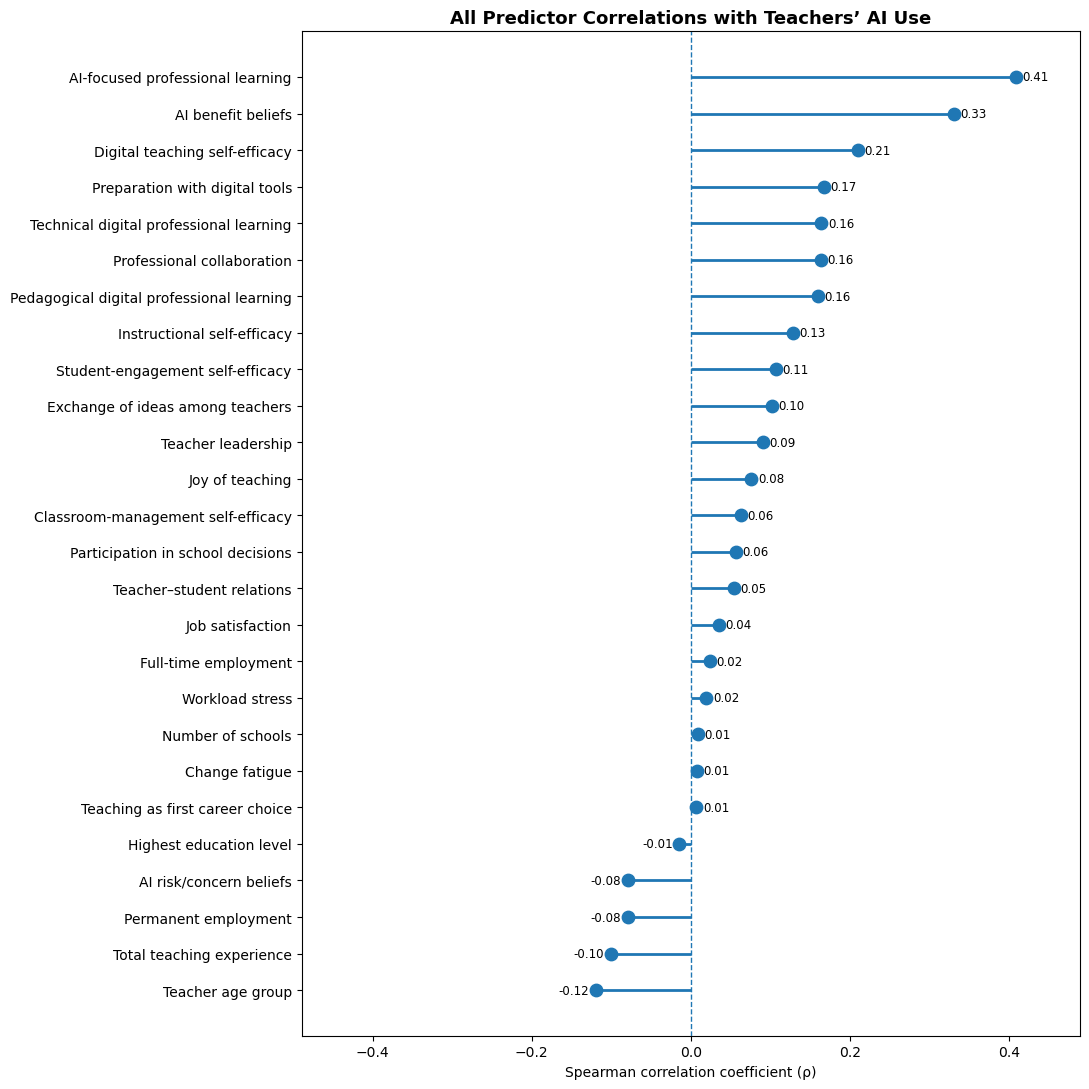

Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\rq1_all26_ai_use_spearman_lollipop.png

RQ1: all 26 predictor correlations with teachers’ AI use:


,outcome,plot_label,source_variable,predictor,valid_n,spearman_rho,effect_size_label,fdr_significant_05
0,outcome_ai_use_yes,Teacher age group,T4TAGEGR,T4TAGEGR_clean,87952,-0.119615,Small,True
1,outcome_ai_use_yes,Total teaching experience,T4TYEXPTT,T4TYEXPTT_clean,86873,-0.100604,Small,True
2,outcome_ai_use_yes,Permanent employment,TT4G09,TT4G09_permanent,88804,-0.079557,Very small,True
3,outcome_ai_use_yes,AI risk/concern beliefs,ai_risk_concern_beliefs_mean,ai_risk_concern_beliefs_mean,65345,-0.079428,Very small,True
4,outcome_ai_use_yes,Highest education level,T4THEDAT,T4THEDAT_clean,83586,-0.014918,Very small,True
5,outcome_ai_use_yes,Teaching as first career choice,TT4G08,TT4G08_yes,89607,0.007144,Very small,True
6,outcome_ai_use_yes,Change fatigue,T4CHFAT,T4CHFAT_clean,88370,0.008091,Very small,True
7,outcome_ai_use_yes,Number of schools,T4TNSCH,T4TNSCH_clean,88635,0.009351,Very small,True
8,outcome_ai_use_yes,Workload stress,T4WLOADT,T4WLOADT_clean,88469,0.019644,Very small,True
9,outcome_ai_use_yes,Full-time employment,T4TEMPWH,T4TEMPWH_full_time,88646,0.023988,Very small,True


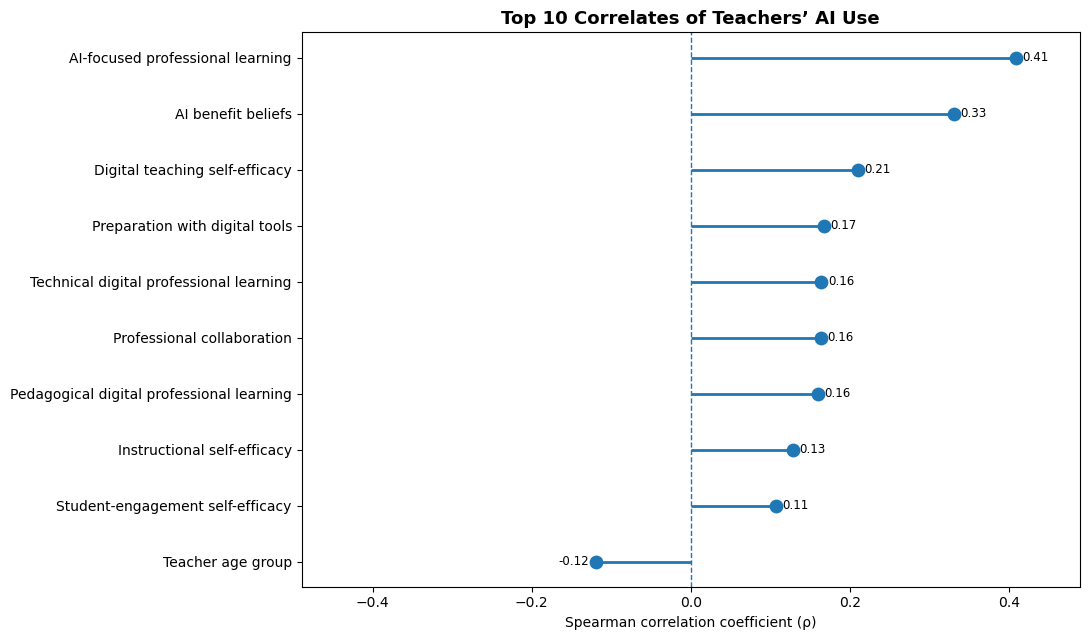

Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\rq1_top10_ai_use_spearman_lollipop.png

RQ1: top 10 predictor correlations with teachers’ AI use:


,outcome,plot_label,source_variable,predictor,valid_n,spearman_rho,effect_size_label,fdr_significant_05
0,outcome_ai_use_yes,Teacher age group,T4TAGEGR,T4TAGEGR_clean,87952,-0.119615,Small,True
1,outcome_ai_use_yes,Student-engagement self-efficacy,T4SEENG,T4SEENG_clean,89648,0.107067,Small,True
2,outcome_ai_use_yes,Instructional self-efficacy,T4SEINS,T4SEINS_clean,89610,0.128472,Small,True
3,outcome_ai_use_yes,Pedagogical digital professional learning,TT4G21E,TT4G21E_yes,84863,0.159923,Small,True
4,outcome_ai_use_yes,Professional collaboration,T4COLES,T4COLES_clean,89566,0.163296,Small,True
5,outcome_ai_use_yes,Technical digital professional learning,TT4G21F,TT4G21F_yes,84893,0.164355,Small,True
6,outcome_ai_use_yes,Preparation with digital tools,TT4G07F,TT4G07F_clean,87543,0.167373,Small,True
7,outcome_ai_use_yes,Digital teaching self-efficacy,TT4G27M,TT4G27M_clean,89277,0.210741,Small,True
8,outcome_ai_use_yes,AI benefit beliefs,ai_benefit_beliefs_mean,ai_benefit_beliefs_mean,70727,0.331274,Moderate,True
9,outcome_ai_use_yes,AI-focused professional learning,TT4G21G,TT4G21G_yes,84770,0.409457,Moderate,True


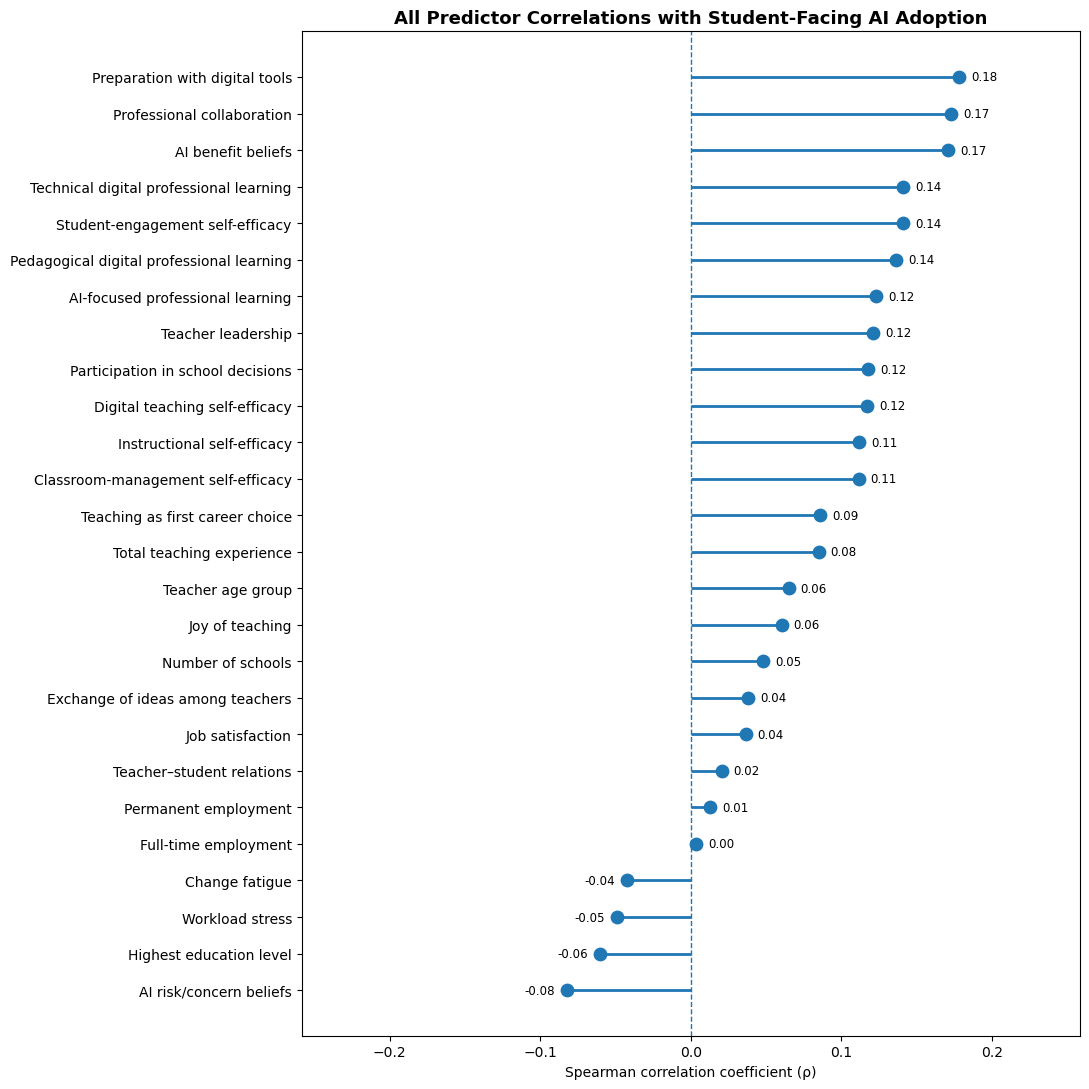

Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\rq2_all26_student_facing_adoption_spearman_lollipop.png

RQ2: all 26 predictor correlations with student-facing AI adoption:


,outcome,plot_label,source_variable,predictor,valid_n,spearman_rho,effect_size_label,fdr_significant_05
0,outcome_student_facing_adoption,AI risk/concern beliefs,ai_risk_concern_beliefs_mean,ai_risk_concern_beliefs_mean,30809,-0.082249,Very small,True
1,outcome_student_facing_adoption,Highest education level,T4THEDAT,T4THEDAT_clean,33219,-0.060405,Very small,True
2,outcome_student_facing_adoption,Workload stress,T4WLOADT,T4WLOADT_clean,35288,-0.048892,Very small,True
3,outcome_student_facing_adoption,Change fatigue,T4CHFAT,T4CHFAT_clean,35299,-0.042159,Very small,True
4,outcome_student_facing_adoption,Full-time employment,T4TEMPWH,T4TEMPWH_full_time,35346,0.003691,Very small,False
5,outcome_student_facing_adoption,Permanent employment,TT4G09,TT4G09_permanent,35398,0.012953,Very small,True
6,outcome_student_facing_adoption,Teacher–student relations,T4STUD,T4STUD_clean,35497,0.020472,Very small,True
7,outcome_student_facing_adoption,Job satisfaction,T4JOBSAT,T4JOBSAT_clean,35243,0.036444,Very small,True
8,outcome_student_facing_adoption,Exchange of ideas among teachers,T4EXINF,T4EXINF_clean,35661,0.037993,Very small,True
9,outcome_student_facing_adoption,Number of schools,T4TNSCH,T4TNSCH_clean,35341,0.048196,Very small,True


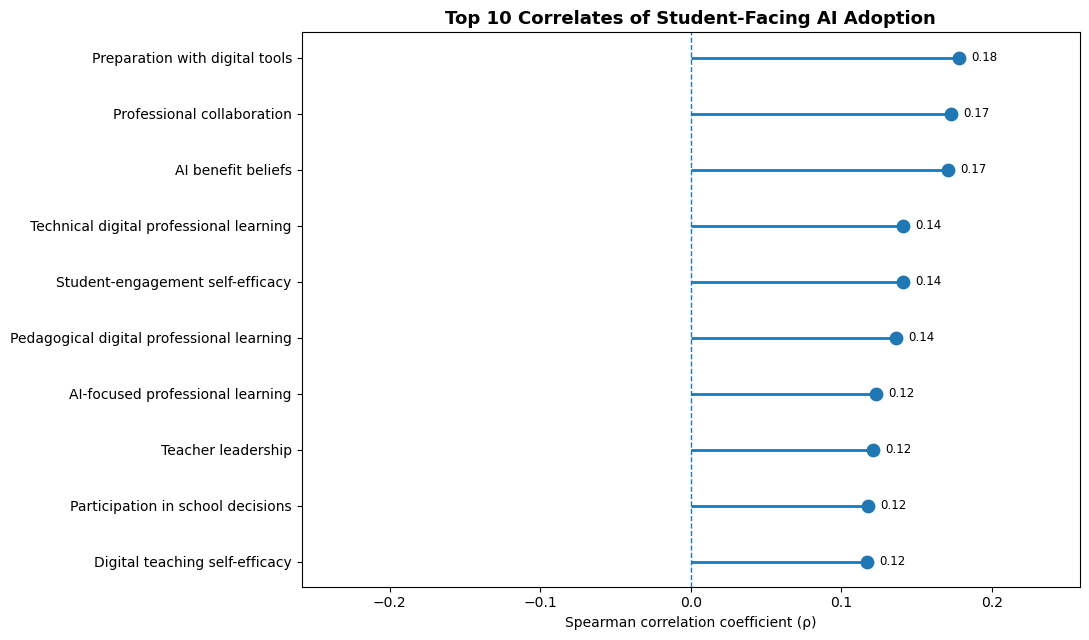

Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\rq2_top10_student_facing_adoption_spearman_lollipop.png

RQ2: top 10 predictor correlations with student-facing AI adoption:


,outcome,plot_label,source_variable,predictor,valid_n,spearman_rho,effect_size_label,fdr_significant_05
0,outcome_student_facing_adoption,Digital teaching self-efficacy,TT4G27M,TT4G27M_clean,35595,0.116998,Small,True
1,outcome_student_facing_adoption,Participation in school decisions,T4OPPART,T4OPPART_clean,35474,0.117440,Small,True
2,outcome_student_facing_adoption,Teacher leadership,T4TLEAD,T4TLEAD_clean,35482,0.120975,Small,True
3,outcome_student_facing_adoption,AI-focused professional learning,TT4G21G,TT4G21G_yes,34422,0.122957,Small,True
4,outcome_student_facing_adoption,Pedagogical digital professional learning,TT4G21E,TT4G21E_yes,34422,0.136476,Small,True
5,outcome_student_facing_adoption,Student-engagement self-efficacy,T4SEENG,T4SEENG_clean,35683,0.141047,Small,True
6,outcome_student_facing_adoption,Technical digital professional learning,TT4G21F,TT4G21F_yes,34420,0.141107,Small,True
7,outcome_student_facing_adoption,AI benefit beliefs,ai_benefit_beliefs_mean,ai_benefit_beliefs_mean,33417,0.170959,Small,True
8,outcome_student_facing_adoption,Professional collaboration,T4COLES,T4COLES_clean,35675,0.172885,Small,True
9,outcome_student_facing_adoption,Preparation with digital tools,TT4G07F,TT4G07F_clean,34907,0.178362,Small,True



Number of predictors matched across RQ1 and RQ2:
26


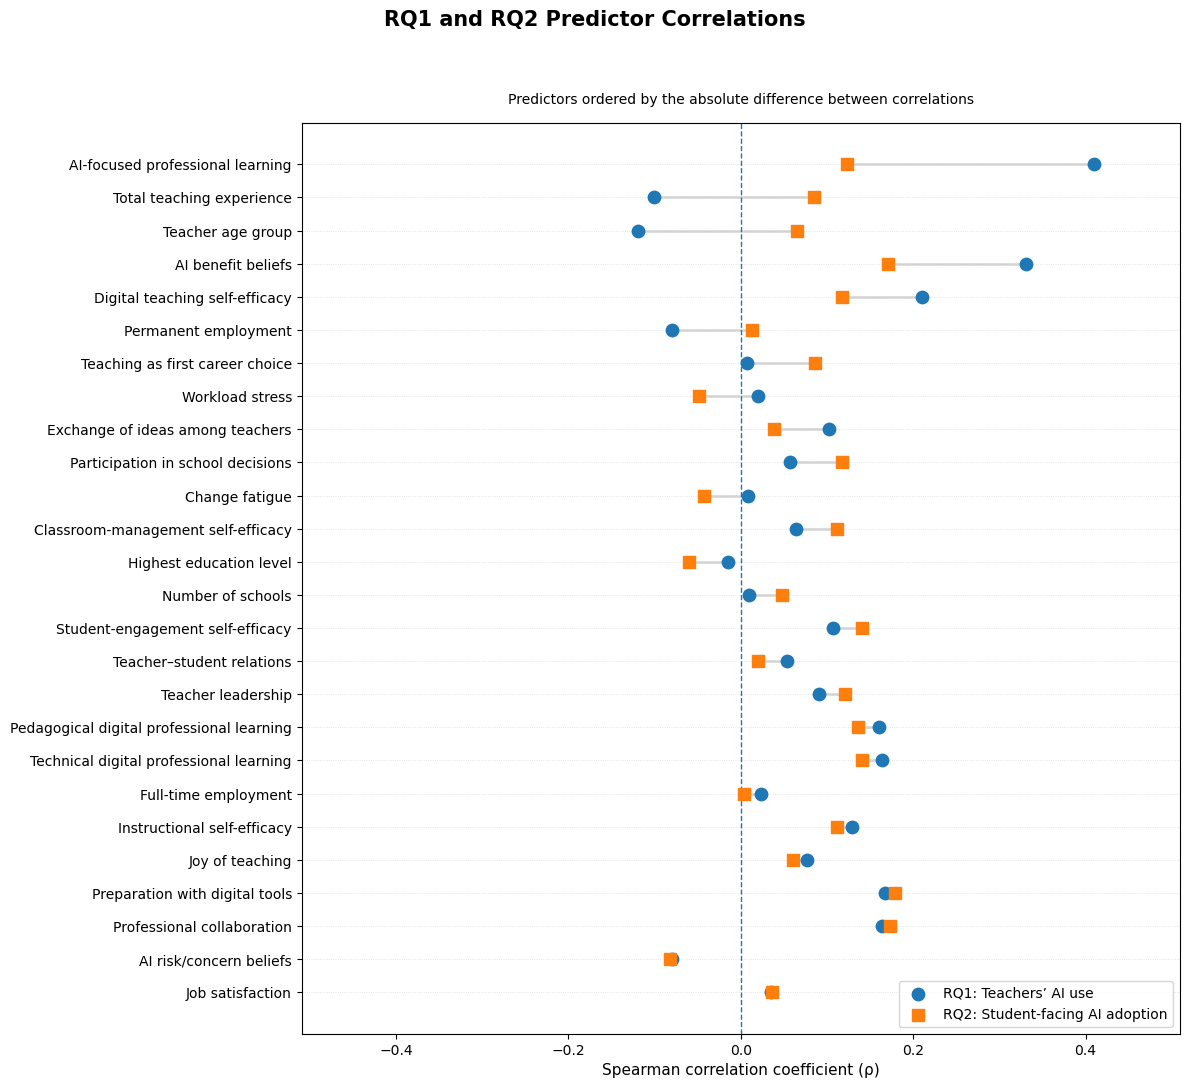

Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\cross_rq_all26_spearman_dumbbell_comparison.png

Cross-RQ dumbbell comparison data:


,plot_label,source_variable,predictor,rq1_spearman_rho,rq2_spearman_rho,rho_difference_rq1_minus_rq2,absolute_rho_difference,larger_correlation
0,AI-focused professional learning,TT4G21G,TT4G21G_yes,0.409457,0.122957,0.286500,0.286500,Larger correlation for RQ1
1,Total teaching experience,T4TYEXPTT,T4TYEXPTT_clean,-0.100604,0.084784,-0.185388,0.185388,Larger correlation for RQ2
2,Teacher age group,T4TAGEGR,T4TAGEGR_clean,-0.119615,0.064938,-0.184554,0.184554,Larger correlation for RQ2
3,AI benefit beliefs,ai_benefit_beliefs_mean,ai_benefit_beliefs_mean,0.331274,0.170959,0.160315,0.160315,Larger correlation for RQ1
4,Digital teaching self-efficacy,TT4G27M,TT4G27M_clean,0.210741,0.116998,0.093743,0.093743,Larger correlation for RQ1
5,Permanent employment,TT4G09,TT4G09_permanent,-0.079557,0.012953,-0.092510,0.092510,Larger correlation for RQ2
6,Teaching as first career choice,TT4G08,TT4G08_yes,0.007144,0.085812,-0.078668,0.078668,Larger correlation for RQ2
7,Workload stress,T4WLOADT,T4WLOADT_clean,0.019644,-0.048892,0.068536,0.068536,Larger correlation for RQ1
8,Exchange of ideas among teachers,T4EXINF,T4EXINF_clean,0.102588,0.037993,0.064595,0.064595,Larger correlation for RQ1
9,Participation in school decisions,T4OPPART,T4OPPART_clean,0.056527,0.117440,-0.060912,0.060912,Larger correlation for RQ2


Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\cross_rq_all26_spearman_dumbbell_comparison_data.csv

Predictor–outcome correlation pair reference:


,sample,predictor_label,source_variable,predictor,outcome,outcome_meaning,spearman_rho,valid_n
0,RQ1,AI-focused professional learning,TT4G21G,TT4G21G_yes,outcome_ai_use_yes,"Teachers’ general AI use: 1 = used AI, 0 = did not use AI",0.409457,84770
1,RQ1,AI benefit beliefs,ai_benefit_beliefs_mean,ai_benefit_beliefs_mean,outcome_ai_use_yes,"Teachers’ general AI use: 1 = used AI, 0 = did not use AI",0.331274,70727
2,RQ1,Digital teaching self-efficacy,TT4G27M,TT4G27M_clean,outcome_ai_use_yes,"Teachers’ general AI use: 1 = used AI, 0 = did not use AI",0.210741,89277
3,RQ1,Preparation with digital tools,TT4G07F,TT4G07F_clean,outcome_ai_use_yes,"Teachers’ general AI use: 1 = used AI, 0 = did not use AI",0.167373,87543
4,RQ1,Technical digital professional learning,TT4G21F,TT4G21F_yes,outcome_ai_use_yes,"Teachers’ general AI use: 1 = used AI, 0 = did not use AI",0.164355,84893
5,RQ1,Professional collaboration,T4COLES,T4COLES_clean,outcome_ai_use_yes,"Teachers’ general AI use: 1 = used AI, 0 = did not use AI",0.163296,89566
6,RQ1,Pedagogical digital professional learning,TT4G21E,TT4G21E_yes,outcome_ai_use_yes,"Teachers’ general AI use: 1 = used AI, 0 = did not use AI",0.159923,84863
7,RQ1,Instructional self-efficacy,T4SEINS,T4SEINS_clean,outcome_ai_use_yes,"Teachers’ general AI use: 1 = used AI, 0 = did not use AI",0.128472,89610
8,RQ1,Teacher age group,T4TAGEGR,T4TAGEGR_clean,outcome_ai_use_yes,"Teachers’ general AI use: 1 = used AI, 0 = did not use AI",-0.119615,87952
9,RQ1,Student-engagement self-efficacy,T4SEENG,T4SEENG_clean,outcome_ai_use_yes,"Teachers’ general AI use: 1 = used AI, 0 = did not use AI",0.107067,89648



Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\rq1_lollipop_all26_spearman_correlations.csv
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\rq1_lollipop_top10_spearman_correlations.csv
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\rq2_lollipop_all26_spearman_correlations.csv
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\rq2_lollipop_top10_spearman_correlations.csv
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\cross_rq_all26_spearman_dumbbell_comparison_data.csv
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\predictor_outcome_correlation_pair_reference.csv
Saved: c:\Users\elif_\Documents\summer26-teacher-ai-readiness\EDA\output\cross_rq_all26_spearman_dumbbell_comparison.png


In [17]:
# ============================================================
# CELL 17 — Predictor–outcome correlation visualizations
# ============================================================

# Purpose:
# Visualize the Spearman predictor–outcome correlations from Cell 16.
#
# Correlations shown:
#
# RQ1:
#   Each of the 26 predictors is correlated with:
#   outcome_ai_use_yes
#   1 = Used AI
#   0 = Did not use AI
#
# RQ2:
#   Each of the 26 predictors is correlated with:
#   outcome_student_facing_adoption
#   1 = Adopted at least one student-facing AI use
#   0 = Did not adopt any student-facing AI use
#
# Plot order:
# 1. RQ1 — all 26 correlations
# 2. RQ1 — top 10 correlations
# 3. RQ2 — all 26 correlations
# 4. RQ2 — top 10 correlations
# 5. Cross-RQ comparison — all 26 predictors
#
# These are predictor–outcome correlations.
# They are not correlations among the predictors.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 17.0 Check required objects
# ------------------------------------------------------------

required_objects = [
    "rq1_correlation_results",
    "rq2_correlation_results",
    "output_dir"
]

for obj in required_objects:
    if obj not in globals():
        raise NameError(
            f"Required object `{obj}` is missing. "
            "Please run Cell 16 first."
        )


required_columns = [
    "sample",
    "outcome",
    "predictor",
    "source_variable",
    "valid_n",
    "spearman_rho",
    "abs_spearman_rho",
    "effect_size_label",
    "fdr_significant_05"
]

for object_name, data_object in [
    ("rq1_correlation_results", rq1_correlation_results),
    ("rq2_correlation_results", rq2_correlation_results)
]:

    missing_columns = [
        column
        for column in required_columns
        if column not in data_object.columns
    ]

    if missing_columns:
        raise KeyError(
            f"{object_name} is missing these columns: "
            f"{missing_columns}. Please rerun Cell 16."
        )


# Confirm expected outcomes
expected_rq1_outcome = "outcome_ai_use_yes"

expected_rq2_outcome = (
    "outcome_student_facing_adoption"
)

if expected_rq1_outcome not in (
    rq1_correlation_results["outcome"]
    .dropna()
    .unique()
):
    raise KeyError(
        f"`{expected_rq1_outcome}` is missing from "
        "rq1_correlation_results."
    )

if expected_rq2_outcome not in (
    rq2_correlation_results["outcome"]
    .dropna()
    .unique()
):
    raise KeyError(
        f"`{expected_rq2_outcome}` is missing from "
        "rq2_correlation_results."
    )


print("RQ1 number of predictor–outcome correlations:")
print(len(rq1_correlation_results))

print("\nRQ2 number of predictor–outcome correlations:")
print(len(rq2_correlation_results))


# ------------------------------------------------------------
# 17.1 Create readable predictor labels
# ------------------------------------------------------------

readable_label_map = {
    "TT4G21G": "AI-focused professional learning",
    "ai_benefit_beliefs_mean": "AI benefit beliefs",
    "TT4G27M": "Digital teaching self-efficacy",
    "TT4G07F": "Preparation with digital tools",
    "TT4G21F": "Technical digital professional learning",
    "TT4G21E": "Pedagogical digital professional learning",
    "T4COLES": "Professional collaboration",
    "T4SEINS": "Instructional self-efficacy",
    "T4SEENG": "Student-engagement self-efficacy",
    "T4SECLS": "Classroom-management self-efficacy",
    "T4TAGEGR": "Teacher age group",
    "T4TYEXPTT": "Total teaching experience",
    "T4TLEAD": "Teacher leadership",
    "T4OPPART": "Participation in school decisions",
    "T4EXINF": "Exchange of ideas among teachers",
    "T4STUD": "Teacher–student relations",
    "T4JOBSAT": "Job satisfaction",
    "T4JOYTCH": "Joy of teaching",
    "T4WLOADT": "Workload stress",
    "T4CHFAT": "Change fatigue",
    "T4THEDAT": "Highest education level",
    "TT4G08": "Teaching as first career choice",
    "TT4G09": "Permanent employment",
    "T4TEMPWH": "Full-time employment",
    "T4TNSCH": "Number of schools",
    "ai_risk_concern_beliefs_mean": "AI risk/concern beliefs"
}


def add_readable_labels(data):
    """
    Add concise labels for plotting while retaining the original
    analysis and source variable names.
    """

    labelled = data.copy()

    labelled["plot_label"] = (
        labelled["source_variable"]
        .map(readable_label_map)
        .fillna(labelled["source_variable"])
    )

    return labelled


# ------------------------------------------------------------
# 17.2 Create predictor variable and label reference
# ------------------------------------------------------------

# Purpose:
# Create a reference table showing:
# 1. Analysis variable used in the correlation dataset
# 2. Original TALIS/codebook variable name
# 3. Short plot label
# 4. Full codebook label
#
# The two AI-belief composites are project-created variables,
# so their labels are supplied manually.

# Use the RQ1 recode map because RQ1 and RQ2 use the same
# 26 predictor variables and the same analysis-variable names.
predictor_variable_reference = (
    predictor_recode_map.loc[
        predictor_recode_map["sample"] == "RQ1",
        [
            "analysis_variable",
            "source_variable",
            "variable_role",
            "coding_rule",
            "interpretation"
        ]
    ]
    .drop_duplicates(
        subset=[
            "analysis_variable",
            "source_variable"
        ]
    )
    .copy()
)

predictor_variable_reference = (
    predictor_variable_reference
    .rename(
        columns={
            "source_variable": "variable_name"
        }
    )
)

# Add the shortened labels used in the plots
predictor_variable_reference[
    "plot_label"
] = (
    predictor_variable_reference[
        "variable_name"
    ]
    .map(readable_label_map)
    .fillna(
        predictor_variable_reference[
            "variable_name"
        ]
    )
)


def get_actual_codebook_label(var_name):
    """
    Return the fullest available codebook label for a TALIS variable.

    Preference:
    1. official_variable_label
    2. label_group_3
    3. label_group_2
    4. label_group_1
    """

    # Project-created composites do not appear in the TALIS codebook
    composite_labels = {
        "ai_benefit_beliefs_mean": (
            "Exploratory mean composite of perceived AI benefits: "
            "TT4G35A–E"
        ),
        "ai_risk_concern_beliefs_mean": (
            "Exploratory mean composite of perceived AI risks "
            "or concerns: TT4G35F–J"
        )
    }

    if var_name in composite_labels:
        return composite_labels[var_name]

    cb_match = codebook.loc[
        codebook["variable_name"] == var_name
    ]

    if cb_match.empty:
        return ""

    cb_row = cb_match.iloc[0]

    possible_label_columns = [
        "official_variable_label",
        "label_group_3",
        "label_group_2",
        "label_group_1"
    ]

    for label_column in possible_label_columns:

        if label_column not in cb_row.index:
            continue

        label_value = cb_row[label_column]

        if (
            pd.notna(label_value)
            and str(label_value).strip() != ""
        ):
            return str(label_value).strip()

    return ""


predictor_variable_reference[
    "actual_label"
] = (
    predictor_variable_reference[
        "variable_name"
    ]
    .apply(
        get_actual_codebook_label
    )
)

# Arrange the table in the same order as the predictor columns
analysis_variable_order = {
    variable: position
    for position, variable
    in enumerate(
        rq1_correlation_results[
            "predictor"
        ].tolist()
    )
}

predictor_variable_reference[
    "display_order"
] = (
    predictor_variable_reference[
        "analysis_variable"
    ]
    .map(analysis_variable_order)
)

predictor_variable_reference = (
    predictor_variable_reference
    .sort_values(
        "display_order"
    )
    .drop(
        columns="display_order"
    )
    .reset_index(drop=True)
)

# Final order of columns
predictor_variable_reference = (
    predictor_variable_reference[
        [
            "analysis_variable",
            "variable_name",
            "plot_label",
            "actual_label",
            "variable_role",
            "coding_rule",
            "interpretation"
        ]
    ]
)

print(
    "\nPredictor variable-name and label reference:"
)

display(
    predictor_variable_reference
)

predictor_variable_reference.to_csv(
    output_dir
    / "predictor_variable_plot_and_codebook_label_reference.csv",
    index=False
)

print(
    "Saved:",
    output_dir
    / "predictor_variable_plot_and_codebook_label_reference.csv"
)


# ------------------------------------------------------------
# 17.3 General lollipop plot function
# ------------------------------------------------------------

def plot_spearman_correlations(
    correlation_results,
    outcome_name,
    title,
    save_name,
    top_n=None,
    figure_height=None
):
    """
    Create a horizontal lollipop plot of predictor–outcome
    Spearman correlations.

    Parameters
    ----------
    correlation_results:
        Correlation results produced in Cell 16.

    outcome_name:
        Outcome correlated with each predictor.

    title:
        Figure title.

    save_name:
        PNG filename.

    top_n:
        Number of predictors with the largest absolute correlations
        to display. Use None to display all predictors.

    figure_height:
        Optional figure height.
    """

    plot_df = (
        correlation_results.loc[
            correlation_results["outcome"]
            == outcome_name
        ]
        .copy()
    )

    if plot_df.empty:
        raise ValueError(
            f"No correlations were found for "
            f"`{outcome_name}`."
        )

    plot_df = add_readable_labels(
        plot_df
    )

    # Select the largest absolute correlations only when requested
    if top_n is not None:

        plot_df = (
            plot_df
            .sort_values(
                "abs_spearman_rho",
                ascending=False
            )
            .head(top_n)
            .copy()
        )

    # Display from the smallest/most negative at the bottom
    # to the largest/most positive at the top.
    plot_df = (
        plot_df
        .sort_values(
            "spearman_rho",
            ascending=True
        )
        .reset_index(drop=True)
    )

    if figure_height is None:
        figure_height = max(
            6,
            0.42 * len(plot_df)
        )

    fig, ax = plt.subplots(
        figsize=(11, figure_height)
    )

    y_positions = np.arange(
        len(plot_df)
    )

    # Lollipop stems
    ax.hlines(
        y=y_positions,
        xmin=0,
        xmax=plot_df["spearman_rho"],
        linewidth=2
    )

    # Lollipop points
    ax.scatter(
        plot_df["spearman_rho"],
        y_positions,
        s=80
    )

    # Zero-reference line
    ax.axvline(
        x=0,
        linestyle="--",
        linewidth=1
    )

    ax.set_yticks(
        y_positions
    )

    ax.set_yticklabels(
        plot_df["plot_label"]
    )

    ax.set_xlabel(
        "Spearman correlation coefficient (ρ)"
    )

    ax.set_title(
        title,
        fontsize=13,
        weight="bold"
    )

    # Add correlation values beside points
    for position, rho_value in enumerate(
        plot_df["spearman_rho"]
    ):

        if rho_value >= 0:
            label_x = rho_value + 0.008
            horizontal_alignment = "left"

        else:
            label_x = rho_value - 0.008
            horizontal_alignment = "right"

        ax.text(
            label_x,
            position,
            f"{rho_value:.2f}",
            va="center",
            ha=horizontal_alignment,
            fontsize=8.5
        )

    # Symmetric axis around zero
    maximum_absolute_rho = max(
        plot_df["abs_spearman_rho"].max(),
        0.10
    )

    axis_padding = 0.08

    ax.set_xlim(
        -maximum_absolute_rho - axis_padding,
        maximum_absolute_rho + axis_padding
    )

    plt.tight_layout()

    figure_path = (
        output_dir
        / save_name
    )

    plt.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(
        "Saved:",
        figure_path
    )

    return plot_df


# ------------------------------------------------------------
# 17.4 RQ1 — all 26 correlations
# ------------------------------------------------------------

rq1_lollipop_all = (
    plot_spearman_correlations(
        correlation_results=(
            rq1_correlation_results
        ),
        outcome_name=(
            "outcome_ai_use_yes"
        ),
        title=(
            "All Predictor Correlations with Teachers’ AI Use"
        ),
        save_name=(
            "rq1_all26_ai_use_spearman_lollipop.png"
        ),
        top_n=None,
        figure_height=11
    )
)

print(
    "\nRQ1: all 26 predictor correlations with teachers’ AI use:"
)

display(
    rq1_lollipop_all[
        [
            "outcome",
            "plot_label",
            "source_variable",
            "predictor",
            "valid_n",
            "spearman_rho",
            "effect_size_label",
            "fdr_significant_05"
        ]
    ]
)


# ------------------------------------------------------------
# 17.5 RQ1 — top 10 correlations
# ------------------------------------------------------------

rq1_lollipop_top10 = (
    plot_spearman_correlations(
        correlation_results=(
            rq1_correlation_results
        ),
        outcome_name=(
            "outcome_ai_use_yes"
        ),
        title=(
            "Top 10 Correlates of Teachers’ AI Use"
        ),
        save_name=(
            "rq1_top10_ai_use_spearman_lollipop.png"
        ),
        top_n=10,
        figure_height=6.5
    )
)

print(
    "\nRQ1: top 10 predictor correlations with teachers’ AI use:"
)

display(
    rq1_lollipop_top10[
        [
            "outcome",
            "plot_label",
            "source_variable",
            "predictor",
            "valid_n",
            "spearman_rho",
            "effect_size_label",
            "fdr_significant_05"
        ]
    ]
)


# ------------------------------------------------------------
# 17.6 RQ2 — all 26 correlations
# ------------------------------------------------------------

rq2_lollipop_all = (
    plot_spearman_correlations(
        correlation_results=(
            rq2_correlation_results
        ),
        outcome_name=(
            "outcome_student_facing_adoption"
        ),
        title=(
            "All Predictor Correlations with "
            "Student-Facing AI Adoption"
        ),
        save_name=(
            "rq2_all26_student_facing_adoption_"
            "spearman_lollipop.png"
        ),
        top_n=None,
        figure_height=11
    )
)

print(
    "\nRQ2: all 26 predictor correlations with "
    "student-facing AI adoption:"
)

display(
    rq2_lollipop_all[
        [
            "outcome",
            "plot_label",
            "source_variable",
            "predictor",
            "valid_n",
            "spearman_rho",
            "effect_size_label",
            "fdr_significant_05"
        ]
    ]
)


# ------------------------------------------------------------
# 17.7 RQ2 — top 10 correlations
# ------------------------------------------------------------

rq2_lollipop_top10 = (
    plot_spearman_correlations(
        correlation_results=(
            rq2_correlation_results
        ),
        outcome_name=(
            "outcome_student_facing_adoption"
        ),
        title=(
            "Top 10 Correlates of "
            "Student-Facing AI Adoption"
        ),
        save_name=(
            "rq2_top10_student_facing_adoption_"
            "spearman_lollipop.png"
        ),
        top_n=10,
        figure_height=6.5
    )
)

print(
    "\nRQ2: top 10 predictor correlations with "
    "student-facing AI adoption:"
)

display(
    rq2_lollipop_top10[
        [
            "outcome",
            "plot_label",
            "source_variable",
            "predictor",
            "valid_n",
            "spearman_rho",
            "effect_size_label",
            "fdr_significant_05"
        ]
    ]
)


# ------------------------------------------------------------
# 17.8 Cross-RQ comparison — clean dumbbell plot
# ------------------------------------------------------------

# Purpose:
# Compare each predictor’s Spearman correlation for RQ1 and RQ2.
#
# This version:
# - uses neutral grey connecting lines;
# - does not display overlapping numeric labels;
# - sorts predictors by the absolute RQ1–RQ2 difference;
# - uses a properly spaced title and subtitle;
# - saves exact correlation values in a separate table.


# ------------------------------------------------------------
# Prepare RQ1 comparison data
# ------------------------------------------------------------

rq1_dumbbell_df = (
    rq1_correlation_results[
        [
            "predictor",
            "source_variable",
            "spearman_rho"
        ]
    ]
    .copy()
    .rename(
        columns={
            "spearman_rho": "rq1_spearman_rho"
        }
    )
)


# ------------------------------------------------------------
# Prepare RQ2 comparison data
# ------------------------------------------------------------

rq2_dumbbell_df = (
    rq2_correlation_results[
        [
            "predictor",
            "source_variable",
            "spearman_rho"
        ]
    ]
    .copy()
    .rename(
        columns={
            "spearman_rho": "rq2_spearman_rho"
        }
    )
)


# ------------------------------------------------------------
# Merge RQ1 and RQ2 results
# ------------------------------------------------------------

cross_rq_dumbbell_df = (
    rq1_dumbbell_df
    .merge(
        rq2_dumbbell_df[
            [
                "predictor",
                "rq2_spearman_rho"
            ]
        ],
        on="predictor",
        how="inner"
    )
)


print(
    "\nNumber of predictors matched across RQ1 and RQ2:"
)

print(
    len(cross_rq_dumbbell_df)
)


if len(cross_rq_dumbbell_df) != 26:

    print(
        "Warning: Expected 26 matched predictors, but found",
        len(cross_rq_dumbbell_df)
    )


# ------------------------------------------------------------
# Add readable labels
# ------------------------------------------------------------

cross_rq_dumbbell_df[
    "plot_label"
] = (
    cross_rq_dumbbell_df[
        "source_variable"
    ]
    .map(readable_label_map)
    .fillna(
        cross_rq_dumbbell_df[
            "source_variable"
        ]
    )
)


# ------------------------------------------------------------
# Calculate the difference between RQ1 and RQ2
# ------------------------------------------------------------

# Positive:
#     The RQ1 correlation is larger.
#
# Negative:
#     The RQ2 correlation is larger.

cross_rq_dumbbell_df[
    "rho_difference_rq1_minus_rq2"
] = (
    cross_rq_dumbbell_df[
        "rq1_spearman_rho"
    ]
    - cross_rq_dumbbell_df[
        "rq2_spearman_rho"
    ]
)


cross_rq_dumbbell_df[
    "absolute_rho_difference"
] = (
    cross_rq_dumbbell_df[
        "rho_difference_rq1_minus_rq2"
    ]
    .abs()
)


# ------------------------------------------------------------
# Identify which outcome has the larger correlation
# ------------------------------------------------------------

def identify_larger_correlation(row):
    """
    Identify whether the predictor has a larger correlation
    with RQ1 or RQ2.

    Correlations differing by less than .005 are classified
    as similar.
    """

    if np.isclose(
        row["rq1_spearman_rho"],
        row["rq2_spearman_rho"],
        atol=0.005
    ):
        return "Similar across RQ1 and RQ2"

    if (
        row["rq1_spearman_rho"]
        > row["rq2_spearman_rho"]
    ):
        return "Larger correlation for RQ1"

    return "Larger correlation for RQ2"


cross_rq_dumbbell_df[
    "larger_correlation"
] = (
    cross_rq_dumbbell_df
    .apply(
        identify_larger_correlation,
        axis=1
    )
)


# ------------------------------------------------------------
# Sort predictors
# ------------------------------------------------------------

# Ascending order places the largest differences at the top
# because the first row is plotted at the bottom of the y-axis.

cross_rq_dumbbell_df = (
    cross_rq_dumbbell_df
    .sort_values(
        "absolute_rho_difference",
        ascending=True
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Create dumbbell plot
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(12, 11)
)


y_positions = np.arange(
    len(cross_rq_dumbbell_df)
)


# Draw neutral connecting lines
for position, row in cross_rq_dumbbell_df.iterrows():

    ax.plot(
        [
            row["rq1_spearman_rho"],
            row["rq2_spearman_rho"]
        ],
        [
            position,
            position
        ],
        linewidth=2,
        color="lightgray",
        alpha=0.85,
        zorder=1
    )


# Plot RQ1 points
ax.scatter(
    cross_rq_dumbbell_df[
        "rq1_spearman_rho"
    ],
    y_positions,
    s=80,
    marker="o",
    label="RQ1: Teachers’ AI use",
    zorder=3
)


# Plot RQ2 points
ax.scatter(
    cross_rq_dumbbell_df[
        "rq2_spearman_rho"
    ],
    y_positions,
    s=80,
    marker="s",
    label="RQ2: Student-facing AI adoption",
    zorder=3
)


# ------------------------------------------------------------
# Add reference line and axes
# ------------------------------------------------------------

ax.axvline(
    x=0,
    linestyle="--",
    linewidth=1
)


ax.set_yticks(
    y_positions
)


ax.set_yticklabels(
    cross_rq_dumbbell_df[
        "plot_label"
    ]
)


ax.set_xlabel(
    "Spearman correlation coefficient (ρ)",
    fontsize=11
)


# ------------------------------------------------------------
# Add properly spaced title and subtitle
# ------------------------------------------------------------

fig.suptitle(
    "RQ1 and RQ2 Predictor Correlations",
    fontsize=15,
    fontweight="bold",
    y=0.985
)


ax.set_title(
    "Predictors ordered by the absolute difference between correlations",
    fontsize=10,
    fontweight="normal",
    pad=14
)


# ------------------------------------------------------------
# Use a symmetric x-axis
# ------------------------------------------------------------

maximum_absolute_rho = max(
    cross_rq_dumbbell_df[
        [
            "rq1_spearman_rho",
            "rq2_spearman_rho"
        ]
    ]
    .abs()
    .max()
    .max(),
    0.10
)


ax.set_xlim(
    -maximum_absolute_rho - 0.10,
    maximum_absolute_rho + 0.10
)


# ------------------------------------------------------------
# Improve readability
# ------------------------------------------------------------

ax.grid(
    axis="y",
    linestyle=":",
    linewidth=0.6,
    alpha=0.45
)


ax.legend(
    loc="lower right",
    frameon=True
)


# Reserve space for the title and subtitle
plt.tight_layout(
    rect=[
        0,
        0,
        1,
        0.955
    ]
)


# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

dumbbell_figure_path = (
    output_dir
    / "cross_rq_all26_spearman_dumbbell_comparison.png"
)


plt.savefig(
    dumbbell_figure_path,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


print(
    "Saved:",
    dumbbell_figure_path
)


# ------------------------------------------------------------
# Create exact-value comparison table
# ------------------------------------------------------------

cross_rq_dumbbell_display = (
    cross_rq_dumbbell_df[
        [
            "plot_label",
            "source_variable",
            "predictor",
            "rq1_spearman_rho",
            "rq2_spearman_rho",
            "rho_difference_rq1_minus_rq2",
            "absolute_rho_difference",
            "larger_correlation"
        ]
    ]
    .sort_values(
        "absolute_rho_difference",
        ascending=False
    )
    .reset_index(drop=True)
)


print(
    "\nCross-RQ dumbbell comparison data:"
)


display(
    cross_rq_dumbbell_display
)


# ------------------------------------------------------------
# Save exact-value comparison table
# ------------------------------------------------------------

cross_rq_dumbbell_display.to_csv(
    output_dir
    / "cross_rq_all26_spearman_dumbbell_comparison_data.csv",
    index=False
)


print(
    "Saved:",
    output_dir
    / "cross_rq_all26_spearman_dumbbell_comparison_data.csv"
)


# ------------------------------------------------------------
# 17.9 Create explicit predictor–outcome pair reference
# ------------------------------------------------------------

# Purpose:
# Make clear which predictor was correlated with which outcome.


# RQ1 predictor–outcome pairs
rq1_pair_reference = (
    rq1_correlation_results[
        [
            "sample",
            "outcome",
            "predictor",
            "source_variable",
            "spearman_rho",
            "valid_n"
        ]
    ]
    .copy()
)


rq1_pair_reference[
    "outcome_meaning"
] = (
    "Teachers’ general AI use: "
    "1 = used AI, 0 = did not use AI"
)


# RQ2 predictor–outcome pairs
rq2_pair_reference = (
    rq2_correlation_results[
        [
            "sample",
            "outcome",
            "predictor",
            "source_variable",
            "spearman_rho",
            "valid_n"
        ]
    ]
    .copy()
)


rq2_pair_reference[
    "outcome_meaning"
] = (
    "Student-facing AI adoption: "
    "1 = adopted at least one student-facing use, "
    "0 = did not adopt any student-facing use"
)


# Combine RQ1 and RQ2 pair references
correlation_pair_reference = (
    pd.concat(
        [
            rq1_pair_reference,
            rq2_pair_reference
        ],
        ignore_index=True
    )
)


# Add readable predictor labels
correlation_pair_reference[
    "predictor_label"
] = (
    correlation_pair_reference[
        "source_variable"
    ]
    .map(readable_label_map)
    .fillna(
        correlation_pair_reference[
            "source_variable"
        ]
    )
)


# Create an explicit text description of each correlation pair
correlation_pair_reference[
    "correlation_pair"
] = (
    correlation_pair_reference[
        "predictor_label"
    ]
    + " with "
    + correlation_pair_reference[
        "outcome"
    ]
)


print(
    "\nPredictor–outcome correlation pair reference:"
)


display(
    correlation_pair_reference[
        [
            "sample",
            "predictor_label",
            "source_variable",
            "predictor",
            "outcome",
            "outcome_meaning",
            "spearman_rho",
            "valid_n"
        ]
    ]
)


# ------------------------------------------------------------
# 17.10 Save plotted data and reference tables
# ------------------------------------------------------------

# Save RQ1 all-26 correlation data
rq1_lollipop_all.to_csv(
    output_dir
    / "rq1_lollipop_all26_spearman_correlations.csv",
    index=False
)


# Save RQ1 top-10 correlation data
rq1_lollipop_top10.to_csv(
    output_dir
    / "rq1_lollipop_top10_spearman_correlations.csv",
    index=False
)


# Save RQ2 all-26 correlation data
rq2_lollipop_all.to_csv(
    output_dir
    / "rq2_lollipop_all26_spearman_correlations.csv",
    index=False
)


# Save RQ2 top-10 correlation data
rq2_lollipop_top10.to_csv(
    output_dir
    / "rq2_lollipop_top10_spearman_correlations.csv",
    index=False
)


# Save the new cross-RQ dumbbell comparison data
cross_rq_dumbbell_display.to_csv(
    output_dir
    / "cross_rq_all26_spearman_dumbbell_comparison_data.csv",
    index=False
)


# Save predictor–outcome pair reference
correlation_pair_reference.to_csv(
    output_dir
    / "predictor_outcome_correlation_pair_reference.csv",
    index=False
)


# Print all saved output paths
print(
    "\nSaved:",
    output_dir
    / "rq1_lollipop_all26_spearman_correlations.csv"
)

print(
    "Saved:",
    output_dir
    / "rq1_lollipop_top10_spearman_correlations.csv"
)

print(
    "Saved:",
    output_dir
    / "rq2_lollipop_all26_spearman_correlations.csv"
)

print(
    "Saved:",
    output_dir
    / "rq2_lollipop_top10_spearman_correlations.csv"
)

print(
    "Saved:",
    output_dir
    / "cross_rq_all26_spearman_dumbbell_comparison_data.csv"
)

print(
    "Saved:",
    output_dir
    / "predictor_outcome_correlation_pair_reference.csv"
)

print(
    "Saved:",
    output_dir
    / "cross_rq_all26_spearman_dumbbell_comparison.png"
)

### Predictor–outcome correlation visualizations

Lollipop plots were used to visualise the Spearman correlations between each of the 26 primary predictors and the outcomes for RQ1 and RQ2.

For RQ1, each predictor was correlated with teachers’ general AI use:

- `1` = used AI;
- `0` = did not use AI.

For RQ2, each predictor was correlated with student-facing AI adoption among AI users:

- `1` = adopted at least one student-facing AI use;
- `0` = did not adopt any student-facing AI use.

The plots display the direction and magnitude of each correlation. Points to the right of zero indicate positive associations, whereas points to the left indicate negative associations.

#### RQ1 visual pattern

The RQ1 plots show that AI-focused professional learning had the strongest positive association with teachers’ general AI use, followed by AI benefit beliefs.

Digital teaching self-efficacy was the next strongest correlate. Preparation with digital tools, technical and pedagogical digital professional learning, and professional collaboration also showed positive associations.

Teacher age group and total teaching experience showed the clearest negative associations with general AI use.

The top-10 plot highlights the strongest associations, while the all-predictor plot shows that most remaining relationships were very small.

#### RQ2 visual pattern

The RQ2 plots show a more evenly distributed pattern of small positive associations.

The strongest correlates of student-facing AI adoption were:

- preparation with digital tools;
- professional collaboration;
- AI benefit beliefs;
- technical digital professional learning;
- student-engagement self-efficacy;
- pedagogical digital professional learning.

AI-focused professional learning, teacher leadership, participation in school decisions, and digital teaching self-efficacy also appeared among the 10 strongest RQ2 associations.

AI risk or concern beliefs showed the strongest negative RQ2 association, although its magnitude remained very small.

#### Cross-RQ comparison

The cross-RQ comparison shows that AI-focused professional learning and AI benefit beliefs were more strongly associated with general AI use than with student-facing adoption.

In contrast, preparation with digital tools, professional collaboration, student-engagement self-efficacy, teacher leadership, and participation in school decisions were relatively more strongly associated with student-facing adoption.

Teacher age and total teaching experience showed opposite directions across the two research questions. They were negatively associated with general AI use but positively associated with student-facing adoption among teachers who already used AI.

Overall, the visualisations reinforce that general AI use was most strongly associated with AI-specific preparation and beliefs, whereas student-facing adoption reflected a broader combination of digital preparation, collaboration, leadership, and self-efficacy.